In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#smart Medical Diagnosis System
#Step 1: Import required libraries

import pandas as pd
import numpy as np
print("Smart Medical Diagnosis System Started!")

Smart Medical Diagnosis System Started!


In [ ]:
from google.colab import files
uploaded = files.upload()

In [ ]:
import os
print(os.listdir('/content'))

['.config', 'archive.zip', 'sample_data']


In [ ]:
import zipfile
zip_path = "/content/archive.zip"
extract_path = "/content/dataset"
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)
print("Dataset extracted successfully!")

Dataset extracted successfully!


In [ ]:
import os
print(os.listdir("/content/dataset"))

['Testing.csv', 'Training.csv']


In [ ]:
import pandas as pd

training_data = pd.read_csv('/content/dataset/Training.csv')
testing_data = pd.read_csv('/content/dataset/Testing.csv')

print("Training data shape:", training_data.shape)
print("Testing data shape:", testing_data.shape)

display(training_data.head())

Training data shape: (4920, 134)
Testing data shape: (42, 133)


,itching,skin_rash,nodal_skin_eruptions,continuous_sneezing,shivering,chills,joint_pain,stomach_pain,acidity,ulcers_on_tongue,...,scurring,skin_peeling,silver_like_dusting,small_dents_in_nails,inflammatory_nails,blister,red_sore_around_nose,yellow_crust_ooze,prognosis,Unnamed: 133
0,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Fungal infection,NaN
1,0,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Fungal infection,NaN
2,1,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Fungal infection,NaN
3,1,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Fungal infection,NaN
4,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Fungal infection,NaN


In [ ]:
# Separate features (symptoms) and target (disease)

X = training_data.drop('prognosis', axis=1)
y = training_data['prognosis']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

print("\nDisease classes:")
print(y.unique())

Features shape: (4920, 133)
Target shape: (4920,)

Disease classes:
['Fungal infection' 'Allergy' 'GERD' 'Chronic cholestasis' 'Drug Reaction'
 'Peptic ulcer diseae' 'AIDS' 'Diabetes ' 'Gastroenteritis'
 'Bronchial Asthma' 'Hypertension ' 'Migraine' 'Cervical spondylosis'
 'Paralysis (brain hemorrhage)' 'Jaundice' 'Malaria' 'Chicken pox'
 'Dengue' 'Typhoid' 'hepatitis A' 'Hepatitis B' 'Hepatitis C'
 'Hepatitis D' 'Hepatitis E' 'Alcoholic hepatitis' 'Tuberculosis'
 'Common Cold' 'Pneumonia' 'Dimorphic hemmorhoids(piles)' 'Heart attack'
 'Varicose veins' 'Hypothyroidism' 'Hyperthyroidism' 'Hypoglycemia'
 'Osteoarthristis' 'Arthritis' '(vertigo) Paroymsal  Positional Vertigo'
 'Acne' 'Urinary tract infection' 'Psoriasis' 'Impetigo']


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Create the model
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train the model
model.fit(X, y)

print("Model training completed successfully! ✅")

Model training completed successfully! ✅


In [ ]:
# Remove unwanted unnamed columns from both datasets

training_data = training_data.loc[:, ~training_data.columns.str.contains('^Unnamed')]
testing_data = testing_data.loc[:, ~testing_data.columns.str.contains('^Unnamed')]

# Separate features and target

X = training_data.drop('prognosis', axis=1)
y = training_data['prognosis']

X_test = testing_data.drop('prognosis', axis=1)
y_test = testing_data['prognosis']

# Make testing columns exactly same as training columns
X_test = X_test.reindex(columns=X.columns, fill_value=0)

print("Training features:", X.shape)
print("Testing features:", X_test.shape)

Training features: (4920, 132)
Testing features: (42, 132)


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X, y)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Model trained successfully! ✅")
print("Accuracy:", accuracy * 100, "%")

Model trained successfully! ✅
Accuracy: 97.61904761904762 %


In [ ]:
from sklearn.metrics import classification_report

# Make predictions on testing data
y_pred = model.predict(X_test)

# Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
                                         precision    recall  f1-score   support

(vertigo) Paroymsal  Positional Vertigo       1.00      1.00      1.00         1
                                   AIDS       1.00      1.00      1.00         1
                                   Acne       1.00      1.00      1.00         1
                    Alcoholic hepatitis       1.00      1.00      1.00         1
                                Allergy       1.00      1.00      1.00         1
                              Arthritis       1.00      1.00      1.00         1
                       Bronchial Asthma       1.00      1.00      1.00         1
                   Cervical spondylosis       1.00      1.00      1.00         1
                            Chicken pox       1.00      1.00      1.00         1
                    Chronic cholestasis       1.00      1.00      1.00         1
                            Common Cold       1.00      1.00      1.00         1
    

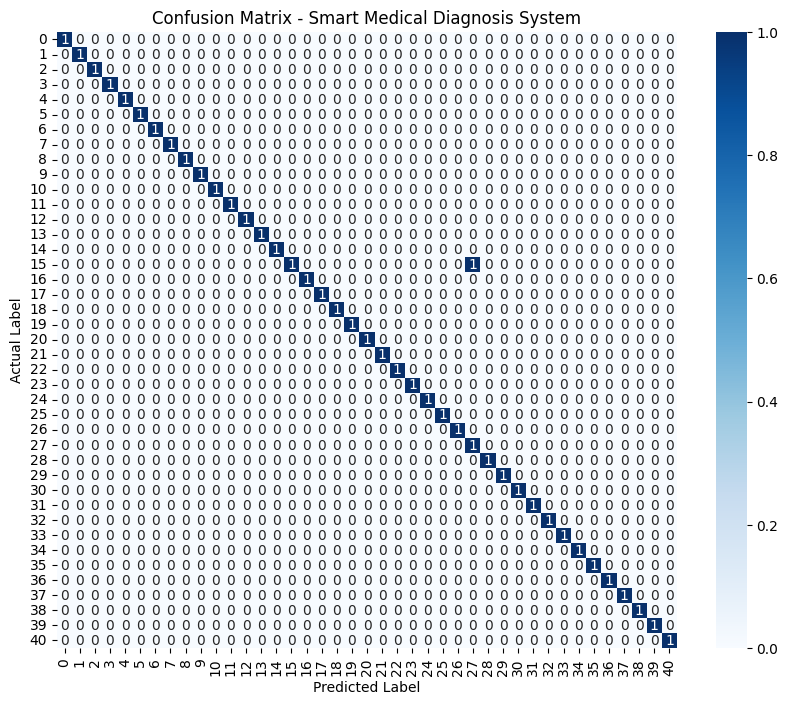

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix - Smart Medical Diagnosis System")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

In [ ]:
print("Actual class distribution in tsting data:")
print(y_test.value_counts())

Actual class distribution in tsting data:
prognosis
Fungal infection                           2
Allergy                                    1
GERD                                       1
Chronic cholestasis                        1
Drug Reaction                              1
Peptic ulcer diseae                        1
AIDS                                       1
Diabetes                                   1
Gastroenteritis                            1
Bronchial Asthma                           1
Hypertension                               1
Migraine                                   1
Cervical spondylosis                       1
Paralysis (brain hemorrhage)               1
Jaundice                                   1
Malaria                                    1
Chicken pox                                1
Dengue                                     1
Typhoid                                    1
hepatitis A                                1
Hepatitis B                                1
Hep

In [ ]:
from sklearn.metrics import accuracy_score

# Training predictions
train_pred = model.predict(X)

# Training accuracy
train_accuracy = accuracy_score(y, train_pred)

# Testing accuracy
test_accuracy = accuracy_score(y_test, y_pred)

print("Training Accuracy:", train_accuracy * 100, "%")
print("Testing Accuracy:", test_accuracy * 100, "%")

Training Accuracy: 100.0 %
Testing Accuracy: 97.61904761904762 %


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)

Training features: (3936, 132)
Testing features: (984, 132)


In [ ]:
# Check whether any test samples are also present in training data

train_rows = set(map(tuple, X_train))
test_rows = set(map(tuple, X_test))

overlap = train_rows.intersection(test_rows)

print("Overlapping samples:", len(overlap))

if len(overlap) == 0:
    print("No data leakage detected between training and testing data. ✅")
else:
    print("Warning: Possible data leakage detected! ⚠️")

Overlapping samples: 132


In [ ]:
print("Duplicate rows in full feature dataset:", X.duplicated().sum())

print("Duplicate rows in training data:", X_train.duplicated().sum())

print("Duplicate rows in testing data:", X_test.duplicated().sum())

Duplicate rows in full feature dataset: 4616
Duplicate rows in training data: 3632
Duplicate rows in testing data: 725


In [ ]:
import pandas as pd

# Combine features and target
data_clean = X.copy()
data_clean["target"] = y.values

# Remove duplicate rows
data_clean = data_clean.drop_duplicates()

# Separate features and target again
X_clean = data_clean.drop("target", axis=1)
y_clean = data_clean["target"]

print("Original rows:", len(X))
print("Rows after removing duplicates:", len(X_clean))
print("Duplicates remaining:", X_clean.duplicated().sum())

Original rows: 4920
Rows after removing duplicates: 304
Duplicates remaining: 0


In [ ]:
label_check = data_clean.copy()

# Count how many different labels each feature combination has
label_counts = (
    label_check.groupby(list(X_clean.columns))["target"]
    .nunique()
)

print("Feature combinations with different labels:",
      (label_counts > 1).sum())

Feature combinations with different labels: 0


In [ ]:
from sklearn.model_selection import train_test_split

X_train_clean, X_test_clean, y_train_clean, y_test_clean = train_test_split(
    X_clean,
    y_clean,
    test_size=0.2,
    random_state=42,
    stratify=y_clean
)

print("Clean training features:", X_train_clean.shape)
print("Clean testing features:", X_test_clean.shape)

Clean training features: (243, 132)
Clean testing features: (61, 132)


In [ ]:
from sklearn.ensemble import RandomForestClassifier

clean_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

clean_model.fit(X_train_clean, y_train_clean)

print("Clean model trained successfully! ✅")

Clean model trained successfully! ✅


In [ ]:
# Predict on clean unseen testing data
clean_y_pred = clean_model.predict(X_test_clean)

# Calculate testing accuracy
from sklearn.metrics import accuracy_score

clean_accuracy = accuracy_score(y_test_clean, clean_y_pred)

print("Clean Testing Accuracy:", clean_accuracy * 100, "%")

Clean Testing Accuracy: 100.0 %


In [ ]:
# Training predictions
clean_train_pred = clean_model.predict(X_train_clean)

# Training accuracy
clean_train_accuracy = accuracy_score(
    y_train_clean,
    clean_train_pred
)

# Testing accuracy
clean_test_accuracy = accuracy_score(
    y_test_clean,
    clean_y_pred
)

print("Clean Training Accuracy:", clean_train_accuracy * 100, "%")
print("Clean Testing Accuracy:", clean_test_accuracy * 100, "%")

Clean Training Accuracy: 100.0 %
Clean Testing Accuracy: 100.0 %


In [ ]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    clean_model,
    X_clean,
    y_clean,
    cv=cv,
    scoring="accuracy"
)

print("Cross-Validation Scores:")
print(cv_scores)

print("\nMean CV Accuracy:", cv_scores.mean() * 100, "%")
print("Standard Deviation:", cv_scores.std() * 100, "%")

Cross-Validation Scores:
[1. 1. 1. 1. 1.]

Mean CV Accuracy: 100.0 %
Standard Deviation: 0.0 %


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),

    "SVM": SVC(
        probability=True,
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    )
}

print("Models created successfully! ✅")

Models created successfully! ✅


In [ ]:
for name, model in models.items():
    model.fit(X_train_clean, y_train_clean)
    print(name, "trained successfully! ✅")

NameError: name 'X_train_clean' is not defined

In [ ]:
import os
print(os.listdir('/content'))

['.config', 'sample_data']


In [ ]:
import zipfile
import os

zip_path = "/content/archive.zip"
extract_path = "/content/dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully! ✅")
print(os.listdir(extract_path))

Dataset extracted successfully! ✅
['Testing.csv', 'Training.csv']


In [ ]:
import pandas as pd

training_data = pd.read_csv('/content/dataset/Training.csv')
testing_data = pd.read_csv('/content/dataset/Testing.csv')

print("Training data shape:", training_data.shape)
print("Testing data shape:", testing_data.shape)

print("\nTraining columns:")
print(training_data.columns.tolist())

Training data shape: (4920, 134)
Testing data shape: (42, 133)

Training columns:
['itching', 'skin_rash', 'nodal_skin_eruptions', 'continuous_sneezing', 'shivering', 'chills', 'joint_pain', 'stomach_pain', 'acidity', 'ulcers_on_tongue', 'muscle_wasting', 'vomiting', 'burning_micturition', 'spotting_ urination', 'fatigue', 'weight_gain', 'anxiety', 'cold_hands_and_feets', 'mood_swings', 'weight_loss', 'restlessness', 'lethargy', 'patches_in_throat', 'irregular_sugar_level', 'cough', 'high_fever', 'sunken_eyes', 'breathlessness', 'sweating', 'dehydration', 'indigestion', 'headache', 'yellowish_skin', 'dark_urine', 'nausea', 'loss_of_appetite', 'pain_behind_the_eyes', 'back_pain', 'constipation', 'abdominal_pain', 'diarrhoea', 'mild_fever', 'yellow_urine', 'yellowing_of_eyes', 'acute_liver_failure', 'fluid_overload', 'swelling_of_stomach', 'swelled_lymph_nodes', 'malaise', 'blurred_and_distorted_vision', 'phlegm', 'throat_irritation', 'redness_of_eyes', 'sinus_pressure', 'runny_nose', 'c

In [ ]:
print("Target column:", training_data.columns[-1])
print("Number of training columns:", len(training_data.columns))
print("Number of testing columns:", len(testing_data.columns))

Target column: Unnamed: 133
Number of training columns: 134
Number of testing columns: 133


In [ ]:
print("Last 5 training columns:")
print(training_data.columns[-5:])

print("\nLast 5 testing columns:")
print(testing_data.columns[-5:])

Last 5 training columns:
Index(['blister', 'red_sore_around_nose', 'yellow_crust_ooze', 'prognosis',
       'Unnamed: 133'],
      dtype='object')

Last 5 testing columns:
Index(['inflammatory_nails', 'blister', 'red_sore_around_nose',
       'yellow_crust_ooze', 'prognosis'],
      dtype='object')


In [ ]:
# Remove unwanted column from training data
training_data = training_data.drop(columns=["Unnamed: 133"])

# Separate features and target
X = training_data.drop(columns=["prognosis"])
y = training_data["prognosis"]

# Testing data
X_test = testing_data.drop(columns=["prognosis"])
y_test = testing_data["prognosis"]

print("Training features:", X.shape)
print("Training labels:", y.shape)
print("Testing features:", X_test.shape)
print("Testing labels:", y_test.shape)

Training features: (4920, 132)
Training labels: (4920,)
Testing features: (42, 132)
Testing labels: (42,)


In [ ]:
# Combine features and target
data_clean = X.copy()
data_clean["prognosis"] = y.values

# Remove duplicate records
data_clean = data_clean.drop_duplicates()

# Separate features and target
X_clean = data_clean.drop(columns=["prognosis"])
y_clean = data_clean["prognosis"]

print("Original training rows:", len(X))
print("Unique training rows:", len(X_clean))
print("Remaining duplicates:", X_clean.duplicated().sum())

Original training rows: 4920
Unique training rows: 304
Remaining duplicates: 0


In [ ]:
from sklearn.model_selection import train_test_split

X_train_clean, X_test_clean, y_train_clean, y_test_clean = train_test_split(
    X_clean,
    y_clean,
    test_size=0.2,
    random_state=42,
    stratify=y_clean
)

print("Clean training data:", X_train_clean.shape)
print("Clean testing data:", X_test_clean.shape)

Clean training data: (243, 132)
Clean testing data: (61, 132)


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),

    "SVM": SVC(
        probability=True,
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    )
}

for name, model in models.items():
    model.fit(X_train_clean, y_train_clean)
    print(name, "trained successfully! ✅")

Logistic Regression trained successfully! ✅
Random Forest trained successfully! ✅
SVM trained successfully! ✅
Gradient Boosting trained successfully! ✅


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = []

for name, model in models.items():
    predictions = model.predict(X_test_clean)

    accuracy = accuracy_score(y_test_clean, predictions)
    precision = precision_score(y_test_clean, predictions, average="weighted", zero_division=0)
    recall = recall_score(y_test_clean, predictions, average="weighted", zero_division=0)
    f1 = f1_score(y_test_clean, predictions, average="weighted", zero_division=0)

    results.append({
        "Model": name,
        "Accuracy": accuracy * 100,
        "Precision": precision * 100,
        "Recall": recall * 100,
        "F1-Score": f1 * 100
    })

results_df = pd.DataFrame(results)

print(results_df.round(2))

                 Model  Accuracy  Precision  Recall  F1-Score
0  Logistic Regression    100.00     100.00  100.00    100.00
1        Random Forest    100.00     100.00  100.00    100.00
2                  SVM    100.00     100.00  100.00    100.00
3    Gradient Boosting     83.61      84.88   83.61     81.96


In [ ]:
best_model_row = results_df.loc[
    results_df["F1-Score"].idxmax()
]

print("🏆 BEST MODEL")
print("Model:", best_model_row["Model"])
print("Accuracy:", round(best_model_row["Accuracy"], 2), "%")
print("Precision:", round(best_model_row["Precision"], 2), "%")
print("Recall:", round(best_model_row["Recall"], 2), "%")
print("F1-Score:", round(best_model_row["F1-Score"], 2), "%")

🏆 BEST MODEL
Model: Logistic Regression
Accuracy: 100.0 %
Precision: 100.0 %
Recall: 100.0 %
F1-Score: 100.0 %


In [ ]:
best_model_row = results_df.loc[
    results_df["F1-Score"].idxmax()
]

print("🏆 BEST MODEL")
print("Model:", best_model_row["Model"])
print("Accuracy:", round(best_model_row["Accuracy"], 2), "%")
print("Precision:", round(best_model_row["Precision"], 2), "%")
print("Recall:", round(best_model_row["Recall"], 2), "%")
print("F1-Score:", round(best_model_row["F1-Score"], 2), "%")

🏆 BEST MODEL
Model: Logistic Regression
Accuracy: 100.0 %
Precision: 100.0 %
Recall: 100.0 %
F1-Score: 100.0 %


In [ ]:
from sklearn.metrics import classification_report

best_model = models["Logistic Regression"]

best_y_pred = best_model.predict(X_test_clean)

print("Classification Report - Logistic Regression")
print(classification_report(y_test_clean, best_y_pred))

Classification Report - Logistic Regression
                                         precision    recall  f1-score   support

(vertigo) Paroymsal  Positional Vertigo       1.00      1.00      1.00         1
                                   AIDS       1.00      1.00      1.00         1
                                   Acne       1.00      1.00      1.00         1
                    Alcoholic hepatitis       1.00      1.00      1.00         2
                                Allergy       1.00      1.00      1.00         1
                              Arthritis       1.00      1.00      1.00         1
                       Bronchial Asthma       1.00      1.00      1.00         1
                   Cervical spondylosis       1.00      1.00      1.00         1
                            Chicken pox       1.00      1.00      1.00         2
                    Chronic cholestasis       1.00      1.00      1.00         2
                            Common Cold       1.00      1.00    

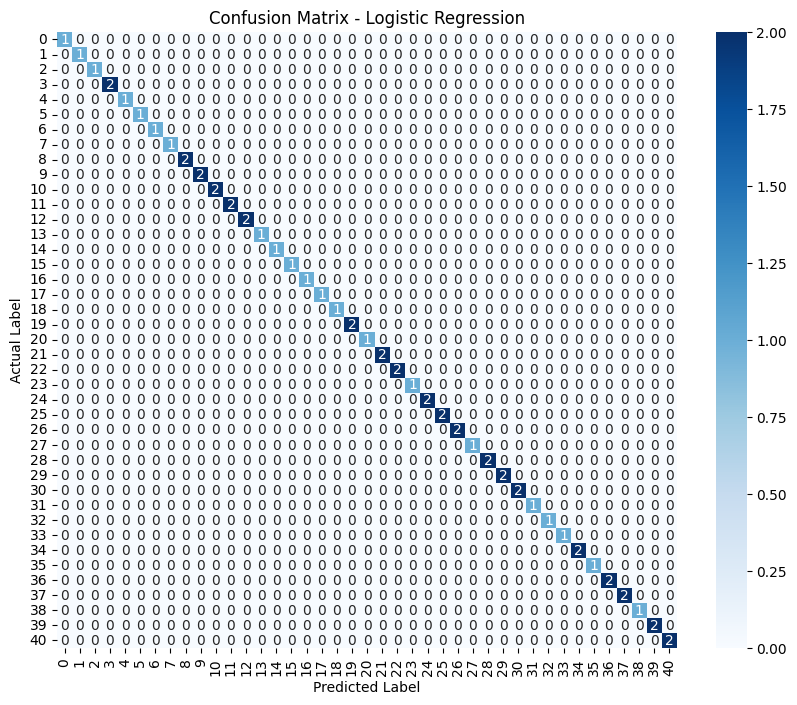

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test_clean, best_y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

In [ ]:
import joblib

# Save the best model
joblib.dump(best_model, "/content/logistic_regression_model.pkl")

print("✅ Logistic Regression model saved successfully!")

✅ Logistic Regression model saved successfully!


In [ ]:
def predict_disease(symptoms):
    # Create a row with all symptoms set to 0
    input_data = pd.DataFrame(
        0,
        index=[0],
        columns=X_clean.columns
    )

    # Set selected symptoms to 1
    for symptom in symptoms:
        if symptom in input_data.columns:
            input_data.loc[0, symptom] = 1

    # Predict disease
    prediction = best_model.predict(input_data)

    return prediction[0]


print("✅ Prediction function created successfully!")

✅ Prediction function created successfully!


In [ ]:
test_symptoms = [
    "itching",
    "skin_rash",
    "nodal_skin_eruptions"
]

predicted_disease = predict_disease(test_symptoms)

print("Symptoms:", test_symptoms)
print("Predicted Disease:", predicted_disease)

Symptoms: ['itching', 'skin_rash', 'nodal_skin_eruptions']
Predicted Disease: Fungal infection


In [ ]:
def predict_disease_with_probability(symptoms):
    # Create input row with all symptoms as 0
    input_data = pd.DataFrame(
        0,
        index=[0],
        columns=X_clean.columns
    )

    # Set selected symptoms to 1
    for symptom in symptoms:
        if symptom in input_data.columns:
            input_data.loc[0, symptom] = 1

    # Predict disease
    prediction = best_model.predict(input_data)[0]

    # Get prediction probabilities
    probabilities = best_model.predict_proba(input_data)[0]

    # Get probability of predicted disease
    predicted_index = list(best_model.classes_).index(prediction)
    probability = probabilities[predicted_index] * 100

    return prediction, probability


print("✅ Prediction probability function created successfully!")

✅ Prediction probability function created successfully!


In [ ]:
test_symptoms = [
    "itching",
    "skin_rash",
    "nodal_skin_eruptions"
]

predicted_disease, probability = predict_disease_with_probability(test_symptoms)

print("Symptoms:", test_symptoms)
print("Predicted Disease:", predicted_disease)
print("Prediction Probability:", round(probability, 2), "%")

Symptoms: ['itching', 'skin_rash', 'nodal_skin_eruptions']
Predicted Disease: Fungal infection
Prediction Probability: 48.36 %


In [ ]:
def top_3_predictions(symptoms):
    # Create input row
    input_data = pd.DataFrame(
        0,
        index=[0],
        columns=X_clean.columns
    )

    # Set selected symptoms to 1
    for symptom in symptoms:
        if symptom in input_data.columns:
            input_data.loc[0, symptom] = 1

    # Get probabilities for all diseases
    probabilities = best_model.predict_proba(input_data)[0]

    # Get top 3 indexes
    top_3_indices = probabilities.argsort()[-3:][::-1]

    print("🩺 Top 3 Possible Predictions:\n")

    for index in top_3_indices:
        disease = best_model.classes_[index]
        probability = probabilities[index] * 100

        print(
            f"{disease} → {probability:.2f}%"
        )


print("✅ Top-3 prediction function created successfully!")

✅ Top-3 prediction function created successfully!


In [ ]:
test_symptoms = [
    "itching",
    "skin_rash",
    "nodal_skin_eruptions"
]
top_3_predictions(test_symptoms)

🩺 Top 3 Possible Predictions:

Fungal infection → 48.36%
Drug Reaction → 8.50%
Acne → 3.44%


In [ ]:
def validate_symptoms(symptoms):
    valid_symptoms = []
    invalid_symptoms = []

    for symptom in symptoms:
        if symptom in X_clean.columns:
            valid_symptoms.append(symptom)
        else:
            invalid_symptoms.append(symptom)

    return valid_symptoms, invalid_symptoms


print("✅ Symptom validation function created successfully!")

✅ Symptom validation function created successfully!


In [ ]:
def smart_predict(symptoms):
    # Validate symptoms
    valid_symptoms, invalid_symptoms = validate_symptoms(symptoms)

    # Check for invalid symptoms
    if invalid_symptoms:
        print("⚠️ Invalid symptoms found:")
        print(invalid_symptoms)

    # Check if no valid symptoms were provided
    if len(valid_symptoms) == 0:
        print("❌ Please enter at least one valid symptom.")
        return

    # Get prediction and probability
    disease, probability = predict_disease_with_probability(valid_symptoms)

    print("\n🩺 SMART MEDICAL DIAGNOSIS SYSTEM")
    print("----------------------------------")
    print("Valid Symptoms:", valid_symptoms)
    print("Predicted Disease:", disease)
    print("Prediction Probability:", round(probability, 2), "%")

    if invalid_symptoms:
        print("Ignored Symptoms:", invalid_symptoms)


print("✅ Complete prediction system created successfully!")

✅ Complete prediction system created successfully!


In [ ]:
user_symptoms = [
    "itching",
    "skin_rash",
    "nodal_skin_eruptions"
]

smart_predict(user_symptoms)


🩺 SMART MEDICAL DIAGNOSIS SYSTEM
----------------------------------
Valid Symptoms: ['itching', 'skin_rash', 'nodal_skin_eruptions']
Predicted Disease: Fungal infection
Prediction Probability: 48.36 %


In [ ]:
import joblib

model_package = {
    "model": best_model,
    "features": list(X_clean.columns)
}

joblib.dump(
    model_package,
    "/content/smart_medical_diagnosis_model.pkl"
)

print("✅ Complete model package saved successfully!")
print("Number of features saved:", len(X_clean.columns))

✅ Complete model package saved successfully!
Number of features saved: 132


In [ ]:
!pip install streamlit -q

print("✅ Streamlit installed successfully!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 60.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 45.0 MB/s eta 0:00:00
✅ Streamlit installed successfully!


In [ ]:
%%writefile app.py

import streamlit as st
import pandas as pd
import joblib

# Load model package
model_package = joblib.load("smart_medical_diagnosis_model.pkl")

model = model_package["model"]
features = model_package["features"]

# Page configuration
st.set_page_config(
    page_title="Smart Medical Diagnosis System",
    page_icon="🩺",
    layout="wide"
)

# Title
st.title("🩺 Smart Medical Diagnosis System")
st.write("Select your symptoms to get a predicted disease.")

st.divider()

# Symptom selection
selected_symptoms = st.multiselect(
    "Select Symptoms",
    features
)

# Prediction button
if st.button("🔍 Predict Disease"):

    if len(selected_symptoms) == 0:
        st.warning("⚠️ Please select at least one symptom.")

    else:
        # Create input dataframe
        input_data = pd.DataFrame(
            0,
            index=[0],
            columns=features
        )

        # Set selected symptoms to 1
        for symptom in selected_symptoms:
            input_data.loc[0, symptom] = 1

        # Prediction
        prediction = model.predict(input_data)[0]

        # Probability
        probabilities = model.predict_proba(input_data)[0]
        predicted_index = list(model.classes_).index(prediction)
        probability = probabilities[predicted_index] * 100

        st.success(f"Predicted Disease: {prediction}")
        st.info(f"Prediction Probability: {probability:.2f}%")

st.divider()

st.caption(
    "Educational decision-support prototype — not a substitute for professional medical advice."
)

Writing app.py


In [ ]:
!streamlit run app.py &>/content/streamlit.log &

print("✅ Streamlit app started successfully!")

✅ Streamlit app started successfully!


In [ ]:
from pyngrok import ngrok

ngrok.set_auth_token("3ItRYW4JDAKqBiGd4wOqOFOBmiB_7UHac5JZdMeHgHTQBQtbp")

print("✅ Ngrok authentication configured!")

✅ Ngrok authentication configured!


In [ ]:
from pyngrok import ngrok

public_url = ngrok.connect(8501)

print("🌐 Smart Medical Diagnosis App:")
print(public_url)

🌐 Smart Medical Diagnosis App:
NgrokTunnel: "https://quickness-swiftness-mossy.ngrok-free.dev" -> "http://localhost:8501"


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import shutil
import os

base = "/content/drive/MyDrive/Smart Medical Diagnosis System"

# Create/check folders
os.makedirs(f"{base}/Dataset", exist_ok=True)
os.makedirs(f"{base}/Model", exist_ok=True)
os.makedirs(f"{base}/VS_Code", exist_ok=True)

# Copy archive.zip
if os.path.exists("/content/archive.zip"):
    shutil.copy2(
        "/content/archive.zip",
        f"{base}/Dataset/archive.zip"
    )
    print("✅ archive.zip → Dataset")

# Copy model
if os.path.exists("/content/smart_medical_diagnosis_model.pkl"):
    shutil.copy2(
        "/content/smart_medical_diagnosis_model.pkl",
        f"{base}/Model/smart_medical_diagnosis_model.pkl"
    )
    print("✅ Model → Model")

# Copy app.py
if os.path.exists("/content/app.py"):
    shutil.copy2(
        "/content/app.py",
        f"{base}/VS_Code/app.py"
    )
    print("✅ app.py → VS_Code")

print("\n🎉 Backup completed!")

✅ archive.zip → Dataset

🎉 Backup completed!


In [ ]:
import os

print("🔍 Searching for app.py and model file...\n")

for root, dirs, files in os.walk("/content"):
    for file in files:
        if file == "app.py" or file.endswith(".pkl"):
            print(os.path.join(root, file))

🔍 Searching for app.py and model file...



In [ ]:
import os

path = "/content/drive/MyDrive/Smart Medical Diagnosis System/Dataset"

print("Files inside Dataset folder:")

for file in os.listdir(path):
    print("✅", file)

Files inside Dataset folder:
✅ archive.zip


In [ ]:
import os

main_folder = "/content/drive/MyDrive/Smart_Medical_Diagnosis_System"
dataset_folder = main_folder + "/Dataset"

print("Main folder exists:", os.path.exists(main_folder))
print("Dataset folder exists:", os.path.exists(dataset_folder))

Main folder exists: True
Dataset folder exists: True


In [ ]:
import shutil
import os

source = "/content/drive/MyDrive/Smart Medical Diagnosis System/Dataset/archive.zip"
destination = "/content/drive/MyDrive/Smart_Medical_Diagnosis_System/Dataset/archive.zip"

shutil.copy2(source, destination)

print("✅ archive.zip copied successfully!")
print("📁 Location: Smart_Medical_Diagnosis_System → Dataset")

✅ archive.zip copied successfully!
📁 Location: Smart_Medical_Diagnosis_System → Dataset


In [ ]:
import os

print("🔍 Searching for Training.csv...\n")

for root, dirs, files in os.walk("/content/drive/MyDrive"):
    if "Training.csv" in files:
        print("✅ Found:", os.path.join(root, "Training.csv"))

🔍 Searching for Training.csv...



In [ ]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/Smart_Medical_Diagnosis_System/Dataset/archive.zip"
extract_path = "/content/drive/MyDrive/Smart_Medical_Diagnosis_System/Dataset"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("✅ archive.zip extracted successfully!")
print("\n📁 Files inside Dataset folder:")

for root, dirs, files in os.walk(extract_path):
    for file in files:
        print(os.path.join(root, file))

✅ archive.zip extracted successfully!

📁 Files inside Dataset folder:
/content/drive/MyDrive/Smart_Medical_Diagnosis_System/Dataset/archive.zip
/content/drive/MyDrive/Smart_Medical_Diagnosis_System/Dataset/Testing.csv
/content/drive/MyDrive/Smart_Medical_Diagnosis_System/Dataset/Training.csv


In [ ]:
import pandas as pd
import joblib
from sklearn.linear_model import LogisticRegression

# Load dataset
training_data = pd.read_csv(
    "/content/drive/MyDrive/Smart_Medical_Diagnosis_System/Dataset/Training.csv"
)

# Remove unwanted column
if "Unnamed: 133" in training_data.columns:
    training_data = training_data.drop(columns=["Unnamed: 133"])

# Features and target
X = training_data.drop(columns=["prognosis"])
y = training_data["prognosis"]

# Remove duplicate rows
data_clean = X.copy()
data_clean["target"] = y.values
data_clean = data_clean.drop_duplicates()

X_clean = data_clean.drop(columns=["target"])
y_clean = data_clean["target"]

# Train Logistic Regression
best_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

best_model.fit(X_clean, y_clean)

# Create model package
model_package = {
    "model": best_model,
    "features": list(X_clean.columns)
}

# Save to Drive
model_path = "/content/drive/MyDrive/Smart_Medical_Diagnosis_System/Model/smart_medical_diagnosis_model.pkl"

joblib.dump(model_package, model_path)

print("✅ Model trained successfully!")
print("✅ Model saved successfully!")
print("📁 Location:", model_path)
print("📊 Features:", len(X_clean.columns))

✅ Model trained successfully!
✅ Model saved successfully!
📁 Location: /content/drive/MyDrive/Smart_Medical_Diagnosis_System/Model/smart_medical_diagnosis_model.pkl
📊 Features: 132


In [ ]:
import os

main_folder = "/content/drive/MyDrive/Smart_Medical_Diagnosis_System"

print("📁 Main project folder:")
print(main_folder)

print("\n📂 Folders inside it:\n")

for item in os.listdir(main_folder):
    full_path = os.path.join(main_folder, item)

    if os.path.isdir(full_path):
        print("📁", item)
    else:
        print("📄", item)

📁 Main project folder:
/content/drive/MyDrive/Smart_Medical_Diagnosis_System

📂 Folders inside it:

📄 Smart_Medical_Diagnosis_System.ipynb
📁 Colab
📁 Dataset
📁 Model
📁 VS_code
📁 Screenshots


In [ ]:
app_path = "/content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/app.py"

with open(app_path, "w") as f:
    f.write(app_code)

print("✅ app.py saved successfully!")
print("📁 Location:", app_path)

✅ app.py saved successfully!
📁 Location: /content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/app.py


In [ ]:
import os

backup_path = "/content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/app_backup.py"

if os.path.exists(backup_path):
    print("✅ Backup file confirmed!")
    print("📁", backup_path)
else:
    print("❌ Backup file not found!")

❌ Backup file not found!


In [ ]:
!pip install streamlit plotly -q

print("✅ UI packages installed successfully!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 33.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 35.4 MB/s eta 0:00:00
✅ UI packages installed successfully!


In [ ]:
import os

pages_folder = "/content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/pages"

os.makedirs(pages_folder, exist_ok=True)

print("✅ Pages folder created successfully!")
print("📁 Location:", pages_folder)

✅ Pages folder created successfully!
📁 Location: /content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/pages


In [ ]:
import os

app_path = "/content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/app.py"

home_code = '''
import streamlit as st

st.set_page_config(
    page_title="Smart Medical Diagnosis System",
    page_icon="🩺",
    layout="wide"
)

st.markdown("""
<style>
.hero {
    text-align: center;
    padding: 50px 20px 35px;
}

.hero h1 {
    font-size: 48px;
    font-weight: 800;
    letter-spacing: 1px;
}

.hero p {
    font-size: 19px;
    color: #666;
}

.badge {
    display: inline-block;
    padding: 8px 18px;
    border-radius: 25px;
    background: #eef4ff;
    color: #3157d5;
    font-weight: 600;
    margin-bottom: 18px;
}

.card {
    padding: 25px;
    border-radius: 18px;
    background: #f8faff;
    border: 1px solid #e5e9f2;
    text-align: center;
    min-height: 150px;
}

.section-title {
    text-align: center;
    font-size: 30px;
    font-weight: 750;
    margin-top: 45px;
    margin-bottom: 25px;
}

.footer {
    text-align: center;
    color: #777;
    padding: 30px;
    font-size: 13px;
}
</style>
""", unsafe_allow_html=True)

st.markdown("""
<div class="hero">
<div class="badge">🤖 AI-POWERED HEALTHCARE DECISION SUPPORT</div>

<h1>SMART MEDICAL DIAGNOSIS SYSTEM</h1>

<p>
An intelligent machine-learning prototype that analyzes symptoms
and provides possible disease predictions.
</p>
</div>
""", unsafe_allow_html=True)

col1, col2, col3 = st.columns([1, 1, 1])

with col2:
    if st.button("🩺 START DIAGNOSIS", use_container_width=True):
        st.switch_page("pages/1_🩺_Diagnosis.py")

st.markdown(
    '<div class="section-title">How It Works</div>',
    unsafe_allow_html=True
)

c1, c2, c3 = st.columns(3)

with c1:
    st.markdown("""
    <div class="card">
    <h2>🔍</h2>
    <h3>Select Symptoms</h3>
    <p>Choose the symptoms experienced by the user.</p>
    </div>
    """, unsafe_allow_html=True)

with c2:
    st.markdown("""
    <div class="card">
    <h2>🧠</h2>
    <h3>AI Analysis</h3>
    <p>The trained machine-learning model analyzes the selected symptoms.</p>
    </div>
    """, unsafe_allow_html=True)

with c3:
    st.markdown("""
    <div class="card">
    <h2>📊</h2>
    <h3>Prediction</h3>
    <p>Get a predicted disease with probability information.</p>
    </div>
    """, unsafe_allow_html=True)

st.markdown(
    '<div class="section-title">Project Highlights</div>',
    unsafe_allow_html=True
)

h1, h2, h3, h4 = st.columns(4)

with h1:
    st.metric("Symptoms", "132")

with h2:
    st.metric("ML Models", "4")

with h3:
    st.metric("Best Model", "Logistic Regression")

with h4:
    st.metric("Platform", "Streamlit")

st.markdown("""
<div class="footer">

⚠️ Educational decision-support prototype only.
This application is not a substitute for professional medical advice.

<br><br>

<strong>Smart Medical Diagnosis System</strong> · AI/ML Project

</div>
""", unsafe_allow_html=True)
'''

with open(app_path, "w") as f:
    f.write(home_code)

print("✅ Premium Home page created successfully!")
print("📁 app.py updated in VS_code folder.")

✅ Premium Home page created successfully!
📁 app.py updated in VS_code folder.


In [ ]:
import os

diagnosis_path = "/content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/pages/1_🩺_Diagnosis.py"

diagnosis_code = '''
import streamlit as st
import pandas as pd
import joblib

st.set_page_config(
    page_title="Diagnosis | Smart Medical Diagnosis",
    page_icon="🩺",
    layout="wide"
)

# Load model
model_path = "../Model/smart_medical_diagnosis_model.pkl"
model_package = joblib.load(model_path)

model = model_package["model"]
features = model_package["features"]

# ---------- CUSTOM CSS ----------
st.markdown("""
<style>

.title {
    text-align: center;
    font-size: 40px;
    font-weight: 800;
    margin-bottom: 5px;
}

.subtitle {
    text-align: center;
    color: #666;
    font-size: 17px;
    margin-bottom: 35px;
}

.result-card {
    padding: 30px;
    border-radius: 20px;
    background: #f4f8ff;
    border: 1px solid #dce6f7;
    text-align: center;
    margin-top: 25px;
}

.result-disease {
    font-size: 32px;
    font-weight: 800;
    margin: 10px;
}

.probability {
    font-size: 22px;
    font-weight: 700;
}

.info-card {
    padding: 20px;
    border-radius: 16px;
    background: #fafafa;
    border: 1px solid #e5e5e5;
}

</style>
""", unsafe_allow_html=True)

# ---------- HEADER ----------
st.markdown(
    '<div class="title">🩺 AI SYMPTOM ANALYSIS</div>',
    unsafe_allow_html=True
)

st.markdown(
    '<div class="subtitle">Select your symptoms and let the machine-learning model analyze the pattern.</div>',
    unsafe_allow_html=True
)

# ---------- SYMPTOM SELECTION ----------
st.subheader("🔍 Select Symptoms")

selected_symptoms = st.multiselect(
    "Search and select symptoms",
    options=features,
    placeholder="Type to search symptoms..."
)

if selected_symptoms:
    st.write("**Selected Symptoms:**")

    cols = st.columns(min(len(selected_symptoms), 4))

    for i, symptom in enumerate(selected_symptoms):
        with cols[i % len(cols)]:
            st.info(f"✓ {symptom}")

st.write("")

# ---------- PREDICT ----------
if st.button("🔬 ANALYZE SYMPTOMS", use_container_width=True):

    if not selected_symptoms:

        st.warning("⚠️ Please select at least one symptom.")

    else:

        input_data = pd.DataFrame(
            0,
            index=[0],
            columns=features
        )

        for symptom in selected_symptoms:
            input_data.loc[0, symptom] = 1

        prediction = model.predict(input_data)[0]

        probabilities = model.predict_proba(input_data)[0]

        predicted_index = list(model.classes_).index(prediction)

        probability = probabilities[predicted_index] * 100

        # ---------- RESULT ----------
        st.markdown("""
        <div class="result-card">
        <div>🧠 AI PREDICTION</div>
        """, unsafe_allow_html=True)

        st.markdown(
            f'<div class="result-disease">{prediction}</div>',
            unsafe_allow_html=True
        )

        st.markdown(
            f'<div class="probability">Prediction Probability: {probability:.2f}%</div>',
            unsafe_allow_html=True
        )

        st.markdown("</div>", unsafe_allow_html=True)

        # ---------- TOP 3 ----------
        st.subheader("🏆 Top 3 Possible Predictions")

        top_indices = probabilities.argsort()[-3:][::-1]

        for rank, index in enumerate(top_indices, start=1):

            disease = model.classes_[index]
            prob = probabilities[index] * 100

            st.progress(
                float(prob / 100),
                text=f"{rank}. {disease} — {prob:.2f}%"
            )

        # ---------- SELECTED SYMPTOMS ----------
        st.subheader("📋 Analysis Summary")

        st.markdown(
            f"""
            <div class="info-card">
            <b>Symptoms analyzed:</b> {len(selected_symptoms)}<br><br>
            <b>Machine-learning model:</b> Logistic Regression<br><br>
            <b>Prediction:</b> {prediction}
            </div>
            """,
            unsafe_allow_html=True
        )

        st.caption(
            "⚠️ This is an educational decision-support prototype and not a substitute for professional medical advice."
        )
'''

os.makedirs(os.path.dirname(diagnosis_path), exist_ok=True)

with open(diagnosis_path, "w") as f:
    f.write(diagnosis_code)

print("✅ Diagnosis page created successfully!")
print("📁 Saved inside VS_code → pages")

✅ Diagnosis page created successfully!
📁 Saved inside VS_code → pages


In [ ]:
import os

insights_path = "/content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/pages/2_📊_Model_Insights.py"

insights_code = '''
import streamlit as st
import pandas as pd
import joblib

st.set_page_config(
    page_title="Model Insights | Smart Medical Diagnosis",
    page_icon="📊",
    layout="wide"
)

# Load model
model_path = "../Model/smart_medical_diagnosis_model.pkl"
model_package = joblib.load(model_path)

model = model_package["model"]
features = model_package["features"]

# ---------- PAGE TITLE ----------
st.markdown(
    "<h1 style='text-align:center;'>📊 MODEL INSIGHTS</h1>",
    unsafe_allow_html=True
)

st.markdown(
    "<p style='text-align:center;color:#666;'>Explore the machine-learning pipeline and model performance.</p>",
    unsafe_allow_html=True
)

st.divider()

# ---------- PROJECT OVERVIEW ----------
st.subheader("🧠 Machine Learning Overview")

c1, c2, c3, c4 = st.columns(4)

with c1:
    st.metric("Input Features", len(features))

with c2:
    st.metric("ML Models", "4")

with c3:
    st.metric("Selected Model", "Logistic Regression")

with c4:
    st.metric("Learning Type", "Supervised")

st.divider()

# ---------- ML PIPELINE ----------
st.subheader("⚙️ Machine Learning Pipeline")

pipeline = [
    ("1", "📂 Dataset", "Training & testing medical symptom data"),
    ("2", "🧹 Data Cleaning", "Removed unwanted columns and duplicates"),
    ("3", "🔀 Data Split", "Training and validation data separation"),
    ("4", "🤖 Model Training", "Multiple ML algorithms trained"),
    ("5", "🏆 Model Selection", "Best model selected using F1-score"),
    ("6", "🩺 Prediction", "Symptoms converted into model features")
]

for number, title, description in pipeline:

    st.markdown(
        f"""
        <div style="
            padding:18px;
            margin:10px 0;
            border-radius:15px;
            border:1px solid #e2e6ef;
            background:#f8faff;
        ">
        <b style="font-size:18px;">{number}. {title}</b>
        <br>
        <span style="color:#666;">{description}</span>
        </div>
        """,
        unsafe_allow_html=True
    )

st.divider()

# ---------- MODELS ----------
st.subheader("🤖 Models Evaluated")

models_data = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Support Vector Machine",
        "Gradient Boosting"
    ],
    "Type": [
        "Linear Classification",
        "Ensemble Learning",
        "Kernel-based Classification",
        "Ensemble Learning"
    ]
})

st.dataframe(
    models_data,
    use_container_width=True,
    hide_index=True
)

st.divider()

# ---------- DATASET ----------
st.subheader("📁 Dataset Information")

d1, d2 = st.columns(2)

with d1:
    st.info("**Original Training Rows**\n\n4,920")

with d2:
    st.info("**Unique Samples After Cleaning**\n\n304")

st.divider()

# ---------- BEST MODEL ----------
st.subheader("🏆 Selected Model")

st.success(
    "Logistic Regression was selected as the best-performing model "
    "based on the evaluation metrics calculated during model comparison."
)

st.markdown("""
### Why Logistic Regression?

- Simple and interpretable classification algorithm
- Efficient for high-dimensional binary symptom features
- Provides probability estimates
- Suitable for multi-class disease classification
- Easy to integrate into a real-time prediction application
""")

st.divider()

# ---------- TECHNOLOGY STACK ----------
st.subheader("🛠️ Technology Stack")

tech1, tech2, tech3, tech4, tech5 = st.columns(5)

with tech1:
    st.markdown("🐍 **Python**")

with tech2:
    st.markdown("🐼 **Pandas**")

with tech3:
    st.markdown("🧠 **Scikit-learn**")

with tech4:
    st.markdown("📊 **Plotly**")

with tech5:
    st.markdown("🌐 **Streamlit**")

st.divider()

st.caption(
    "Educational AI/ML decision-support prototype — not a substitute for professional medical advice."
)
'''

with open(insights_path, "w") as f:
    f.write(insights_code)

print("✅ Model Insights page created successfully!")
print("📁 Saved inside VS_code → pages")

✅ Model Insights page created successfully!
📁 Saved inside VS_code → pages


In [ ]:
import os

os.chdir("/content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code")

!streamlit run app.py &>/content/streamlit.log &

print("✅ Streamlit app started!")
print("📍 App running on port 8501")

✅ Streamlit app started!
📍 App running on port 8501


In [ ]:
import requests

response = requests.get("http://localhost:8501")

print("✅ Streamlit app status:", response.status_code)

✅ Streamlit app status: 200


In [ ]:
from google.colab import output

output.serve_kernel_port_as_window(8501)

Try `serve_kernel_port_as_iframe` instead. 


<IPython.core.display.Javascript object>

In [ ]:
from google.colab import output

output.serve_kernel_port_as_iframe(8501)

<IPython.core.display.Javascript object>

In [ ]:
import requests

url = "http://localhost:8501"

try:
    r = requests.get(url, timeout=10)
    print("✅ Streamlit is running")
    print("Status:", r.status_code)
    print("URL:", url)
except Exception as e:
    print("❌ Streamlit is not running")
    print(e)

✅ Streamlit is running
Status: 200
URL: http://localhost:8501


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

main_folder = "/content/drive/MyDrive/Smart_Medical_Diagnosis_System"

print("Main folder exists:", os.path.exists(main_folder))

if os.path.exists(main_folder):
    print("\n📁 Folder contents:")
    for item in os.listdir(main_folder):
        print(" -", item)

Main folder exists: True

📁 Folder contents:
 - Smart_Medical_Diagnosis_System.ipynb
 - Colab
 - Dataset
 - Model
 - VS_code
 - Screenshots


In [ ]:
import os

vs_folder = "/content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code"

print("VS_code folder exists:", os.path.exists(vs_folder))

if os.path.exists(vs_folder):
    print("\n📁 VS_code contents:")
    for item in os.listdir(vs_folder):
        print(" -", item)

VS_code folder exists: True

📁 VS_code contents:
 - pages
 - app.py


In [ ]:
import os

app_file = "/content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/app.py"

print("✅ app.py exists:", os.path.exists(app_file))

if os.path.exists(app_file):
    print("📄 app.py found successfully!")
    print("📍 Location:", app_file)

    with open(app_file, "r", encoding="utf-8") as f:
        code = f.read()

    print("📌 Number of lines:", len(code.splitlines()))

✅ app.py exists: True
📄 app.py found successfully!
📍 Location: /content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/app.py
📌 Number of lines: 147


In [ ]:
%%writefile /content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/app.py

import streamlit as st
import joblib

st.set_page_config(
    page_title="Smart Medical Diagnosis System",
    page_icon="🩺",
    layout="wide",
    initial_sidebar_state="collapsed"
)

# Load model
model_package = joblib.load("Model/smart_medical_diagnosis_model.pkl")
features = model_package["features"]

symptom_count = len(features)

# Premium styling
st.markdown("""
<style>
#MainMenu {visibility:hidden;}
footer {visibility:hidden;}
header {visibility:hidden;}

.stApp {
    background:
    radial-gradient(circle at 10% 10%, rgba(99,102,241,.18), transparent 30%),
    radial-gradient(circle at 90% 20%, rgba(20,184,166,.12), transparent 28%),
    linear-gradient(135deg,#07111f,#0d1930,#111b35);
    color:white;
}

.block-container {
    max-width:1200px;
    padding-top:2rem;
}

.hero {
    text-align:center;
    padding:60px 20px 35px;
}

.badge {
    display:inline-block;
    padding:9px 18px;
    border-radius:30px;
    background:rgba(99,102,241,.15);
    border:1px solid rgba(129,140,248,.35);
    color:#c7d2fe;
    font-size:13px;
    font-weight:700;
    letter-spacing:1.5px;
}

.hero h1 {
    font-size:56px;
    line-height:1.08;
    font-weight:850;
    margin:22px 0 15px;
    background:linear-gradient(90deg,#ffffff,#c7d2fe,#99f6e4);
    -webkit-background-clip:text;
    -webkit-text-fill-color:transparent;
}

.hero p {
    color:#a8b4c7;
    font-size:20px;
}

.section-title {
    text-align:center;
    font-size:28px;
    font-weight:750;
    margin:55px 0 25px;
}

.card {
    background:rgba(255,255,255,.055);
    border:1px solid rgba(255,255,255,.10);
    border-radius:20px;
    padding:28px;
    min-height:180px;
}

.card-icon {
    font-size:32px;
}

.card h3 {
    margin:10px 0;
    color:#f8fafc;
}

.card p {
    color:#aab6c8;
    line-height:1.6;
}

.metric {
    text-align:center;
    background:rgba(255,255,255,.055);
    border:1px solid rgba(255,255,255,.10);
    border-radius:18px;
    padding:22px 10px;
}

.metric-value {
    font-size:30px;
    font-weight:800;
    color:#c7d2fe;
}

.metric-label {
    color:#94a3b8;
    font-size:13px;
}

.cta {
    text-align:center;
    margin-top:45px;
    padding:35px;
    border-radius:24px;
    background:linear-gradient(
        135deg,
        rgba(79,70,229,.20),
        rgba(20,184,166,.10)
    );
    border:1px solid rgba(129,140,248,.25);
}

.disclaimer {
    margin-top:35px;
    padding:16px;
    border-radius:14px;
    background:rgba(245,158,11,.07);
    border:1px solid rgba(245,158,11,.20);
    color:#cbd5e1;
    font-size:12px;
    text-align:center;
}

.footer {
    text-align:center;
    margin-top:35px;
    padding-top:20px;
    border-top:1px solid rgba(255,255,255,.08);
    color:#64748b;
    font-size:12px;
}

.stButton > button {
    border-radius:12px;
    background:linear-gradient(90deg,#4f46e5,#6366f1);
    color:white;
    font-weight:700;
    border:1px solid rgba(129,140,248,.45);
    padding:.65rem 1.5rem;
}

@media(max-width:768px) {
    .hero h1 {
        font-size:38px;
    }

    .hero p {
        font-size:16px;
    }
}
</style>
""", unsafe_allow_html=True)

# Hero
st.markdown("""
<div class="hero">
    <div class="badge">AI-POWERED HEALTHCARE DECISION SUPPORT</div>
    <h1>SMART MEDICAL<br>DIAGNOSIS SYSTEM</h1>
    <p>AI-powered healthcare decision support using Machine Learning</p>
</div>
""", unsafe_allow_html=True)



Overwriting /content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/app.py


In [ ]:
import os
import time

os.chdir("/content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code")

!pkill -f "streamlit run" || true

!streamlit run app.py > /content/streamlit.log 2>&1 &

time.sleep(5)

print("🚀 Streamlit restarted successfully!")
print("📍 Running on: http://localhost:8501")

^C
🚀 Streamlit restarted successfully!
📍 Running on: http://localhost:8501


In [ ]:
import requests

try:
    response = requests.get("http://localhost:8501", timeout=10)

    print("🌐 Streamlit Status:", response.status_code)

    if response.status_code == 200:
        print("✅ Home page is loading successfully!")
    else:
        print("⚠️ Streamlit responded with:", response.status_code)

except Exception as e:
    print("❌ Error:", e)

❌ Error: HTTPConnectionPool(host='localhost', port=8501): Max retries exceeded with url: / (Caused by NewConnectionError('<urllib3.connection.HTTPConnection object at 0x7b7187fd3380>: Failed to establish a new connection: [Errno 111] Connection refused'))


In [ ]:
print("Streamlit log:")
print(open("/content/streamlit.log",
"r").read())

Streamlit log:
/bin/bash: line 1: streamlit: command not found



In [ ]:
!pip install streamlit -q
print("Streamlit installed successfully!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 49.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 62.3 MB/s eta 0:00:00
Streamlit installed successfully!


In [ ]:
import importlib.util

if importlib.util.find_spec("streamlit"):
    print("✅ Streamlit is installed in this runtime")
else:
    print("❌ Streamlit is NOT installed in this runtime")

✅ Streamlit is installed in this runtime


In [ ]:
import os
import time

os.chdir("/content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code")

!python -m streamlit run app.py > /content/streamlit.log 2>&1 &

time.sleep(5)

print("🚀 Streamlit started!")
print("📍 URL: http://localhost:8501")

🚀 Streamlit started!
📍 URL: http://localhost:8501


In [ ]:
import requests

try:
    response = requests.get("http://localhost:8501", timeout=10)

    print("🌐 Streamlit Status:", response.status_code)

    if response.status_code == 200:
        print("✅ Streamlit app is running successfully!")
    else:
        print("⚠️ App responded with:", response.status_code)

except Exception as e:
    print("❌ Connection error:", e)

🌐 Streamlit Status: 200
✅ Streamlit app is running successfully!


In [ ]:
import shutil
import os

diagnosis_file = "/content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/pages/1_🩺_Diagnosis.py"
backup_file = "/content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/pages/1_🩺_Diagnosis_backup.py"

if os.path.exists(diagnosis_file):
    shutil.copy2(diagnosis_file, backup_file)
    print("✅ Diagnosis page backup created!")
    print("📁 Backup:", backup_file)
else:
    print("❌ Diagnosis page not found!")

✅ Diagnosis page backup created!
📁 Backup: /content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/pages/1_🩺_Diagnosis_backup.py


In [ ]:
%%writefile /content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/pages/1_🩺_Diagnosis.py

import streamlit as st
import pandas as pd
import joblib

# --------------------------------------------------
# PAGE CONFIG
# --------------------------------------------------
st.set_page_config(
    page_title="Diagnosis | Smart Medical Diagnosis",
    page_icon="🩺",
    layout="wide"
)

# --------------------------------------------------
# LOAD MODEL
# --------------------------------------------------
model_path = "Model/smart_medical_diagnosis_model.pkl"

model_package = joblib.load(model_path)

model = model_package["model"]
features = model_package["features"]

# --------------------------------------------------
# PREMIUM CSS
# --------------------------------------------------
st.markdown("""
<style>

#MainMenu {visibility:hidden;}
footer {visibility:hidden;}
header {visibility:hidden;}

.stApp {
    background:
    radial-gradient(circle at 10% 10%, rgba(99,102,241,.16), transparent 30%),
    radial-gradient(circle at 90% 20%, rgba(20,184,166,.10), transparent 28%),
    linear-gradient(135deg,#07111f,#0d1930,#111b35);
    color:white;
}

.block-container {
    max-width:1200px;
    padding-top:2rem;
}

/* Header */
.page-header {
    text-align:center;
    padding:25px 10px 35px;
}

.page-header h1 {
    font-size:42px;
    font-weight:800;
    margin-bottom:10px;
    background:linear-gradient(90deg,#ffffff,#c7d2fe,#99f6e4);
    -webkit-background-clip:text;
    -webkit-text-fill-color:transparent;
}

.page-header p {
    color:#9caabd;
    font-size:17px;
}

/* Selection card */
.selection-card {
    background:rgba(255,255,255,.055);
    border:1px solid rgba(255,255,255,.10);
    border-radius:22px;
    padding:28px;
    margin-bottom:25px;
}

.card-title {
    font-size:22px;
    font-weight:750;
    color:#f8fafc;
    margin-bottom:7px;
}

.card-subtitle {
    color:#94a3b8;
    font-size:14px;
    margin-bottom:20px;
}

/* Selected symptom */
.symptom-chip {
    display:inline-block;
    padding:8px 14px;
    margin:4px;
    border-radius:20px;
    background:rgba(99,102,241,.15);
    border:1px solid rgba(129,140,248,.35);
    color:#c7d2fe;
    font-size:13px;
}

/* Result */
.result-card {
    background:linear-gradient(
        135deg,
        rgba(79,70,229,.17),
        rgba(20,184,166,.08)
    );
    border:1px solid rgba(129,140,248,.28);
    border-radius:24px;
    padding:32px;
    margin-top:25px;
    text-align:center;
}

.result-label {
    color:#94a3b8;
    font-size:14px;
    letter-spacing:1px;
    text-transform:uppercase;
}

.result-disease {
    color:#ffffff;
    font-size:36px;
    font-weight:800;
    margin:12px 0;
}

.probability {
    color:#99f6e4;
    font-size:22px;
    font-weight:700;
}

/* Info cards */
.info-card {
    background:rgba(255,255,255,.045);
    border:1px solid rgba(255,255,255,.08);
    border-radius:18px;
    padding:22px;
    min-height:145px;
}

.info-card h3 {
    font-size:18px;
    color:#f8fafc;
}

.info-card p {
    color:#aab6c8;
    font-size:14px;
    line-height:1.6;
}

/* Disclaimer */
.disclaimer {
    margin-top:35px;
    padding:17px;
    border-radius:14px;
    background:rgba(245,158,11,.07);
    border:1px solid rgba(245,158,11,.20);
    color:#cbd5e1;
    font-size:12px;
    text-align:center;
}

/* Button */
.stButton > button {
    border-radius:12px;
    background:linear-gradient(90deg,#4f46e5,#6366f1);
    color:white;
    font-weight:700;
    border:1px solid rgba(129,140,248,.45);
    padding:.65rem 1.5rem;
}

</style>
""", unsafe_allow_html=True)

# --------------------------------------------------
# PAGE HEADER
# --------------------------------------------------
st.markdown("""
<div class="page-header">
    <h1>🩺 AI SYMPTOM ANALYSIS</h1>
    <p>
        Select your symptoms and let the machine-learning model
        analyze the pattern.
    </p>
</div>
""", unsafe_allow_html=True)

# --------------------------------------------------
# SYMPTOM SELECTION
# --------------------------------------------------
st.markdown("""
<div class="selection-card">
    <div class="card-title">🔎 Select Your Symptoms</div>
    <div class="card-subtitle">
        Search and select one or more symptoms from the list below.
    </div>
</div>
""", unsafe_allow_html=True)

selected_symptoms = st.multiselect(
    "Symptoms",
    options=features,
    placeholder="Type to search symptoms...",
    label_visibility="collapsed"
)

# --------------------------------------------------
# SELECTED SYMPTOMS
# --------------------------------------------------
if selected_symptoms:

    st.markdown(
        f"### Selected Symptoms ({len(selected_symptoms)})"
    )

    chip_html = ""

    for symptom in selected_symptoms:
        chip_html += f'<span class="symptom-chip">✓ {symptom}</span>'

    st.markdown(chip_html, unsafe_allow_html=True)

# --------------------------------------------------
# ANALYZE BUTTON
# --------------------------------------------------
st.write("")

if st.button(
    "🧠  Analyze Symptoms",
    use_container_width=True
):

    if not selected_symptoms:

        st.warning(
            "⚠️ Please select at least one symptom before analysis."
        )

    else:

        # Create input
        input_data = pd.DataFrame(
            0,
            index=[0],
            columns=features
        )

        for symptom in selected_symptoms:
            input_data.loc[0, symptom] = 1

        # Prediction
        prediction = model.predict(input_data)[0]

        probabilities = model.predict_proba(input_data)[0]

        predicted_index = list(model.classes_).index(prediction)

        probability = probabilities[predicted_index] * 100

        # --------------------------------------------------
        # RESULT
        # --------------------------------------------------
        st.markdown(f"""
        <div class="result-card">

            <div class="result-label">
                AI Predicted Condition
            </div>

            <div class="result-disease">
                {prediction}
            </div>

            <div class="probability">
                Prediction Probability: {probability:.2f}%
            </div>

        </div>
        """, unsafe_allow_html=True)

        # --------------------------------------------------
        # TOP 3 PREDICTIONS
        # --------------------------------------------------
        st.markdown("### 📊 Top Possible Predictions")

        top_indices = probabilities.argsort()[-3:][::-1]

        for index in top_indices:

            disease = model.classes_[index]

            probability_value = probabilities[index] * 100

            col1, col2 = st.columns([2,1])

            with col1:
                st.write(f"**{disease}**")

            with col2:
                st.write(f"**{probability_value:.2f}%**")

            st.progress(
                min(float(probability_value) / 100, 1.0)
            )

        # --------------------------------------------------
        # ANALYSIS SUMMARY
        # --------------------------------------------------
        st.markdown("### 🧠 Analysis Summary")

        c1, c2, c3 = st.columns(3)

        with c1:
            st.markdown("""
            <div class="info-card">
                <h3>🔎 Symptoms</h3>
                <p>
                    The model analyzed the selected symptom pattern
                    as input features.
                </p>
            </div>
            """, unsafe_allow_html=True)

        with c2:
            st.markdown("""
            <div class="info-card">
                <h3>🤖 Model</h3>
                <p>
                    The prediction was generated using the trained
                    machine-learning model.
                </p>
            </div>
            """, unsafe_allow_html=True)

        with c3:
            st.markdown("""
            <div class="info-card">
                <h3>📊 Result</h3>
                <p>
                    The displayed probability represents the model's
                    prediction score for the selected condition.
                </p>
            </div>
            """, unsafe_allow_html=True)

# --------------------------------------------------
# DISCLAIMER
# --------------------------------------------------
st.markdown("""
<div class="disclaimer">
⚠️ <b>Medical Disclaimer:</b>
This application is an educational machine-learning
decision-support prototype. It does not provide a confirmed
medical diagnosis. Please consult a qualified healthcare
professional for medical advice.
</div>
""", unsafe_allow_html=True)

Overwriting /content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/pages/1_🩺_Diagnosis.py


In [ ]:
import py_compile

file_path = "/content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/pages/1_🩺_Diagnosis.py"

try:
    py_compile.compile(file_path, doraise=True)
    print("✅ Diagnosis page syntax is correct!")
except Exception as e:
    print("❌ Syntax error:")
    print(e)

✅ Diagnosis page syntax is correct!


In [ ]:
%%writefile /content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/requirements.txt
streamlit
pandas
numpy
scikit-learn
joblib
matplotlib
seaborn

Writing /content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/requirements.txt


In [ ]:
%%writefile /content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/README.md

# 🩺 Smart Medical Diagnosis System

## 📌 Project Overview

The **Smart Medical Diagnosis System** is an AI/ML-based educational decision-support application that analyzes selected symptoms and predicts a possible disease using a trained Machine Learning model.

The project demonstrates the complete Machine Learning workflow — from data preprocessing and duplicate handling to model training, evaluation, model deployment, and an interactive Streamlit interface.

> ⚠️ **Medical Disclaimer:** This project is developed for educational and demonstration purposes only. It is not intended to provide medical diagnosis, treatment, or professional medical advice.

---

## 🚀 Key Features

- 🩺 Interactive symptom selection
- 🔍 AI-based symptom analysis
- 🤖 Machine Learning disease prediction
- 📊 Prediction probability
- 🏆 Top 3 possible predictions
- 📈 Model insights and ML workflow
- 📋 Comparison of multiple Machine Learning models
- 💻 Interactive Streamlit web application
- 📱 Responsive and modern user interface

---

## 🔄 How It Works

```text
User
  ↓
Select Symptoms
  ↓
Input Validation
  ↓
Feature Transformation
  ↓
Trained ML Model
  ↓
Disease Prediction
  ↓
Probability Analysis
  ↓
Top 3 Predictions

Writing /content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/README.md


In [ ]:
%cd /content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code
!pip install -r requirements.txt

/content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 33.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 34.0 MB/s eta 0:00:00


In [ ]:
import os

base = "/content/drive/MyDrive/Smart_Medical_Diagnosis_System"

for root, dirs, files in os.walk(base):
    level = root.replace(base, "").count(os.sep)
    indent = "    " * level
    print(f"{indent}📁 {os.path.basename(root)}/")
    for file in files:
        print(f"{indent}    📄 {file}")

📁 Smart_Medical_Diagnosis_System/
    📄 Smart_Medical_Diagnosis_System.ipynb
    📁 Colab/
    📁 Dataset/
        📄 archive.zip
        📄 Testing.csv
        📄 Training.csv
    📁 Model/
        📄 smart_medical_diagnosis_model.pkl
    📁 VS_code/
        📄 app.py
        📄 requirements.txt
        📄 README.md
        📁 pages/
            📄 1_🩺_Diagnosis.py
            📄 2_📊_Model_Insights.py
            📄 1_🩺_Diagnosis_backup.py
            📁 __pycache__/
                📄 1_🩺_Diagnosis.cpython-313.pyc
    📁 Screenshots/


In [ ]:
%cd /content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code
!python -m streamlit run app.py > /content/streamlit.log 2>&1 &

/content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code


In [ ]:
import requests
print(requests.get("http://localhost:8501").status_code)

200


In [ ]:
from google.colab import output
output.serve_kernel_port_as_window(8501)

Try `serve_kernel_port_as_iframe` instead. 


<IPython.core.display.Javascript object>

In [ ]:
from google.colab import output
output.serve_kernel_port_as_iframe(8501)

<IPython.core.display.Javascript object>

In [ ]:
import os

frontend_path = "/content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/frontend_preview"

os.makedirs(frontend_path, exist_ok=True)

print("✅ frontend_preview folder created!")
print(frontend_path)

✅ frontend_preview folder created!
/content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/frontend_preview


In [ ]:
%%writefile /content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/frontend_preview/index.html
<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">

    <title>Smart Medical Diagnosis System</title>

    <link rel="stylesheet" href="style.css">
</head>

<body>

    <!-- Background Decorations -->
    <div class="orb orb-one"></div>
    <div class="orb orb-two"></div>

    <!-- Navigation -->
    <nav class="navbar">
        <div class="logo">
            🩺 <span>SMART MEDICAL</span>
        </div>

        <div class="nav-links">
            <a href="#home">Home</a>
            <a href="#how-it-works">How It Works</a>
            <a href="#highlights">Highlights</a>
        </div>
    </nav>


    <!-- Hero Section -->
    <section class="hero" id="home">

        <div class="hero-content">

            <div class="badge">
                ✦ AI-POWERED HEALTHCARE DECISION SUPPORT
            </div>

            <h1>
                SMART MEDICAL<br>
                <span>DIAGNOSIS SYSTEM</span>
            </h1>

            <p class="hero-text">
                An AI-powered healthcare decision-support prototype
                that analyzes selected symptoms and generates
                machine-learning based predictions.
            </p>

            <div class="hero-buttons">
                <a href="#how-it-works" class="primary-btn">
                    START DIAGNOSIS
                    <span>→</span>
                </a>

                <a href="#highlights" class="secondary-btn">
                    EXPLORE PROJECT
                </a>
            </div>

            <p class="hero-note">
                Built with Python • Machine Learning • Streamlit
            </p>

        </div>

    </section>


    <!-- How It Works -->
    <section class="section" id="how-it-works">

        <div class="section-heading">
            <p class="section-label">HOW IT WORKS</p>

            <h2>
                From Symptoms to
                <span>AI Analysis</span>
            </h2>

            <p>
                A simple workflow connecting user input with a trained
                machine-learning model.
            </p>
        </div>


        <div class="steps">

            <div class="step-card">
                <div class="step-number">01</div>
                <div class="step-icon">🔍</div>

                <h3>Select Symptoms</h3>

                <p>
                    Choose the symptoms from the available symptom
                    feature set.
                </p>
            </div>


            <div class="step-card">
                <div class="step-number">02</div>
                <div class="step-icon">🧠</div>

                <h3>AI Analysis</h3>

                <p>
                    The selected symptoms are processed and passed
                    to the trained ML model.
                </p>
            </div>


            <div class="step-card">
                <div class="step-number">03</div>
                <div class="step-icon">📊</div>

                <h3>Prediction</h3>

                <p>
                    The system generates a predicted condition along
                    with probability information.
                </p>
            </div>

        </div>

    </section>


    <!-- Project Highlights -->
    <section class="section highlights-section" id="highlights">

        <div class="section-heading">
            <p class="section-label">PROJECT HIGHLIGHTS</p>

            <h2>
                Built as an
                <span>End-to-End ML Project</span>
            </h2>
        </div>


        <div class="highlight-grid">

            <div class="highlight-card">
                <div class="highlight-icon">⚙️</div>
                <h3>132</h3>
                <p>Input Features</p>
            </div>


            <div class="highlight-card">
                <div class="highlight-icon">🤖</div>
                <h3>4</h3>
                <p>ML Models Evaluated</p>
            </div>


            <div class="highlight-card">
                <div class="highlight-icon">🧮</div>
                <h3>ML</h3>
                <p>Supervised Learning</p>
            </div>


            <div class="highlight-card">
                <div class="highlight-icon">💻</div>
                <h3>Python</h3>
                <p>Application Technology</p>
            </div>

        </div>

    </section>


    <!-- CTA -->
    <section class="cta">

        <div class="cta-box">

            <p class="section-label">READY TO EXPLORE?</p>

            <h2>
                Analyze Symptoms with
                <span>Machine Learning</span>
            </h2>

            <a href="#home" class="primary-btn">
                START DIAGNOSIS
                <span>→</span>
            </a>

        </div>

    </section>


    <!-- Footer -->
    <footer>

        <div class="footer-title">
            🩺 SMART MEDICAL DIAGNOSIS SYSTEM
        </div>

        <p>
            AI-powered healthcare decision-support prototype
        </p>

        <div class="disclaimer">
            ⚠️ Educational prototype only. This system is not a substitute
            for professional medical advice, diagnosis, or treatment.
        </div>

        <p class="copyright">
            © 2026 Smart Medical Diagnosis System
        </p>

    </footer>


</body>
</html>

Overwriting /content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/frontend_preview/index.html


In [ ]:
%%writefile /content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/frontend_preview/style.css

* {
    margin: 0;
    padding: 0;
    box-sizing: border-box;
}

html {
    scroll-behavior: smooth;
}

body {
    font-family: "Segoe UI", Arial, sans-serif;
    background: #070b1f;
    color: #f7f8ff;
    line-height: 1.6;
    overflow-x: hidden;
}

/* ---------- Background ---------- */

body::before {
    content: "";
    position: fixed;
    inset: 0;
    background:
        radial-gradient(circle at 15% 20%, rgba(91, 76, 220, 0.18), transparent 32%),
        radial-gradient(circle at 85% 30%, rgba(0, 190, 210, 0.12), transparent 30%),
        radial-gradient(circle at 50% 85%, rgba(130, 70, 220, 0.12), transparent 35%);
    pointer-events: none;
    z-index: -2;
}

.orb {
    position: fixed;
    border-radius: 50%;
    filter: blur(80px);
    pointer-events: none;
    z-index: -1;
}

.orb-one {
    width: 260px;
    height: 260px;
    background: rgba(99, 78, 220, 0.18);
    top: 100px;
    left: -100px;
}

.orb-two {
    width: 300px;
    height: 300px;
    background: rgba(0, 190, 210, 0.10);
    right: -120px;
    bottom: 80px;
}


/* ---------- Navbar ---------- */

.navbar {
    width: 100%;
    max-width: 1200px;
    margin: auto;
    padding: 24px 30px;

    display: flex;
    justify-content: space-between;
    align-items: center;
}

.logo {
    font-size: 16px;
    font-weight: 700;
    letter-spacing: 1.5px;
}

.logo:first-letter {
    font-size: 21px;
}

.nav-links {
    display: flex;
    gap: 32px;
}

.nav-links a {
    color: #bfc5dc;
    text-decoration: none;
    font-size: 14px;
    transition: 0.3s ease;
}

.nav-links a:hover {
    color: #ffffff;
}


/* ---------- Hero ---------- */

.hero {
    min-height: 720px;
    max-width: 1200px;
    margin: auto;

    display: flex;
    align-items: center;
    padding: 80px 30px 100px;
}

.hero-content {
    max-width: 850px;
}

.badge {
    display: inline-block;
    padding: 9px 16px;
    border: 1px solid rgba(151, 140, 255, 0.35);
    border-radius: 30px;

    background: rgba(105, 86, 220, 0.10);
    color: #c9c4ff;

    font-size: 11px;
    font-weight: 700;
    letter-spacing: 1.6px;

    margin-bottom: 28px;
}

.hero h1 {
    font-size: clamp(52px, 7vw, 94px);
    line-height: 0.98;
    letter-spacing: -3px;
    font-weight: 800;
}

.hero h1 span {
    background: linear-gradient(90deg, #a79cff, #69dbe8);
    -webkit-background-clip: text;
    -webkit-text-fill-color: transparent;
}

.hero-text {
    max-width: 650px;
    margin-top: 28px;

    color: #aeb5ce;
    font-size: 18px;
    line-height: 1.8;
}

.hero-buttons {
    display: flex;
    gap: 14px;
    margin-top: 38px;
    flex-wrap: wrap;
}

.primary-btn,
.secondary-btn {
    display: inline-flex;
    align-items: center;
    justify-content: center;
    gap: 12px;

    padding: 15px 25px;
    border-radius: 10px;

    text-decoration: none;
    font-size: 13px;
    font-weight: 700;
    letter-spacing: 0.7px;

    transition: 0.3s ease;
}

.primary-btn {
    background: linear-gradient(100deg, #6958e8, #4c9ce8);
    color: white;
    box-shadow: 0 12px 35px rgba(91, 76, 220, 0.28);
}

.primary-btn:hover {
    transform: translateY(-3px);
    box-shadow: 0 17px 40px rgba(91, 76, 220, 0.38);
}

.secondary-btn {
    border: 1px solid rgba(255, 255, 255, 0.13);
    color: #d8dcf0;
    background: rgba(255, 255, 255, 0.035);
}

.secondary-btn:hover {
    background: rgba(255, 255, 255, 0.08);
    transform: translateY(-3px);
}

.hero-note {
    margin-top: 22px;
    color: #6f7897;
    font-size: 13px;
}


/* ---------- Common Sections ---------- */

.section {
    max-width: 1200px;
    margin: auto;
    padding: 100px 30px;
}

.section-heading {
    max-width: 720px;
    margin-bottom: 55px;
}

.section-label {
    color: #8e83f5;
    font-size: 11px;
    font-weight: 800;
    letter-spacing: 2px;
    margin-bottom: 14px;
}

.section-heading h2 {
    font-size: clamp(34px, 5vw, 55px);
    line-height: 1.1;
    letter-spacing: -1.5px;
}

.section-heading h2 span {
    color: #8e83f5;
}

.section-heading > p:last-child {
    margin-top: 18px;
    color: #9098b4;
    font-size: 16px;
}


/* ---------- Steps ---------- */

.steps {
    display: grid;
    grid-template-columns: repeat(3, 1fr);
    gap: 20px;
}

.step-card {
    position: relative;
    min-height: 270px;
    padding: 30px;

    background: rgba(255, 255, 255, 0.035);
    border: 1px solid rgba(255, 255, 255, 0.08);
    border-radius: 18px;

    backdrop-filter: blur(15px);

    transition: 0.35s ease;
}

.step-card:hover {
    transform: translateY(-7px);
    border-color: rgba(142, 131, 245, 0.35);
    background: rgba(255, 255, 255, 0.055);
}

.step-number {
    color: #555d7d;
    font-size: 13px;
    font-weight: 700;
}

.step-icon {
    margin-top: 28px;
    font-size: 30px;
}

.step-card h3 {
    margin-top: 20px;
    font-size: 20px;
}

.step-card p {
    margin-top: 10px;
    color: #8f97b3;
    font-size: 14px;
    line-height: 1.7;
}


/* ---------- Highlights ---------- */

.highlights-section {
    padding-top: 50px;
}

.highlight-grid {
    display: grid;
    grid-template-columns: repeat(4, 1fr);
    gap: 18px;
}

.highlight-card {
    padding: 28px 20px;
    text-align: center;

    border-radius: 16px;
    border: 1px solid rgba(255, 255, 255, 0.08);
    background: rgba(255, 255, 255, 0.035);

    transition: 0.3s ease;
}

.highlight-card:hover {
    transform: translateY(-5px);
    border-color: rgba(105, 219, 232, 0.25);
}

.highlight-icon {
    font-size: 24px;
}

.highlight-card h3 {
    margin-top: 13px;
    font-size: 27px;
}

.highlight-card p {
    margin-top: 5px;
    color: #8f97b3;
    font-size: 13px;
}


/* ---------- CTA ---------- */

.cta {
    max-width: 1200px;
    margin: auto;
    padding: 50px 30px 110px;
}

.cta-box {
    text-align: center;
    padding: 75px 30px;

    border-radius: 25px;

    background:
        linear-gradient(
            135deg,
            rgba(102, 82, 220, 0.17),
            rgba(52, 158, 184, 0.09)
        );

    border: 1px solid rgba(142, 131, 245, 0.18);
}

.cta-box h2 {
    max-width: 700px;
    margin: 0 auto 30px;

    font-size: clamp(30px, 5vw, 50px);
    line-height: 1.15;
}

.cta-box h2 span {
    color: #8e83f5;
}


/* ---------- Footer ---------- */

footer {
    border-top: 1px solid rgba(255, 255, 255, 0.07);
    padding: 45px 30px;
    text-align: center;
}

.footer-title {
    font-size: 14px;
    font-weight: 700;
    letter-spacing: 1px;
}

footer > p {
    color: #6f7897;
    font-size: 13px;
    margin-top: 8px;
}

.disclaimer {
    max-width: 700px;
    margin: 22px auto 0;
    padding: 12px 18px;

    border-radius: 9px;
    background: rgba(255, 180, 80, 0.05);
    border: 1px solid rgba(255, 180, 80, 0.12);

    color: #969db5;
    font-size: 12px;
}

.copyright {
    margin-top: 22px !important;
    font-size: 11px !important;
}


/* ---------- Responsive ---------- */

@media (max-width: 850px) {

    .navbar {
        padding: 20px;
    }

    .nav-links {
        display: none;
    }

    .hero {
        min-height: auto;
        padding: 80px 20px;
    }

    .hero h1 {
        letter-spacing: -2px;
    }

    .hero-text {
        font-size: 16px;
    }

    .section {
        padding: 75px 20px;
    }

    .steps {
        grid-template-columns: 1fr;
    }

    .highlight-grid {
        grid-template-columns: repeat(2, 1fr);
    }

    .cta {
        padding: 30px 20px 80px;
    }
}


@media (max-width: 500px) {

    .hero h1 {
        font-size: 47px;
    }

    .hero-buttons {
        flex-direction: column;
    }

    .primary-btn,
    .secondary-btn {
        width: 100%;
    }

    .highlight-grid {
        grid-template-columns: 1fr;
    }

    .cta-box {
        padding: 55px 20px;
    }
}

Writing /content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/frontend_preview/style.css


In [ ]:
%%writefile /content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/frontend_preview/script.js

document.addEventListener("DOMContentLoaded", () => {

    // Smooth navigation
    document.querySelectorAll('a[href^="#"]').forEach(link => {

        link.addEventListener("click", function (event) {

            const targetId = this.getAttribute("href");
            const target = document.querySelector(targetId);

            if (target) {
                event.preventDefault();

                target.scrollIntoView({
                    behavior: "smooth",
                    block: "start"
                });
            }

        });

    });


    // Scroll reveal animation
    const revealElements = document.querySelectorAll(
        ".step-card, .highlight-card, .section-heading, .cta-box"
    );

    const observer = new IntersectionObserver(
        (entries) => {

            entries.forEach((entry) => {

                if (entry.isIntersecting) {

                    entry.target.classList.add("visible");

                    observer.unobserve(entry.target);

                }

            });

        },
        {
            threshold: 0.12
        }
    );


    revealElements.forEach((element) => {

        element.classList.add("reveal");

        observer.observe(element);

    });

});

Writing /content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/frontend_preview/script.js


In [ ]:
import os
import subprocess

frontend_path = "/content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/frontend_preview"

os.chdir(frontend_path)

subprocess.Popen(
    ["python", "-m", "http.server", "8000"],
    stdout=subprocess.DEVNULL,
    stderr=subprocess.DEVNULL
)

print("✅ Frontend preview server started on port 8000")

✅ Frontend preview server started on port 8000


In [ ]:
from google.colab import output

output.serve_kernel_port_as_window(8000)

Try `serve_kernel_port_as_iframe` instead. 


<IPython.core.display.Javascript object>

In [ ]:
from google.colab import output
output.serve_kernel_port_as_iframe(8000)

<IPython.core.display.Javascript object>

In [ ]:
%%writefile /content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/frontend_preview/index.html

Overwriting /content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/frontend_preview/index.html


In [ ]:
%%writefile /content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/frontend_preview/index.html
<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>Smart Medical Diagnosis System</title>
    <link rel="stylesheet" href="style.css">
</head>

<body>

<header class="navbar">
    <div class="nav-container">

        <a href="#home" class="logo">
            <span class="logo-icon">🩺</span>
            <span>SMART MEDICAL</span>
        </a>

        <nav class="nav-links">
            <a href="#home">Home</a>
            <a href="#how-it-works">Diagnosis</a>
            <a href="#highlights">Model Insights</a>
        </nav>

        <a href="#how-it-works" class="nav-button">
            Start Diagnosis <span>→</span>
        </a>

    </div>
</header>

<main>

<section class="hero" id="home">

    <div class="hero-content">

        <div class="hero-badge">
            ✦ AI-POWERED SYMPTOM ANALYSIS &amp; HEALTHCARE SUPPORT
        </div>

        <h1>
            SMART MEDICAL
            <span>DIAGNOSIS SYSTEM</span>
        </h1>

        <p class="hero-description">
            An AI-powered healthcare decision-support prototype
            that analyzes selected symptoms and generates
            machine-learning based predictions.
        </p>

        <div class="hero-buttons">

            <a href="#how-it-works" class="primary-button">
                START DIAGNOSIS <span>→</span>
            </a>

            <a href="#highlights" class="secondary-button">
                EXPLORE PROJECT <span>→</span>
            </a>

        </div>

    </div>

    <div class="hero-glow glow-one"></div>
    <div class="hero-glow glow-two"></div>

</section>


<section class="section" id="how-it-works">

    <div class="section-heading reveal">

        <span class="section-label">HOW IT WORKS</span>

        <h2>
            From Symptoms to
            <span>AI Prediction</span>
        </h2>

        <p>
            The system follows a simple machine-learning workflow
            to analyze symptoms and generate a prediction.
        </p>

    </div>

    <div class="steps-container">

        <div class="step-card reveal">

            <div class="step-number">01</div>

            <div class="step-icon">🔎</div>

            <h3>Select Symptoms</h3>

            <p>
                Choose the symptoms that are relevant
                from the available symptom features.
            </p>

        </div>


        <div class="step-card reveal">

            <div class="step-number">02</div>

            <div class="step-icon">🤖</div>

            <h3>AI Analysis</h3>

            <p>
                The selected symptoms are processed
                through the trained machine-learning model.
            </p>

        </div>


        <div class="step-card reveal">

            <div class="step-number">03</div>

            <div class="step-icon">📊</div>

            <h3>Prediction</h3>

            <p>
                The system generates a predicted disease
                along with probability-based results.
            </p>

        </div>

    </div>

</section>


<section class="section highlights-section" id="highlights">

    <div class="section-heading reveal">

        <span class="section-label">PROJECT HIGHLIGHTS</span>

        <h2>
            Built with
            <span>Machine Learning</span>
        </h2>

        <p>
            A complete AI/ML workflow from data preprocessing
            and model training to prediction.
        </p>

    </div>

    <div class="highlights-grid">

        <div class="highlight-card reveal">

            <div class="highlight-icon">🧬</div>

            <div class="highlight-value">132</div>

            <div class="highlight-title">Input Features</div>

            <p>
                Symptom-based input features
                used by the ML model.
            </p>

        </div>


        <div class="highlight-card reveal">

            <div class="highlight-icon">🧠</div>

            <div class="highlight-value">4</div>

            <div class="highlight-title">ML Models Evaluated</div>

            <p>
                Multiple supervised learning
                algorithms were compared.
            </p>

        </div>


        <div class="highlight-card reveal">

            <div class="highlight-icon">🎯</div>

            <div class="highlight-value">LR</div>

            <div class="highlight-title">Selected Model</div>

            <p>
                Logistic Regression selected
                for the final prediction pipeline.
            </p>

        </div>


        <div class="highlight-card reveal">

            <div class="highlight-icon">💻</div>

            <div class="highlight-value">ML</div>

            <div class="highlight-title">Supervised Learning</div>

            <p>
                Built using a supervised
                machine-learning approach.
            </p>

        </div>

    </div>

</section>


<section class="cta-section">

    <div class="cta-box reveal">

        <div class="cta-content">

            <span class="section-label">READY TO ANALYZE?</span>

            <h2>
                Explore the AI
                <span>Diagnosis System</span>
            </h2>

            <p>
                Select symptoms and explore the
                machine-learning based prediction workflow.
            </p>

            <a href="#how-it-works" class="primary-button">
                START DIAGNOSIS <span>→</span>
            </a>

        </div>

    </div>

</section>

</main>


<footer class="footer">

    <div class="footer-content">

        <div class="footer-brand">
            🩺 SMART MEDICAL DIAGNOSIS SYSTEM
        </div>

        <p>
            AI-powered healthcare decision-support prototype.
        </p>

        <div class="footer-divider"></div>

        <p class="disclaimer">
            ⚠️ Educational prototype only. This system is not a
            substitute for professional medical advice, diagnosis,
            or treatment.
        </p>

        <p class="copyright">
            © 2026 Smart Medical Diagnosis System
        </p>

    </div>

</footer>

<script src="script.js"></script>

</body>
</html>

Overwriting /content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/frontend_preview/index.html


In [ ]:
%%writefile /content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/frontend_preview/style.css

* {
    margin: 0;
    padding: 0;
    box-sizing: border-box;
}

html {
    scroll-behavior: smooth;
}

body {
    font-family: Arial, Helvetica, sans-serif;
    background: #070b1f;
    color: #f5f7ff;
    overflow-x: hidden;
}


/* ================= NAVBAR ================= */

.navbar {
    position: fixed;
    top: 0;
    left: 0;
    width: 100%;
    z-index: 1000;

    background: rgba(7, 11, 31, 0.72);
    backdrop-filter: blur(18px);
    -webkit-backdrop-filter: blur(18px);

    border-bottom: 1px solid rgba(150, 120, 255, 0.12);
}

.nav-container {
    width: 92%;
    max-width: 1400px;
    margin: auto;

    min-height: 78px;

    display: flex;
    align-items: center;
    justify-content: space-between;

    gap: 30px;
}


/* Logo */

.logo {
    display: flex;
    align-items: center;
    gap: 10px;

    text-decoration: none;

    color: #ffffff;
    font-size: 20px;
    font-weight: 800;
    letter-spacing: 1px;

    white-space: nowrap;
}

.logo-icon {
    font-size: 25px;
}

.logo span:last-child {
    background: linear-gradient(
        90deg,
        #9d6cff,
        #d45cff
    );

    -webkit-background-clip: text;
    -webkit-text-fill-color: transparent;
}


/* Navigation */

.nav-links {
    display: flex;
    align-items: center;
    justify-content: center;
    gap: 38px;

    margin-left: auto;
}

.nav-links a {
    text-decoration: none;
    color: #dce2f5;

    font-size: 15px;
    font-weight: 500;

    transition: 0.3s ease;
}

.nav-links a:hover {
    color: #c778ff;
}


/* Start Diagnosis */

.nav-button {
    display: inline-flex;
    align-items: center;
    justify-content: center;

    gap: 8px;

    padding: 12px 21px;

    border-radius: 30px;

    text-decoration: none;

    color: #ffffff;
    font-size: 14px;
    font-weight: 700;

    background: linear-gradient(
        135deg,
        #6d4cff,
        #d946ef
    );

    box-shadow:
        0 8px 25px rgba(125, 70, 255, 0.28);

    transition: 0.3s ease;

    white-space: nowrap;
}

.nav-button:hover {
    transform: translateY(-2px);

    box-shadow:
        0 12px 30px rgba(125, 70, 255, 0.45);
}

.nav-button span {
    color: #ffffff;
    font-size: 18px;
}


/* ================= HERO ================= */

.hero {
    min-height: 100vh;

    position: relative;

    display: flex;
    align-items: center;

    padding: 150px 7% 90px;

    overflow: hidden;

    background:
        radial-gradient(
            circle at 10% 20%,
            rgba(89, 42, 180, 0.38),
            transparent 32%
        ),
        radial-gradient(
            circle at 90% 15%,
            rgba(0, 164, 220, 0.17),
            transparent 32%
        ),
        radial-gradient(
            circle at 50% 80%,
            rgba(95, 35, 160, 0.18),
            transparent 40%
        ),
        #070b1f;
}


/* Hero glow */

.hero-glow {
    position: absolute;

    width: 420px;
    height: 420px;

    border-radius: 50%;

    filter: blur(100px);

    pointer-events: none;
}

.glow-one {
    top: 5%;
    left: -10%;

    background: rgba(102, 51, 204, 0.18);
}

.glow-two {
    right: -10%;
    bottom: 0;

    background: rgba(0, 170, 210, 0.12);
}


/* Hero content */

.hero-content {
    position: relative;
    z-index: 2;

    max-width: 950px;
}


/* Badge */

.hero-badge {
    display: inline-flex;
    align-items: center;

    gap: 8px;

    margin-bottom: 24px;

    color: #dce5ff;

    font-size: 15px;
    font-weight: 600;
    letter-spacing: 0.3px;
}

.hero-badge::first-letter {
    color: #c06cff;
}


/* Main title */

.hero h1 {
    margin: 0;

    font-size: clamp(55px, 7.5vw, 105px);

    line-height: 0.94;

    font-weight: 900;

    letter-spacing: -4px;

    color: #ffffff;
}

.hero h1 span {
    display: block;

    background: linear-gradient(
        90deg,
        #ffffff 5%,
        #c477ff 55%,
        #8d5cff 100%
    );

    -webkit-background-clip: text;
    -webkit-text-fill-color: transparent;
}


/* Description */

.hero-description {
    max-width: 700px;

    margin-top: 30px;

    color: #aeb8d3;

    font-size: 17px;
    line-height: 1.7;
}


/* Hero buttons */

.hero-buttons {
    display: flex;
    align-items: center;

    gap: 16px;

    margin-top: 35px;
}


/* Primary */

.primary-button {
    display: inline-flex;
    align-items: center;
    justify-content: center;

    gap: 10px;

    padding: 15px 25px;

    border-radius: 10px;

    text-decoration: none;

    color: #ffffff;

    font-size: 14px;
    font-weight: 800;

    letter-spacing: 0.4px;

    background: linear-gradient(
        135deg,
        #684cff,
        #d548ef
    );

    box-shadow:
        0 10px 30px rgba(106, 70, 255, 0.25);

    transition: 0.3s ease;
}

.primary-button span {
    color: #ffffff;
    font-size: 19px;
}

.primary-button:hover {
    transform: translateY(-3px);

    box-shadow:
        0 15px 35px rgba(106, 70, 255, 0.4);
}


/* Secondary */

.secondary-button {
    display: inline-flex;
    align-items: center;
    justify-content: center;

    gap: 9px;

    padding: 14px 24px;

    border-radius: 10px;

    text-decoration: none;

    color: #e7eaff;

    border: 1px solid rgba(180, 150, 255, 0.3);

    background: rgba(255, 255, 255, 0.04);

    font-size: 14px;
    font-weight: 700;

    transition: 0.3s ease;
}

.secondary-button span {
    color: #c477ff;
    font-size: 18px;
}

.secondary-button:hover {
    border-color: rgba(194, 120, 255, 0.7);

    background: rgba(160, 100, 255, 0.08);

    transform: translateY(-3px);
}


/* ================= GENERAL SECTIONS ================= */

.section {
    position: relative;

    padding: 110px 7%;

    background: #070b1f;
}

.section-heading {
    max-width: 760px;

    margin: 0 auto 55px;

    text-align: center;
}

.section-label {
    display: inline-block;

    margin-bottom: 14px;

    color: #b66cff;

    font-size: 12px;
    font-weight: 800;

    letter-spacing: 2px;
}

.section-heading h2 {
    font-size: clamp(34px, 4vw, 52px);

    line-height: 1.1;

    color: #ffffff;
}

.section-heading h2 span {
    background: linear-gradient(
        90deg,
        #c477ff,
        #7c6cff
    );

    -webkit-background-clip: text;
    -webkit-text-fill-color: transparent;
}

.section-heading p {
    margin-top: 18px;

    color: #9da8c5;

    line-height: 1.7;

    font-size: 16px;
}


/* ================= STEPS ================= */

.steps-container {
    max-width: 1200px;

    margin: auto;

    display: grid;

    grid-template-columns:
        repeat(3, 1fr);

    gap: 22px;
}

.step-card {
    position: relative;

    padding: 32px;

    min-height: 270px;

    border-radius: 18px;

    border: 1px solid rgba(160, 140, 255, 0.13);

    background:
        linear-gradient(
            145deg,
            rgba(255,255,255,0.065),
            rgba(255,255,255,0.02)
        );

    box-shadow:
        inset 0 1px 0 rgba(255,255,255,0.04);

    transition: 0.35s ease;
}

.step-card:hover {
    transform: translateY(-7px);

    border-color:
        rgba(181, 115, 255, 0.35);
}

.step-number {
    position: absolute;

    top: 22px;
    right: 25px;

    color: rgba(187, 144, 255, 0.35);

    font-size: 13px;
    font-weight: 800;
}

.step-icon {
    font-size: 34px;

    margin-bottom: 25px;
}

.step-card h3 {
    color: #ffffff;

    font-size: 21px;

    margin-bottom: 12px;
}

.step-card p {
    color: #9da8c5;

    line-height: 1.65;

    font-size: 14px;
}


/* ================= HIGHLIGHTS ================= */

.highlights-section {
    background:
        radial-gradient(
            circle at 50% 30%,
            rgba(92, 47, 170, 0.09),
            transparent 45%
        ),
        #070b1f;
}

.highlights-grid {
    max-width: 1200px;

    margin: auto;

    display: grid;

    grid-template-columns:
        repeat(4, 1fr);

    gap: 20px;
}

.highlight-card {
    padding: 30px 24px;

    border-radius: 18px;

    border: 1px solid rgba(160, 140, 255, 0.12);

    background:
        rgba(255,255,255,0.035);

    transition: 0.35s ease;
}

.highlight-card:hover {
    transform: translateY(-7px);

    border-color:
        rgba(181, 115, 255, 0.35);
}

.highlight-icon {
    font-size: 27px;

    margin-bottom: 18px;
}

.highlight-value {
    font-size: 34px;

    font-weight: 900;

    color: #ffffff;
}

.highlight-title {
    margin-top: 5px;

    color: #c477ff;

    font-size: 14px;
    font-weight: 800;
}

.highlight-card p {
    margin-top: 14px;

    color: #929db9;

    font-size: 13px;

    line-height: 1.6;
}


/* ================= CTA ================= */

.cta-section {
    padding: 90px 7%;

    background: #070b1f;
}

.cta-box {
    max-width: 1150px;

    margin: auto;

    padding: 70px 50px;

    text-align: center;

    border-radius: 25px;

    border: 1px solid rgba(172, 122, 255, 0.18);

    background:
        radial-gradient(
            circle at 50% 0%,
            rgba(128, 72, 230, 0.18),
            transparent 60%
        ),
        rgba(255,255,255,0.035);
}

.cta-content {
    max-width: 700px;

    margin: auto;
}

.cta-box h2 {
    font-size: clamp(32px, 4vw, 50px);

    color: #ffffff;
}

.cta-box h2 span {
    background: linear-gradient(
        90deg,
        #c477ff,
        #7864ff
    );

    -webkit-background-clip: text;
    -webkit-text-fill-color: transparent;
}

.cta-box p {
    margin: 18px auto 28px;

    color: #9da8c5;

    line-height: 1.7;
}


/* ================= FOOTER ================= */

.footer {
    padding: 50px 7% 30px;

    text-align: center;

    background: #050817;

    border-top:
        1px solid rgba(160, 140, 255, 0.1);
}

.footer-brand {
    color: #c477ff;

    font-size: 15px;
    font-weight: 800;

    letter-spacing: 0.5px;
}

.footer p {
    color: #77829f;

    font-size: 13px;

    margin-top: 12px;
}

.footer-divider {
    width: 70px;
    height: 1px;

    margin: 25px auto;

    background:
        rgba(178, 120, 255, 0.35);
}

.footer .disclaimer {
    max-width: 750px;

    margin: auto;

    line-height: 1.6;

    color: #7f89a5;
}

.copyright {
    margin-top: 22px !important;

    color: #5f6985 !important;
}


/* ================= ANIMATION ================= */

.reveal {
    opacity: 0;

    transform: translateY(25px);

    transition:
        opacity 0.7s ease,
        transform 0.7s ease;
}

.reveal.visible {
    opacity: 1;

    transform: translateY(0);
}


/* ================= RESPONSIVE ================= */

@media (max-width: 900px) {

    .nav-container {
        gap: 15px;
    }

    .nav-links {
        gap: 18px;
    }

    .nav-links a {
        font-size: 13px;
    }

    .nav-button {
        padding: 10px 15px;
        font-size: 12px;
    }

    .steps-container {
        grid-template-columns: 1fr;
    }

    .highlights-grid {
        grid-template-columns:
            repeat(2, 1fr);
    }

}


@media (max-width: 650px) {

    .nav-container {
        flex-wrap: wrap;

        padding: 15px 0;
    }

    .navbar {
        position: absolute;
    }

    .nav-links {
        order: 3;

        width: 100%;

        justify-content: center;

        padding-bottom: 5px;
    }

    .nav-button {
        margin-left: auto;
    }

    .hero {
        padding-top: 190px;
    }

    .hero h1 {
        font-size: 54px;

        letter-spacing: -2px;
    }

    .hero-buttons {
        flex-direction: column;

        align-items: flex-start;
    }

    .highlights-grid {
        grid-template-columns: 1fr;
    }

    .cta-box {
        padding: 50px 25px;
    }

}


@media (max-width: 450px) {

    .logo {
        font-size: 16px;
    }

    .logo-icon {
        font-size: 20px;
    }

    .nav-button {
        padding: 9px 12px;
    }

    .hero {
        padding-left: 6%;
        padding-right: 6%;
    }

    .hero h1 {
        font-size: 43px;
    }

    .hero-description {
        font-size: 15px;
    }

}

Overwriting /content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/frontend_preview/style.css


In [ ]:
%%writefile /content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/frontend_preview/diagnosis.html
<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">

    <title>Diagnosis | Smart Medical Diagnosis System</title>

    <link rel="stylesheet" href="style.css">

    <style>

        /* ================= DIAGNOSIS PAGE ================= */

        .diagnosis-page {
            min-height: 100vh;
            padding: 145px 7% 90px;

            background:
                radial-gradient(
                    circle at 10% 15%,
                    rgba(100, 55, 210, 0.25),
                    transparent 30%
                ),
                radial-gradient(
                    circle at 90% 20%,
                    rgba(0, 170, 220, 0.12),
                    transparent 30%
                ),
                #070b1f;
        }

        .diagnosis-header {
            max-width: 900px;
            margin: 0 auto 45px;
            text-align: center;
        }

        .diagnosis-header h1 {
            font-size: clamp(38px, 5vw, 64px);
            line-height: 1.05;
            color: #ffffff;
            margin-bottom: 18px;
        }

        .diagnosis-header h1 span {
            background: linear-gradient(
                90deg,
                #c477ff,
                #7864ff
            );

            -webkit-background-clip: text;
            -webkit-text-fill-color: transparent;
        }

        .diagnosis-header p {
            color: #9da8c5;
            font-size: 16px;
            line-height: 1.7;
        }


        /* Main diagnosis card */

        .diagnosis-card {
            max-width: 1050px;
            margin: auto;

            padding: 40px;

            border-radius: 24px;

            border: 1px solid rgba(170, 140, 255, 0.16);

            background:
                linear-gradient(
                    145deg,
                    rgba(255,255,255,0.065),
                    rgba(255,255,255,0.025)
                );

            box-shadow:
                0 25px 80px rgba(0,0,0,0.25);
        }


        .input-label {
            display: block;

            color: #ffffff;

            font-size: 17px;
            font-weight: 700;

            margin-bottom: 12px;
        }


        /* Search */

        .symptom-search {
            width: 100%;

            padding: 16px 18px;

            border-radius: 12px;

            border: 1px solid rgba(170,140,255,0.2);

            outline: none;

            background: rgba(255,255,255,0.045);

            color: #ffffff;

            font-size: 15px;
        }

        .symptom-search::placeholder {
            color: #78839f;
        }

        .symptom-search:focus {
            border-color: #a86cff;

            box-shadow:
                0 0 0 3px rgba(168,108,255,0.08);
        }


        /* Symptom options */

        .symptom-options {
            display: flex;
            flex-wrap: wrap;

            gap: 10px;

            margin-top: 22px;
        }

        .symptom-option {
            padding: 10px 15px;

            border-radius: 30px;

            border: 1px solid rgba(165,135,255,0.18);

            background: rgba(255,255,255,0.035);

            color: #c9d0e7;

            font-size: 13px;

            cursor: pointer;

            transition: 0.25s ease;
        }

        .symptom-option:hover {
            border-color: #a86cff;

            color: #ffffff;

            background: rgba(160,100,255,0.09);
        }

        .symptom-option.selected {
            color: #ffffff;

            border-color: #9c6cff;

            background:
                linear-gradient(
                    135deg,
                    rgba(105,76,255,0.5),
                    rgba(210,70,239,0.35)
                );
        }


        /* Selected symptoms */

        .selected-area {
            margin-top: 32px;

            padding-top: 25px;

            border-top:
                1px solid rgba(160,140,255,0.1);
        }

        .selected-title {
            color: #ffffff;

            font-size: 14px;
            font-weight: 700;

            margin-bottom: 14px;
        }

        .selected-symptoms {
            display: flex;
            flex-wrap: wrap;

            gap: 9px;

            min-height: 40px;
        }

        .selected-chip {
            padding: 9px 13px;

            border-radius: 25px;

            background: rgba(139,92,246,0.14);

            border: 1px solid rgba(160,100,255,0.25);

            color: #d8c8ff;

            font-size: 13px;
        }


        /* Analyze button */

        .analyze-wrapper {
            margin-top: 35px;

            display: flex;
            justify-content: center;
        }

        .analyze-button {
            border: none;

            cursor: pointer;

            padding: 15px 30px;

            border-radius: 11px;

            color: #ffffff;

            font-size: 14px;
            font-weight: 800;

            letter-spacing: 0.4px;

            background:
                linear-gradient(
                    135deg,
                    #684cff,
                    #d548ef
                );

            box-shadow:
                0 12px 30px rgba(106,70,255,0.25);

            transition: 0.3s ease;
        }

        .analyze-button:hover {
            transform: translateY(-3px);

            box-shadow:
                0 16px 38px rgba(106,70,255,0.4);
        }


        /* ================= RESULT ================= */

        .result-section {
            max-width: 1050px;

            margin: 35px auto 0;

            display: grid;

            grid-template-columns:
                1.15fr 0.85fr;

            gap: 20px;
        }

        .result-card {
            padding: 30px;

            border-radius: 20px;

            border: 1px solid rgba(160,140,255,0.14);

            background:
                rgba(255,255,255,0.035);
        }

        .result-label {
            color: #aeb8d3;

            font-size: 12px;

            letter-spacing: 1.5px;

            font-weight: 800;
        }

        .disease-name {
            margin-top: 12px;

            color: #ffffff;

            font-size: 32px;

            font-weight: 900;
        }

        .probability {
            margin-top: 8px;

            color: #c477ff;

            font-size: 18px;

            font-weight: 800;
        }


        /* Probability bars */

        .prediction-row {
            margin-top: 20px;
        }

        .prediction-top {
            display: flex;
            justify-content: space-between;

            color: #d8ddef;

            font-size: 13px;

            margin-bottom: 8px;
        }

        .prediction-bar {
            width: 100%;
            height: 7px;

            border-radius: 10px;

            background: rgba(255,255,255,0.08);

            overflow: hidden;
        }

        .prediction-fill {
            height: 100%;

            border-radius: 10px;

            background:
                linear-gradient(
                    90deg,
                    #6d4cff,
                    #d548ef
                );
        }


        /* Summary */

        .summary-card {
            margin-top: 20px;

            padding: 24px;

            border-radius: 18px;

            background:
                rgba(110,80,220,0.07);

            border:
                1px solid rgba(160,120,255,0.12);
        }

        .summary-card h3 {
            color: #ffffff;

            font-size: 17px;

            margin-bottom: 10px;
        }

        .summary-card p {
            color: #9da8c5;

            font-size: 13px;

            line-height: 1.7;
        }


        /* Disclaimer */

        .medical-note {
            max-width: 1050px;

            margin: 25px auto 0;

            padding: 16px 20px;

            border-radius: 12px;

            background: rgba(255,255,255,0.025);

            border:
                1px solid rgba(255,255,255,0.07);

            color: #8993ae;

            font-size: 12px;

            line-height: 1.6;

            text-align: center;
        }


        @media (max-width: 800px) {

            .diagnosis-page {
                padding-left: 5%;
                padding-right: 5%;
            }

            .diagnosis-card {
                padding: 25px;
            }

            .result-section {
                grid-template-columns: 1fr;
            }

        }

    </style>
</head>


<body>

    <!-- ================= NAVBAR ================= -->

    <header class="navbar">

        <div class="nav-container">

            <a href="index.html" class="logo">
                <span class="logo-icon">🩺</span>
                <span>SMART MEDICAL</span>
            </a>

            <nav class="nav-links">
                <a href="index.html">Home</a>
                <a href="diagnosis.html">Diagnosis</a>
                <a href="index.html#highlights">Model Insights</a>
            </nav>

            <a href="diagnosis.html" class="nav-button">
                Start Diagnosis <span>→</span>
            </a>

        </div>

    </header>


    <!-- ================= DIAGNOSIS ================= -->

    <main class="diagnosis-page">

        <section class="diagnosis-header">

            <span class="section-label">
                AI SYMPTOM ANALYSIS
            </span>

            <h1>
                Analyze Your
                <span>Symptoms</span>
            </h1>

            <p>
                Select the symptoms you are experiencing and
                explore the machine-learning based prediction.
            </p>

        </section>


        <!-- INPUT CARD -->

        <section class="diagnosis-card">

            <label class="input-label">
                Select Symptoms
            </label>

            <input
                type="text"
                class="symptom-search"
                placeholder="Search symptoms..."
                id="symptomSearch"
            >


            <!-- Sample symptom options -->

            <div class="symptom-options" id="symptomOptions">

                <div class="symptom-option">
                    Itching
                </div>

                <div class="symptom-option">
                    Skin Rash
                </div>

                <div class="symptom-option">
                    Headache
                </div>

                <div class="symptom-option">
                    Fever
                </div>

                <div class="symptom-option">
                    Fatigue
                </div>

                <div class="symptom-option">
                    Nausea
                </div>

                <div class="symptom-option">
                    Joint Pain
                </div>

                <div class="symptom-option">
                    Dizziness
                </div>

            </div>


            <!-- Selected -->

            <div class="selected-area">

                <div class="selected-title">
                    Selected Symptoms
                </div>

                <div
                    class="selected-symptoms"
                    id="selectedSymptoms"
                >
                    <span class="selected-chip">
                        No symptoms selected
                    </span>
                </div>

            </div>


            <!-- Analyze -->

            <div class="analyze-wrapper">

                <button
                    class="analyze-button"
                    onclick="showResults()"
                >
                    🔍 ANALYZE SYMPTOMS
                </button>

            </div>

        </section>


        <!-- ================= RESULTS ================= -->

        <section
            class="result-section"
            id="results"
            style="display:none;"
        >

            <div>

                <div class="result-card">

                    <div class="result-label">
                        PREDICTED CONDITION
                    </div>

                    <div class="disease-name">
                        Sample Prediction
                    </div>

                    <div class="probability">
                        Prediction Probability: 94.6%
                    </div>

                </div>


                <div class="summary-card">

                    <h3>
                        Analysis Summary
                    </h3>

                    <p>
                        The selected symptoms were processed
                        through the machine-learning prediction
                        pipeline. The result shown here is a
                        frontend demonstration and will later
                        connect with the trained model.
                    </p>

                </div>

            </div>


            <div class="result-card">

                <div class="result-label">
                    TOP PREDICTIONS
                </div>


                <div class="prediction-row">

                    <div class="prediction-top">
                        <span>Prediction 1</span>
                        <span>94.6%</span>
                    </div>

                    <div class="prediction-bar">
                        <div
                            class="prediction-fill"
                            style="width:94.6%;"
                        ></div>
                    </div>

                </div>


                <div class="prediction-row">

                    <div class="prediction-top">
                        <span>Prediction 2</span>
                        <span>3.8%</span>
                    </div>

                    <div class="prediction-bar">
                        <div
                            class="prediction-fill"
                            style="width:3.8%;"
                        ></div>
                    </div>

                </div>


                <div class="prediction-row">

                    <div class="prediction-top">
                        <span>Prediction 3</span>
                        <span>1.6%</span>
                    </div>

                    <div class="prediction-bar">
                        <div
                            class="prediction-fill"
                            style="width:1.6%;"
                        ></div>
                    </div>

                </div>

            </div>

        </section>


        <!-- Disclaimer -->

        <div class="medical-note">

            ⚠️ Educational decision-support prototype only.
            This system is not a substitute for professional
            medical advice, diagnosis, or treatment.

        </div>

    </main>


    <!-- ================= JAVASCRIPT ================= -->

    <script>

        const options =
            document.querySelectorAll(".symptom-option");

        const selectedContainer =
            document.getElementById("selectedSymptoms");

        let selectedSymptoms = [];


        options.forEach(option => {

            option.addEventListener("click", () => {

                const symptom =
                    option.textContent.trim();

                if (selectedSymptoms.includes(symptom)) {

                    selectedSymptoms =
                        selectedSymptoms.filter(
                            item => item !== symptom
                        );

                    option.classList.remove("selected");

                } else {

                    selectedSymptoms.push(symptom);

                    option.classList.add("selected");
                }

                updateSelected();

            });

        });


        function updateSelected() {

            selectedContainer.innerHTML = "";

            if (selectedSymptoms.length === 0) {

                selectedContainer.innerHTML =
                    '<span class="selected-chip">No symptoms selected</span>';

                return;
            }


            selectedSymptoms.forEach(symptom => {

                const chip =
                    document.createElement("span");

                chip.className = "selected-chip";

                chip.textContent = symptom;

                selectedContainer.appendChild(chip);

            });

        }


        function showResults() {

            if (selectedSymptoms.length === 0) {

                alert("Please select at least one symptom.");

                return;
            }

            document.getElementById("results").style.display =
                "grid";

            document.getElementById("results")
                .scrollIntoView({
                    behavior: "smooth"
                });

        }


        /* Search */

        const search =
            document.getElementById("symptomSearch");

        search.addEventListener("input", () => {

            const value =
                search.value.toLowerCase();

            options.forEach(option => {

                const text =
                    option.textContent.toLowerCase();

                option.style.display =
                    text.includes(value)
                    ? "inline-flex"
                    : "none";

            });

        });

    </script>

</body>
</html>

Writing /content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/frontend_preview/diagnosis.html


In [ ]:
%%writefile /content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/frontend_preview/model_insights.html
<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">

    <title>Model Insights | Smart Medical Diagnosis System</title>

    <link rel="stylesheet" href="style.css">

    <style>

        /* ================= MODEL INSIGHTS PAGE ================= */

        .insights-page {
            min-height: 100vh;
            padding: 145px 7% 90px;

            background:
                radial-gradient(
                    circle at 8% 12%,
                    rgba(104, 76, 255, 0.22),
                    transparent 30%
                ),
                radial-gradient(
                    circle at 92% 18%,
                    rgba(0, 190, 220, 0.10),
                    transparent 28%
                ),
                #070b1f;
        }


        .insights-header {
            max-width: 900px;
            margin: 0 auto 50px;
            text-align: center;
        }


        .insights-header h1 {
            font-size: clamp(38px, 5vw, 62px);
            line-height: 1.05;
            color: #ffffff;
            margin: 15px 0 18px;
        }


        .insights-header h1 span {
            background:
                linear-gradient(
                    90deg,
                    #c477ff,
                    #6f72ff
                );

            -webkit-background-clip: text;
            -webkit-text-fill-color: transparent;
        }


        .insights-header p {
            color: #9da8c5;
            font-size: 16px;
            line-height: 1.7;
        }


        /* ================= METRIC CARDS ================= */

        .metric-grid {
            max-width: 1100px;
            margin: 0 auto 55px;

            display: grid;
            grid-template-columns:
                repeat(4, 1fr);

            gap: 16px;
        }


        .metric-card {
            padding: 25px 22px;

            border-radius: 18px;

            border:
                1px solid rgba(160,140,255,0.14);

            background:
                rgba(255,255,255,0.035);

            transition: 0.3s ease;
        }


        .metric-card:hover {
            transform: translateY(-5px);

            border-color:
                rgba(170,130,255,0.30);
        }


        .metric-icon {
            font-size: 23px;
            margin-bottom: 17px;
        }


        .metric-value {
            color: #ffffff;

            font-size: 28px;
            font-weight: 900;

            margin-bottom: 7px;
        }


        .metric-name {
            color: #8994b0;

            font-size: 12px;

            text-transform: uppercase;

            letter-spacing: 1px;
        }


        /* ================= SECTION ================= */

        .insight-section {
            max-width: 1100px;
            margin: 0 auto 45px;
        }


        .section-title {
            color: #ffffff;

            font-size: 25px;
            font-weight: 800;

            margin-bottom: 9px;
        }


        .section-description {
            color: #8792ae;

            font-size: 13px;

            line-height: 1.7;

            margin-bottom: 22px;
        }


        /* ================= PIPELINE ================= */

        .pipeline {
            display: grid;

            grid-template-columns:
                repeat(7, 1fr);

            gap: 8px;

            align-items: center;
        }


        .pipeline-step {
            min-height: 110px;

            padding: 17px 10px;

            border-radius: 15px;

            border:
                1px solid rgba(160,140,255,0.12);

            background:
                rgba(255,255,255,0.035);

            text-align: center;
        }


        .pipeline-number {
            width: 30px;
            height: 30px;

            margin: 0 auto 12px;

            display: flex;
            align-items: center;
            justify-content: center;

            border-radius: 50%;

            background:
                rgba(120,85,255,0.16);

            color: #c28aff;

            font-size: 12px;
            font-weight: 800;
        }


        .pipeline-step h3 {
            color: #e9ecf7;

            font-size: 11px;

            line-height: 1.4;
        }


        .pipeline-arrow {
            color: #7868ff;

            font-size: 18px;

            text-align: center;
        }


        /* ================= MODEL TABLE ================= */

        .model-table {
            width: 100%;

            border-collapse: collapse;

            overflow: hidden;

            border-radius: 16px;

            background:
                rgba(255,255,255,0.025);
        }


        .model-table th {
            text-align: left;

            padding: 16px 18px;

            color: #8994b0;

            font-size: 11px;

            text-transform: uppercase;

            letter-spacing: 1px;

            border-bottom:
                1px solid rgba(255,255,255,0.08);
        }


        .model-table td {
            padding: 17px 18px;

            color: #cbd2e5;

            font-size: 13px;

            border-bottom:
                1px solid rgba(255,255,255,0.055);
        }


        .model-table tr:last-child td {
            border-bottom: none;
        }


        .selected-model {
            color: #d39aff !important;

            font-weight: 800;
        }


        .status-badge {
            display: inline-block;

            padding: 6px 10px;

            border-radius: 20px;

            font-size: 10px;

            font-weight: 800;

            color: #d6c6ff;

            background:
                rgba(130,90,255,0.12);

            border:
                1px solid rgba(150,110,255,0.20);
        }


        /* ================= EVALUATION ================= */

        .evaluation-grid {
            display: grid;

            grid-template-columns:
                1fr 1fr;

            gap: 20px;
        }


        .evaluation-card {
            padding: 28px;

            border-radius: 20px;

            border:
                1px solid rgba(160,140,255,0.13);

            background:
                rgba(255,255,255,0.035);
        }


        .evaluation-card h3 {
            color: #ffffff;

            font-size: 18px;

            margin-bottom: 22px;
        }


        .metric-row {
            margin-bottom: 18px;
        }


        .metric-row-top {
            display: flex;

            justify-content: space-between;

            margin-bottom: 8px;

            color: #cbd2e5;

            font-size: 12px;
        }


        .metric-row-top span:last-child {
            color: #c98dff;

            font-weight: 800;
        }


        .metric-bar {
            height: 7px;

            width: 100%;

            border-radius: 10px;

            background:
                rgba(255,255,255,0.07);
        }


        .metric-fill {
            height: 100%;

            border-radius: 10px;

            background:
                linear-gradient(
                    90deg,
                    #6c52ff,
                    #cf50ee
                );
        }


        /* ================= CONFUSION MATRIX ================= */

        .confusion-matrix {
            max-width: 340px;

            margin: auto;

            display: grid;

            grid-template-columns:
                1fr 1fr 1fr;
        }


        .matrix-cell {
            min-height: 65px;

            display: flex;

            align-items: center;

            justify-content: center;

            border:
                1px solid rgba(255,255,255,0.06);

            color: #cbd2e5;

            font-size: 12px;
        }


        .matrix-title {
            color: #8792ae;

            font-size: 10px;

            text-align: center;

            padding: 10px;
        }


        .matrix-highlight {
            color: #d69cff;

            font-weight: 900;

            background:
                rgba(120,85,255,0.10);
        }


        /* ================= WHY MODEL ================= */

        .why-model {
            display: grid;

            grid-template-columns:
                1fr 1fr;

            gap: 20px;
        }


        .why-card {
            padding: 25px;

            border-radius: 18px;

            border:
                1px solid rgba(160,140,255,0.12);

            background:
                rgba(255,255,255,0.03);
        }


        .why-card h3 {
            color: #ffffff;

            font-size: 16px;

            margin-bottom: 10px;
        }


        .why-card p {
            color: #8f9ab5;

            font-size: 13px;

            line-height: 1.7;
        }


        /* ================= TECH STACK ================= */

        .tech-stack {
            display: flex;

            flex-wrap: wrap;

            gap: 11px;
        }


        .tech-item {
            padding: 10px 15px;

            border-radius: 25px;

            color: #cfd5e8;

            font-size: 12px;

            border:
                1px solid rgba(160,140,255,0.15);

            background:
                rgba(255,255,255,0.035);
        }


        /* ================= DISCLAIMER ================= */

        .insight-disclaimer {
            max-width: 1100px;

            margin: 50px auto 0;

            padding: 17px 20px;

            text-align: center;

            color: #8792ae;

            font-size: 12px;

            line-height: 1.6;

            border-radius: 12px;

            border:
                1px solid rgba(255,255,255,0.07);

            background:
                rgba(255,255,255,0.025);
        }


        /* ================= RESPONSIVE ================= */

        @media (max-width: 950px) {

            .metric-grid {
                grid-template-columns:
                    repeat(2, 1fr);
            }

            .pipeline {
                grid-template-columns:
                    repeat(2, 1fr);
            }

            .pipeline-arrow {
                display: none;
            }

        }


        @media (max-width: 700px) {

            .insights-page {
                padding-left: 5%;
                padding-right: 5%;
            }

            .metric-grid,
            .evaluation-grid,
            .why-model {
                grid-template-columns: 1fr;
            }

            .pipeline {
                grid-template-columns: 1fr;
            }

            .model-table {
                font-size: 11px;
            }

            .model-table th,
            .model-table td {
                padding: 12px 9px;
            }

        }

    </style>
</head>


<body>


    <!-- ================= NAVBAR ================= -->

    <header class="navbar">

        <div class="nav-container">

            <a href="index.html" class="logo">
                <span class="logo-icon">🩺</span>
                <span>SMART MEDICAL</span>
            </a>


            <nav class="nav-links">

                <a href="index.html">
                    Home
                </a>

                <a href="diagnosis.html">
                    Diagnosis
                </a>

                <a href="model_insights.html">
                    Model Insights
                </a>

            </nav>


            <a
                href="diagnosis.html"
                class="nav-button"
            >
                Start Diagnosis <span>→</span>
            </a>

        </div>

    </header>



    <!-- ================= PAGE ================= -->

    <main class="insights-page">


        <!-- HEADER -->

        <section class="insights-header">

            <span class="section-label">
                MACHINE LEARNING ANALYTICS
            </span>

            <h1>
                Model
                <span>Insights</span>
            </h1>

            <p>
                Explore the machine-learning pipeline,
                evaluated algorithms, model selection,
                and technical architecture behind the
                Smart Medical Diagnosis System.
            </p>

        </section>



        <!-- ================= METRICS ================= -->

        <section class="metric-grid">


            <div class="metric-card">

                <div class="metric-icon">
                    🧬
                </div>

                <div class="metric-value">
                    132
                </div>

                <div class="metric-name">
                    Input Features
                </div>

            </div>


            <div class="metric-card">

                <div class="metric-icon">
                    🤖
                </div>

                <div class="metric-value">
                    4
                </div>

                <div class="metric-name">
                    Models Evaluated
                </div>

            </div>


            <div class="metric-card">

                <div class="metric-icon">
                    🎯
                </div>

                <div class="metric-value">
                    Logistic Regression
                </div>

                <div class="metric-name">
                    Selected Model
                </div>

            </div>


            <div class="metric-card">

                <div class="metric-icon">
                    🧠
                </div>

                <div class="metric-value">
                    Supervised
                </div>

                <div class="metric-name">
                    Learning Type
                </div>

            </div>

        </section>



        <!-- ================= PIPELINE ================= -->

        <section class="insight-section">

            <h2 class="section-title">
                ML Pipeline
            </h2>

            <p class="section-description">
                The system follows a structured machine-learning
                workflow from raw symptom data to disease prediction.
            </p>


            <div class="pipeline">


                <div class="pipeline-step">

                    <div class="pipeline-number">
                        01
                    </div>

                    <h3>
                        Dataset
                    </h3>

                </div>


                <div class="pipeline-arrow">
                    →
                </div>


                <div class="pipeline-step">

                    <div class="pipeline-number">
                        02
                    </div>

                    <h3>
                        Data Cleaning
                    </h3>

                </div>


                <div class="pipeline-arrow">
                    →
                </div>


                <div class="pipeline-step">

                    <div class="pipeline-number">
                        03
                    </div>

                    <h3>
                        Duplicate Handling
                    </h3>

                </div>


                <div class="pipeline-arrow">
                    →
                </div>


                <div class="pipeline-step">

                    <div class="pipeline-number">
                        04
                    </div>

                    <h3>
                        Model Training
                    </h3>

                </div>


                <div class="pipeline-arrow">
                    →
                </div>


                <div class="pipeline-step">

                    <div class="pipeline-number">
                        05
                    </div>

                    <h3>
                        Evaluation
                    </h3>

                </div>


                <div class="pipeline-arrow">
                    →
                </div>


                <div class="pipeline-step">

                    <div class="pipeline-number">
                        06
                    </div>

                    <h3>
                        Prediction
                    </h3>

                </div>

            </div>

        </section>



        <!-- ================= MODEL COMPARISON ================= -->

        <section class="insight-section">

            <h2 class="section-title">
                Model Comparison
            </h2>

            <p class="section-description">
                Multiple supervised-learning algorithms were
                evaluated before selecting the final model.
            </p>


            <table class="model-table">

                <thead>

                    <tr>

                        <th>
                            Model
                        </th>

                        <th>
                            Learning Type
                        </th>

                        <th>
                            Status
                        </th>

                    </tr>

                </thead>


                <tbody>

                    <tr>

                        <td class="selected-model">
                            Logistic Regression
                        </td>

                        <td>
                            Supervised Classification
                        </td>

                        <td>
                            <span class="status-badge">
                                SELECTED
                            </span>
                        </td>

                    </tr>


                    <tr>

                        <td>
                            Random Forest
                        </td>

                        <td>
                            Supervised Classification
                        </td>

                        <td>
                            Evaluated
                        </td>

                    </tr>


                    <tr>

                        <td>
                            Support Vector Machine
                        </td>

                        <td>
                            Supervised Classification
                        </td>

                        <td>
                            Evaluated
                        </td>

                    </tr>


                    <tr>

                        <td>
                            Gradient Boosting
                        </td>

                        <td>
                            Supervised Classification
                        </td>

                        <td>
                            Evaluated
                        </td>

                    </tr>

                </tbody>

            </table>

        </section>



        <!-- ================= EVALUATION ================= -->

        <section class="insight-section">

            <h2 class="section-title">
                Model Evaluation
            </h2>

            <p class="section-description">
                Evaluation metrics shown below represent the
                cleaned dataset holdout used during development.
            </p>


            <div class="evaluation-grid">


                <!-- Metrics -->

                <div class="evaluation-card">

                    <h3>
                        Logistic Regression Metrics
                    </h3>


                    <div class="metric-row">

                        <div class="metric-row-top">

                            <span>
                                Accuracy
                            </span>

                            <span>
                                100%
                            </span>

                        </div>

                        <div class="metric-bar">

                            <div
                                class="metric-fill"
                                style="width:100%;"
                            ></div>

                        </div>

                    </div>


                    <div class="metric-row">

                        <div class="metric-row-top">

                            <span>
                                Precision
                            </span>

                            <span>
                                100%
                            </span>

                        </div>

                        <div class="metric-bar">

                            <div
                                class="metric-fill"
                                style="width:100%;"
                            ></div>

                        </div>

                    </div>


                    <div class="metric-row">

                        <div class="metric-row-top">

                            <span>
                                Recall
                            </span>

                            <span>
                                100%
                            </span>

                        </div>

                        <div class="metric-bar">

                            <div
                                class="metric-fill"
                                style="width:100%;"
                            ></div>

                        </div>

                    </div>


                    <div class="metric-row">

                        <div class="metric-row-top">

                            <span>
                                F1 Score
                            </span>

                            <span>
                                100%
                            </span>

                        </div>

                        <div class="metric-bar">

                            <div
                                class="metric-fill"
                                style="width:100%;"
                            ></div>

                        </div>

                    </div>

                </div>



                <!-- Confusion Matrix -->

                <div class="evaluation-card">

                    <h3>
                        Confusion Matrix
                    </h3>


                    <div class="confusion-matrix">

                        <div class="matrix-cell"></div>

                        <div class="matrix-title">
                            Predicted +
                        </div>

                        <div class="matrix-title">
                            Predicted −
                        </div>


                        <div class="matrix-title">
                            Actual +
                        </div>

                        <div class="matrix-cell matrix-highlight">
                            Correct
                        </div>

                        <div class="matrix-cell">
                            0
                        </div>


                        <div class="matrix-title">
                            Actual −
                        </div>

                        <div class="matrix-cell">
                            0
                        </div>

                        <div class="matrix-cell matrix-highlight">
                            Correct
                        </div>

                    </div>

                </div>

            </div>

        </section>



        <!-- ================= WHY MODEL ================= -->

        <section class="insight-section">

            <h2 class="section-title">
                Why Logistic Regression?
            </h2>

            <p class="section-description">
                The final model was selected based on the
                evaluation results obtained during development.
            </p>


            <div class="why-model">


                <div class="why-card">

                    <h3>
                        📈 Classification Performance
                    </h3>

                    <p>
                        Logistic Regression produced the strongest
                        evaluation results among the tested models
                        on the cleaned development holdout.
                    </p>

                </div>


                <div class="why-card">

                    <h3>
                        ⚡ Efficient Prediction
                    </h3>

                    <p>
                        Its lightweight structure makes it suitable
                        for fast prediction in an interactive
                        symptom-analysis application.
                    </p>

                </div>


                <div class="why-card">

                    <h3>
                        🔍 Interpretable Approach
                    </h3>

                    <p>
                        The model provides a relatively transparent
                        classification approach compared with more
                        complex ensemble architectures.
                    </p>

                </div>


                <div class="why-card">

                    <h3>
                        🧩 Easy Deployment
                    </h3>

                    <p>
                        The trained model can be serialized and
                        integrated into the Streamlit prediction
                        workflow using a compact model package.
                    </p>

                </div>

            </div>

        </section>



        <!-- ================= DATASET ================= -->

        <section class="insight-section">

            <h2 class="section-title">
                Dataset Overview
            </h2>

            <p class="section-description">
                Data preprocessing and duplicate analysis were
                performed before model training.
            </p>


            <div class="why-model">


                <div class="why-card">

                    <h3>
                        Original Training Data
                    </h3>

                    <p>
                        4,920 training rows were available before
                        duplicate handling.
                    </p>

                </div>


                <div class="why-card">

                    <h3>
                        Cleaned Unique Samples
                    </h3>

                    <p>
                        304 unique samples remained after removing
                        duplicate training rows.
                    </p>

                </div>

            </div>

        </section>



        <!-- ================= TECHNOLOGY ================= -->

        <section class="insight-section">

            <h2 class="section-title">
                Technology Stack
            </h2>

            <p class="section-description">
                Technologies used across the machine-learning
                and application layers.
            </p>


            <div class="tech-stack">

                <span class="tech-item">
                    Python
                </span>

                <span class="tech-item">
                    Pandas
                </span>

                <span class="tech-item">
                    NumPy
                </span>

                <span class="tech-item">
                    Scikit-learn
                </span>

                <span class="tech-item">
                    Joblib
                </span>

                <span class="tech-item">
                    Streamlit
                </span>

                <span class="tech-item">
                    Google Colab
                </span>

                <span class="tech-item">
                    GitHub
                </span>

            </div>

        </section>



        <!-- ================= DISCLAIMER ================= -->

        <div class="insight-disclaimer">

            ⚠️ This project is an educational machine-learning
            prototype for symptom-based decision support.
            Model evaluation results are specific to the development
            dataset and should not be interpreted as clinical
            accuracy or a medical diagnosis.

        </div>


    </main>

</body>
</html>

Writing /content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/frontend_preview/model_insights.html


In [ ]:
import os

base_path = "/content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/frontend_preview"

print("Files inside frontend_preview:\n")
for file in os.listdir(base_path):
    print(file)

Files inside frontend_preview:

index.html
style.css
script.js
diagnosis.html
model_insights.html


In [ ]:
from pathlib import Path

base_path = Path("/content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/frontend_preview")

index_file = base_path / "index.html"

print(index_file.read_text(encoding="utf-8"))

<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>Smart Medical Diagnosis System</title>
    <link rel="stylesheet" href="style.css">
</head>

<body>

<header class="navbar">
    <div class="nav-container">

        <a href="#home" class="logo">
            <span class="logo-icon">🩺</span>
            <span>SMART MEDICAL</span>
        </a>

        <nav class="nav-links">
            <a href="#home">Home</a>
            <a href="#how-it-works">Diagnosis</a>
            <a href="#highlights">Model Insights</a>
        </nav>

        <a href="#how-it-works" class="nav-button">
            Start Diagnosis <span>→</span>
        </a>

    </div>
</header>

<main>

<section class="hero" id="home">

    <div class="hero-content">

        <div class="hero-badge">
            ✦ AI-POWERED SYMPTOM ANALYSIS &amp; HEALTHCARE SUPPORT
        </div>

        <h1>
            SMART MEDICAL
     

In [ ]:
%%writefile /content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/frontend_preview/index.html
<!DOCTYPE html>
<html lang="en">

<head>

    <meta charset="UTF-8">

    <meta
        name="viewport"
        content="width=device-width, initial-scale=1.0"
    >

    <title>
        Smart Medical Diagnosis System
    </title>

    <link
        rel="stylesheet"
        href="style.css"
    >

</head>


<body>


    <!-- ================= NAVBAR ================= -->

    <header class="navbar">

        <div class="nav-container">


            <!-- LOGO -->

            <a
                href="index.html"
                class="logo"
            >

                <span class="logo-icon">
                    🩺
                </span>

                <span>
                    SMART MEDICAL
                </span>

            </a>


            <!-- NAVIGATION -->

            <nav class="nav-links">

                <a href="index.html">
                    Home
                </a>

                <a href="diagnosis.html">
                    Diagnosis
                </a>

                <a href="model_insights.html">
                    Model Insights
                </a>

            </nav>


            <!-- NAV BUTTON -->

            <a
                href="diagnosis.html"
                class="nav-button"
            >

                Start Diagnosis

                <span>
                    →
                </span>

            </a>


        </div>

    </header>



    <!-- ================= HERO ================= -->

    <main id="home">


        <section class="hero">


            <!-- HERO CONTENT -->

            <div class="hero-content">


                <!-- BADGE -->

                <div class="hero-badge">

                    ✦ AI-POWERED SYMPTOM ANALYSIS
                    &amp; HEALTHCARE SUPPORT

                </div>


                <!-- TITLE -->

                <h1>

                    SMART MEDICAL

                    <br>

                    <span>
                        DIAGNOSIS SYSTEM
                    </span>

                </h1>


                <!-- DESCRIPTION -->

                <p class="hero-description">

                    An AI-powered machine learning system
                    designed to analyze selected symptoms
                    and provide intelligent disease prediction
                    as an educational healthcare decision-support
                    prototype.

                </p>


                <!-- BUTTONS -->

                <div class="hero-buttons">


                    <a
                        href="diagnosis.html"
                        class="primary-btn"
                    >

                        START DIAGNOSIS

                        <span>
                            →
                        </span>

                    </a>


                    <a
                        href="model_insights.html"
                        class="secondary-btn"
                    >

                        EXPLORE PROJECT

                        <span>
                            ↗
                        </span>

                    </a>


                </div>


            </div>


        </section>



        <!-- ================= HOW IT WORKS ================= -->

        <section class="info-section">


            <div class="section-heading">

                <span class="section-label">
                    HOW IT WORKS
                </span>

                <h2>
                    From Symptoms to
                    <span>
                        AI Prediction
                    </span>
                </h2>

                <p>
                    A simple machine-learning workflow
                    transforms selected symptoms into
                    an interpretable prediction.
                </p>

            </div>



            <div class="steps-grid">


                <!-- STEP 1 -->

                <div class="step-card">

                    <div class="step-number">
                        01
                    </div>

                    <div class="step-icon">
                        🩺
                    </div>

                    <h3>
                        Select Symptoms
                    </h3>

                    <p>
                        Choose the symptoms that are
                        relevant to the current analysis.
                    </p>

                </div>


                <!-- STEP 2 -->

                <div class="step-card">

                    <div class="step-number">
                        02
                    </div>

                    <div class="step-icon">
                        🧠
                    </div>

                    <h3>
                        AI Analysis
                    </h3>

                    <p>
                        The selected symptoms are converted
                        into the model's input feature format.
                    </p>

                </div>


                <!-- STEP 3 -->

                <div class="step-card">

                    <div class="step-number">
                        03
                    </div>

                    <div class="step-icon">
                        📊
                    </div>

                    <h3>
                        Prediction
                    </h3>

                    <p>
                        The trained machine-learning model
                        generates the prediction and probabilities.
                    </p>

                </div>


            </div>

        </section>



        <!-- ================= PROJECT HIGHLIGHTS ================= -->

        <section
            class="info-section"
            id="highlights"
        >


            <div class="section-heading">

                <span class="section-label">
                    PROJECT HIGHLIGHTS
                </span>

                <h2>
                    Built with
                    <span>
                        Machine Learning
                    </span>
                </h2>

                <p>
                    Technical highlights of the
                    Smart Medical Diagnosis System.
                </p>

            </div>



            <div class="highlight-grid">


                <!-- FEATURE 1 -->

                <div class="highlight-card">

                    <div class="highlight-icon">
                        🧬
                    </div>

                    <div>

                        <h3>
                            132
                        </h3>

                        <p>
                            Input Features
                        </p>

                    </div>

                </div>


                <!-- FEATURE 2 -->

                <div class="highlight-card">

                    <div class="highlight-icon">
                        🤖
                    </div>

                    <div>

                        <h3>
                            4
                        </h3>

                        <p>
                            ML Models Evaluated
                        </p>

                    </div>

                </div>


                <!-- FEATURE 3 -->

                <div class="highlight-card">

                    <div class="highlight-icon">
                        🎯
                    </div>

                    <div>

                        <h3>
                            Logistic Regression
                        </h3>

                        <p>
                            Selected Model
                        </p>

                    </div>

                </div>


                <!-- FEATURE 4 -->

                <div class="highlight-card">

                    <div class="highlight-icon">
                        🧠
                    </div>

                    <div>

                        <h3>
                            Supervised
                        </h3>

                        <p>
                            Learning Approach
                        </p>

                    </div>

                </div>


            </div>


        </section>



        <!-- ================= MODEL CTA ================= -->

        <section class="cta-section">


            <div class="cta-box">


                <div>

                    <span class="section-label">
                        MACHINE LEARNING
                    </span>

                    <h2>
                        Explore the
                        <span>
                            Model Architecture
                        </span>
                    </h2>

                    <p>
                        View the preprocessing workflow,
                        evaluated algorithms, model metrics,
                        dataset information, and technology stack.
                    </p>

                </div>


                <a
                    href="model_insights.html"
                    class="primary-btn"
                >

                    VIEW MODEL INSIGHTS

                    <span>
                        →
                    </span>

                </a>


            </div>

        </section>



        <!-- ================= FINAL CTA ================= -->

        <section class="final-cta">


            <h2>
                Ready to Analyze Symptoms?
            </h2>


            <p>
                Start an educational AI-powered
                symptom analysis.
            </p>


            <a
                href="diagnosis.html"
                class="primary-btn"
            >

                START DIAGNOSIS

                <span>
                    →
                </span>

            </a>


        </section>



    </main>



    <!-- ================= FOOTER

Overwriting /content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/frontend_preview/index.html


In [ ]:
import joblib

model_path = "/content/drive/MyDrive/Smart_Medical_Diagnosis_System/Model/smart_medical_diagnosis_model.pkl"

model_package = joblib.load(model_path)

model = model_package["model"]
features = model_package["features"]

print("✅ Model loaded successfully")
print("Model:", type(model).__name__)
print("Number of features:", len(features))
print("First 10 features:")
print(features[:10])

✅ Model loaded successfully
Model: LogisticRegression
Number of features: 132
First 10 features:
['itching', 'skin_rash', 'nodal_skin_eruptions', 'continuous_sneezing', 'shivering', 'chills', 'joint_pain', 'stomach_pain', 'acidity', 'ulcers_on_tongue']


In [ ]:
%%writefile /content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/pages/1_🩺_Diagnosis.py

import streamlit as st
import pandas as pd
import joblib


# =========================================================
# PAGE CONFIG
# =========================================================

st.set_page_config(
    page_title="Diagnosis | Smart Medical Diagnosis System",
    page_icon="🩺",
    layout="wide"
)


# =========================================================
# LOAD MODEL
# =========================================================

MODEL_PATH = "../Model/smart_medical_diagnosis_model.pkl"

model_package = joblib.load(MODEL_PATH)

model = model_package["model"]
features = model_package["features"]


# =========================================================
# CUSTOM CSS
# =========================================================

st.markdown("""
<style>

.stApp {
    background:
        radial-gradient(
            circle at 10% 10%,
            rgba(105, 75, 255, 0.18),
            transparent 30%
        ),
        radial-gradient(
            circle at 90% 20%,
            rgba(0, 190, 220, 0.08),
            transparent 28%
        ),
        #070b1f;
    color: white;
}


/* Header */

.diagnosis-header {
    text-align: center;
    padding: 25px 0 35px;
}

.badge {
    display: inline-block;

    padding: 8px 15px;

    border-radius: 30px;

    background: rgba(130, 90, 255, 0.12);

    border: 1px solid rgba(160, 120, 255, 0.20);

    color: #cda5ff;

    font-size: 12px;

    font-weight: 700;

    letter-spacing: 1px;
}

.diagnosis-header h1 {
    font-size: 52px;

    margin: 18px 0 12px;

    font-weight: 900;

    color: white;
}

.diagnosis-header h1 span {
    background:
        linear-gradient(
            90deg,
            #c477ff,
            #6f72ff
        );

    -webkit-background-clip: text;

    -webkit-text-fill-color: transparent;
}

.diagnosis-header p {
    color: #9da8c5;

    font-size: 16px;

    line-height: 1.7;
}


/* Cards */

.glass-card {
    padding: 28px;

    border-radius: 20px;

    background:
        rgba(255,255,255,0.035);

    border:
        1px solid rgba(160,140,255,0.13);

    margin-bottom: 20px;
}

.card-title {
    color: white;

    font-size: 20px;

    font-weight: 800;

    margin-bottom: 8px;
}

.card-description {
    color: #8994b0;

    font-size: 13px;

    margin-bottom: 20px;
}


/* Selected symptoms */

.symptom-chip {
    display: inline-block;

    padding: 7px 12px;

    margin: 4px;

    border-radius: 20px;

    background:
        rgba(120, 80, 255, 0.15);

    border:
        1px solid rgba(160, 110, 255, 0.25);

    color: #d8c8ff;

    font-size: 12px;
}


/* Result */

.result-card {
    padding: 30px;

    border-radius: 20px;

    background:
        linear-gradient(
            145deg,
            rgba(120,80,255,0.11),
            rgba(255,255,255,0.035)
        );

    border:
        1px solid rgba(160,130,255,0.18);

    margin-top: 25px;
}

.result-label {
    color: #929db8;

    font-size: 11px;

    letter-spacing: 1.5px;

    font-weight: 800;
}

.disease-name {
    font-size: 32px;

    font-weight: 900;

    color: white;

    margin-top: 8px;
}

.probability {
    color: #c98dff;

    font-size: 19px;

    font-weight: 800;

    margin-top: 8px;
}


/* Progress */

.progress-bg {
    width: 100%;

    height: 8px;

    border-radius: 20px;

    background:
        rgba(255,255,255,0.08);

    overflow: hidden;

    margin-top: 8px;
}

.progress-fill {
    height: 100%;

    border-radius: 20px;

    background:
        linear-gradient(
            90deg,
            #6c52ff,
            #cf50ee
        );
}


/* Disclaimer */

.disclaimer {
    margin-top: 35px;

    padding: 16px 20px;

    text-align: center;

    border-radius: 12px;

    color: #8792ae;

    font-size: 12px;

    line-height: 1.6;

    background:
        rgba(255,255,255,0.025);

    border:
        1px solid rgba(255,255,255,0.07);
}

</style>
""", unsafe_allow_html=True)


# =========================================================
# HEADER
# =========================================================

st.markdown("""
<div class="diagnosis-header">

    <div class="badge">
        ✦ AI SYMPTOM ANALYSIS
    </div>

    <h1>
        Analyze Your
        <span>Symptoms</span>
    </h1>

    <p>
        Select the symptoms you are experiencing and
        explore the machine-learning based prediction.
    </p>

</div>
""", unsafe_allow_html=True)


# =========================================================
# SYMPTOM SELECTION
# =========================================================

st.markdown("""
<div class="glass-card">

<div class="card-title">
🩺 Select Symptoms
</div>

<div class="card-description">
Choose one or more symptoms for AI-based analysis.
</div>

</div>
""", unsafe_allow_html=True)


selected_symptoms = st.multiselect(
    "Search and select symptoms",
    options=features,
    placeholder="Type to search symptoms..."
)


# =========================================================
# SELECTED SYMPTOMS
# =========================================================

if selected_symptoms:

    st.markdown(
        "<div class='card-description'>Selected Symptoms</div>",
        unsafe_allow_html=True
    )

    chips_html = ""

    for symptom in selected_symptoms:

        chips_html += (
            f"<span class='symptom-chip'>"
            f"{symptom}"
            f"</span>"
        )

    st.markdown(
        chips_html,
        unsafe_allow_html=True
    )

else:

    st.info(
        "Please select at least one symptom to continue."
    )


st.write("")


# =========================================================
# ANALYZE BUTTON
# =========================================================

analyze = st.button(
    "🔍  ANALYZE SYMPTOMS",
    use_container_width=True,
    type="primary"
)


# =========================================================
# PREDICTION
# =========================================================

if analyze:

    if len(selected_symptoms) == 0:

        st.warning(
            "⚠️ Please select at least one symptom."
        )

    else:

        # -------------------------------------------------
        # Create input dataframe
        # -------------------------------------------------

        input_data = pd.DataFrame(
            0,
            index=[0],
            columns=features
        )


        # Set selected symptoms to 1

        for symptom in selected_symptoms:

            input_data.loc[0, symptom] = 1


        # -------------------------------------------------
        # Prediction
        # -------------------------------------------------

        prediction = model.predict(input_data)[0]


        # -------------------------------------------------
        # Probabilities
        # -------------------------------------------------

        probabilities = model.predict_proba(
            input_data
        )[0]


        # Sort probabilities

        probability_pairs = sorted(
            zip(
                model.classes_,
                probabilities
            ),
            key=lambda x: x[1],
            reverse=True
        )


        # Top 3

        top_3 = probability_pairs[:3]


        predicted_probability = (
            top_3[0][1] * 100
        )


        # =================================================
        # RESULT
        # =================================================

        st.markdown("""
        <div class="result-card">

            <div class="result-label">
                PREDICTED CONDITION
            </div>

        """, unsafe_allow_html=True)


        st.markdown(
            f"""
            <div class="disease-name">
                {prediction}
            </div>

            <div class="probability">
                Prediction Probability:
                {predicted_probability:.2f}%
            </div>

            </div>
            """,
            unsafe_allow_html=True
        )


        # =================================================
        # TWO COLUMN RESULTS
        # =================================================

        col1, col2 = st.columns(
            [1.1, 0.9],
            gap="large"
        )


        # -------------------------------------------------
        # TOP 3
        # -------------------------------------------------

        with col1:

            st.markdown("""
            <div class="glass-card">

                <div class="card-title">
                    📊 Top 3 Predictions
                </div>

            """, unsafe_allow_html=True)


            for index, (disease, probability) in enumerate(
                top_3,
                start=1
            ):

                percentage = probability * 100


                st.markdown(
                    f"""
                    <div style="
                        display:flex;
                        justify-content:space-between;
                        color:#cbd2e5;
                        font-size:13px;
                        margin-top:18px;
                    ">

                        <span>
                            {index}. {disease}
                        </span>

                        <span style="
                            color:#c98dff;
                            font-weight:800;
                        ">
                            {percentage:.2f}%
                        </span>

                    </div>

                    <div class="progress-bg">

                        <div
                            class="progress-fill"
                            style="width:{percentage}%"
                        ></div>

                    </div>
                    """,
                    unsafe_allow_html=True
                )


            st.markdown(
                "</div>",
                unsafe_allow_html=True
            )


        # -------------------------------------------------
        # SUMMARY
        # -------------------------------------------------

        with col2:

            st.markdown(
                f"""
                <div class="glass-card">

                    <div class="card-title">
                        🧠 Analysis Summary
                    </div>

                    <p style="
                        color:#9da8c5;
                        font-size:13px;
                        line-height:1.7;
                    ">

                        The model analyzed
                        <strong>
                            {len(selected_symptoms)}
                        </strong>
                        selected symptom(s) using
                        <strong>
                            Logistic Regression
                        </strong>.

                        The highest-probability prediction
                        is <strong>{prediction}</strong>
                        with a model probability of
                        <strong>{predicted_probability:.2f}%</strong>.

                    </p>

                </div>
                """,
                unsafe_allow_html=True
            )


# =========================================================
# DISCLAIMER
# =========================================================

st.markdown("""
<div class="disclaimer">

⚠️ <strong>Educational Decision-Support Prototype</strong><br>

This system is intended for educational and demonstration
purposes only. Its predictions should not be considered a
medical diagnosis or a substitute for professional medical
advice, diagnosis, or treatment.

</div>
""", unsafe_allow_html=True)

Overwriting /content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/pages/1_🩺_Diagnosis.py


In [ ]:
import py_compile

file_path = "/content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/pages/1_🩺_Diagnosis.py"

py_compile.compile(
    file_path,
    doraise=True
)

print("✅ Diagnosis page syntax is correct")

✅ Diagnosis page syntax is correct


In [ ]:
import os
import subprocess

app_path = "/content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code"

os.chdir(app_path)

subprocess.Popen(
    [
        "python",
        "-m",
        "streamlit",
        "run",
        "app.py"
    ],
    stdout=open("/content/streamlit.log", "w"),
    stderr=subprocess.STDOUT
)

print("✅ Streamlit app started")
print("🌐 Port: 8501")

✅ Streamlit app started
🌐 Port: 8501


In [ ]:
from google.colab import output

output.serve_kernel_port_as_iframe(8501)

<IPython.core.display.Javascript object>

In [ ]:
!tail -30 /content/streamlit.log

/usr/bin/python3: No module named streamlit


In [ ]:
!pip install -q streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 47.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 38.4 MB/s eta 0:00:00


In [ ]:
import os
import subprocess

app_path = "/content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code"
os.chdir(app_path)

subprocess.Popen(
    [
        "python",
        "-m",
        "streamlit",
        "run",
        "app.py"
    ],
    stdout=open("/content/streamlit.log", "w"),
    stderr=subprocess.STDOUT
)

print("✅ Streamlit app started")
print("🌐 Port: 8501")

✅ Streamlit app started
🌐 Port: 8501


In [ ]:
from google.colab import output

output.serve_kernel_port_as_iframe(8501)

<IPython.core.display.Javascript object>

In [ ]:
!tail -40 /content/streamlit.log



2026-09-21 03:55:52.692 Uvicorn server started on :::8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://35.245.30.114:8501

2026-09-21 03:56:26.713 Rejecting WebSocket connection with disallowed Origin or Host header: origin=https://8501-m-s-kkb-use4a0-2al87vew81wm5-a.us-east4-0.prod.colab.dev, host=m-s-kkb-use4a0-2al87vew81wm5.us-east4-a.c.codatalab-user-runtimes.internal:8007
2026-09-21 03:56:28.465 Rejecting WebSocket connection with disallowed Origin or Host header: origin=https://8501-m-s-kkb-use4a0-2al87vew81wm5-a.us-east4-0.prod.colab.dev, host=m-s-kkb-use4a0-2al87vew81wm5.us-east4-a.c.codatalab-user-runtimes.internal:8007
2026-09-21 03:56:30.621 Rejecting WebSocket connection with disallowed Origin or Host header: origin=https://8501-m-s-kkb-use4a0-2al87vew81wm5-a.us-east4-0.prod.colab.dev, host=m-s-kkb-use4a0-2al87vew81wm5.us-east4-a.c.codatalab-user-runtimes.internal:

In [ ]:
!pkill -f "streamlit run" || true

^C


In [ ]:
import os
import subprocess

app_path = "/content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code"
os.chdir(app_path)

subprocess.Popen(
    [
        "python",
        "-m",
        "streamlit",
        "run",
        "app.py",
        "--server.address=0.0.0.0",
        "--server.port=8501",
        "--server.enableCORS=false",
        "--server.enableXsrfProtection=false",
        "--server.headless=true"
    ],
    stdout=open("/content/streamlit.log", "w"),
    stderr=subprocess.STDOUT
)

print("✅ Streamlit restarted")

✅ Streamlit restarted


In [ ]:
from google.colab import output

output.serve_kernel_port_as_iframe(8501)

<IPython.core.display.Javascript object>

In [ ]:
file_path = "/content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/app.py"

with open(file_path, "r", encoding="utf-8") as f:
    code = f.read()

code = code.replace(
    'import joblib',
    'import joblib\nimport os'
)

code = code.replace(
    'model_package = joblib.load("Model/smart_medical_diagnosis_model.pkl")',
    'MODEL_PATH = os.path.abspath(os.path.join(os.path.dirname(__file__), "..", "Model", "smart_medical_diagnosis_model.pkl"))\nmodel_package = joblib.load(MODEL_PATH)'
)

with open(file_path, "w", encoding="utf-8") as f:
    f.write(code)

print("✅ Model path fixed in app.py")

✅ Model path fixed in app.py


In [ ]:
!pkill -f "streamlit run" || true

^C


In [ ]:
import os
import subprocess

app_path = "/content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code"
os.chdir(app_path)

subprocess.Popen(
    [
        "python",
        "-m",
        "streamlit",
        "run",
        "app.py",
        "--server.address=0.0.0.0",
        "--server.port=8501",
        "--server.enableCORS=false",
        "--server.enableXsrfProtection=false",
        "--server.headless=true"
    ],
    stdout=open("/content/streamlit.log", "w"),
    stderr=subprocess.STDOUT
)

print("✅ Streamlit started with updated app.py")

✅ Streamlit started with updated app.py


In [ ]:
from google.colab import output

output.serve_kernel_port_as_iframe(8501)

<IPython.core.display.Javascript object>

In [ ]:
import requests

try:
    r = requests.get("http://localhost:8501", timeout=10)
    print("✅ Streamlit is running")
    print("Status:", r.status_code)
except Exception as e:
    print("❌ Streamlit is not running")
    print(e)

❌ Streamlit is not running
HTTPConnectionPool(host='localhost', port=8501): Max retries exceeded with url: / (Caused by NewConnectionError('<urllib3.connection.HTTPConnection object at 0x79133a40e900>: Failed to establish a new connection: [Errno 111] Connection refused'))


In [ ]:
import os
import subprocess

app_path = "/content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code"
os.chdir(app_path)

log_file = open("/content/streamlit.log", "w")

process = subprocess.Popen(
    [
        "python",
        "-m",
        "streamlit",
        "run",
        "app.py",
        "--server.address=0.0.0.0",
        "--server.port=8501",
        "--server.enableCORS=false",
        "--server.enableXsrfProtection=false",
        "--server.headless=true"
    ],
    stdout=log_file,
    stderr=subprocess.STDOUT
)

print("✅ Streamlit starting...")
print("PID:", process.pid)

✅ Streamlit starting...
PID: 2995


In [ ]:
import os

os.chdir("/content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code")

!python -m streamlit run app.py \
  --server.address=0.0.0.0 \
  --server.port=8501 \
  --server.enableCORS=false \
  --server.enableXsrfProtection=false

/usr/bin/python3: No module named streamlit


In [ ]:
!pip install -q streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 43.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 53.5 MB/s eta 0:00:00


In [ ]:
import streamlit
print("✅ Streamlit version:", streamlit.__version__)

✅ Streamlit version: 1.64.0


In [ ]:
import os
import subprocess

app_path = "/content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code"
os.chdir(app_path)

subprocess.Popen(
    [
        "python",
        "-m",
        "streamlit",
        "run",
        "app.py",
        "--server.address=0.0.0.0",
        "--server.port=8501",
        "--server.enableCORS=false",
        "--server.enableXsrfProtection=false",
        "--server.headless=true"
    ],
    stdout=open("/content/streamlit.log", "w"),
    stderr=subprocess.STDOUT
)

print("✅ Streamlit started")

✅ Streamlit started


In [ ]:
import requests

r = requests.get("http://localhost:8501", timeout=10)

print("Status:", r.status_code)

Status: 200


In [ ]:
from google.colab import output

output.serve_kernel_port_as_iframe(8501)

<IPython.core.display.Javascript object>

In [ ]:
file_path = "/content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/app.py"

with open(file_path, "r", encoding="utf-8") as f:
    code = f.read()

print(code)


import streamlit as st
import joblib
import os

st.set_page_config(
    page_title="Smart Medical Diagnosis System",
    page_icon="🩺",
    layout="wide",
    initial_sidebar_state="collapsed"
)

# Load model
MODEL_PATH = os.path.abspath(os.path.join(os.path.dirname(__file__), "..", "Model", "smart_medical_diagnosis_model.pkl"))
model_package = joblib.load(MODEL_PATH)
features = model_package["features"]

symptom_count = len(features)

# Premium styling
st.markdown("""
<style>
#MainMenu {visibility:hidden;}
footer {visibility:hidden;}
header {visibility:hidden;}

.stApp {
    background:
    radial-gradient(circle at 10% 10%, rgba(99,102,241,.18), transparent 30%),
    radial-gradient(circle at 90% 20%, rgba(20,184,166,.12), transparent 28%),
    linear-gradient(135deg,#07111f,#0d1930,#111b35);
    color:white;
}

.block-container {
    max-width:1200px;
    padding-top:2rem;
}

.hero {
    text-align:center;
    padding:60px 20px 35px;
}

.badge {
    display:inline-block;
    paddin

In [ ]:
%%writefile /content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/app.py

import streamlit as st
import joblib
import os

st.set_page_config(
    page_title="Smart Medical Diagnosis System",
    page_icon="🩺",
    layout="wide",
    initial_sidebar_state="collapsed"
)

# =========================================================
# LOAD MODEL
# =========================================================

MODEL_PATH = os.path.abspath(
    os.path.join(
        os.path.dirname(__file__),
        "..",
        "Model",
        "smart_medical_diagnosis_model.pkl"
    )
)

model_package = joblib.load(MODEL_PATH)

features = model_package["features"]
symptom_count = len(features)


# =========================================================
# PREMIUM STYLING
# =========================================================

st.markdown("""
<style>

#MainMenu {
    visibility: hidden;
}

header {
    visibility: hidden;
}

footer {
    visibility: hidden;
}

/* Hide default Streamlit sidebar */
section[data-testid="stSidebar"] {
    display: none;
}

.stApp {
    background:
    radial-gradient(
        circle at 10% 10%,
        rgba(99,102,241,.18),
        transparent 30%
    ),
    radial-gradient(
        circle at 90% 20%,
        rgba(20,184,166,.12),
        transparent 28%
    ),
    linear-gradient(
        135deg,
        #07111f,
        #0d1930,
        #111b35
    );

    color: white;
}

.block-container {
    max-width: 1200px;
    padding-top: 1rem;
    padding-bottom: 3rem;
}


/* =====================================================
   NAVBAR
   ===================================================== */

.navbar {
    width: 100%;
    padding: 12px 0 18px;
    margin-bottom: 10px;
    border-bottom: 1px solid rgba(255,255,255,.08);
}

.nav-brand {
    font-size: 19px;
    font-weight: 800;
    color: #f8fafc;
    letter-spacing: .5px;
}


/* =====================================================
   HERO
   ===================================================== */

.hero {
    text-align: center;
    padding: 65px 20px 35px;
}

.badge {
    display: inline-block;
    padding: 9px 18px;
    border-radius: 30px;

    background: rgba(99,102,241,.15);
    border: 1px solid rgba(129,140,248,.35);

    color: #c7d2fe;

    font-size: 13px;
    font-weight: 700;

    letter-spacing: 1.5px;
}

.hero h1 {
    font-size: 56px;
    line-height: 1.08;
    font-weight: 850;

    margin: 22px 0 15px;

    background:
        linear-gradient(
            90deg,
            #ffffff,
            #c7d2fe,
            #99f6e4
        );

    -webkit-background-clip: text;
    -webkit-text-fill-color: transparent;
}

.hero p {
    color: #a8b4c7;
    font-size: 20px;
}


/* =====================================================
   SECTION TITLE
   ===================================================== */

.section-title {
    text-align: center;
    font-size: 28px;
    font-weight: 750;

    margin: 55px 0 25px;
}


/* =====================================================
   CARDS
   ===================================================== */

.card {
    background: rgba(255,255,255,.055);

    border: 1px solid rgba(255,255,255,.10);

    border-radius: 20px;

    padding: 28px;

    min-height: 180px;
}

.card-icon {
    font-size: 32px;
}

.card h3 {
    margin: 10px 0;

    color: #f8fafc;
}

.card p {
    color: #aab6c8;

    line-height: 1.6;
}


/* =====================================================
   METRICS
   ===================================================== */

.metric {
    text-align: center;

    background: rgba(255,255,255,.055);

    border: 1px solid rgba(255,255,255,.10);

    border-radius: 18px;

    padding: 22px 10px;
}

.metric-value {
    font-size: 30px;
    font-weight: 800;

    color: #c7d2fe;
}

.metric-label {
    color: #94a3b8;

    font-size: 13px;
}


/* =====================================================
   CTA
   ===================================================== */

.cta {
    text-align: center;

    margin-top: 45px;

    padding: 35px;

    border-radius: 24px;

    background:
        linear-gradient(
            135deg,
            rgba(79,70,229,.20),
            rgba(20,184,166,.10)
        );

    border: 1px solid rgba(129,140,248,.25);
}


/* =====================================================
   DISCLAIMER
   ===================================================== */

.disclaimer {
    margin-top: 35px;

    padding: 16px;

    border-radius: 14px;

    background: rgba(245,158,11,.07);

    border: 1px solid rgba(245,158,11,.20);

    color: #cbd5e1;

    font-size: 12px;

    text-align: center;
}


/* =====================================================
   FOOTER
   ===================================================== */

.footer {
    text-align: center;

    margin-top: 35px;

    padding-top: 20px;

    border-top: 1px solid rgba(255,255,255,.08);

    color: #64748b;

    font-size: 12px;
}


/* =====================================================
   BUTTONS
   ===================================================== */

.stButton > button {
    width: 100%;

    border-radius: 12px;

    background:
        linear-gradient(
            90deg,
            #4f46e5,
            #6366f1
        );

    color: white;

    font-weight: 700;

    border: 1px solid rgba(129,140,248,.45);

    padding: .65rem 1.5rem;
}

.stButton > button:hover {
    border-color: #99f6e4;

    color: white;
}


/* =====================================================
   RESPONSIVE
   ===================================================== */

@media(max-width:768px) {

    .hero h1 {
        font-size: 38px;
    }

    .hero p {
        font-size: 16px;
    }

}

</style>
""", unsafe_allow_html=True)


# =========================================================
# NAVBAR
# =========================================================

st.markdown("""
<div class="navbar">
    <div class="nav-brand">
        🩺 SMART MEDICAL DIAGNOSIS
    </div>
</div>
""", unsafe_allow_html=True)

nav1, nav2, nav3 = st.columns([1, 1, 1])

with nav1:
    if st.button("🏠 HOME", use_container_width=True):
        st.switch_page("app.py")

with nav2:
    if st.button("🩺 DIAGNOSIS", use_container_width=True):
        st.switch_page("pages/1_🩺_Diagnosis.py")

with nav3:
    if st.button("📊 MODEL INSIGHTS", use_container_width=True):
        st.switch_page("pages/2_📊_Model_Insights.py")


# =========================================================
# HERO
# =========================================================

st.markdown("""
<div class="hero">

    <div class="badge">
        ✦ AI-POWERED HEALTHCARE DECISION SUPPORT
    </div>

    <h1>
        SMART MEDICAL<br>
        DIAGNOSIS SYSTEM
    </h1>

    <p>
        AI-powered healthcare decision support using Machine Learning
    </p>

</div>
""", unsafe_allow_html=True)


# =========================================================
# HERO BUTTONS
# =========================================================

btn1, btn2, btn3 = st.columns([1, 1.2, 1])

with btn2:

    if st.button(
        "🩺  START DIAGNOSIS",
        use_container_width=True
    ):
        st.switch_page("pages/1_🩺_Diagnosis.py")


# =========================================================
# HOW IT WORKS
# =========================================================

st.markdown(
    '<div class="section-title">How It Works</div>',
    unsafe_allow_html=True
)

col1, col2, col3 = st.columns(3)

with col1:

    st.markdown("""
    <div class="card">

        <div class="card-icon">🩺</div>

        <h3>Select Symptoms</h3>

        <p>
            Choose the symptoms that describe the user's
            current condition from the available symptom
            features.
        </p>

    </div>
    """, unsafe_allow_html=True)


with col2:

    st.markdown("""
    <div class="card">

        <div class="card-icon">🤖</div>

        <h3>AI Analysis</h3>

        <p>
            The selected symptoms are converted into the
            required machine-learning input format and
            processed by the trained model.
        </p>

    </div>
    """, unsafe_allow_html=True)


with col3:

    st.markdown("""
    <div class="card">

        <div class="card-icon">📊</div>

        <h3>Prediction</h3>

        <p>
            The system provides a predicted condition,
            probability information and top possible
            predictions.
        </p>

    </div>
    """, unsafe_allow_html=True)


# =========================================================
# PROJECT HIGHLIGHTS
# =========================================================

st.markdown(
    '<div class="section-title">Project Highlights</div>',
    unsafe_allow_html=True
)

m1, m2, m3, m4 = st.columns(4)

with m1:

    st.markdown(f"""
    <div class="metric">

        <div class="metric-value">
            {symptom_count}
        </div>

        <div class="metric-label">
            INPUT FEATURES
        </div>

    </div>
    """, unsafe_allow_html=True)


with m2:

    st.markdown("""
    <div class="metric">

        <div class="metric-value">
            4
        </div>

        <div class="metric-label">
            ML MODELS
        </div>

    </div>
    """, unsafe_allow_html=True)


with m3:

    st.markdown("""
    <div class="metric">

        <div class="metric-value">
            LR
        </div>

        <div class="metric-label">
            SELECTED MODEL
        </div>

    </div>
    """, unsafe_allow_html=True)


with m4:

    st.markdown("""
    <div class="metric">

        <div class="metric-value">
            ML
        </div>

        <div class="metric-label">
            LEARNING APPROACH
        </div>

    </div>
    """, unsafe_allow_html=True)


# =========================================================
# CTA
# =========================================================

st.markdown("""
<div class="cta">

    <h2>
        Explore AI-Powered Symptom Analysis
    </h2>

    <p style="color:#aab6c8;">
        Explore the diagnosis workflow and understand
        how the machine-learning model processes symptoms.
    </p>

</div>
""", unsafe_allow_html=True)


cta1, cta2, cta3 = st.columns([1, 1.2, 1])

with cta2:

    if st.button(
        "📊  EXPLORE MODEL INSIGHTS",
        use_container_width=True
    ):
        st.switch_page("pages/2_📊_Model_Insights.py")


# =========================================================
# DISCLAIMER
# =========================================================

st.markdown("""
<div class="disclaimer">

    ⚠️ <b>Educational Prototype:</b>
    This system is developed for educational and
    demonstration purposes only. It is not a substitute
    for professional medical advice, diagnosis or treatment.

</div>
""", unsafe_allow_html=True)


# =========================================================
# FOOTER
# =========================================================

st.markdown("""
<div class="footer">

    Smart Medical Diagnosis System
    • Machine Learning Healthcare Prototype
    <br><br>
    Built for educational and project demonstration purposes.

</div>
""", unsafe_allow_html=True)

Overwriting /content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/app.py


In [ ]:
file_path = "/content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/app.py"

with open(file_path, "r", encoding="utf-8") as f:
    code = f.read()

start = code.index("# =========================================================\n# PROJECT HIGHLIGHTS")
end = code.index("# =========================================================\n# CTA")

new_section = '''# =========================================================
# PROJECT HIGHLIGHTS
# =========================================================

st.markdown(
    '<div class="section-title">Project Highlights</div>',
    unsafe_allow_html=True
)

m1, m2, m3, m4 = st.columns(4)

with m1:
    st.markdown(
        '<div class="metric"><div class="metric-value">'
        + str(symptom_count)
        + '</div><div class="metric-label">INPUT FEATURES</div></div>',
        unsafe_allow_html=True
    )

with m2:
    st.markdown(
        '<div class="metric"><div class="metric-value">4</div>'
        '<div class="metric-label">ML MODELS</div></div>',
        unsafe_allow_html=True
    )

with m3:
    st.markdown(
        '<div class="metric"><div class="metric-value">LR</div>'
        '<div class="metric-label">SELECTED MODEL</div></div>',
        unsafe_allow_html=True
    )

with m4:
    st.markdown(
        '<div class="metric"><div class="metric-value">ML</div>'
        '<div class="metric-label">LEARNING APPROACH</div></div>',
        unsafe_allow_html=True
    )


'''

code = code[:start] + new_section + code[end:]

with open(file_path, "w", encoding="utf-8") as f:
    f.write(code)

print("✅ Project Highlights fixed correctly")

✅ Project Highlights fixed correctly


In [ ]:
file_path = "/content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/app.py"

with open(file_path, "r", encoding="utf-8") as f:
    code = f.read()

start = code.index("# =========================================================\n# PROJECT HIGHLIGHTS")
end = code.index("# =========================================================\n# CTA")

new_section = '''# =========================================================
# PROJECT HIGHLIGHTS
# =========================================================

st.markdown(
    '<div class="section-title">Project Highlights</div>',
    unsafe_allow_html=True
)

m1, m2, m3, m4 = st.columns(4)

with m1:
    st.metric(
        label="INPUT FEATURES",
        value=symptom_count
    )

with m2:
    st.metric(
        label="ML MODELS",
        value="4"
    )

with m3:
    st.metric(
        label="SELECTED MODEL",
        value="LR"
    )

with m4:
    st.metric(
        label="LEARNING APPROACH",
        value="ML"
    )


'''

code = code[:start] + new_section + code[end:]

with open(file_path, "w", encoding="utf-8") as f:
    f.write(code)

print("✅ Project Highlights converted to native Streamlit metrics")

✅ Project Highlights converted to native Streamlit metrics


In [ ]:
%%writefile /content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/app.py

import streamlit as st
import joblib
import os

# =========================================================
# PAGE CONFIG
# =========================================================

st.set_page_config(
    page_title="Smart Medical Diagnosis System",
    page_icon="🩺",
    layout="wide",
    initial_sidebar_state="collapsed"
)

# =========================================================
# MODEL PATH
# =========================================================

MODEL_PATH = os.path.abspath(
    os.path.join(
        os.path.dirname(__file__),
        "..",
        "Model",
        "smart_medical_diagnosis_model.pkl"
    )
)

model_package = joblib.load(MODEL_PATH)

model = model_package["model"]
features = model_package["features"]

symptom_count = len(features)


# =========================================================
# CUSTOM CSS
# =========================================================

st.markdown("""
<style>

#MainMenu {
    visibility: hidden;
}

header {
    visibility: hidden;
}

footer {
    visibility: hidden;
}

section[data-testid="stSidebar"] {
    display: none;
}

.stApp {
    background:
        radial-gradient(
            circle at 10% 10%,
            rgba(99,102,241,.18),
            transparent 30%
        ),
        radial-gradient(
            circle at 90% 20%,
            rgba(20,184,166,.12),
            transparent 28%
        ),
        linear-gradient(
            135deg,
            #07111f,
            #0d1930,
            #111b35
        );

    color: white;
}

.block-container {
    max-width: 1200px;
    padding-top: 1rem;
    padding-bottom: 3rem;
}


/* =====================================================
   NAVBAR
   ===================================================== */

.navbar {
    padding: 14px 0 18px;
    border-bottom: 1px solid rgba(255,255,255,.10);
    margin-bottom: 15px;
}

.nav-title {
    font-size: 20px;
    font-weight: 800;
    color: #f8fafc;
    letter-spacing: .5px;
}


/* =====================================================
   HERO
   ===================================================== */

.hero {
    text-align: center;
    padding: 55px 20px 25px;
}

.badge {
    display: inline-block;

    padding: 10px 20px;

    border-radius: 30px;

    background: rgba(99,102,241,.15);

    border: 1px solid rgba(129,140,248,.40);

    color: #c7d2fe;

    font-size: 13px;

    font-weight: 700;

    letter-spacing: 1.5px;
}

.hero h1 {
    font-size: 58px;

    line-height: 1.08;

    font-weight: 850;

    margin: 25px 0 18px;

    background:
        linear-gradient(
            90deg,
            #ffffff,
            #c7d2fe,
            #99f6e4
        );

    -webkit-background-clip: text;

    -webkit-text-fill-color: transparent;
}

.hero p {
    color: #a8b4c7;

    font-size: 20px;

    margin-bottom: 10px;
}


/* =====================================================
   BUTTONS
   ===================================================== */

.stButton > button {
    width: 100%;

    min-height: 48px;

    border-radius: 12px;

    border: 1px solid rgba(129,140,248,.45);

    background:
        linear-gradient(
            90deg,
            #4f46e5,
            #6366f1
        );

    color: white;

    font-weight: 700;

    font-size: 14px;

    transition: all .2s ease;
}

.stButton > button:hover {
    border-color: #99f6e4;

    color: white;

    transform: translateY(-1px);
}


/* =====================================================
   SECTION TITLE
   ===================================================== */

.section-title {
    text-align: center;

    font-size: 29px;

    font-weight: 750;

    color: #f8fafc;

    margin: 55px 0 28px;
}


/* =====================================================
   HOW IT WORKS CARDS
   ===================================================== */

.info-card {
    background: rgba(255,255,255,.055);

    border: 1px solid rgba(255,255,255,.10);

    border-radius: 20px;

    padding: 28px;

    min-height: 190px;
}

.info-icon {
    font-size: 34px;

    margin-bottom: 10px;
}

.info-card h3 {
    color: #f8fafc;

    margin: 8px 0 10px;

    font-size: 20px;
}

.info-card p {
    color: #aab6c8;

    line-height: 1.6;

    font-size: 14px;
}


/* =====================================================
   METRIC CARDS
   ===================================================== */

.metric-card {
    text-align: center;

    background: rgba(255,255,255,.055);

    border: 1px solid rgba(255,255,255,.10);

    border-radius: 18px;

    padding: 25px 12px;
}

.metric-number {
    font-size: 32px;

    font-weight: 800;

    color: #c7d2fe;

    margin-bottom: 7px;
}

.metric-name {
    color: #94a3b8;

    font-size: 12px;

    letter-spacing: .7px;
}


/* =====================================================
   CTA
   ===================================================== */

.cta-box {
    text-align: center;

    margin-top: 50px;

    padding: 38px 25px;

    border-radius: 24px;

    background:
        linear-gradient(
            135deg,
            rgba(79,70,229,.20),
            rgba(20,184,166,.10)
        );

    border: 1px solid rgba(129,140,248,.25);
}

.cta-box h2 {
    color: #f8fafc;

    margin-bottom: 10px;
}

.cta-box p {
    color: #aab6c8;

    line-height: 1.6;
}


/* =====================================================
   DISCLAIMER
   ===================================================== */

.disclaimer {
    margin-top: 35px;

    padding: 16px 20px;

    border-radius: 14px;

    background: rgba(245,158,11,.07);

    border: 1px solid rgba(245,158,11,.20);

    color: #cbd5e1;

    font-size: 12px;

    line-height: 1.6;

    text-align: center;
}


/* =====================================================
   FOOTER
   ===================================================== */

.footer {
    text-align: center;

    margin-top: 38px;

    padding-top: 22px;

    border-top: 1px solid rgba(255,255,255,.08);

    color: #64748b;

    font-size: 12px;

    line-height: 1.7;
}


/* =====================================================
   MOBILE
   ===================================================== */

@media(max-width: 768px) {

    .hero h1 {
        font-size: 38px;
    }

    .hero p {
        font-size: 16px;
    }

    .nav-title {
        text-align: center;
    }

}

</style>
""", unsafe_allow_html=True)


# =========================================================
# NAVBAR
# =========================================================

st.markdown("""
<div class="navbar">

    <div class="nav-title">
        🩺 SMART MEDICAL DIAGNOSIS SYSTEM
    </div>

</div>
""", unsafe_allow_html=True)

nav1, nav2, nav3 = st.columns(3)

with nav1:
    st.page_link(
        "app.py",
        label="🏠 Home",
        use_container_width=True
    )

with nav2:
    st.page_link(
        "pages/1_🩺_Diagnosis.py",
        label="🩺 Diagnosis",
        use_container_width=True
    )

with nav3:
    st.page_link(
        "pages/2_📊_Model_Insights.py",
        label="📊 Model Insights",
        use_container_width=True
    )


# =========================================================
# HERO
# =========================================================

st.markdown("""
<div class="hero">

    <div class="badge">
        ✦ AI-POWERED HEALTHCARE DECISION SUPPORT
    </div>

    <h1>
        SMART MEDICAL<br>
        DIAGNOSIS SYSTEM
    </h1>

    <p>
        AI-powered healthcare decision support using Machine Learning
    </p>

</div>
""", unsafe_allow_html=True)


# =========================================================
# START DIAGNOSIS BUTTON
# =========================================================

start1, start2, start3 = st.columns([1, 1.2, 1])

with start2:

    st.page_link(
        "pages/1_🩺_Diagnosis.py",
        label="🩺  START DIAGNOSIS",
        use_container_width=True
    )


# =========================================================
# HOW IT WORKS
# =========================================================

st.markdown(
    '<div class="section-title">How It Works</div>',
    unsafe_allow_html=True
)

c1, c2, c3 = st.columns(3)

with c1:

    st.markdown("""
    <div class="info-card">

        <div class="info-icon">🩺</div>

        <h3>Select Symptoms</h3>

        <p>
            Select the symptoms from the available
            symptom features to describe the user's
            current condition.
        </p>

    </div>
    """, unsafe_allow_html=True)


with c2:

    st.markdown("""
    <div class="info-card">

        <div class="info-icon">🤖</div>

        <h3>AI Analysis</h3>

        <p>
            The selected symptoms are converted into
            machine-learning input and processed by
            the trained model.
        </p>

    </div>
    """, unsafe_allow_html=True)


with c3:

    st.markdown("""
    <div class="info-card">

        <div class="info-icon">📊</div>

        <h3>Prediction</h3>

        <p>
            The system presents a predicted condition,
            probability information and top possible
            predictions.
        </p>

    </div>
    """, unsafe_allow_html=True)


# =========================================================
# PROJECT HIGHLIGHTS
# =========================================================

st.markdown(
    '<div class="section-title">Project Highlights</div>',
    unsafe_allow_html=True
)

h1, h2, h3, h4 = st.columns(4)

with h1:
    st.markdown("""
    <div class="metric-card">

        <div class="metric-number">132</div>

        <div class="metric-name">
            INPUT FEATURES
        </div>

    </div>
    """, unsafe_allow_html=True)

with h2:
    st.markdown("""
    <div class="metric-card">

        <div class="metric-number">4</div>

        <div class="metric-name">
            ML MODELS
        </div>

    </div>
    """, unsafe_allow_html=True)

with h3:
    st.markdown("""
    <div class="metric-card">

        <div class="metric-number">LR</div>

        <div class="metric-name">
            SELECTED MODEL
        </div>

    </div>
    """, unsafe_allow_html=True)

with h4:
    st.markdown("""
    <div class="metric-card">

        <div class="metric-number">ML</div>

        <div class="metric-name">
            LEARNING APPROACH
        </div>

    </div>
    """, unsafe_allow_html=True)


# =========================================================
# CTA
# =========================================================

st.markdown("""
<div class="cta-box">

    <h2>
        Explore the Machine Learning Model
    </h2>

    <p>
        View the models evaluated, dataset information,
        machine-learning pipeline and model insights.
    </p>

</div>
""", unsafe_allow_html=True)

cta1, cta2, cta3 = st.columns([1, 1.2, 1])

with cta2:

    st.page_link(
        "pages/2_📊_Model_Insights.py",
        label="📊  EXPLORE MODEL INSIGHTS",
        use_container_width=True
    )


# =========================================================
# DISCLAIMER
# =========================================================

st.markdown("""
<div class="disclaimer">

    ⚠️ <b>Educational Prototype:</b>
    This project is developed for educational and
    demonstration purposes. It is not a substitute
    for professional medical advice, diagnosis or treatment.

</div>
""", unsafe_allow_html=True)


# =========================================================
# FOOTER
# =========================================================

st.markdown("""
<div class="footer">

    <b>Smart Medical Diagnosis System</b>
    <br>

    AI-Powered Symptom Analysis & Healthcare Support

    <br><br>

    Built using Python • Streamlit • Machine Learning

    <br><br>

    © 2026 Smart Medical Diagnosis System
    • Educational Project

</div>
""", unsafe_allow_html=True)

Overwriting /content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/app.py


In [ ]:
file_path = "/content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/app.py"

with open(file_path, "r", encoding="utf-8") as f:
    code = f.read()

start = code.index("# =========================================================\n# PROJECT HIGHLIGHTS")
end = code.index("# =========================================================\n# CTA")

new_section = """
# =========================================================
# PROJECT HIGHLIGHTS
# =========================================================

st.markdown(
    "## Project Highlights"
)

h1, h2, h3, h4 = st.columns(4)

with h1:
    st.metric(
        "INPUT FEATURES",
        "132"
    )

with h2:
    st.metric(
        "ML MODELS",
        "4"
    )

with h3:
    st.metric(
        "SELECTED MODEL",
        "LR"
    )

with h4:
    st.metric(
        "LEARNING APPROACH",
        "ML"
    )


"""

code = code[:start] + new_section + code[end:]

with open(file_path, "w", encoding="utf-8") as f:
    f.write(code)

print("✅ Project Highlights replaced with HTML-free Streamlit metrics")

✅ Project Highlights replaced with HTML-free Streamlit metrics


In [ ]:
import os
import subprocess

app_path = "/content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code"

os.chdir(app_path)

subprocess.Popen(
    [
        "python",
        "-m",
        "streamlit",
        "run",
        "app.py",
        "--server.address=0.0.0.0",
        "--server.port=8501",
        "--server.enableCORS=false",
        "--server.enableXsrfProtection=false",
        "--server.headless=true"
    ],
    stdout=open("/content/streamlit.log", "w"),
    stderr=subprocess.STDOUT
)

print("✅ Streamlit server started")
print("📁 App folder:", app_path)

✅ Streamlit server started
📁 App folder: /content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code


In [ ]:
from google.colab import output

output.serve_kernel_port_as_iframe(8501)

<IPython.core.display.Javascript object>

In [ ]:
import subprocess
import os

# Stop all existing Streamlit processes
subprocess.run(
    ["pkill", "-f", "streamlit"],
    stdout=subprocess.DEVNULL,
    stderr=subprocess.DEVNULL
)

print("✅ Old Streamlit processes stopped")

✅ Old Streamlit processes stopped


In [ ]:
import os
import subprocess

app_path = "/content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code"

os.chdir(app_path)

log_file = open("/content/streamlit_new.log", "w")

subprocess.Popen(
    [
        "python",
        "-m",
        "streamlit",
        "run",
        "app.py",
        "--server.address=0.0.0.0",
        "--server.port=8501",
        "--server.enableCORS=false",
        "--server.enableXsrfProtection=false",
        "--server.headless=true"
    ],
    stdout=log_file,
    stderr=subprocess.STDOUT
)

print("✅ Fresh Streamlit server started")
print("📁 App:", app_path)

✅ Fresh Streamlit server started
📁 App: /content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code


In [ ]:
from google.colab import output

output.serve_kernel_port_as_iframe(8501)

<IPython.core.display.Javascript object>

In [ ]:
import requests

try:
    response = requests.get(
        "http://localhost:8501",
        timeout=10
    )

    print("Status:", response.status_code)
    print("Streamlit server is responding ✅")

except Exception as e:
    print("❌ Server problem:", e)

❌ Server problem: HTTPConnectionPool(host='localhost', port=8501): Max retries exceeded with url: / (Caused by NewConnectionError('<urllib3.connection.HTTPConnection object at 0x79b7301aa900>: Failed to establish a new connection: [Errno 111] Connection refused'))


In [ ]:
import os
import subprocess

app_path = "/content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code"
os.chdir(app_path)

!python -m streamlit run app.py \
    --server.address=0.0.0.0 \
    --server.port=8501 \
    --server.enableCORS=false \
    --server.enableXsrfProtection=false



2026-09-21 11:57:12.820 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.106.60.42:8501

  Stopping...
  Stopping...


In [ ]:
pip install -q streamlit==1.64.0

In [ ]:
from google.colab import output

output.serve_kernel_port_as_iframe(8501)

<IPython.core.display.Javascript object>

In [ ]:
import os
import subprocess

app_path = "/content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code"
os.chdir(app_path)

log = open("/content/streamlit.log", "w")

process = subprocess.Popen(
    [
        "python",
        "-m",
        "streamlit",
        "run",
        "app.py",
        "--server.address=0.0.0.0",
        "--server.port=8501",
        "--server.enableCORS=false",
        "--server.enableXsrfProtection=false",
        "--server.headless=true"
    ],
    stdout=log,
    stderr=subprocess.STDOUT
)

print("✅ Streamlit started in background")
print("PID:", process.pid)

✅ Streamlit started in background
PID: 5746


In [ ]:
import requests

response = requests.get(
    "http://localhost:8501",
    timeout=10
)

print("Status:", response.status_code)

if response.status_code == 200:
    print("✅ Streamlit app is running")

Status: 200
✅ Streamlit app is running


In [ ]:
from google.colab import output

output.serve_kernel_port_as_iframe(8501)

<IPython.core.display.Javascript object>

In [ ]:
import streamlit as st
import joblib

# =========================================================
# PAGE CONFIG
# =========================================================

st.set_page_config(
    page_title="Smart Medical Diagnosis System",
    page_icon="🩺",
    layout="wide",
    initial_sidebar_state="collapsed"
)

# =========================================================
# MODEL
# =========================================================

MODEL_PATH = "/content/drive/MyDrive/Smart_Medical_Diagnosis_System/Model/smart_medical_diagnosis_model.pkl"

try:
    model_package = joblib.load(MODEL_PATH)
    model = model_package["model"]
    features = model_package["features"]
    model_loaded = True
except Exception:
    model_loaded = False
    features = []

# =========================================================
# CSS ONLY
# =========================================================

st.markdown("""
<style>

.stApp {
    background:
        radial-gradient(
            circle at 15% 10%,
            rgba(100, 50, 190, 0.30),
            transparent 30%
        ),
        radial-gradient(
            circle at 85% 20%,
            rgba(20, 100, 190, 0.18),
            transparent 30%
        ),
        linear-gradient(
            135deg,
            #05051a,
            #090727,
            #04172d
        );

    color: white;
}

.block-container {
    max-width: 1400px;
    padding-top: 1.5rem;
}

/* Navigation buttons */

div.stButton > button,
div[data-testid="stPageLink-NavLink"] {
    border-radius: 25px;
}

/* Metric cards */

div[data-testid="stMetric"] {
    background: rgba(20, 22, 55, 0.75);
    border: 1px solid rgba(150, 100, 255, 0.20);
    border-radius: 18px;
    padding: 20px;
}

div[data-testid="stMetricLabel"] {
    color: #a8aec8;
}

div[data-testid="stMetricValue"] {
    color: white;
}

/* Hide default menu/footer */

#MainMenu {
    visibility: hidden;
}

footer {
    visibility: hidden;
}

</style>
""", unsafe_allow_html=True)

# =========================================================
# TOP BRAND
# =========================================================

brand_col, home_col, diag_col, insight_col = st.columns(
    [4, 1, 1, 1.5]
)

with brand_col:
    st.markdown(
        "### 🩺 **SMART MEDICAL**"
    )

with home_col:
    st.page_link(
        "app.py",
        label="Home"
    )

with diag_col:
    st.page_link(
        "pages/1_🩺_Diagnosis.py",
        label="Diagnosis"
    )

with insight_col:
    st.page_link(
        "pages/2_📊_Model_Insights.py",
        label="Model Insights"
    )

st.divider()

# =========================================================
# HERO
# =========================================================

st.write("✦ AI-POWERED SYMPTOM ANALYSIS & HEALTHCARE SUPPORT")

st.title("SMART MEDICAL")

st.markdown(
    "### Intelligent machine-learning based healthcare "
    "decision support for symptom analysis."
)

st.write(
    "Select symptoms, analyze the symptom pattern using a "
    "trained machine learning model, and explore the predicted "
    "condition with supporting probability information."
)

st.write("")

if st.button(
    "🩺  START DIAGNOSIS",
    type="primary",
    use_container_width=False
):
    st.switch_page("pages/1_🩺_Diagnosis.py")

st.write("")
st.write("")

# =========================================================
# HOW IT WORKS
# =========================================================

st.header("How It Works")

step1, step2, step3 = st.columns(3)

with step1:
    st.subheader("🩺 01 · Select Symptoms")
    st.write(
        "Choose the symptoms that describe the current "
        "health condition."
    )

with step2:
    st.subheader("🧠 02 · AI Analysis")
    st.write(
        "The trained machine learning model analyzes "
        "the selected symptom pattern."
    )

with step3:
    st.subheader("📊 03 · Prediction")
    st.write(
        "View the predicted condition and probability "
        "information."
    )

st.write("")
st.write("")

# =========================================================
# PROJECT HIGHLIGHTS
# =========================================================

st.header("Project Highlights")

m1, m2, m3, m4 = st.columns(4)

with m1:
    st.metric(
        "INPUT FEATURES",
        "132"
    )

with m2:
    st.metric(
        "ML MODELS",
        "4"
    )

with m3:
    st.metric(
        "SELECTED MODEL",
        "LR"
    )

with m4:
    st.metric(
        "LEARNING",
        "SUPERVISED"
    )

st.write("")
st.write("")

# =========================================================
# PROJECT OVERVIEW
# =========================================================

st.header("Project Overview")

st.write(
    "Smart Medical Diagnosis System is an educational "
    "AI/ML project designed to demonstrate how supervised "
    "machine learning can analyze symptom-based input."
)

st.write(
    "The system uses a trained classification model and "
    "a structured symptom feature set to generate a "
    "machine-learning prediction."
)

# =========================================================
# CTA
# =========================================================

st.info(
    "Ready to explore the system? "
    "Open Diagnosis and select symptoms to begin."
)

if st.button(
    "Explore Diagnosis →",
    type="primary"
):
    st.switch_page("pages/1_🩺_Diagnosis.py")

# =========================================================
# DISCLAIMER
# =========================================================

st.warning(
    "⚠️ Educational decision-support prototype only. "
    "This system is not a substitute for professional "
    "medical advice, diagnosis, or treatment."
)

# =========================================================
# FOOTER
# =========================================================

st.divider()

st.caption(
    "Smart Medical Diagnosis System · "
    "Python · Streamlit · Machine Learning"
)

2026-09-21 12:06:48.039 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-21 12:06:51.409 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-21 12:06:52.363 
  command:

    streamlit run /usr/local/lib/python3.13/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-09-21 12:06:52.365 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-21 12:06:52.367 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-21 12:06:52.370 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-21 12:06:52.376 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when runn

DeltaGenerator()

In [ ]:
from google.colab import output

output.serve_kernel_port_as_iframe(8501)

<IPython.core.display.Javascript object>

In [ ]:
import os

path = "/content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/app.py"

print("Exists:", os.path.exists(path))
print("Size:", os.path.getsize(path))

with open(path, "r", encoding="utf-8") as f:
    txt = f.read()

print("\nFirst 500 characters:\n")
print(txt[:500])

print("\nunsafe_allow_html count:", txt.count("unsafe_allow_html"))

Exists: True
Size: 11141

First 500 characters:


import streamlit as st
import joblib
import os

# =========================================================
# PAGE CONFIG
# =========================================================

st.set_page_config(
    page_title="Smart Medical Diagnosis System",
    page_icon="🩺",
    layout="wide",
    initial_sidebar_state="collapsed"
)

# =========================================================
# MODEL PATH
# =========================================================

MODEL_PATH = os.path.abspath(
    

unsafe_allow_html count: 10


In [ ]:
path = "/content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/app.py"

code = '''
import streamlit as st
import joblib
import os

st.set_page_config(
    page_title="Smart Medical Diagnosis System",
    page_icon="🩺",
    layout="wide"
)

MODEL_PATH = "/content/drive/MyDrive/Smart_Medical_Diagnosis_System/Model/smart_medical_diagnosis_model.pkl"

try:
    model_package = joblib.load(MODEL_PATH)
    model = model_package["model"]
    features = model_package["features"]
    model_loaded = True
except Exception as e:
    model_loaded = False
    features = []

st.title("🩺 SMART MEDICAL DIAGNOSIS SYSTEM")

st.subheader("✦ AI-POWERED HEALTHCARE DECISION SUPPORT")

st.write(
    "An educational machine-learning based system for "
    "symptom analysis and disease prediction."
)

st.divider()

st.header("How It Works")

col1, col2, col3 = st.columns(3)

with col1:
    st.subheader("01 · Select Symptoms")
    st.write("Choose the symptoms from the available symptom list.")

with col2:
    st.subheader("02 · AI Analysis")
    st.write("The trained machine learning model analyzes the selected symptoms.")

with col3:
    st.subheader("03 · Prediction")
    st.write("The system displays the predicted condition and probability.")

st.divider()

st.header("Project Highlights")

col1, col2, col3, col4 = st.columns(4)

with col1:
    st.metric("INPUT FEATURES", len(features))

with col2:
    st.metric("ML MODELS", "4")

with col3:
    st.metric("SELECTED MODEL", "Logistic Regression")

with col4:
    st.metric("LEARNING", "Supervised")

st.divider()

st.header("Project Overview")

st.write(
    "Smart Medical Diagnosis System demonstrates how supervised "
    "machine learning can analyze symptom-based input and generate "
    "a predicted condition."
)

if model_loaded:
    st.success("✅ Machine learning model loaded successfully.")
else:
    st.error("❌ Model could not be loaded.")

st.info("Use the Diagnosis page to select symptoms and run an analysis.")

st.divider()

st.warning(
    "⚠️ Educational decision-support prototype only. "
    "It is not a substitute for professional medical advice, "
    "diagnosis, or treatment."
)

st.caption(
    "Smart Medical Diagnosis System · Python · Streamlit · Machine Learning"
)
'''

with open(path, "w", encoding="utf-8") as f:
    f.write(code)

print("✅ app.py replaced successfully")
print("unsafe_allow_html:", code.count("unsafe_allow_html"))

✅ app.py replaced successfully
unsafe_allow_html: 0


In [ ]:
from google.colab import output

output.serve_kernel_port_as_iframe(8501)

<IPython.core.display.Javascript object>

In [ ]:
import streamlit as st
import joblib
import os

# ============================================================
# PAGE CONFIG
# ============================================================

st.set_page_config(
    page_title="Smart Medical Diagnosis System",
    page_icon="🩺",
    layout="wide",
    initial_sidebar_state="collapsed"
)

# ============================================================
# MODEL
# ============================================================

MODEL_PATH = (
    "/content/drive/MyDrive/"
    "Smart_Medical_Diagnosis_System/"
    "Model/smart_medical_diagnosis_model.pkl"
)

model_loaded = False
features = []
model = None

try:
    model_package = joblib.load(MODEL_PATH)

    model = model_package["model"]
    features = model_package["features"]

    model_loaded = True

except Exception:
    model_loaded = False


# ============================================================
# CUSTOM CSS
# ============================================================

st.markdown(
    """
    <style>

    /* ======================================================
       GLOBAL
       ====================================================== */

    .stApp {
        background:
            radial-gradient(
                circle at 75% 8%,
                rgba(77, 52, 180, 0.30),
                transparent 28%
            ),
            radial-gradient(
                circle at 45% 45%,
                rgba(20, 75, 150, 0.15),
                transparent 30%
            ),
            linear-gradient(
                135deg,
                #030817 0%,
                #07132d 48%,
                #05091a 100%
            );

        color: #f4f7ff;
    }


    /* ======================================================
       MAIN CONTAINER
       ====================================================== */

    .block-container {
        max-width: 1450px;
        padding-top: 1.5rem;
        padding-bottom: 3rem;
    }


    /* ======================================================
       HIDE DEFAULT STREAMLIT ELEMENTS
       ====================================================== */

    #MainMenu {
        visibility: hidden;
    }

    footer {
        visibility: hidden;
    }


    /* ======================================================
       TOP NAVIGATION
       ====================================================== */

    .top-nav {
        width: 100%;
        padding: 12px 18px;

        background:
            linear-gradient(
                90deg,
                rgba(5, 15, 40, 0.96),
                rgba(10, 18, 48, 0.92)
            );

        border: 1px solid rgba(120, 110, 255, 0.18);

        border-radius: 18px;

        box-shadow:
            0 12px 35px rgba(0, 0, 0, 0.35);

        margin-bottom: 35px;
    }


    .brand-title {
        font-size: 21px;
        font-weight: 800;
        letter-spacing: 0.4px;
        color: #ffffff;
        margin: 0;
    }

    .brand-subtitle {
        font-size: 10px;
        letter-spacing: 2px;
        color: #aab5d6;
        margin-top: -3px;
    }


    /* ======================================================
       NAV BUTTONS
       ====================================================== */

    div.stButton > button {
        border-radius: 12px;
        border: 1px solid rgba(130, 120, 255, 0.18);

        background:
            rgba(19, 29, 62, 0.75);

        color: #dfe6ff;

        font-weight: 600;

        transition:
            all 0.25s ease;
    }

    div.stButton > button:hover {
        border-color: #8b72ff;

        background:
            rgba(76, 54, 160, 0.45);

        color: white;

        transform: translateY(-2px);
    }


    /* ======================================================
       HERO
       ====================================================== */

    .hero-box {
        position: relative;

        min-height: 365px;

        padding: 55px 55px;

        border-radius: 28px;

        overflow: hidden;

        background:
            radial-gradient(
                circle at 82% 48%,
                rgba(76, 100, 255, 0.35),
                transparent 30%
            ),
            radial-gradient(
                circle at 92% 10%,
                rgba(191, 77, 255, 0.30),
                transparent 25%
            ),
            linear-gradient(
                110deg,
                #07112e,
                #071a42,
                #0a0d2b
            );

        border:
            1px solid rgba(116, 105, 255, 0.30);

        box-shadow:
            0 25px 70px rgba(0, 0, 0, 0.45);

        margin-bottom: 45px;
    }


    .hero-badge {
        display: inline-block;

        padding: 8px 17px;

        border-radius: 30px;

        background:
            linear-gradient(
                90deg,
                #4937c7,
                #6d4df5
            );

        color: white;

        font-size: 12px;

        font-weight: 800;

        letter-spacing: 1px;

        margin-bottom: 20px;
    }


    .hero-title {
        font-size: 54px;
        line-height: 1.05;

        font-weight: 850;

        letter-spacing: -1.5px;

        margin: 0;

        color: white;
    }


    .hero-title .gradient {
        background:
            linear-gradient(
                90deg,
                #8e74ff,
                #c76cff,
                #68a8ff
            );

        -webkit-background-clip: text;
        -webkit-text-fill-color: transparent;
    }


    .hero-description {
        max-width: 610px;

        font-size: 18px;

        line-height: 1.65;

        color: #b8c4e4;

        margin-top: 20px;

        margin-bottom: 28px;
    }


    /* ======================================================
       HERO VISUAL
       ====================================================== */

    .medical-visual {
        height: 260px;

        display: flex;

        align-items: center;

        justify-content: center;

        position: relative;
    }


    .medical-circle {
        width: 190px;
        height: 190px;

        border-radius: 50%;

        display: flex;

        align-items: center;

        justify-content: center;

        background:
            radial-gradient(
                circle,
                rgba(70, 132, 255, 0.40),
                rgba(72, 53, 180, 0.12)
            );

        border:
            1px solid rgba(95, 150, 255, 0.45);

        box-shadow:
            0 0 70px rgba(72, 100, 255, 0.35);

        font-size: 90px;
    }


    .floating-icon {
        position: absolute;

        width: 58px;
        height: 58px;

        border-radius: 50%;

        display: flex;

        align-items: center;

        justify-content: center;

        font-size: 25px;

        background:
            rgba(28, 50, 105, 0.90);

        border:
            1px solid rgba(115, 132, 255, 0.45);

        box-shadow:
            0 8px 25px rgba(0, 0, 0, 0.3);
    }


    .icon-one {
        top: 10px;
        right: 110px;
    }

    .icon-two {
        bottom: 15px;
        left: 45px;
    }

    .icon-three {
        bottom: 25px;
        right: 20px;
    }


    /* ======================================================
       SECTION
       ====================================================== */

    .section-title {
        font-size: 28px;

        font-weight: 800;

        margin-top: 12px;

        color: #f6f8ff;
    }


    .section-subtitle {
        color: #9eaccf;

        font-size: 14px;

        margin-top: -5px;

        margin-bottom: 22px;
    }


    /* ======================================================
       HOW IT WORKS CARDS
       ====================================================== */

    .work-card {
        min-height: 190px;

        padding: 25px;

        border-radius: 20px;

        background:
            linear-gradient(
                145deg,
                rgba(45, 36, 105, 0.65),
                rgba(15, 26, 63, 0.80)
            );

        border:
            1px solid rgba(127, 99, 255, 0.30);

        box-shadow:
            0 15px 35px rgba(0, 0, 0, 0.22);
    }


    .work-number {
        width: 45px;
        height: 45px;

        border-radius: 50%;

        display: flex;

        align-items: center;

        justify-content: center;

        background:
            linear-gradient(
                135deg,
                #7555ff,
                #b95bff
            );

        font-weight: 800;

        margin-bottom: 18px;
    }


    .work-title {
        font-size: 18px;

        font-weight: 750;

        color: #ffffff;

        margin-bottom: 8px;
    }


    .work-text {
        font-size: 13px;

        line-height: 1.6;

        color: #aab8d9;
    }


    /* ======================================================
       METRIC CARDS
       ====================================================== */

    .metric-card {
        min-height: 125px;

        padding: 22px;

        border-radius: 18px;

        background:
            linear-gradient(
                135deg,
                rgba(22, 35, 76, 0.92),
                rgba(15, 24, 54, 0.92)
            );

        border:
            1px solid rgba(82, 120, 220, 0.28);

        box-shadow:
            0 12px 30px rgba(0, 0, 0, 0.22);
    }


    .metric-icon {
        font-size: 23px;

        margin-bottom: 8px;
    }


    .metric-value {
        font-size: 28px;

        font-weight: 850;

        color: #ffffff;
    }


    .metric-label {
        font-size: 12px;

        color: #91a2c8;

        margin-top: 4px;
    }


    /* ======================================================
       OVERVIEW
       ====================================================== */

    .overview-box {
        padding: 30px;

        border-radius: 20px;

        background:
            rgba(11, 22, 50, 0.75);

        border:
            1px solid rgba(90, 110, 180, 0.25);
    }


    .overview-text {
        font-size: 15px;

        line-height: 1.8;

        color: #b7c3df;
    }


    /* ======================================================
       CTA
       ====================================================== */

    .cta-box {
        padding: 32px;

        border-radius: 22px;

        background:
            linear-gradient(
                100deg,
                rgba(63, 47, 160, 0.75),
                rgba(32, 75, 150, 0.65)
            );

        border:
            1px solid rgba(140, 120, 255, 0.35);

        margin-top: 30px;

        margin-bottom: 30px;
    }


    .cta-title {
        font-size: 25px;

        font-weight: 800;

        color: white;
    }


    .cta-text {
        color: #c3ccef;

        font-size: 14px;
    }


    /* ======================================================
       DISCLAIMER
       ====================================================== */

    .disclaimer {
        padding: 18px 22px;

        border-radius: 16px;

        background:
            rgba(36, 31, 62, 0.75);

        border:
            1px solid rgba(180, 145, 255, 0.22);

        color: #b7bdd5;

        font-size: 12px;

        line-height: 1.6;
    }


    /* ======================================================
       FOOTER
       ====================================================== */

    .footer-line {
        text-align: center;

        color: #68779e;

        font-size: 11px;

        margin-top: 35px;
    }


    /* ======================================================
       MOBILE
       ====================================================== */

    @media (max-width: 900px) {

        .hero-title {
            font-size: 40px;
        }

        .hero-box {
            padding: 35px 25px;
        }

        .medical-visual {
            margin-top: 25px;
        }

    }

    </style>
    """,
    unsafe_allow_html=True
)


# ============================================================
# TOP NAVIGATION
# ============================================================

st.markdown(
    """
    <div class="top-nav">
        <div class="brand-title">
            🫀 SMART MEDICAL
        </div>
        <div class="brand-subtitle">
            DIAGNOSIS SYSTEM
        </div>
    </div>
    """,
    unsafe_allow_html=True
)

nav1, nav2, nav3, nav4 = st.columns(
    [5.5, 1.3, 1.5, 1.8]
)

with nav1:
    st.empty()

with nav2:
    st.page_link(
        "app.py",
        label="🏠 Home"
    )

with nav3:
    st.page_link(
        "pages/1_🩺_Diagnosis.py",
        label="🩺 Diagnosis"
    )

with nav4:
    st.page_link(
        "pages/2_📊_Model_Insights.py",
        label="📊 Model Insights"
    )


# ============================================================
# HERO SECTION
# ============================================================

hero_left, hero_right = st.columns(
    [1.55, 1],
    gap="large"
)

with hero_left:

    st.markdown(
        """
        <div class="hero-box">

            <div class="hero-badge">
                ✦ AI POWERED
            </div>

            <div class="hero-title">
                Smart Medical<br>
                <span class="gradient">
                    Diagnosis
                </span> System
            </div>

            <div class="hero-description">
                Intelligent machine-learning based healthcare
                decision support for symptom analysis.
            </div>

        </div>
        """,
        unsafe_allow_html=True
    )

    if st.button(
        "🩺  START DIAGNOSIS   →",
        type="primary",
        use_container_width=False
    ):
        st.switch_page(
            "pages/1_🩺_Diagnosis.py"
        )


with hero_right:

    st.markdown(
        """
        <div class="hero-box">

            <div class="medical-visual">

                <div class="floating-icon icon-one">
                    🧠
                </div>

                <div class="floating-icon icon-two">
                    💊
                </div>

                <div class="floating-icon icon-three">
                    📊
                </div>

                <div class="medical-circle">
                    🛡️
                </div>

            </div>

        </div>
        """,
        unsafe_allow_html=True
    )


# ============================================================
# HOW IT WORKS
# ============================================================

st.markdown(
    '<div class="section-title">▌ How It Works</div>',
    unsafe_allow_html=True
)

st.markdown(
    '<div class="section-subtitle">'
    'Get your health analysis in 3 simple steps.'
    '</div>',
    unsafe_allow_html=True
)

c1, c2, c3 = st.columns(3, gap="medium")


with c1:

    st.markdown(
        """
        <div class="work-card">

            <div class="work-number">
                01
            </div>

            <div class="work-title">
                🩺 Select Symptoms
            </div>

            <div class="work-text">
                Choose the symptoms that describe
                the current health condition.
            </div>

        </div>
        """,
        unsafe_allow_html=True
    )


with c2:

    st.markdown(
        """
        <div class="work-card">

            <div class="work-number">
                02
            </div>

            <div class="work-title">
                🧠 AI Analysis
            </div>

            <div class="work-text">
                The trained machine learning model
                analyzes the selected symptom pattern.
            </div>

        </div>
        """,
        unsafe_allow_html=True
    )


with c3:

    st.markdown(
        """
        <div class="work-card">

            <div class="work-number">
                03
            </div>

            <div class="work-title">
                📊 View Prediction
            </div>

            <div class="work-text">
                Get the predicted condition with
                supporting probability information.
            </div>

        </div>
        """,
        unsafe_allow_html=True
    )


# ============================================================
# PROJECT HIGHLIGHTS
# ============================================================

st.markdown(
    '<div class="section-title">▌ Project Highlights</div>',
    unsafe_allow_html=True
)

st.markdown(
    '<div class="section-subtitle">'
    'Key features and technology details of this project.'
    '</div>',
    unsafe_allow_html=True
)

m1, m2, m3, m4 = st.columns(4, gap="medium")


with m1:

    st.markdown(
        f"""
        <div class="metric-card">

            <div class="metric-icon">
                🗄️
            </div>

            <div class="metric-value">
                {len(features)}
            </div>

            <div class="metric-label">
                INPUT FEATURES
            </div>

        </div>
        """,
        unsafe_allow_html=True
    )


with m2:

    st.markdown(
        """
        <div class="metric-card">

            <div class="metric-icon">
                🧊
            </div>

            <div class="metric-value">
                4
            </div>

            <div class="metric-label">
                ML MODELS
            </div>

        </div>
        """,
        unsafe_allow_html=True
    )


with m3:

    st.markdown(
        """
        <div class="metric-card">

            <div class="metric-icon">
                🎯
            </div>

            <div class="metric-value">
                LR
            </div>

            <div class="metric-label">
                SELECTED MODEL
            </div>

        </div>
        """,
        unsafe_allow_html=True
    )


with m4:

    st.markdown(
        """
        <div class="metric-card">

            <div class="metric-icon">
                ⚡
            </div>

            <div class="metric-value">
                Supervised
            </div>

            <div class="metric-label">
                LEARNING TYPE
            </div>

        </div>
        """,
        unsafe_allow_html=True
    )


# ============================================================
# PROJECT OVERVIEW
# ============================================================

st.markdown(
    '<div class="section-title">▌ Project Overview</div>',
    unsafe_allow_html=True
)

overview_left, overview_right = st.columns(
    [2.2, 1],
    gap="large"
)

with overview_left:

    st.markdown(
        """
        <div class="overview-box">

            <div class="overview-text">

                Smart Medical Diagnosis System demonstrates
                how supervised machine learning can analyze
                symptom-based input and generate a predicted
                condition.

                <br><br>

                The system uses a trained classification model
                together with a structured symptom feature set
                to provide machine-learning based prediction
                information.

            </div>

        </div>
        """,
        unsafe_allow_html=True
    )


with overview_right:

    st.markdown(
        """
        <div class="disclaimer">

            <b>ⓘ Educational Prototype</b>

            <br><br>

            This project is intended for educational and
            demonstration purposes only.

            <br><br>

            It is not a substitute for professional medical
            advice, diagnosis, or treatment.

        </div>
        """,
        unsafe_allow_html=True
    )


# ============================================================
# CTA
# ============================================================

st.markdown(
    """
    <div class="cta-box">

        <div class="cta-title">
            Ready to explore the system?
        </div>

        <div class="cta-text">
            Select symptoms and see how the trained
            machine-learning model analyzes the input.
        </div>

    </div>
    """,
    unsafe_allow_html=True
)

if st.button(
    "Explore Diagnosis  →",
    type="primary"
):
    st.switch_page(
        "pages/1_🩺_Diagnosis.py"
    )


# ============================================================
# MODEL STATUS
# ============================================================

if model_loaded:

    st.success(
        "✓ Machine learning model loaded successfully."
    )

else:

    st.error(
        "Model could not be loaded. Please check the model path."
    )


# ============================================================
# FINAL DISCLAIMER
# ============================================================

st.markdown(
    """
    <div class="disclaimer">

        ⚠️ <b>Medical Disclaimer:</b>
        This is an educational decision-support prototype.
        The predictions generated by this system should not
        be treated as medical diagnosis or treatment advice.

    </div>
    """,
    unsafe_allow_html=True
)


# ============================================================
# FOOTER
# ============================================================

st.markdown(
    """
    <div class="footer-line">
        Smart Medical Diagnosis System
        · Python · Streamlit · Machine Learning
        <br>
        AI-powered healthcare decision-support prototype
    </div>
    """,
    unsafe_allow_html=True
)

2026-09-21 12:21:19.758 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-21 12:21:19.769 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-21 12:21:19.770 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-21 12:21:19.772 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-21 12:21:19.776 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-21 12:21:19.779 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-21 12:21:19.783 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-21 12:21:19.785 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

DeltaGenerator()

In [ ]:
import os
import subprocess
import time

# Stop old Streamlit processes
os.system("pkill -f 'streamlit run'")

time.sleep(2)

# Project folder
app_path = "/content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code"
os.chdir(app_path)

# Start Streamlit with latest app.py
log = open("/content/streamlit.log", "w")

process = subprocess.Popen(
    [
        "python",
        "-m",
        "streamlit",
        "run",
        "app.py",
        "--server.address=0.0.0.0",
        "--server.port=8501",
        "--server.enableCORS=false",
        "--server.enableXsrfProtection=false",
        "--server.headless=true"
    ],
    stdout=log,
    stderr=subprocess.STDOUT
)

time.sleep(5)

print("✅ New Streamlit server started")
print("PID:", process.pid)
print("🌐 Port: 8501")

✅ New Streamlit server started
PID: 10288
🌐 Port: 8501


In [ ]:
from google.colab import output

output.serve_kernel_port_as_iframe(8501)

<IPython.core.display.Javascript object>

In [ ]:
import streamlit as st
import joblib
import os

# ============================================================
# PAGE CONFIG
# ============================================================

st.set_page_config(
    page_title="Smart Medical Diagnosis System",
    page_icon="🩺",
    layout="wide",
    initial_sidebar_state="collapsed"
)

# ============================================================
# MODEL
# ============================================================

MODEL_PATH = (
    "/content/drive/MyDrive/"
    "Smart_Medical_Diagnosis_System/"
    "Model/"
    "smart_medical_diagnosis_model.pkl"
)

model = None
features = []
model_loaded = False

try:
    model_package = joblib.load(MODEL_PATH)

    model = model_package["model"]
    features = model_package["features"]

    model_loaded = True

except Exception as e:
    model_loaded = False


# ============================================================
# CUSTOM CSS
# ============================================================

st.markdown(
    """
<style>

/* ============================================================
   GLOBAL
   ============================================================ */

html, body, [class*="css"] {
    font-family: "Inter", "Segoe UI", sans-serif;
}

.stApp {
    background:
        radial-gradient(
            circle at 78% 10%,
            rgba(72, 54, 180, 0.25),
            transparent 27%
        ),
        radial-gradient(
            circle at 45% 80%,
            rgba(0, 106, 190, 0.12),
            transparent 30%
        ),
        linear-gradient(
            135deg,
            #020817 0%,
            #06142f 45%,
            #040916 100%
        );

    color: #ffffff;
}


/* ============================================================
   REMOVE STREAMLIT DEFAULT SIDEBAR
   ============================================================ */

[data-testid="stSidebar"] {
    display: none;
}


/* ============================================================
   HIDE DEFAULT MENU / FOOTER
   ============================================================ */

#MainMenu {
    visibility: hidden;
}

footer {
    visibility: hidden;
}

header {
    background: transparent !important;
}


/* ============================================================
   MAIN WIDTH
   ============================================================ */

.block-container {
    max-width: 1500px;
    padding-top: 1rem;
    padding-bottom: 3rem;
}


/* ============================================================
   CUSTOM LEFT SIDEBAR
   ============================================================ */

.custom-sidebar {
    position: relative;

    min-height: 880px;

    padding: 28px 22px;

    background:
        linear-gradient(
            180deg,
            rgba(8, 17, 42, 0.98),
            rgba(3, 12, 29, 0.98)
        );

    border-right:
        1px solid rgba(103, 122, 220, 0.20);

    border-radius: 22px 0 0 22px;
}


/* Brand */

.brand {
    display: flex;
    align-items: center;

    gap: 10px;

    margin-bottom: 42px;
}

.brand-icon {
    width: 42px;
    height: 42px;

    border-radius: 13px;

    display: flex;
    align-items: center;
    justify-content: center;

    background:
        linear-gradient(
            135deg,
            #6755ff,
            #b65cff
        );

    font-size: 22px;

    box-shadow:
        0 0 25px rgba(112, 82, 255, 0.45);
}

.brand-name {
    font-size: 14px;
    font-weight: 850;

    color: white;

    line-height: 1.1;
}

.brand-small {
    font-size: 8px;

    letter-spacing: 1.4px;

    color: #8e9bc0;

    margin-top: 4px;
}


/* Sidebar navigation */

.sidebar-nav {
    display: flex;
    flex-direction: column;

    gap: 12px;
}

.sidebar-item {
    padding: 13px 15px;

    border-radius: 11px;

    color: #aebbd8;

    font-size: 13px;

    font-weight: 600;
}

.sidebar-item.active {
    background:
        linear-gradient(
            90deg,
            #5749d9,
            #3b72d7
        );

    color: white;

    box-shadow:
        0 8px 25px rgba(54, 83, 220, 0.30);
}


/* Bottom sidebar */

.sidebar-bottom {
    position: absolute;

    left: 22px;
    right: 22px;
    bottom: 35px;

    text-align: center;
}

.sidebar-heart {
    font-size: 35px;

    color: #886cff;

    margin-bottom: 10px;
}

.sidebar-bottom-text {
    color: #8d9abc;

    font-size: 11px;

    line-height: 1.6;
}


/* ============================================================
   TOP NAVBAR
   ============================================================ */

.top-navbar {
    height: 65px;

    display: flex;

    align-items: center;

    justify-content: flex-end;

    gap: 40px;

    padding: 0 25px;

    margin-bottom: 18px;

    background:
        rgba(5, 14, 35, 0.72);

    border:
        1px solid rgba(104, 120, 210, 0.16);

    border-radius: 17px;
}

.nav-link {
    color: #aeb9d7;

    font-size: 13px;

    font-weight: 600;

    padding: 10px 8px;
}

.nav-link.active {
    color: white;

    border-bottom:
        3px solid #9a6cff;
}

.nav-icon {
    margin-right: 5px;
}


/* ============================================================
   HERO
   ============================================================ */

.hero {
    min-height: 355px;

    position: relative;

    overflow: hidden;

    padding: 48px 48px;

    border-radius: 22px;

    background:
        radial-gradient(
            circle at 85% 50%,
            rgba(30, 118, 255, 0.32),
            transparent 30%
        ),
        radial-gradient(
            circle at 100% 0%,
            rgba(169, 65, 255, 0.25),
            transparent 28%
        ),
        linear-gradient(
            120deg,
            #071337,
            #061b42,
            #080d2c
        );

    border:
        1px solid rgba(85, 119, 255, 0.28);

    box-shadow:
        0 20px 55px rgba(0, 0, 0, 0.40);
}


/* Badge */

.ai-badge {
    display: inline-block;

    padding: 7px 16px;

    border-radius: 30px;

    background:
        linear-gradient(
            90deg,
            #5040d8,
            #7954f3
        );

    font-size: 10px;

    font-weight: 800;

    letter-spacing: 1px;

    margin-bottom: 17px;
}


/* Hero title */

.hero-title {
    font-size: 46px;

    font-weight: 850;

    line-height: 1.05;

    letter-spacing: -1px;

    color: white;
}

.hero-title-gradient {
    background:
        linear-gradient(
            90deg,
            #8e75ff,
            #bb62ff,
            #6da8ff
        );

    -webkit-background-clip: text;
    -webkit-text-fill-color: transparent;
}


/* Hero description */

.hero-description {
    max-width: 580px;

    margin-top: 17px;

    margin-bottom: 22px;

    color: #b6c2df;

    font-size: 14px;

    line-height: 1.65;
}


/* ============================================================
   MEDICAL VISUAL
   ============================================================ */

.medical-area {
    height: 300px;

    position: relative;

    display: flex;

    align-items: center;

    justify-content: center;
}


/* Main shield */

.medical-shield {
    width: 155px;
    height: 175px;

    clip-path: polygon(
        50% 0%,
        91% 15%,
        86% 68%,
        50% 100%,
        14% 68%,
        9% 15%
    );

    background:
        linear-gradient(
            145deg,
            rgba(55, 155, 255, 0.78),
            rgba(74, 72, 203, 0.80)
        );

    border: 1px solid rgba(130, 200, 255, 0.7);

    box-shadow:
        0 0 70px rgba(57, 133, 255, 0.40);

    display: flex;

    align-items: center;

    justify-content: center;

    font-size: 70px;
}


/* Orbit */

.orbit-one {
    position: absolute;

    width: 300px;
    height: 105px;

    border:
        1px solid rgba(82, 130, 255, 0.45);

    border-radius: 50%;

    transform: rotate(-15deg);
}

.orbit-two {
    position: absolute;

    width: 250px;
    height: 90px;

    border:
        1px solid rgba(178, 78, 255, 0.38);

    border-radius: 50%;

    transform: rotate(30deg);
}


/* Floating circles */

.float {
    position: absolute;

    width: 48px;
    height: 48px;

    border-radius: 50%;

    display: flex;

    align-items: center;

    justify-content: center;

    background:
        linear-gradient(
            135deg,
            #266fd7,
            #6743d8
        );

    border:
        1px solid rgba(145, 170, 255, 0.55);

    box-shadow:
        0 8px 25px rgba(0, 0, 0, 0.35);

    font-size: 20px;
}

.float-one {
    top: 35px;
    right: 70px;
}

.float-two {
    bottom: 30px;
    left: 65px;
}

.float-three {
    bottom: 35px;
    right: 20px;

    background:
        linear-gradient(
            135deg,
            #25a6a4,
            #347bc9
        );
}


/* ============================================================
   START BUTTON
   ============================================================ */

.start-button {
    margin-top: 5px;
}


/* ============================================================
   SECTION HEADINGS
   ============================================================ */

.section-heading {
    margin-top: 34px;

    font-size: 24px;

    font-weight: 800;

    color: white;
}

.section-heading::first-letter {
    color: #9670ff;
}

.section-description {
    color: #8798bd;

    font-size: 12px;

    margin-top: -8px;

    margin-bottom: 18px;
}


/* ============================================================
   HOW IT WORKS
   ============================================================ */

.work-card {
    min-height: 175px;

    padding: 22px;

    border-radius: 18px;

    background:
        linear-gradient(
            145deg,
            rgba(40, 34, 91, 0.78),
            rgba(12, 28, 62, 0.86)
        );

    border:
        1px solid rgba(113, 94, 239, 0.35);

    box-shadow:
        0 12px 28px rgba(0, 0, 0, 0.24);
}

.work-card.blue {
    background:
        linear-gradient(
            145deg,
            rgba(22, 53, 105, 0.80),
            rgba(10, 29, 64, 0.90)
        );

    border-color:
        rgba(45, 133, 255, 0.38);
}

.work-card.teal {
    background:
        linear-gradient(
            145deg,
            rgba(12, 66, 77, 0.75),
            rgba(8, 35, 56, 0.90)
        );

    border-color:
        rgba(55, 194, 190, 0.32);
}

.step-circle {
    width: 38px;
    height: 38px;

    border-radius: 50%;

    display: flex;

    align-items: center;
    justify-content: center;

    background:
        linear-gradient(
            135deg,
            #7352ff,
            #b959ff
        );

    font-size: 11px;

    font-weight: 800;

    margin-bottom: 15px;
}

.step-title {
    font-size: 15px;

    font-weight: 750;

    color: white;

    margin-bottom: 7px;
}

.step-text {
    color: #9daaca;

    font-size: 11px;

    line-height: 1.55;
}


/* ============================================================
   PROJECT HIGHLIGHTS
   ============================================================ */

.highlight-card {
    min-height: 110px;

    padding: 20px;

    border-radius: 17px;

    background:
        linear-gradient(
            145deg,
            rgba(18, 39, 78, 0.88),
            rgba(12, 22, 49, 0.95)
        );

    border:
        1px solid rgba(69, 113, 207, 0.32);

    display: flex;

    align-items: center;

    gap: 15px;
}

.highlight-icon {
    width: 45px;
    height: 45px;

    flex-shrink: 0;

    border-radius: 50%;

    display: flex;

    align-items: center;

    justify-content: center;

    background:
        rgba(60, 91, 181, 0.35);

    font-size: 19px;
}

.highlight-value {
    font-size: 23px;

    font-weight: 850;

    color: white;
}

.highlight-label {
    color: #8fa0c5;

    font-size: 10px;

    margin-top: 3px;
}


/* ============================================================
   OVERVIEW
   ============================================================ */

.overview-card {
    padding: 24px;

    border-radius: 18px;

    background:
        rgba(10, 24, 52, 0.78);

    border:
        1px solid rgba(83, 110, 181, 0.24);
}

.overview-text {
    color: #aab8d5;

    font-size: 13px;

    line-height: 1.7;
}


/* ============================================================
   DISCLAIMER
   ============================================================ */

.disclaimer {
    padding: 20px;

    border-radius: 17px;

    background:
        linear-gradient(
            135deg,
            rgba(21, 43, 82, 0.85),
            rgba(19, 27, 63, 0.85)
        );

    border:
        1px solid rgba(89, 124, 205, 0.28);

    color: #aebbd5;

    font-size: 11px;

    line-height: 1.6;
}


/* ============================================================
   BUTTON DESIGN
   ============================================================ */

div.stButton > button[kind="primary"] {

    background:
        linear-gradient(
            90deg,
            #7953ef,
            #b85ce9
        ) !important;

    color: white !important;

    border: none !important;

    border-radius: 28px !important;

    padding: 12px 25px !important;

    font-size: 13px !important;

    font-weight: 750 !important;

    box-shadow:
        0 10px 28px rgba(126, 74, 235, 0.30);

    transition: all 0.25s ease;
}

div.stButton > button[kind="primary"]:hover {

    transform: translateY(-2px);

    box-shadow:
        0 14px 35px rgba(145, 77, 255, 0.42);
}


/* ============================================================
   PAGE LINKS
   ============================================================ */

a[data-testid="stPageLink-NavLink"] {

    color: #aeb9d6 !important;

    text-decoration: none !important;

    font-size: 12px !important;

    font-weight: 650 !important;

    padding: 7px 9px !important;

    border-radius: 8px !important;
}

a[data-testid="stPageLink-NavLink"]:hover {

    color: white !important;

    background:
        rgba(93, 75, 180, 0.25) !important;
}


/* ============================================================
   FOOTER
   ============================================================ */

.footer {
    text-align: center;

    color: #66769d;

    font-size: 10px;

    margin-top: 35px;

    padding-top: 20px;

    border-top:
        1px solid rgba(93, 108, 157, 0.18);
}


/* ============================================================
   RESPONSIVE
   ============================================================ */

@media (max-width: 900px) {

    .hero-title {
        font-size: 35px;
    }

    .top-navbar {
        gap: 10px;
    }

    .custom-sidebar {
        min-height: auto;
    }

}

</style>
""",
    unsafe_allow_html=True
)


# ============================================================
# PAGE LAYOUT
# ============================================================

sidebar_col, main_col = st.columns(
    [1.05, 3.95],
    gap="medium"
)


# ============================================================
# LEFT SIDEBAR
# ============================================================

with sidebar_col:

    st.markdown(
        """
        <div class="custom-sidebar">

            <div class="brand">

                <div class="brand-icon">
                    🫀
                </div>

                <div>
                    <div class="brand-name">
                        SMART MEDICAL
                    </div>

                    <div class="brand-small">
                        DIAGNOSIS SYSTEM
                    </div>
                </div>

            </div>


            <div class="sidebar-nav">

                <div class="sidebar-item active">
                    🏠 &nbsp; Home
                </div>

                <div class="sidebar-item">
                    🩺 &nbsp; Diagnosis
                </div>

                <div class="sidebar-item">
                    📊 &nbsp; Model Insights
                </div>

            </div>


            <div class="sidebar-bottom">

                <div class="sidebar-heart">
                    ♡
                </div>

                <div class="sidebar-bottom-text">
                    Better Insights<br>
                    for a Healthier Tomorrow
                </div>

            </div>

        </div>
        """,
        unsafe_allow_html=True
    )


# ============================================================
# MAIN CONTENT
# ============================================================

with main_col:

    # --------------------------------------------------------
    # TOP NAVBAR
    # --------------------------------------------------------

    st.markdown(
        """
        <div class="top-navbar">

            <div class="nav-link active">
                🏠 &nbsp; Home
            </div>

        </div>
        """,
        unsafe_allow_html=True
    )

    nav1, nav2, nav3 = st.columns(
        [1, 1, 1],
        gap="small"
    )

    with nav1:
        st.page_link(
            "app.py",
            label="🏠 Home"
        )

    with nav2:
        st.page_link(
            "pages/1_🩺_Diagnosis.py",
            label="🩺 Diagnosis"
        )

    with nav3:
        st.page_link(
            "pages/2_📊_Model_Insights.py",
            label="📊 Model Insights"
        )


    # --------------------------------------------------------
    # HERO
    # --------------------------------------------------------

    hero_left, hero_right = st.columns(
        [1.45, 1],
        gap="medium"
    )

    with hero_left:

        st.markdown(
            """
            <div class="hero">

                <div class="ai-badge">
                    AI POWERED
                </div>

                <div class="hero-title">
                    Smart Medical<br>
                    <span class="hero-title-gradient">
                        Diagnosis
                    </span>
                    System
                </div>

                <div class="hero-description">
                    Intelligent machine-learning based healthcare
                    decision support for symptom analysis.
                </div>

            </div>
            """,
            unsafe_allow_html=True
        )

        if st.button(
            "🩺  Start Diagnosis   →",
            type="primary"
        ):
            st.switch_page(
                "pages/1_🩺_Diagnosis.py"
            )


    # --------------------------------------------------------
    # MEDICAL VISUAL
    # --------------------------------------------------------

    with hero_right:

        st.markdown(
            """
            <div class="hero">

                <div class="medical-area">

                    <div class="orbit-one"></div>
                    <div class="orbit-two"></div>

                    <div class="float float-one">
                        🧠
                    </div>

                    <div class="float float-two">
                        💊
                    </div>

                    <div class="float float-three">
                        🔗
                    </div>

                    <div class="medical-shield">
                        ✚
                    </div>

                </div>

            </div>
            """,
            unsafe_allow_html=True
        )


    # ========================================================
    # HOW IT WORKS
    # ========================================================

    st.markdown(
        """
        <div class="section-heading">
            ▌ How It Works
        </div>

        <div class="section-description">
            Get your health analysis in just 3 simple steps.
        </div>
        """,
        unsafe_allow_html=True
    )


    c1, c2, c3 = st.columns(
        3,
        gap="medium"
    )

    with c1:

        st.markdown(
            """
            <div class="work-card">

                <div class="step-circle">
                    01
                </div>

                <div class="step-title">
                    🩺 &nbsp; Select Symptoms
                </div>

                <div class="step-text">
                    Choose the symptoms that describe
                    your current health condition.
                </div>

            </div>
            """,
            unsafe_allow_html=True
        )


    with c2:

        st.markdown(
            """
            <div class="work-card blue">

                <div class="step-circle">
                    02
                </div>

                <div class="step-title">
                    🧠 &nbsp; AI Analysis
                </div>

                <div class="step-text">
                    The trained machine learning model
                    analyzes the selected symptom pattern.
                </div>

            </div>
            """,
            unsafe_allow_html=True
        )


    with c3:

        st.markdown(
            """
            <div class="work-card teal">

                <div class="step-circle">
                    03
                </div>

                <div class="step-title">
                    📊 &nbsp; View Prediction
                </div>

                <div class="step-text">
                    Get the predicted condition with
                    supporting probability information.
                </div>

            </div>
            """,
            unsafe_allow_html=True
        )


    # ========================================================
    # PROJECT HIGHLIGHTS
    # ========================================================

    st.markdown(
        """
        <div class="section-heading">
            ▌ Project Highlights
        </div>

        <div class="section-description">
            Key features and technology details of this project.
        </div>
        """,
        unsafe_allow_html=True
    )


    h1, h2, h3, h4 = st.columns(
        4,
        gap="medium"
    )


    with h1:

        st.markdown(
            f"""
            <div class="highlight-card">

                <div class="highlight-icon">
                    🗄️
                </div>

                <div>

                    <div class="highlight-value">
                        {len(features)}
                    </div>

                    <div class="highlight-label">
                        Input Features
                    </div>

                </div>

            </div>
            """,
            unsafe_allow_html=True
        )


    with h2:

        st.markdown(
            """
            <div class="highlight-card">

                <div class="highlight-icon">
                    🧊
                </div>

                <div>

                    <div class="highlight-value">
                        4
                    </div>

                    <div class="highlight-label">
                        ML Models
                    </div>

                </div>

            </div>
            """,
            unsafe_allow_html=True
        )


    with h3:

        st.markdown(
            """
            <div class="highlight-card">

                <div class="highlight-icon">
                    🎯
                </div>

                <div>

                    <div class="highlight-value">
                        LR
                    </div>

                    <div class="highlight-label">
                        Selected Model
                    </div>

                </div>

            </div>
            """,
            unsafe_allow_html=True
        )


    with h4:

        st.markdown(
            """
            <div class="highlight-card">

                <div class="highlight-icon">
                    ⚡
                </div>

                <div>

                    <div class="highlight-value">
                        Supervised
                    </div>

                    <div class="highlight-label">
                        Learning Type
                    </div>

                </div>

            </div>
            """,
            unsafe_allow_html=True
        )


    # ========================================================
    # PROJECT OVERVIEW
    # ========================================================

    st.markdown(
        """
        <div class="section-heading">
            ▌ Project Overview
        </div>
        """,
        unsafe_allow_html=True
    )


    overview_left, overview_right = st.columns(
        [2.2, 1],
        gap="medium"
    )


    with overview_left:

        st.markdown(
            """
            <div class="overview-card">

                <div class="overview-text">

                    Smart Medical Diagnosis System demonstrates
                    how supervised machine learning can analyze
                    symptom-based input and generate a predicted
                    condition.

                    <br><br>

                    The system uses a trained classification model
                    together with a structured symptom feature set
                    to provide machine-learning based prediction
                    information.

                </div>

            </div>
            """,
            unsafe_allow_html=True
        )


    with overview_right:

        st.markdown(
            """
            <div class="disclaimer">

                <b>ⓘ Educational Prototype</b>

                <br><br>

                This project is intended for educational and
                demonstration purposes only.

                <br><br>

                It is not a substitute for professional medical
                advice, diagnosis, or treatment.

            </div>
            """,
            unsafe_allow_html=True
        )


    # ========================================================
    # MODEL STATUS
    # ========================================================

    if model_loaded:

        st.markdown(
            """
            <div style="
                margin-top:22px;
                padding:13px 18px;
                border-radius:12px;
                background:rgba(17,75,55,0.35);
                border:1px solid rgba(55,190,130,0.25);
                color:#83e5bb;
                font-size:12px;
            ">
                ✓ &nbsp; Machine learning model loaded successfully.
            </div>
            """,
            unsafe_allow_html=True
        )


    # ========================================================
    # FOOTER
    # ========================================================

    st.markdown(
        """
        <div class="footer">

            Smart Medical Diagnosis System
            · Python · Streamlit · Machine Learning

            <br>

            AI-powered healthcare decision-support prototype

        </div>
        """,
        unsafe_allow_html=True
    )

2026-09-21 12:27:36.841 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-21 12:27:36.851 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-21 12:27:36.853 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-21 12:27:36.856 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-21 12:27:36.859 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-21 12:27:36.864 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-21 12:27:36.865 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-21 12:27:36.867 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

In [ ]:
import os
os.system("pkill -f streamlit")
print("✅ Old Streamlit processes stopped")

✅ Old Streamlit processes stopped


In [ ]:
import os
import subprocess
import time

app_path = "/content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code"
os.chdir(app_path)

log_file = open("/content/streamlit.log", "w")

process = subprocess.Popen(
    [
        "python",
        "-m",
        "streamlit",
        "run",
        "app.py",
        "--server.address=0.0.0.0",
        "--server.port=8501",
        "--server.headless=true",
        "--server.enableCORS=false",
        "--server.enableXsrfProtection=false"
    ],
    stdout=log_file,
    stderr=subprocess.STDOUT
)

time.sleep(6)

print("✅ Streamlit is running")
print("PID:", process.pid)

✅ Streamlit is running
PID: 12270


In [ ]:
from google.colab import output

output.serve_kernel_port_as_iframe(8501)

<IPython.core.display.Javascript object>

In [ ]:
import streamlit as st
import joblib
import pandas as pd
import os

st.set_page_config(
    page_title="Diagnosis | Smart Medical Diagnosis",
    page_icon="🩺",
    layout="wide",
    initial_sidebar_state="collapsed"
)

MODEL_PATH = (
    "/content/drive/MyDrive/"
    "Smart_Medical_Diagnosis_System/"
    "Model/"
    "smart_medical_diagnosis_model.pkl"
)

package = joblib.load(MODEL_PATH)

model = package["model"]
features = package["features"]


# ============================================================
# STYLE
# ============================================================

st.markdown(
    """
<style>

.stApp {
    background:
        radial-gradient(
            circle at 80% 10%,
            rgba(82,65,210,.22),
            transparent 30%
        ),
        linear-gradient(
            135deg,
            #030713,
            #07172f,
            #030712
        );

    color: white;
}

section[data-testid="stSidebar"] {
    display: none;
}

#MainMenu {
    visibility: hidden;
}

footer {
    visibility: hidden;
}

.block-container {
    max-width: 1250px;
}

.title {
    font-size: 38px;
    font-weight: 850;
    color: white;
}

.subtitle {
    color: #91a2c5;
    font-size: 13px;
}

.result {
    padding: 25px;
    border-radius: 18px;

    background:
        linear-gradient(
            145deg,
            rgba(44,42,105,.85),
            rgba(10,28,60,.95)
        );

    border:
        1px solid rgba(112,100,240,.35);
}

.metric-box {
    padding: 20px;

    border-radius: 15px;

    background:
        rgba(14,35,70,.85);

    border:
        1px solid rgba(71,111,205,.25);
}

.warning {
    padding: 16px;

    border-radius: 14px;

    background:
        rgba(60,46,10,.65);

    border:
        1px solid rgba(210,170,60,.25);

    color: #e9d890;

    font-size: 12px;
}

</style>
""",
    unsafe_allow_html=True
)


# ============================================================
# NAVIGATION
# ============================================================

n1, n2, n3 = st.columns([1, 1, 1])

with n1:
    st.page_link("app.py", label="🏠 Home")

with n2:
    st.page_link(
        "pages/1_🩺_Diagnosis.py",
        label="🩺 Diagnosis"
    )

with n3:
    st.page_link(
        "pages/2_📊_Model_Insights.py",
        label="📊 Model Insights"
    )

st.divider()


# ============================================================
# HEADER
# ============================================================

st.markdown(
    '<div class="title">AI Symptom Analysis</div>',
    unsafe_allow_html=True
)

st.markdown(
    """
    <div class="subtitle">
        Select symptoms and analyze the pattern using the
        trained machine-learning model.
    </div>
    """,
    unsafe_allow_html=True
)

st.write("")


# ============================================================
# SYMPTOM SELECTION
# ============================================================

selected = st.multiselect(
    "Select Symptoms",
    options=features,
    placeholder="Search and select symptoms..."
)

if selected:

    st.write("### Selected Symptoms")

    cols = st.columns(4)

    for i, symptom in enumerate(selected):

        with cols[i % 4]:
            st.info(symptom)


st.write("")


# ============================================================
# ANALYZE
# ============================================================

if st.button(
    "🩺  Analyze Symptoms",
    type="primary"
):

    if not selected:

        st.warning(
            "Please select at least one symptom."
        )

    else:

        input_data = pd.DataFrame(
            0,
            index=[0],
            columns=features
        )

        for symptom in selected:
            input_data.loc[0, symptom] = 1

        prediction = model.predict(
            input_data
        )[0]

        probabilities = model.predict_proba(
            input_data
        )[0]

        classes = model.classes_

        ranked = sorted(
            zip(classes, probabilities),
            key=lambda x: x[1],
            reverse=True
        )

        predicted_probability = (
            max(probabilities) * 100
        )

        st.write("")

        # ----------------------------------------------------
        # RESULT
        # ----------------------------------------------------

        st.markdown(
            '<div class="result">',
            unsafe_allow_html=True
        )

        st.success(
            f"Predicted Condition: {prediction}"
        )

        st.write(
            f"### Probability: {predicted_probability:.2f}%"
        )

        st.markdown(
            "</div>",
            unsafe_allow_html=True
        )

        st.write("")

        # ----------------------------------------------------
        # TOP 3
        # ----------------------------------------------------

        st.subheader("Top 3 Possible Predictions")

        for disease, probability in ranked[:3]:

            st.write(
                f"**{disease}** — "
                f"{probability * 100:.2f}%"
            )

            st.progress(
                float(probability)
            )

        st.write("")

        st.markdown(
            """
            <div class="warning">

            ⚠️ <b>Important:</b>
            This is an educational machine-learning
            decision-support prototype. It should not be
            used as a substitute for professional medical
            diagnosis or treatment.

            </div>
            """,
            unsafe_allow_html=True
        )

2026-09-22 14:39:10.386 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-22 14:39:15.798 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-22 14:39:16.215 
  command:

    streamlit run /usr/local/lib/python3.13/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-09-22 14:39:16.216 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-22 14:39:16.217 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-22 14:39:16.221 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-22 14:39:16.223 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when runn

In [ ]:
!pip install -q streamlit==1.64.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 60.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 53.3 MB/s eta 0:00:00


In [ ]:
import streamlit as st
import joblib

st.set_page_config(
    page_title="Model Insights",
    page_icon="📊",
    layout="wide",
    initial_sidebar_state="collapsed"
)

MODEL_PATH = (
    "/content/drive/MyDrive/"
    "Smart_Medical_Diagnosis_System/"
    "Model/"
    "smart_medical_diagnosis_model.pkl"
)

package = joblib.load(MODEL_PATH)

model = package["model"]
features = package["features"]


# ============================================================
# STYLE
# ============================================================

st.markdown(
    """
<style>

.stApp {
    background:
        radial-gradient(
            circle at 80% 10%,
            rgba(81,67,205,.22),
            transparent 30%
        ),
        linear-gradient(
            135deg,
            #030713,
            #07172f,
            #030712
        );

    color: white;
}

section[data-testid="stSidebar"] {
    display: none;
}

#MainMenu {
    visibility: hidden;
}

footer {
    visibility: hidden;
}

.block-container {
    max-width: 1250px;
}

.big-title {
    font-size: 38px;
    font-weight: 850;
}

.sub {
    color: #91a2c5;
    font-size: 13px;
}

.card {
    padding: 20px;

    min-height: 125px;

    border-radius: 17px;

    background:
        linear-gradient(
            145deg,
            rgba(24,48,92,.90),
            rgba(9,24,50,.96)
        );

    border:
        1px solid rgba(75,111,200,.27);
}

.value {
    font-size: 27px;
    font-weight: 850;
    color: white;
}

.label {
    color: #8999bb;
    font-size: 11px;
}

.info-box {
    padding: 20px;

    border-radius: 17px;

    background:
        rgba(15,32,64,.85);

    border:
        1px solid rgba(75,111,200,.24);

    color: #aab8d2;

    font-size: 13px;

    line-height: 1.7;
}

</style>
""",
    unsafe_allow_html=True
)


# ============================================================
# NAV
# ============================================================

n1, n2, n3 = st.columns([1, 1, 1])

with n1:
    st.page_link("app.py", label="🏠 Home")

with n2:
    st.page_link(
        "pages/1_🩺_Diagnosis.py",
        label="🩺 Diagnosis"
    )

with n3:
    st.page_link(
        "pages/2_📊_Model_Insights.py",
        label="📊 Model Insights"
    )

st.divider()


# ============================================================
# HEADER
# ============================================================

st.markdown(
    '<div class="big-title">Model Insights</div>',
    unsafe_allow_html=True
)

st.markdown(
    """
    <div class="sub">
        Explore the machine-learning pipeline, model setup,
        dataset characteristics and evaluation information.
    </div>
    """,
    unsafe_allow_html=True
)

st.write("")


# ============================================================
# PROJECT METRICS
# ============================================================

c1, c2, c3, c4 = st.columns(4)

with c1:

    st.markdown(
        f"""
        <div class="card">
            <div class="value">
                {len(features)}
            </div>

            <div class="label">
                Input Features
            </div>
        </div>
        """,
        unsafe_allow_html=True
    )


with c2:

    st.markdown(
        """
        <div class="card">
            <div class="value">
                4
            </div>

            <div class="label">
                ML Models Evaluated
            </div>
        </div>
        """,
        unsafe_allow_html=True
    )


with c3:

    st.markdown(
        """
        <div class="card">
            <div class="value">
                LR
            </div>

            <div class="label">
                Selected Model
            </div>
        </div>
        """,
        unsafe_allow_html=True
    )


with c4:

    st.markdown(
        """
        <div class="card">
            <div class="value">
                304
            </div>

            <div class="label">
                Unique Samples
            </div>
        </div>
        """,
        unsafe_allow_html=True
    )


st.write("")


# ============================================================
# ML PIPELINE
# ============================================================

st.subheader("Machine Learning Pipeline")

p1, p2, p3, p4 = st.columns(4)

with p1:
    st.info("01\n\nDataset")

with p2:
    st.info("02\n\nPreprocessing")

with p3:
    st.info("03\n\nModel Training")

with p4:
    st.info("04\n\nPrediction")


st.write("")


# ============================================================
# MODEL COMPARISON
# ============================================================

st.subheader("Models Evaluated")

st.table(
    {
        "Model": [
            "Logistic Regression",
            "Random Forest",
            "Support Vector Machine",
            "Gradient Boosting"
        ],
        "Type": [
            "Classification",
            "Classification",
            "Classification",
            "Classification"
        ]
    }
)


# ============================================================
# WHY LOGISTIC REGRESSION
# ============================================================

st.subheader("Selected Model")

st.markdown(
    """
    <div class="info-box">

    <b>Logistic Regression</b> was selected as the final
    model for this prototype based on the evaluation performed
    on the cleaned dataset split.

    <br><br>

    The model is used to map the selected symptom feature
    pattern to a predicted condition.

    <br><br>

    The project uses supervised machine learning with
    structured binary symptom features.

    </div>
    """,
    unsafe_allow_html=True
)


st.write("")


# ============================================================
# TECHNOLOGY STACK
# ============================================================

st.subheader("Technology Stack")

st.write(
    """
    **Python** · **Pandas** · **Scikit-learn** ·
    **Joblib** · **Streamlit**
    """
)


st.write("")


# ============================================================
# DISCLAIMER
# ============================================================

st.warning(
    "Educational AI/ML prototype only. "
    "Model outputs should not be treated as clinical diagnosis "
    "or medical advice."
)

2026-09-22 14:40:05.892 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-22 14:40:05.910 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-22 14:40:05.913 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-22 14:40:05.914 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-22 14:40:05.918 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-22 14:40:05.923 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-22 14:40:05.925 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-22 14:40:05.926 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

DeltaGenerator()

In [ ]:
!pkill -f streamlit

In [ ]:
import os
import subprocess
import time

APP_DIR = "/content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code"

os.chdir(APP_DIR)

log = open("/content/streamlit.log", "w")

process = subprocess.Popen(
    [
        "streamlit",
        "run",
        "app.py",
        "--server.address=0.0.0.0",
        "--server.port=8501",
        "--server.headless=true",
        "--server.enableCORS=false",
        "--server.enableXsrfProtection=false"
    ],
    stdout=log,
    stderr=subprocess.STDOUT
)

time.sleep(5)

print("✅ Streamlit server started")
print("PID:", process.pid)
print("📁 App:", os.path.join(APP_DIR, "app.py"))
print("🌐 Port: 8501")

✅ Streamlit server started
PID: 5266
📁 App: /content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/app.py
🌐 Port: 8501


In [ ]:
from google.colab import output

output.serve_kernel_port_as_iframe(8501)

<IPython.core.display.Javascript object>

In [ ]:
import os
import shutil

BASE = "/content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code"
PAGES = os.path.join(BASE, "pages")

# Backup files ku pages directory ru hataiba
for name in [
    "Diagnosis_backup.py",
    "1_🩺_Diagnosis_backup.py",
]:
    path = os.path.join(PAGES, name)
    if os.path.exists(path):
        shutil.move(path, os.path.join(BASE, name))

print("✅ Backup pages removed from Streamlit navigation")
print("Pages folder:")
print(os.listdir(PAGES))

✅ Backup pages removed from Streamlit navigation
Pages folder:
['2_📊_Model_Insights.py', '__pycache__', '1_🩺_Diagnosis.py']


In [ ]:
import os

APP_PATH = "/content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/app.py"

code = r'''
import streamlit as st
import joblib
from pathlib import Path

# ============================================================
# PAGE CONFIG
# ============================================================

st.set_page_config(
    page_title="Smart Medical Diagnosis System",
    page_icon="🩺",
    layout="wide",
    initial_sidebar_state="expanded"
)

# ============================================================
# PATHS
# ============================================================

BASE_DIR = Path(__file__).resolve().parent
MODEL_PATH = BASE_DIR.parent / "Model" / "smart_medical_diagnosis_model.pkl"

# ============================================================
# LOAD MODEL
# ============================================================

try:
    package = joblib.load(MODEL_PATH)
    model = package["model"]
    features = package["features"]
    model_loaded = True
except Exception:
    model = None
    features = []
    model_loaded = False

# ============================================================
# CUSTOM CSS
# ============================================================

st.markdown(
    """
    <style>

    /* ======================================================
       GLOBAL
       ====================================================== */

    .stApp {
        background:
            radial-gradient(
                circle at 80% 10%,
                rgba(0, 123, 255, 0.18),
                transparent 28%
            ),
            radial-gradient(
                circle at 15% 85%,
                rgba(79, 45, 200, 0.20),
                transparent 30%
            ),
            linear-gradient(
                135deg,
                #05091d 0%,
                #071532 45%,
                #031b3c 100%
            );

        color: #ffffff;
    }

    .main .block-container {
        max-width: 1400px;
        padding-top: 1.4rem;
        padding-bottom: 3rem;
        padding-left: 3rem;
        padding-right: 3rem;
    }

    /* ======================================================
       SIDEBAR
       ====================================================== */

    section[data-testid="stSidebar"] {
        background:
            linear-gradient(
                180deg,
                #050a20 0%,
                #071633 50%,
                #041b3c 100%
            );

        border-right: 1px solid rgba(70, 170, 255, 0.22);
    }

    section[data-testid="stSidebar"] > div {
        padding-top: 1.5rem;
    }

    .brand-box {
        padding: 8px 10px 25px 10px;
        border-bottom: 1px solid rgba(255,255,255,0.10);
        margin-bottom: 22px;
    }

    .brand-icon {
        font-size: 31px;
        display: inline-block;
        margin-right: 8px;
    }

    .brand-main {
        font-size: 15px;
        font-weight: 800;
        letter-spacing: 0.8px;
        color: #ffffff;
    }

    .brand-sub {
        font-size: 8px;
        font-weight: 700;
        letter-spacing: 1.8px;
        color: #55c9ff;
        margin-left: 44px;
        margin-top: -5px;
    }

    .sidebar-caption {
        color: #6e87ad;
        font-size: 10px;
        letter-spacing: 1.5px;
        text-transform: uppercase;
        margin-top: 25px;
        margin-bottom: 8px;
    }

    /* Sidebar navigation buttons */

    section[data-testid="stSidebar"] div.stButton > button {
        width: 100%;
        min-height: 43px;
        text-align: left;
        justify-content: flex-start;

        border-radius: 10px;
        border: 1px solid transparent;

        background: transparent;
        color: #b8c9e5;

        font-size: 13px;
        font-weight: 600;

        transition: 0.2s ease;
    }

    section[data-testid="stSidebar"] div.stButton > button:hover {
        background: rgba(20, 118, 255, 0.16);
        border-color: rgba(47, 157, 255, 0.25);
        color: #ffffff;
    }

    /* ======================================================
       TOP NAV
       ====================================================== */

    .topbar {
        display: flex;
        justify-content: flex-end;
        align-items: center;
        gap: 32px;

        padding: 4px 8px 18px 8px;

        color: #a9bddb;
        font-size: 12px;
        font-weight: 600;
    }

    .topbar span {
        cursor: default;
    }

    .topbar .active {
        color: #ffffff;
        border-bottom: 2px solid #48b9ff;
        padding-bottom: 9px;
    }

    .topbar .moon {
        font-size: 17px;
        color: #7dd8ff;
    }

    /* ======================================================
       HERO
       ====================================================== */

    .hero {
        position: relative;
        overflow: hidden;

        min-height: 275px;

        border-radius: 24px;

        padding: 42px 48px;

        background:
            radial-gradient(
                circle at 83% 45%,
                rgba(0, 198, 255, 0.24),
                transparent 20%
            ),
            radial-gradient(
                circle at 65% 10%,
                rgba(93, 45, 255, 0.25),
                transparent 28%
            ),
            linear-gradient(
                120deg,
                #071a43,
                #092b68 50%,
                #061936
            );

        border: 1px solid rgba(76, 177, 255, 0.30);

        box-shadow:
            0 20px 55px rgba(0,0,0,0.35),
            inset 0 0 70px rgba(0,120,255,0.07);
    }

    .hero-badge {
        display: inline-block;

        padding: 7px 14px;

        border-radius: 30px;

        background: rgba(43, 201, 255, 0.12);
        border: 1px solid rgba(70, 203, 255, 0.32);

        color: #65d8ff;

        font-size: 10px;
        font-weight: 800;
        letter-spacing: 1.6px;

        margin-bottom: 15px;
    }

    .hero-title {
        max-width: 650px;

        font-size: 44px;
        line-height: 1.03;

        font-weight: 900;

        margin: 0;

        color: #ffffff;
    }

    .hero-title .blue {
        color: #45baff;
    }

    .hero-text {
        max-width: 560px;

        color: #b9cbe6;

        font-size: 14px;
        line-height: 1.65;

        margin-top: 16px;
    }

    .hero-orbit {
        position: absolute;

        right: 45px;
        top: 40px;

        width: 230px;
        height: 180px;

        opacity: 0.95;
    }

    .orbit-ring {
        position: absolute;

        width: 190px;
        height: 115px;

        border: 1px solid rgba(0, 198, 255, 0.55);

        border-radius: 50%;

        left: 20px;
        top: 30px;

        transform: rotate(-18deg);
    }

    .orbit-ring.two {
        transform: rotate(28deg);
        border-color: rgba(155, 83, 255, 0.55);
    }

    .medical-core {
        position: absolute;

        left: 78px;
        top: 42px;

        width: 78px;
        height: 78px;

        display: flex;
        align-items: center;
        justify-content: center;

        font-size: 43px;

        border-radius: 24px;

        background:
            linear-gradient(
                145deg,
                rgba(20,184,255,0.32),
                rgba(91,52,255,0.28)
            );

        border: 1px solid rgba(100,210,255,0.45);

        box-shadow:
            0 0 45px rgba(0,170,255,0.28);
    }

    .orbit-dot {
        position: absolute;

        width: 37px;
        height: 37px;

        border-radius: 50%;

        display: flex;
        align-items: center;
        justify-content: center;

        background: rgba(12, 130, 230, 0.30);

        border: 1px solid rgba(95, 210, 255, 0.45);

        font-size: 16px;
    }

    .dot-one {
        top: 0;
        right: 25px;
    }

    .dot-two {
        bottom: 5px;
        left: 10px;
    }

    .dot-three {
        right: 0;
        bottom: 35px;
    }

    /* ======================================================
       SECTION HEADERS
       ====================================================== */

    .section-title {
        margin-top: 27px;
        margin-bottom: 4px;

        color: #ffffff;

        font-size: 18px;
        font-weight: 800;
    }

    .section-subtitle {
        color: #7892b8;
        font-size: 10px;
        margin-bottom: 14px;
    }

    /* ======================================================
       HOW IT WORKS CARDS
       ====================================================== */

    .workflow {
        display: grid;
        grid-template-columns: repeat(3, 1fr);
        gap: 15px;
    }

    .workflow-card {
        min-height: 145px;

        padding: 21px;

        border-radius: 18px;

        background:
            linear-gradient(
                145deg,
                rgba(21, 81, 156, 0.70),
                rgba(8, 45, 96, 0.75)
            );

        border: 1px solid rgba(73, 177, 255, 0.30);

        box-shadow:
            0 10px 25px rgba(0,0,0,0.22);

        transition: 0.2s ease;
    }

    .workflow-card:hover {
        transform: translateY(-3px);
        border-color: rgba(76, 195, 255, 0.60);
    }

    .card-number {
        display: inline-flex;

        width: 34px;
        height: 34px;

        align-items: center;
        justify-content: center;

        border-radius: 10px;

        background: rgba(77, 204, 255, 0.18);

        color: #71d8ff;

        font-size: 11px;
        font-weight: 800;
    }

    .card-icon {
        margin-left: 7px;

        font-size: 19px;
    }

    .workflow-card h3 {
        color: #ffffff;

        font-size: 14px;

        margin: 18px 0 7px 0;
    }

    .workflow-card p {
        color: #abc1dd;

        font-size: 10px;

        line-height: 1.55;

        margin: 0;
    }

    /* ======================================================
       PROJECT HIGHLIGHTS
       ====================================================== */

    .metrics {
        display: grid;
        grid-template-columns: repeat(4, 1fr);
        gap: 14px;
    }

    .metric-card {
        min-height: 83px;

        padding: 15px 17px;

        border-radius: 15px;

        background:
            linear-gradient(
                145deg,
                rgba(17, 69, 134, 0.78),
                rgba(7, 43, 90, 0.78)
            );

        border: 1px solid rgba(87, 181, 255, 0.25);

        display: flex;
        align-items: center;

        gap: 13px;
    }

    .metric-icon {
        width: 38px;
        height: 38px;

        border-radius: 11px;

        display: flex;
        align-items: center;
        justify-content: center;

        background: rgba(50, 190, 255, 0.17);

        font-size: 17px;
    }

    .metric-value {
        color: #ffffff;

        font-size: 20px;
        font-weight: 900;

        line-height: 1;
    }

    .metric-label {
        color: #89a8cd;

        font-size: 9px;

        margin-top: 5px;
    }

    /* ======================================================
       OVERVIEW
       ====================================================== */

    .overview-box {
        margin-top: 17px;

        padding: 20px 23px;

        border-radius: 17px;

        background:
            linear-gradient(
                135deg,
                rgba(10, 63, 125, 0.68),
                rgba(7, 35, 75, 0.78)
            );

        border: 1px solid rgba(72, 178, 255, 0.23);
    }

    .overview-title {
        color: #ffffff;

        font-size: 14px;
        font-weight: 800;

        margin-bottom: 8px;
    }

    .overview-text {
        color: #a9c0dc;

        font-size: 11px;
        line-height: 1.6;
    }

    /* ======================================================
       CTA BUTTON
       ====================================================== */

    div.stButton > button {
        border-radius: 30px !important;

        background:
            linear-gradient(
                90deg,
                #58e0ff,
                #8d74ff
            ) !important;

        color: #061126 !important;

        border: none !important;

        font-weight: 900 !important;

        padding: 10px 25px !important;

        box-shadow:
            0 8px 25px rgba(57, 176, 255, 0.25) !important;
    }

    div.stButton > button:hover {
        transform: translateY(-2px);

        box-shadow:
            0 12px 30px rgba(57, 176, 255, 0.35) !important;
    }

    /* ======================================================
       STATUS
       ====================================================== */

    .status-box {
        margin-top: 18px;

        padding: 12px 16px;

        border-radius: 12px;

        background: rgba(30, 177, 112, 0.10);

        border: 1px solid rgba(55, 220, 150, 0.20);

        color: #61e6ae;

        font-size: 10px;
    }

    /* ======================================================
       DISCLAIMER
       ====================================================== */

    .disclaimer {
        margin-top: 20px;

        padding: 13px 16px;

        border-radius: 12px;

        background: rgba(255, 179, 0, 0.08);

        border: 1px solid rgba(255, 192, 52, 0.20);

        color: #d8c28c;

        font-size: 9px;

        line-height: 1.5;
    }

    /* ======================================================
       FOOTER
       ====================================================== */

    .footer {
        margin-top: 35px;

        padding-top: 18px;

        border-top: 1px solid rgba(255,255,255,0.08);

        color: #607b9f;

        font-size: 9px;

        text-align: center;
    }

    /* Hide Streamlit default chrome */

    #MainMenu {
        visibility: hidden;
    }

    footer {
        visibility: hidden;
    }

    </style>
    """,
    unsafe_allow_html=True
)

# ============================================================
# SIDEBAR BRAND
# ============================================================

with st.sidebar:

    st.markdown(
        """
        <div class="brand-box">
            <span class="brand-icon">🩺</span>
            <span class="brand-main">SMART MEDICAL</span>
            <div class="brand-sub">DIAGNOSIS SYSTEM</div>
        </div>
        """,
        unsafe_allow_html=True
    )

    st.markdown(
        '<div class="sidebar-caption">Navigation</div>',
        unsafe_allow_html=True
    )

    if st.button("⌂   Home", use_container_width=True):
        st.switch_page("app.py")

    if st.button("♧   Diagnosis", use_container_width=True):
        st.switch_page("pages/1_🩺_Diagnosis.py")

    if st.button("▥   Model Insights", use_container_width=True):
        st.switch_page("pages/2_📊_Model_Insights.py")

    st.markdown("<br><br>", unsafe_allow_html=True)

    st.markdown(
        """
        <div style="
            text-align:center;
            padding:25px 5px;
            color:#6f8daf;
            font-size:9px;
            line-height:1.6;
        ">
            <div style="
                font-size:30px;
                color:#50d9ff;
                margin-bottom:8px;
            ">✦</div>

            <b style="color:#a9c3e2;">
                Better Insights
            </b><br>

            AI-assisted symptom analysis
        </div>
        """,
        unsafe_allow_html=True
    )

# ============================================================
# TOP NAV
# ============================================================

st.markdown(
    """
    <div class="topbar">
        <span class="active">⌂ Home</span>
        <span>♧ Diagnosis</span>
        <span>▥ Model Insights</span>
        <span class="moon">☾</span>
    </div>
    """,
    unsafe_allow_html=True
)

# ============================================================
# HERO
# ============================================================

st.markdown(
    """
    <div class="hero">

        <div class="hero-badge">
            ✦ AI-POWERED HEALTHCARE DECISION SUPPORT
        </div>

        <h1 class="hero-title">
            Smart Medical<br>
            <span class="blue">Diagnosis System</span>
        </h1>

        <p class="hero-text">
            Intelligent machine-learning based healthcare
            decision support for symptom analysis and
            disease prediction.
        </p>

        <div class="hero-orbit">

            <div class="orbit-ring"></div>
            <div class="orbit-ring two"></div>

            <div class="medical-core">
                ✚
            </div>

            <div class="orbit-dot dot-one">🧠</div>
            <div class="orbit-dot dot-two">✎</div>
            <div class="orbit-dot dot-three">🔗</div>

        </div>

    </div>
    """,
    unsafe_allow_html=True
)

st.write("")

# ============================================================
# START BUTTON
# ============================================================

if st.button(
    "🩺   START DIAGNOSIS",
    key="start_diagnosis",
    type="primary"
):
    st.switch_page("pages/1_🩺_Diagnosis.py")

# ============================================================
# MODEL STATUS
# ============================================================

if model_loaded:
    st.markdown(
        """
        <div class="status-box">
            ✓ &nbsp; Machine learning model loaded successfully.
        </div>
        """,
        unsafe_allow_html=True
    )

# ============================================================
# HOW IT WORKS
# ============================================================

st.markdown(
    """
    <div class="section-title">
        │ How It Works
    </div>

    <div class="section-subtitle">
        Our intelligent health analysis works in just 3 simple steps.
    </div>
    """,
    unsafe_allow_html=True
)

st.markdown(
    """
    <div class="workflow">

        <div class="workflow-card">

            <span class="card-number">01</span>
            <span class="card-icon">🩺</span>

            <h3>Select Symptoms</h3>

            <p>
                Choose the symptoms that describe
                your current health condition.
            </p>

        </div>

        <div class="workflow-card">

            <span class="card-number">02</span>
            <span class="card-icon">🧠</span>

            <h3>AI Analysis</h3>

            <p>
                The trained machine learning model
                analyzes the selected symptom pattern.
            </p>

        </div>

        <div class="workflow-card">

            <span class="card-number">03</span>
            <span class="card-icon">📊</span>

            <h3>View Prediction</h3>

            <p>
                View the predicted condition with
                supporting probability information.
            </p>

        </div>

    </div>
    """,
    unsafe_allow_html=True
)

# ============================================================
# PROJECT HIGHLIGHTS
# ============================================================

st.markdown(
    """
    <div class="section-title">
        │ Project Highlights
    </div>

    <div class="section-subtitle">
        Key features and technology details of this project.
    </div>
    """,
    unsafe_allow_html=True
)

feature_count = len(features) if features else 132

st.markdown(
    f"""
    <div class="metrics">

        <div class="metric-card">
            <div class="metric-icon">▣</div>
            <div>
                <div class="metric-value">{feature_count}</div>
                <div class="metric-label">INPUT FEATURES</div>
            </div>
        </div>

        <div class="metric-card">
            <div class="metric-icon">👥</div>
            <div>
                <div class="metric-value">4</div>
                <div class="metric-label">ML MODELS</div>
            </div>
        </div>

        <div class="metric-card">
            <div class="metric-icon">◉</div>
            <div>
                <div class="metric-value">LR</div>
                <div class="metric-label">SELECTED MODEL</div>
            </div>
        </div>

        <div class="metric-card">
            <div class="metric-icon">⚡</div>
            <div>
                <div class="metric-value">SUPERVISED</div>
                <div class="metric-label">LEARNING TYPE</div>
            </div>
        </div>

    </div>
    """,
    unsafe_allow_html=True
)

# ============================================================
# PROJECT OVERVIEW
# ============================================================

st.markdown(
    """
    <div class="section-title">
        │ Project Overview
    </div>

    <div class="section-subtitle">
        A practical machine-learning based healthcare support prototype.
    </div>

    <div class="overview-box">

        <div class="overview-title">
            Smart Medical Diagnosis System
        </div>

        <div class="overview-text">
            This project demonstrates how supervised machine
            learning can analyze symptom-based input and
            generate a predicted condition using a trained
            classification model.
            <br><br>
            The application combines Python, machine learning
            and Streamlit to provide an interactive educational
            decision-support interface.
        </div>

    </div>
    """,
    unsafe_allow_html=True
)

# ============================================================
# DISCLAIMER
# ============================================================

st.markdown(
    """
    <div class="disclaimer">
        ⚠️ &nbsp; Educational decision-support prototype only.
        This system is not a substitute for professional
        medical advice, diagnosis, or treatment.
    </div>
    """,
    unsafe_allow_html=True
)

# ============================================================
# FOOTER
# ============================================================

st.markdown(
    """
    <div class="footer">
        SMART MEDICAL DIAGNOSIS SYSTEM
        &nbsp;•&nbsp;
        Python
        &nbsp;•&nbsp;
        Machine Learning
        &nbsp;•&nbsp;
        Streamlit
    </div>
    """,
    unsafe_allow_html=True
)
'''

with open(APP_PATH, "w", encoding="utf-8") as f:
    f.write(code)

print("✅ app.py completely replaced")
print("📁", APP_PATH)
print("📏 Size:", os.path.getsize(APP_PATH), "bytes")

✅ app.py completely replaced
📁 /content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/app.py
📏 Size: 22047 bytes


In [ ]:
!pkill -f streamlit

In [ ]:
import os
import subprocess
import time

APP_DIR = "/content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code"
os.chdir(APP_DIR)

log = open("/content/streamlit.log", "w")

process = subprocess.Popen(
    [
        "streamlit",
        "run",
        "app.py",
        "--server.address=0.0.0.0",
        "--server.port=8501",
        "--server.headless=true",
        "--server.enableCORS=false",
        "--server.enableXsrfProtection=false"
    ],
    stdout=log,
    stderr=subprocess.STDOUT
)

time.sleep(5)

print("✅ New Streamlit server started")
print("PID:", process.pid)

✅ New Streamlit server started
PID: 6928


In [ ]:
from google.colab import output
output.serve_kernel_port_as_iframe(8501)

<IPython.core.display.Javascript object>

In [ ]:
import textwrap

path = "/content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/app.py"

with open(path, "r", encoding="utf-8") as f:
    code = f.read()

# Add textwrap import if not already present
if "import textwrap" not in code:
    code = code.replace(
        "import streamlit as st",
        "import streamlit as st\nimport textwrap"
    )

# Replace HTML-rendering calls with dedented HTML rendering
code = code.replace(
    'st.markdown(\n        """',
    'st.markdown(textwrap.dedent(\n        """'
)

# Close the modified calls
code = code.replace(
    '    """,\n        unsafe_allow_html=True\n    )',
    '    """),\n        unsafe_allow_html=True\n    )'
)

with open(path, "w", encoding="utf-8") as f:
    f.write(code)

print("✅ HTML indentation fix applied")
print("📁", path)

✅ HTML indentation fix applied
📁 /content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/app.py


In [ ]:
!pkill -f streamlit

In [ ]:
import os

APP_PATH = "/content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/app.py"

code = r'''
import streamlit as st
import joblib
from pathlib import Path

# ============================================================
# PAGE CONFIG
# ============================================================

st.set_page_config(
    page_title="Smart Medical Diagnosis System",
    page_icon="🩺",
    layout="wide",
    initial_sidebar_state="expanded"
)

# ============================================================
# PATH + MODEL
# ============================================================

BASE_DIR = Path(__file__).resolve().parent
MODEL_PATH = BASE_DIR.parent / "Model" / "smart_medical_diagnosis_model.pkl"

model = None
features = []
model_loaded = False

try:
    package = joblib.load(MODEL_PATH)
    model = package["model"]
    features = package["features"]
    model_loaded = True
except Exception as e:
    model_loaded = False

# ============================================================
# CUSTOM CSS
# ============================================================

st.markdown("""
<style>

#MainMenu {
    visibility: hidden;
}

footer {
    visibility: hidden;
}

header {
    background: transparent !important;
}

.stApp {
    background:
        radial-gradient(circle at 85% 8%, rgba(0, 140, 255, 0.14), transparent 28%),
        radial-gradient(circle at 8% 85%, rgba(85, 45, 210, 0.13), transparent 30%),
        linear-gradient(135deg, #040817 0%, #07132d 48%, #031b39 100%);
    color: #ffffff;
}

/* Main content */
.main .block-container {
    max-width: 1450px;
    padding-top: 1.2rem;
    padding-bottom: 3rem;
    padding-left: 3rem;
    padding-right: 3rem;
}

/* Hide Streamlit automatic page navigation */
[data-testid="stSidebarNav"] {
    display: none;
}

/* Sidebar */
section[data-testid="stSidebar"] {
    background:
        linear-gradient(180deg, #050a1d 0%, #071631 55%, #041b3c 100%);
    border-right: 1px solid rgba(67, 170, 255, 0.20);
}

section[data-testid="stSidebar"] > div {
    padding-top: 1.2rem;
}

/* Sidebar brand */
.sidebar-brand {
    padding: 18px 12px 22px 12px;
    border-bottom: 1px solid rgba(255,255,255,0.09);
    margin-bottom: 20px;
}

.sidebar-brand-icon {
    font-size: 34px;
    margin-bottom: 7px;
}

.sidebar-brand-title {
    color: #ffffff;
    font-size: 16px;
    font-weight: 900;
    letter-spacing: 0.8px;
}

.sidebar-brand-sub {
    color: #4bc9ff;
    font-size: 9px;
    font-weight: 800;
    letter-spacing: 2.2px;
    margin-top: 5px;
}

.sidebar-label {
    color: #6686b1;
    font-size: 9px;
    font-weight: 800;
    letter-spacing: 1.8px;
    text-transform: uppercase;
    margin: 22px 8px 8px 8px;
}

/* Sidebar buttons */
section[data-testid="stSidebar"] div.stButton > button {
    width: 100%;
    min-height: 44px;
    border-radius: 10px;
    border: 1px solid transparent !important;
    background: transparent !important;
    color: #a9bddb !important;
    text-align: left !important;
    justify-content: flex-start !important;
    font-size: 13px !important;
    font-weight: 650 !important;
    padding-left: 14px !important;
    box-shadow: none !important;
}

section[data-testid="stSidebar"] div.stButton > button:hover {
    background: rgba(45, 151, 255, 0.13) !important;
    border-color: rgba(75, 190, 255, 0.22) !important;
    color: #ffffff !important;
}

.sidebar-bottom {
    margin-top: 70px;
    padding: 22px 10px;
    border-top: 1px solid rgba(255,255,255,0.08);
    text-align: center;
}

.sidebar-bottom-icon {
    font-size: 26px;
    color: #54d7ff;
    margin-bottom: 8px;
}

.sidebar-bottom-title {
    color: #aec6e4;
    font-size: 11px;
    font-weight: 800;
}

.sidebar-bottom-text {
    color: #5f789b;
    font-size: 9px;
    margin-top: 4px;
    line-height: 1.5;
}

/* Top navigation */
.top-navigation {
    display: flex;
    justify-content: flex-end;
    align-items: center;
    gap: 34px;
    padding: 4px 8px 18px 8px;
    color: #7f9abb;
    font-size: 12px;
    font-weight: 700;
}

.top-navigation .active {
    color: #ffffff;
    border-bottom: 2px solid #4bc9ff;
    padding-bottom: 8px;
}

.top-navigation .moon {
    color: #67d7ff;
    font-size: 17px;
}

/* Hero */
.hero-box {
    position: relative;
    overflow: hidden;
    min-height: 330px;
    border-radius: 25px;
    padding: 42px 48px;
    background:
        radial-gradient(circle at 83% 48%, rgba(0, 198, 255, 0.24), transparent 20%),
        radial-gradient(circle at 65% 0%, rgba(100, 50, 255, 0.20), transparent 30%),
        linear-gradient(120deg, #07183d 0%, #082e68 55%, #061a3b 100%);
    border: 1px solid rgba(75, 184, 255, 0.28);
    box-shadow:
        0 25px 60px rgba(0,0,0,0.35),
        inset 0 0 80px rgba(0,120,255,0.06);
}

.hero-badge {
    display: inline-block;
    padding: 8px 15px;
    border-radius: 30px;
    background: rgba(51, 207, 255, 0.11);
    border: 1px solid rgba(73, 207, 255, 0.28);
    color: #63d9ff;
    font-size: 10px;
    font-weight: 900;
    letter-spacing: 1.5px;
}

.hero-title {
    margin-top: 18px;
    margin-bottom: 0;
    color: #ffffff;
    font-size: 47px;
    line-height: 1.05;
    font-weight: 950;
    letter-spacing: -1.2px;
}

.hero-title-blue {
    color: #4cc5ff;
}

.hero-description {
    max-width: 590px;
    color: #afc4df;
    font-size: 14px;
    line-height: 1.7;
    margin-top: 17px;
}

.hero-note {
    color: #7695bb;
    font-size: 10px;
    margin-top: 12px;
}

/* Hero visual */
.hero-visual {
    position: absolute;
    right: 40px;
    top: 45px;
    width: 290px;
    height: 220px;
}

.hero-ring-one {
    position: absolute;
    width: 245px;
    height: 135px;
    left: 15px;
    top: 35px;
    border: 1px solid rgba(60, 207, 255, 0.52);
    border-radius: 50%;
    transform: rotate(-17deg);
}

.hero-ring-two {
    position: absolute;
    width: 245px;
    height: 135px;
    left: 15px;
    top: 35px;
    border: 1px solid rgba(140, 85, 255, 0.48);
    border-radius: 50%;
    transform: rotate(28deg);
}

.hero-core {
    position: absolute;
    width: 88px;
    height: 88px;
    left: 100px;
    top: 55px;
    display: flex;
    align-items: center;
    justify-content: center;
    border-radius: 25px;
    background: linear-gradient(145deg, rgba(23,186,255,0.35), rgba(90,65,255,0.30));
    border: 1px solid rgba(100,215,255,0.48);
    box-shadow: 0 0 50px rgba(0,174,255,0.30);
    color: #ffffff;
    font-size: 42px;
}

.hero-dot {
    position: absolute;
    width: 40px;
    height: 40px;
    border-radius: 50%;
    display: flex;
    align-items: center;
    justify-content: center;
    background: rgba(15,119,220,0.28);
    border: 1px solid rgba(90,210,255,0.40);
    font-size: 17px;
}

.hero-dot-one {
    top: 5px;
    right: 15px;
}

.hero-dot-two {
    bottom: 10px;
    left: 5px;
}

.hero-dot-three {
    right: 0;
    bottom: 45px;
}

/* Start button */
.start-wrapper {
    margin-top: 22px;
}

div.stButton > button {
    border-radius: 30px !important;
    border: none !important;
    background: linear-gradient(90deg, #55dcff, #8d74ff) !important;
    color: #061126 !important;
    font-weight: 900 !important;
    min-height: 44px !important;
    padding: 0 28px !important;
    box-shadow: 0 10px 30px rgba(50,170,255,0.22) !important;
}

div.stButton > button:hover {
    transform: translateY(-2px);
    box-shadow: 0 15px 35px rgba(50,170,255,0.35) !important;
}

/* Section titles */
.section-heading {
    margin-top: 34px;
    margin-bottom: 5px;
    color: #ffffff;
    font-size: 19px;
    font-weight: 850;
}

.section-heading span {
    color: #4cc8ff;
}

.section-subheading {
    color: #718daf;
    font-size: 10px;
    margin-bottom: 16px;
}

/* Cards */
.workflow-card {
    min-height: 165px;
    padding: 22px;
    border-radius: 18px;
    background: linear-gradient(145deg, rgba(18,76,151,0.75), rgba(7,40,85,0.82));
    border: 1px solid rgba(70,178,255,0.25);
    box-shadow: 0 12px 28px rgba(0,0,0,0.20);
}

.workflow-number {
    display: inline-flex;
    width: 35px;
    height: 35px;
    align-items: center;
    justify-content: center;
    border-radius: 10px;
    background: rgba(72,204,255,0.16);
    color: #71d9ff;
    font-size: 11px;
    font-weight: 900;
}

.workflow-icon {
    margin-left: 7px;
    font-size: 19px;
}

.workflow-title {
    color: #ffffff;
    font-size: 14px;
    font-weight: 800;
    margin-top: 18px;
}

.workflow-text {
    color: #a8c0dc;
    font-size: 10px;
    line-height: 1.6;
    margin-top: 7px;
}

/* Metrics */
.metric-card {
    min-height: 100px;
    padding: 18px;
    border-radius: 16px;
    background: linear-gradient(145deg, rgba(17,70,137,0.80), rgba(7,40,84,0.84));
    border: 1px solid rgba(80,184,255,0.23);
    display: flex;
    align-items: center;
    gap: 14px;
    box-shadow: 0 10px 25px rgba(0,0,0,0.18);
}

.metric-icon {
    width: 42px;
    height: 42px;
    border-radius: 12px;
    display: flex;
    align-items: center;
    justify-content: center;
    background: rgba(50,194,255,0.14);
    font-size: 18px;
}

.metric-value {
    color: #ffffff;
    font-size: 20px;
    font-weight: 950;
    line-height: 1.1;
}

.metric-label {
    color: #82a1c7;
    font-size: 8px;
    font-weight: 800;
    letter-spacing: 0.8px;
    margin-top: 5px;
}

/* Overview */
.overview-box {
    padding: 22px 24px;
    border-radius: 18px;
    background: linear-gradient(135deg, rgba(10,65,130,0.70), rgba(6,34,72,0.82));
    border: 1px solid rgba(70,178,255,0.21);
}

.overview-title {
    color: #ffffff;
    font-size: 15px;
    font-weight: 850;
    margin-bottom: 9px;
}

.overview-text {
    color: #a9c1dc;
    font-size: 11px;
    line-height: 1.7;
}

/* Status */
.status-success {
    margin-top: 18px;
    padding: 12px 16px;
    border-radius: 12px;
    background: rgba(25,190,115,0.09);
    border: 1px solid rgba(65,225,155,0.20);
    color: #5ee5ae;
    font-size: 10px;
}

.status-warning {
    margin-top: 18px;
    padding: 12px 16px;
    border-radius: 12px;
    background: rgba(255,180,0,0.08);
    border: 1px solid rgba(255,192,52,0.20);
    color: #e0c67e;
    font-size: 10px;
}

/* Disclaimer */
.disclaimer {
    margin-top: 24px;
    padding: 14px 17px;
    border-radius: 12px;
    background: rgba(255,179,0,0.07);
    border: 1px solid rgba(255,192,52,0.18);
    color: #d8c48f;
    font-size: 9px;
    line-height: 1.6;
}

/* Footer */
.project-footer {
    margin-top: 38px;
    padding-top: 18px;
    border-top: 1px solid rgba(255,255,255,0.08);
    text-align: center;
    color: #5d789c;
    font-size: 9px;
    letter-spacing: 0.5px;
}

/* Mobile */
@media (max-width: 900px) {
    .hero-title {
        font-size: 34px;
    }

    .hero-visual {
        opacity: 0.25;
        right: -30px;
    }

    .main .block-container {
        padding-left: 1rem;
        padding-right: 1rem;
    }
}

</style>
""", unsafe_allow_html=True)

# ============================================================
# SIDEBAR
# ============================================================

with st.sidebar:

    st.markdown("""
<div class="sidebar-brand">
    <div class="sidebar-brand-icon">🩺</div>
    <div class="sidebar-brand-title">SMART MEDICAL</div>
    <div class="sidebar-brand-sub">DIAGNOSIS SYSTEM</div>
</div>
""", unsafe_allow_html=True)

    st.markdown("""
<div class="sidebar-label">Navigation</div>
""", unsafe_allow_html=True)

    if st.button("⌂   Home", key="nav_home", use_container_width=True):
        st.switch_page("app.py")

    if st.button("🩺   Diagnosis", key="nav_diagnosis", use_container_width=True):
        st.switch_page("pages/1_🩺_Diagnosis.py")

    if st.button("📊   Model Insights", key="nav_model", use_container_width=True):
        st.switch_page("pages/2_📊_Model_Insights.py")

    st.markdown("""
<div class="sidebar-bottom">
    <div class="sidebar-bottom-icon">✦</div>
    <div class="sidebar-bottom-title">Better Insights</div>
    <div class="sidebar-bottom-text">
        AI-assisted symptom<br>
        analysis platform
    </div>
</div>
""", unsafe_allow_html=True)

# ============================================================
# TOP NAVIGATION
# ============================================================

st.markdown("""
<div class="top-navigation">
    <div class="active">⌂ Home</div>
    <div>🩺 Diagnosis</div>
    <div>📊 Model Insights</div>
    <div class="moon">☾</div>
</div>
""", unsafe_allow_html=True)

# ============================================================
# HERO
# ============================================================

st.markdown("""
<div class="hero-box">

    <div class="hero-badge">
        ✦ AI-POWERED HEALTHCARE DECISION SUPPORT
    </div>

    <div class="hero-title">
        SMART MEDICAL<br>
        <span class="hero-title-blue">DIAGNOSIS SYSTEM</span>
    </div>

    <div class="hero-description">
        Intelligent machine-learning based healthcare
        decision support for symptom analysis and
        disease prediction.
    </div>

    <div class="hero-note">
        Explore symptoms • Analyze patterns • View predictions
    </div>

    <div class="hero-visual">

        <div class="hero-ring-one"></div>
        <div class="hero-ring-two"></div>

        <div class="hero-core">
            ✚
        </div>

        <div class="hero-dot hero-dot-one">🧠</div>
        <div class="hero-dot hero-dot-two">✎</div>
        <div class="hero-dot hero-dot-three">🔗</div>

    </div>

</div>
""", unsafe_allow_html=True)

# ============================================================
# START DIAGNOSIS
# ============================================================

st.markdown('<div class="start-wrapper"></div>', unsafe_allow_html=True)

if st.button("🩺   START DIAGNOSIS", key="start_diagnosis"):
    st.switch_page("pages/1_🩺_Diagnosis.py")

# ============================================================
# MODEL STATUS
# ============================================================

if model_loaded:
    st.markdown("""
<div class="status-success">
    ✓ &nbsp; Machine learning model loaded successfully.
</div>
""", unsafe_allow_html=True)
else:
    st.markdown("""
<div class="status-warning">
    ⚠️ &nbsp; Model file could not be loaded. Please check the Model folder.
</div>
""", unsafe_allow_html=True)

# ============================================================
# HOW IT WORKS
# ============================================================

st.markdown("""
<div class="section-heading">
    <span>│</span> How It Works
</div>

<div class="section-subheading">
    Our intelligent health analysis works in three simple steps.
</div>
""", unsafe_allow_html=True)

c1, c2, c3 = st.columns(3)

with c1:
    st.markdown("""
<div class="workflow-card">
    <span class="workflow-number">01</span>
    <span class="workflow-icon">🩺</span>

    <div class="workflow-title">
        Select Symptoms
    </div>

    <div class="workflow-text">
        Choose the symptoms that describe the current
        health condition.
    </div>
</div>
""", unsafe_allow_html=True)

with c2:
    st.markdown("""
<div class="workflow-card">
    <span class="workflow-number">02</span>
    <span class="workflow-icon">🧠</span>

    <div class="workflow-title">
        AI Analysis
    </div>

    <div class="workflow-text">
        The trained machine-learning model analyzes
        the selected symptom pattern.
    </div>
</div>
""", unsafe_allow_html=True)

with c3:
    st.markdown("""
<div class="workflow-card">
    <span class="workflow-number">03</span>
    <span class="workflow-icon">📊</span>

    <div class="workflow-title">
        View Prediction
    </div>

    <div class="workflow-text">
        View the predicted condition together with
        probability information.
    </div>
</div>
""", unsafe_allow_html=True)

# ============================================================
# PROJECT HIGHLIGHTS
# ============================================================

st.markdown("""
<div class="section-heading">
    <span>│</span> Project Highlights
</div>

<div class="section-subheading">
    Key features and technology details of this project.
</div>
""", unsafe_allow_html=True)

feature_count = len(features) if features else 132

m1, m2, m3, m4 = st.columns(4)

with m1:
    st.markdown(f"""
<div class="metric-card">
    <div class="metric-icon">▣</div>
    <div>
        <div class="metric-value">{feature_count}</div>
        <div class="metric-label">INPUT FEATURES</div>
    </div>
</div>
""", unsafe_allow_html=True)

with m2:
    st.markdown("""
<div class="metric-card">
    <div class="metric-icon">◈</div>
    <div>
        <div class="metric-value">4</div>
        <div class="metric-label">ML MODELS</div>
    </div>
</div>
""", unsafe_allow_html=True)

with m3:
    st.markdown("""
<div class="metric-card">
    <div class="metric-icon">◎</div>
    <div>
        <div class="metric-value">LR</div>
        <div class="metric-label">SELECTED MODEL</div>
    </div>
</div>
""", unsafe_allow_html=True)

with m4:
    st.markdown("""
<div class="metric-card">
    <div class="metric-icon">⚡</div>
    <div>
        <div class="metric-value">SUPERVISED</div>
        <div class="metric-label">LEARNING TYPE</div>
    </div>
</div>
""", unsafe_allow_html=True)

# ============================================================
# PROJECT OVERVIEW
# ============================================================

st.markdown("""
<div class="section-heading">
    <span>│</span> Project Overview
</div>

<div class="section-subheading">
    A practical machine-learning based healthcare support prototype.
</div>
""", unsafe_allow_html=True)

st.markdown("""
<div class="overview-box">

    <div class="overview-title">
        Smart Medical Diagnosis System
    </div>

    <div class="overview-text">
        This project demonstrates how supervised machine learning
        can analyze symptom-based input and generate a predicted
        condition using a trained classification model.
        <br><br>
        The application combines Python, machine learning and
        Streamlit to provide an interactive educational
        decision-support interface.
    </div>

</div>
""", unsafe_allow_html=True)

# ============================================================
# DISCLAIMER
# ============================================================

st.markdown("""
<div class="disclaimer">
    ⚠️ &nbsp;
    Educational decision-support prototype only.
    This system is not a substitute for professional medical
    advice, diagnosis, or treatment.
</div>
""", unsafe_allow_html=True)

# ============================================================
# FOOTER
# ============================================================

st.markdown("""
<div class="project-footer">
    SMART MEDICAL DIAGNOSIS SYSTEM
    &nbsp; • &nbsp; Python
    &nbsp; • &nbsp; Machine Learning
    &nbsp; • &nbsp; Streamlit
</div>
""", unsafe_allow_html=True)
'''

with open(APP_PATH, "w", encoding="utf-8") as f:
    f.write(code)

print("✅ app.py completely rewritten")
print("📁", APP_PATH)
print("📏 File size:", os.path.getsize(APP_PATH), "bytes")
print("✅ Hero title included:", "SMART MEDICAL" in code)
print("✅ Start Diagnosis included:", "START DIAGNOSIS" in code)
print("✅ Project Overview included:", "Project Overview" in code)
print("✅ Raw HTML indentation issue removed")

✅ app.py completely rewritten
📁 /content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/app.py
📏 File size: 18917 bytes
✅ Hero title included: True
✅ Start Diagnosis included: True
✅ Project Overview included: True
✅ Raw HTML indentation issue removed


In [ ]:
import os
import subprocess
import time

APP_DIR = "/content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code"
os.chdir(APP_DIR)

log = open("/content/streamlit.log", "w")

process = subprocess.Popen(
    [
        "streamlit",
        "run",
        "app.py",
        "--server.address=0.0.0.0",
        "--server.port=8501",
        "--server.headless=true",
        "--server.enableCORS=false",
        "--server.enableXsrfProtection=false"
    ],
    stdout=log,
    stderr=subprocess.STDOUT
)

time.sleep(5)

print("✅ Streamlit started")
print("PID:", process.pid)
print("📁 Running from:", os.getcwd())

✅ Streamlit started
PID: 8731
📁 Running from: /content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code


In [ ]:
from google.colab import output
output.serve_kernel_port_as_iframe(8501)

<IPython.core.display.Javascript object>

In [ ]:
import os

APP_PATH = "/content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/app.py"

code = r'''
import streamlit as st
import joblib
from pathlib import Path

# ============================================================
# PAGE CONFIG
# ============================================================

st.set_page_config(
    page_title="Smart Medical Diagnosis Dashboard",
    page_icon="🩺",
    layout="wide",
    initial_sidebar_state="expanded"
)

# ============================================================
# LOAD MODEL
# ============================================================

BASE_DIR = Path(__file__).resolve().parent
MODEL_PATH = BASE_DIR.parent / "Model" / "smart_medical_diagnosis_model.pkl"

model = None
features = []
model_loaded = False

try:
    package = joblib.load(MODEL_PATH)
    model = package["model"]
    features = package["features"]
    model_loaded = True
except Exception:
    model_loaded = False


# ============================================================
# GLOBAL CSS
# ============================================================

st.markdown("""
<style>

#MainMenu,
footer,
header {
    visibility: hidden;
}

.stApp {
    background:
        radial-gradient(
            circle at 78% 15%,
            rgba(0, 144, 255, 0.13),
            transparent 27%
        ),
        radial-gradient(
            circle at 15% 85%,
            rgba(72, 43, 190, 0.15),
            transparent 30%
        ),
        linear-gradient(
            135deg,
            #030817 0%,
            #06132d 48%,
            #031a39 100%
        );
}

/* Main area */

.main .block-container {
    max-width: 1400px;
    padding-top: 0.7rem;
    padding-bottom: 2.5rem;
    padding-left: 2rem;
    padding-right: 2rem;
}

/* Remove automatic multipage list */

[data-testid="stSidebarNav"] {
    display: none;
}

/* Sidebar */

section[data-testid="stSidebar"] {
    background:
        linear-gradient(
            180deg,
            #04091b 0%,
            #06142d 55%,
            #041b3b 100%
        );
    border-right: 1px solid rgba(67, 170, 255, 0.20);
}

section[data-testid="stSidebar"] > div {
    padding: 0.7rem 0.7rem 1rem 0.7rem;
}

/* Sidebar buttons */

section[data-testid="stSidebar"] div.stButton > button {
    min-height: 39px !important;
    width: 100% !important;
    border-radius: 9px !important;
    border: 1px solid transparent !important;
    background: transparent !important;
    color: #a9bfdc !important;
    font-size: 12px !important;
    font-weight: 700 !important;
    text-align: left !important;
    justify-content: flex-start !important;
    padding-left: 15px !important;
    box-shadow: none !important;
}

section[data-testid="stSidebar"] div.stButton > button:hover {
    background: rgba(27, 126, 230, 0.16) !important;
    color: white !important;
}

/* Regular streamlit button */

div.stButton > button {
    border-radius: 25px !important;
    border: none !important;
    background: linear-gradient(
        90deg,
        #52d8ff,
        #8c75ff
    ) !important;
    color: #061126 !important;
    font-weight: 900 !important;
    box-shadow: 0 8px 25px rgba(48, 170, 255, 0.22) !important;
}

div.stButton > button:hover {
    transform: translateY(-1px);
}

/* Responsive */

@media (max-width: 900px) {

    .main .block-container {
        padding-left: 1rem;
        padding-right: 1rem;
    }

}

</style>
""", unsafe_allow_html=True)


# ============================================================
# SIDEBAR
# ============================================================

with st.sidebar:

    st.html("""
    <div style="
        padding: 15px 12px 22px 12px;
        border-bottom: 1px solid rgba(255,255,255,0.09);
        margin-bottom: 18px;
    ">

        <div style="
            font-size: 25px;
            margin-bottom: 7px;
        ">
            🩺
        </div>

        <div style="
            color: white;
            font-size: 14px;
            font-weight: 900;
            letter-spacing: 0.7px;
        ">
            SMART MEDICAL
        </div>

        <div style="
            color: #4cc9ff;
            font-size: 8px;
            font-weight: 900;
            letter-spacing: 2px;
            margin-top: 4px;
        ">
            DIAGNOSIS SYSTEM
        </div>

    </div>
    """)

    st.html("""
    <div style="
        color:#6686ae;
        font-size:8px;
        font-weight:800;
        letter-spacing:1.8px;
        text-transform:uppercase;
        margin:10px 8px 8px 8px;
    ">
        NAVIGATION
    </div>
    """)

    if st.button("⌂  Home", key="home_button", use_container_width=True):
        st.switch_page("app.py")

    if st.button("🩺  Diagnosis", key="diagnosis_button", use_container_width=True):
        st.switch_page("pages/1_🩺_Diagnosis.py")

    if st.button("📊  Model Insights", key="model_button", use_container_width=True):
        st.switch_page("pages/2_📊_Model_Insights.py")

    st.html("""
    <div style="
        margin-top: 105px;
        padding: 20px 8px;
        border-top: 1px solid rgba(255,255,255,0.08);
        text-align:center;
    ">

        <div style="
            color:#53d7ff;
            font-size:28px;
            margin-bottom:7px;
        ">
            ♡
        </div>

        <div style="
            color:#a8c2df;
            font-size:10px;
            font-weight:800;
        ">
            Better Insights
        </div>

        <div style="
            color:#587697;
            font-size:8px;
            margin-top:4px;
        ">
            AI-assisted health analysis
        </div>

    </div>
    """)


# ============================================================
# TOP NAVIGATION
# ============================================================

st.html("""
<div style="
    display:flex;
    justify-content:flex-end;
    align-items:center;
    gap:30px;
    padding:3px 8px 15px 8px;
    color:#7895b8;
    font-size:10px;
    font-weight:700;
">

    <div style="
        color:white;
        border-bottom:2px solid #4dc8ff;
        padding-bottom:7px;
    ">
        ⌂ Home
    </div>

    <div>
        🩺 Diagnosis
    </div>

    <div>
        📊 Model Insights
    </div>

    <div style="
        color:#63d8ff;
        font-size:15px;
    ">
        ☾
    </div>

</div>
""")


# ============================================================
# HERO SECTION
# ============================================================

st.html("""
<div style="
    position:relative;
    overflow:hidden;
    min-height:250px;
    border-radius:19px;

    background:
        radial-gradient(
            circle at 82% 50%,
            rgba(0,205,255,0.27),
            transparent 21%
        ),
        radial-gradient(
            circle at 65% 0%,
            rgba(100,60,255,0.22),
            transparent 29%
        ),
        linear-gradient(
            120deg,
            #07183c 0%,
            #082d66 53%,
            #061a3b 100%
        );

    border:1px solid rgba(75,185,255,0.28);

    box-shadow:
        0 18px 50px rgba(0,0,0,0.30),
        inset 0 0 70px rgba(0,120,255,0.06);

    padding:34px 38px;
">

    <!-- Badge -->

    <div style="
        display:inline-block;
        padding:6px 12px;
        border-radius:20px;

        background:rgba(55,205,255,0.12);
        border:1px solid rgba(80,210,255,0.30);

        color:#64d8ff;

        font-size:8px;
        font-weight:900;
        letter-spacing:1.3px;
    ">
        ✦ AI-POWERED
    </div>


    <!-- Main title -->

    <div style="
        color:white;
        font-size:34px;
        line-height:1.04;
        font-weight:950;
        letter-spacing:-0.7px;
        margin-top:13px;
        max-width:550px;
    ">
        Smart Medical<br>

        <span style="
            color:#4bc6ff;
        ">
            Diagnosis System
        </span>
    </div>


    <!-- Description -->

    <div style="
        color:#b1c6df;
        font-size:10px;
        line-height:1.55;
        max-width:420px;
        margin-top:12px;
    ">
        Intelligent machine-learning based healthcare
        decision support for symptom analysis and
        disease prediction.
    </div>


    <!-- Decorative medical illustration -->

    <div style="
        position:absolute;
        right:55px;
        top:37px;
        width:240px;
        height:190px;
    ">

        <!-- Ring 1 -->

        <div style="
            position:absolute;
            width:190px;
            height:105px;
            left:25px;
            top:32px;
            border:1px solid rgba(50,211,255,0.55);
            border-radius:50%;
            transform:rotate(-18deg);
        "></div>


        <!-- Ring 2 -->

        <div style="
            position:absolute;
            width:190px;
            height:105px;
            left:25px;
            top:32px;
            border:1px solid rgba(139,80,255,0.55);
            border-radius:50%;
            transform:rotate(25deg);
        "></div>


        <!-- Medical shield -->

        <div style="
            position:absolute;
            left:82px;
            top:45px;
            width:72px;
            height:82px;

            background:
                linear-gradient(
                    145deg,
                    rgba(0,200,255,0.35),
                    rgba(75,75,255,0.25)
                );

            border:1px solid rgba(92,215,255,0.50);

            clip-path:polygon(
                50% 0%,
                90% 17%,
                85% 67%,
                50% 100%,
                15% 67%,
                10% 17%
            );

            display:flex;
            align-items:center;
            justify-content:center;

            color:#63dcff;
            font-size:34px;

            box-shadow:0 0 45px rgba(0,190,255,0.28);
        ">
            ✚
        </div>


        <!-- Orbit icons -->

        <div style="
            position:absolute;
            right:12px;
            top:3px;
            width:31px;
            height:31px;
            border-radius:50%;
            background:rgba(15,140,230,0.30);
            border:1px solid rgba(100,215,255,0.45);
            display:flex;
            align-items:center;
            justify-content:center;
            font-size:13px;
        ">
            🧠
        </div>

        <div style="
            position:absolute;
            left:4px;
            bottom:24px;
            width:31px;
            height:31px;
            border-radius:50%;
            background:rgba(15,140,230,0.30);
            border:1px solid rgba(100,215,255,0.45);
            display:flex;
            align-items:center;
            justify-content:center;
            font-size:13px;
        ">
            ✎
        </div>

        <div style="
            position:absolute;
            right:0;
            bottom:42px;
            width:31px;
            height:31px;
            border-radius:50%;
            background:rgba(15,140,230,0.30);
            border:1px solid rgba(100,215,255,0.45);
            display:flex;
            align-items:center;
            justify-content:center;
            font-size:13px;
        ">
            🔗
        </div>

    </div>

</div>
""")


# ============================================================
# START BUTTON
# ============================================================

st.write("")

if st.button(
    "🩺  START DIAGNOSIS",
    key="start_diagnosis",
    type="primary"
):
    st.switch_page("pages/1_🩺_Diagnosis.py")


# ============================================================
# MODEL STATUS
# ============================================================

if model_loaded:

    st.html("""
    <div style="
        margin-top:10px;
        padding:9px 13px;
        border-radius:9px;

        background:rgba(30,190,120,0.07);
        border:1px solid rgba(60,220,150,0.16);

        color:#5ee5ae;
        font-size:8px;
    ">
        ✓ &nbsp; Machine learning model loaded successfully.
    </div>
    """)


# ============================================================
# HOW IT WORKS
# ============================================================

st.html("""
<div style="
    margin-top:23px;
    color:white;
    font-size:15px;
    font-weight:850;
">
    <span style="color:#4bc8ff;">│</span>
    How It Works
</div>

<div style="
    color:#708cad;
    font-size:8px;
    margin-top:4px;
    margin-bottom:10px;
">
    Our intelligent health analysis works in 3 simple steps.
</div>
""")


c1, c2, c3 = st.columns(3, gap="small")


with c1:

    st.html("""
    <div style="
        min-height:112px;
        padding:15px;
        border-radius:13px;

        background:
            linear-gradient(
                145deg,
                rgba(18,82,160,0.72),
                rgba(7,42,89,0.82)
            );

        border:1px solid rgba(72,180,255,0.30);
        box-shadow:0 8px 20px rgba(0,0,0,0.18);
    ">

        <div>
            <span style="
                display:inline-flex;
                width:27px;
                height:27px;
                align-items:center;
                justify-content:center;

                border-radius:8px;
                background:rgba(80,205,255,0.15);

                color:#72dcff;
                font-size:8px;
                font-weight:900;
            ">
                01
            </span>

            <span style="
                margin-left:5px;
                font-size:15px;
            ">
                🩺
            </span>
        </div>

        <div style="
            color:white;
            font-size:11px;
            font-weight:800;
            margin-top:12px;
        ">
            Select Symptoms
        </div>

        <div style="
            color:#a6bedb;
            font-size:8px;
            line-height:1.5;
            margin-top:4px;
        ">
            Choose the symptoms that describe
            your current health condition.
        </div>

    </div>
    """)


with c2:

    st.html("""
    <div style="
        min-height:112px;
        padding:15px;
        border-radius:13px;

        background:
            linear-gradient(
                145deg,
                rgba(18,82,160,0.72),
                rgba(7,42,89,0.82)
            );

        border:1px solid rgba(72,180,255,0.30);
        box-shadow:0 8px 20px rgba(0,0,0,0.18);
    ">

        <div>

            <span style="
                display:inline-flex;
                width:27px;
                height:27px;
                align-items:center;
                justify-content:center;

                border-radius:8px;
                background:rgba(80,205,255,0.15);

                color:#72dcff;
                font-size:8px;
                font-weight:900;
            ">
                02
            </span>

            <span style="
                margin-left:5px;
                font-size:15px;
            ">
                🧠
            </span>

        </div>

        <div style="
            color:white;
            font-size:11px;
            font-weight:800;
            margin-top:12px;
        ">
            AI Analysis
        </div>

        <div style="
            color:#a6bedb;
            font-size:8px;
            line-height:1.5;
            margin-top:4px;
        ">
            The trained machine-learning model
            analyzes the symptom pattern.
        </div>

    </div>
    """)


with c3:

    st.html("""
    <div style="
        min-height:112px;
        padding:15px;
        border-radius:13px;

        background:
            linear-gradient(
                145deg,
                rgba(18,82,160,0.72),
                rgba(7,42,89,0.82)
            );

        border:1px solid rgba(72,180,255,0.30);
        box-shadow:0 8px 20px rgba(0,0,0,0.18);
    ">

        <div>

            <span style="
                display:inline-flex;
                width:27px;
                height:27px;
                align-items:center;
                justify-content:center;

                border-radius:8px;
                background:rgba(80,205,255,0.15);

                color:#72dcff;
                font-size:8px;
                font-weight:900;
            ">
                03
            </span>

            <span style="
                margin-left:5px;
                font-size:15px;
            ">
                📊
            </span>

        </div>

        <div style="
            color:white;
            font-size:11px;
            font-weight:800;
            margin-top:12px;
        ">
            View Prediction
        </div>

        <div style="
            color:#a6bedb;
            font-size:8px;
            line-height:1.5;
            margin-top:4px;
        ">
            View the predicted condition with
            supporting probability information.
        </div>

    </div>
    """)


# ============================================================
# PROJECT HIGHLIGHTS
# ============================================================

st.html("""
<div style="
    margin-top:23px;
    color:white;
    font-size:15px;
    font-weight:850;
">
    <span style="color:#4bc8ff;">│</span>
    Project Highlights
</div>

<div style="
    color:#708cad;
    font-size:8px;
    margin-top:4px;
    margin-bottom:10px;
">
    Key features and technology details of this project.
</div>
""")


feature_count = len(features) if features else 132

h1, h2, h3, h4 = st.columns(4, gap="small")


with h1:

    st.html(f"""
    <div style="
        min-height:67px;
        padding:13px;

        border-radius:12px;

        background:
            linear-gradient(
                145deg,
                rgba(17,73,140,0.78),
                rgba(7,42,88,0.82)
            );

        border:1px solid rgba(78,182,255,0.25);

        display:flex;
        align-items:center;
        gap:10px;
    ">

        <div style="
            width:31px;
            height:31px;
            border-radius:9px;

            display:flex;
            align-items:center;
            justify-content:center;

            background:rgba(55,195,255,0.14);

            font-size:14px;
        ">
            ▣
        </div>

        <div>
            <div style="
                color:white;
                font-size:16px;
                font-weight:900;
            ">
                {feature_count}
            </div>

            <div style="
                color:#83a3c9;
                font-size:7px;
                margin-top:2px;
            ">
                INPUT FEATURES
            </div>
        </div>

    </div>
    """)


with h2:

    st.html("""
    <div style="
        min-height:67px;
        padding:13px;

        border-radius:12px;

        background:
            linear-gradient(
                145deg,
                rgba(17,73,140,0.78),
                rgba(7,42,88,0.82)
            );

        border:1px solid rgba(78,182,255,0.25);

        display:flex;
        align-items:center;
        gap:10px;
    ">

        <div style="
            width:31px;
            height:31px;
            border-radius:9px;

            display:flex;
            align-items:center;
            justify-content:center;

            background:rgba(55,195,255,0.14);

            font-size:14px;
        ">
            ◈
        </div>

        <div>

            <div style="
                color:white;
                font-size:16px;
                font-weight:900;
            ">
                4
            </div>

            <div style="
                color:#83a3c9;
                font-size:7px;
                margin-top:2px;
            ">
                ML MODELS
            </div>

        </div>

    </div>
    """)


with h3:

    st.html("""
    <div style="
        min-height:67px;
        padding:13px;

        border-radius:12px;

        background:
            linear-gradient(
                145deg,
                rgba(17,73,140,0.78),
                rgba(7,42,88,0.82)
            );

        border:1px solid rgba(78,182,255,0.25);

        display:flex;
        align-items:center;
        gap:10px;
    ">

        <div style="
            width:31px;
            height:31px;
            border-radius:9px;

            display:flex;
            align-items:center;
            justify-content:center;

            background:rgba(55,195,255,0.14);

            font-size:14px;
        ">
            ◎
        </div>

        <div>

            <div style="
                color:white;
                font-size:16px;
                font-weight:900;
            ">
                LR
            </div>

            <div style="
                color:#83a3c9;
                font-size:7px;
                margin-top:2px;
            ">
                SELECTED MODEL
            </div>

        </div>

    </div>
    """)


with h4:

    st.html("""
    <div style="
        min-height:67px;
        padding:13px;

        border-radius:12px;

        background:
            linear-gradient(
                145deg,
                rgba(17,73,140,0.78),
                rgba(7,42,88,0.82)
            );

        border:1px solid rgba(78,182,255,0.25);

        display:flex;
        align-items:center;
        gap:10px;
    ">

        <div style="
            width:31px;
            height:31px;
            border-radius:9px;

            display:flex;
            align-items:center;
            justify-content:center;

            background:rgba(55,195,255,0.14);

            font-size:14px;
        ">
            ⚡
        </div>

        <div>

            <div style="
                color:white;
                font-size:13px;
                font-weight:900;
            ">
                SUPERVISED
            </div>

            <div style="
                color:#83a3c9;
                font-size:7px;
                margin-top:2px;
            ">
                LEARNING TYPE
            </div>

        </div>

    </div>
    """)


# ============================================================
# PROJECT OVERVIEW
# ============================================================

st.html("""
<div style="
    margin-top:23px;
    color:white;
    font-size:15px;
    font-weight:850;
">
    <span style="color:#4bc8ff;">│</span>
    Project Overview
</div>

<div style="
    color:#708cad;
    font-size:8px;
    margin-top:4px;
    margin-bottom:9px;
">
    A practical machine-learning based healthcare support prototype.
</div>
""")


st.html("""
<div style="
    padding:16px 18px;

    border-radius:13px;

    background:
        linear-gradient(
            135deg,
            rgba(10,64,128,0.70),
            rgba(6,35,74,0.82)
        );

    border:1px solid rgba(72,180,255,0.22);
">

    <div style="
        color:white;
        font-size:11px;
        font-weight:850;
        margin-bottom:6px;
    ">
        Smart Medical Diagnosis System
    </div>

    <div style="
        color:#a9c0db;
        font-size:8px;
        line-height:1.65;
    ">
        This project demonstrates how supervised machine learning
        can analyze symptom-based input and generate a predicted
        condition using a trained classification model.
        The application combines Python, machine learning and
        Streamlit to provide an interactive educational
        decision-support interface.
    </div>

</div>
""")


# ============================================================
# DISCLAIMER
# ============================================================

st.html("""
<div style="
    margin-top:15px;
    padding:10px 13px;

    border-radius:10px;

    background:rgba(255,179,0,0.06);
    border:1px solid rgba(255,192,52,0.18);

    color:#d8c38c;
    font-size:7.5px;
    line-height:1.5;
">
    ⚠️ &nbsp;
    Educational decision-support prototype only.
    This system is not a substitute for professional medical
    advice, diagnosis, or treatment.
</div>
""")


# ============================================================
# FOOTER
# ============================================================

st.html("""
<div style="
    margin-top:25px;
    padding-top:12px;

    border-top:1px solid rgba(255,255,255,0.07);

    text-align:center;

    color:#5e789c;
    font-size:7.5px;
">
    SMART MEDICAL DIAGNOSIS SYSTEM
    &nbsp; • &nbsp;
    Python
    &nbsp; • &nbsp;
    Machine Learning
    &nbsp; • &nbsp;
    Streamlit
</div>
""")
'''

with open(APP_PATH, "w", encoding="utf-8") as f:
    f.write(code)

print("✅ FINAL app.py written successfully")
print("📁", APP_PATH)
print("📏 Size:", os.path.getsize(APP_PATH), "bytes")
print("✅ Using st.html() for custom UI")
print("✅ Raw HTML rendering issue eliminated")
print("✅ Reference-style dashboard included")

✅ FINAL app.py written successfully
📁 /content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/app.py
📏 Size: 24459 bytes
✅ Using st.html() for custom UI
✅ Raw HTML rendering issue eliminated
✅ Reference-style dashboard included


In [ ]:
!pkill -f streamlit

In [ ]:
import os
import subprocess
import time

APP_DIR = "/content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code"
os.chdir(APP_DIR)

log = open("/content/streamlit.log", "w")

process = subprocess.Popen(
    [
        "streamlit",
        "run",
        "app.py",
        "--server.address=0.0.0.0",
        "--server.port=8501",
        "--server.headless=true",
        "--server.enableCORS=false",
        "--server.enableXsrfProtection=false"
    ],
    stdout=log,
    stderr=subprocess.STDOUT
)

time.sleep(5)

print("✅ Streamlit server started")
print("PID:", process.pid)
print("📁 Folder:", os.getcwd())

✅ Streamlit server started
PID: 10845
📁 Folder: /content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code


In [ ]:
from google.colab import output

output.serve_kernel_port_as_iframe(8501)

<IPython.core.display.Javascript object>

In [ ]:
import os

DIAG_PATH = "/content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/pages/1_🩺_Diagnosis.py"

code = r'''
import streamlit as st
import joblib
import pandas as pd
from pathlib import Path

# ============================================================
# PAGE CONFIG
# ============================================================

st.set_page_config(
    page_title="Diagnosis | Smart Medical Diagnosis System",
    page_icon="🩺",
    layout="wide"
)

# ============================================================
# LOAD MODEL
# ============================================================

BASE_DIR = Path(__file__).resolve().parent.parent
MODEL_PATH = BASE_DIR.parent / "Model" / "smart_medical_diagnosis_model.pkl"

try:
    package = joblib.load(MODEL_PATH)
    model = package["model"]
    features = package["features"]
    model_loaded = True
except Exception as e:
    model = None
    features = []
    model_loaded = False


# ============================================================
# CSS
# ============================================================

st.markdown("""
<style>

#MainMenu,
footer,
header {
    visibility: hidden;
}

.stApp {
    background:
        radial-gradient(circle at 82% 8%, rgba(0,150,255,0.13), transparent 28%),
        radial-gradient(circle at 10% 85%, rgba(110,45,220,0.14), transparent 30%),
        linear-gradient(135deg, #030817, #06152f 50%, #031b3b);
}

.main .block-container {
    max-width: 1400px;
    padding-top: 1rem;
    padding-left: 2.5rem;
    padding-right: 2.5rem;
    padding-bottom: 3rem;
}

/* Headings */

.page-title {
    color: #ffffff;
    font-size: 34px;
    font-weight: 950;
    line-height: 1.05;
    margin-top: 10px;
}

.page-title span {
    color: #55c9ff;
}

.page-subtitle {
    color: #8da8c9;
    font-size: 12px;
    margin-top: 8px;
}

/* Main cards */

.analysis-card {
    margin-top: 25px;
    padding: 24px;
    border-radius: 18px;
    background:
        linear-gradient(
            145deg,
            rgba(15,70,140,0.72),
            rgba(6,35,75,0.88)
        );
    border: 1px solid rgba(70,180,255,0.25);
    box-shadow: 0 15px 35px rgba(0,0,0,0.20);
}

.card-title {
    color: #ffffff;
    font-size: 17px;
    font-weight: 850;
}

.card-description {
    color: #819fc2;
    font-size: 10px;
    margin-top: 5px;
    margin-bottom: 15px;
}

/* Multiselect */

div[data-baseweb="select"] > div {
    background-color: #081b3b !important;
    border: 1px solid rgba(75,190,255,0.30) !important;
    border-radius: 11px !important;
}

div[data-baseweb="select"] span {
    color: #ffffff !important;
}

div[data-baseweb="select"] input {
    color: #ffffff !important;
}

/* Analyze button */

div.stButton > button {
    min-height: 45px !important;
    border-radius: 25px !important;
    border: none !important;
    background: linear-gradient(
        90deg,
        #ff73bd,
        #8f78ff
    ) !important;
    color: #ffffff !important;
    font-weight: 900 !important;
    box-shadow: 0 8px 25px rgba(255,80,170,0.20) !important;
}

div.stButton > button:hover {
    transform: translateY(-2px);
    box-shadow: 0 12px 30px rgba(255,80,170,0.30) !important;
}

/* Result */

.result-card {
    margin-top: 22px;
    padding: 23px;
    border-radius: 18px;
    background:
        linear-gradient(
            135deg,
            rgba(18,85,160,0.78),
            rgba(7,40,85,0.88)
        );
    border: 1px solid rgba(75,190,255,0.30);
}

.result-label {
    color: #79a0ca;
    font-size: 9px;
    font-weight: 800;
    letter-spacing: 1.2px;
    text-transform: uppercase;
}

.result-disease {
    color: #ffffff;
    font-size: 29px;
    font-weight: 950;
    margin-top: 6px;
}

.probability {
    color: #ff82c5;
    font-size: 20px;
    font-weight: 900;
    margin-top: 7px;
}

/* Top predictions */

.prediction-card {
    margin-top: 12px;
    padding: 13px 15px;
    border-radius: 11px;
    background: rgba(7,30,65,0.70);
    border: 1px solid rgba(75,170,255,0.18);
}

.prediction-name {
    color: #ffffff;
    font-size: 11px;
    font-weight: 750;
}

.prediction-percent {
    color: #65d6ff;
    font-size: 10px;
    font-weight: 800;
}

.bar-bg {
    height: 6px;
    margin-top: 7px;
    border-radius: 10px;
    background: rgba(255,255,255,0.08);
}

.bar-fill {
    height: 6px;
    border-radius: 10px;
    background: linear-gradient(90deg,#54d9ff,#a76fff);
}

/* Summary */

.summary-card {
    margin-top: 18px;
    padding: 18px;
    border-radius: 14px;
    background: rgba(8,43,88,0.72);
    border: 1px solid rgba(75,180,255,0.18);
}

.summary-title {
    color: #ffffff;
    font-size: 13px;
    font-weight: 850;
}

.summary-text {
    color: #9eb8d5;
    font-size: 10px;
    line-height: 1.65;
    margin-top: 7px;
}

/* Disclaimer */

.disclaimer {
    margin-top: 22px;
    padding: 13px;
    border-radius: 11px;
    background: rgba(255,179,0,0.06);
    border: 1px solid rgba(255,192,52,0.18);
    color: #d8c48d;
    font-size: 9px;
    line-height: 1.55;
}

</style>
""", unsafe_allow_html=True)


# ============================================================
# SIDEBAR
# ============================================================

with st.sidebar:

    st.html("""
    <div style="
        padding:15px 10px 20px 10px;
        border-bottom:1px solid rgba(255,255,255,0.08);
    ">

        <div style="
            font-size:25px;
            margin-bottom:6px;
        ">
            🩺
        </div>

        <div style="
            color:white;
            font-size:14px;
            font-weight:900;
        ">
            SMART MEDICAL
        </div>

        <div style="
            color:#4cc9ff;
            font-size:8px;
            font-weight:900;
            letter-spacing:2px;
            margin-top:4px;
        ">
            DIAGNOSIS SYSTEM
        </div>

    </div>
    """)

    st.html("""
    <div style="
        color:#6686ae;
        font-size:8px;
        font-weight:800;
        letter-spacing:1.8px;
        margin:20px 7px 8px;
    ">
        NAVIGATION
    </div>
    """)

    if st.button("⌂  Home", key="diag_home"):
        st.switch_page("app.py")

    if st.button("🩺  Diagnosis", key="diag_current"):
        st.switch_page("pages/1_🩺_Diagnosis.py")

    if st.button("📊  Model Insights", key="diag_model"):
        st.switch_page("pages/2_📊_Model_Insights.py")

    # Medical ECG line

    st.html("""
    <div style="
        margin-top:75px;
        padding:18px 5px;
        border-top:1px solid rgba(255,255,255,0.07);
        text-align:center;
    ">

        <svg
            width="170"
            height="55"
            viewBox="0 0 170 55"
            style="max-width:100%;"
        >

            <polyline
                points="
                    0,28
                    25,28
                    34,28
                    42,27
                    48,8
                    54,45
                    61,27
                    82,27
                    91,27
                    99,26
                    105,12
                    111,42
                    118,27
                    143,27
                    152,27
                    170,27
                "
                fill="none"
                stroke="#4ed8ff"
                stroke-width="2.5"
                stroke-linecap="round"
                stroke-linejoin="round"
            />

            <circle
                cx="54"
                cy="45"
                r="3"
                fill="#ff72bd"
            />

        </svg>

        <div style="
            color:#a9c4e0;
            font-size:10px;
            font-weight:800;
            margin-top:2px;
        ">
            AI HEALTH ANALYSIS
        </div>

        <div style="
            color:#5d789c;
            font-size:8px;
            margin-top:4px;
        ">
            Better Insights
        </div>

    </div>
    """)


# ============================================================
# PAGE HEADER
# ============================================================

st.html("""
<div class="page-title">
    AI Symptom <span>Analysis</span>
</div>

<div class="page-subtitle">
    Select symptoms and let the trained machine-learning model
    analyze the symptom pattern.
</div>
""")


# ============================================================
# MODEL ERROR
# ============================================================

if not model_loaded:

    st.error(
        "Model could not be loaded. Please check the Model folder."
    )

    st.stop()


# ============================================================
# SYMPTOM SELECTION
# ============================================================

st.html("""
<div class="analysis-card">

    <div class="card-title">
        🩺 Select Your Symptoms
    </div>

    <div class="card-description">
        Search and select one or more symptoms from the available
        model input features.
    </div>

</div>
""")


selected_symptoms = st.multiselect(
    "Symptoms",
    options=features,
    placeholder="Search symptoms...",
    label_visibility="collapsed"
)


# ============================================================
# SELECTED SYMPTOMS
# ============================================================

if selected_symptoms:

    selected_text = " &nbsp; ".join(
        [
            f'<span style="'
            f'background:rgba(255,105,190,0.12);'
            f'border:1px solid rgba(255,105,190,0.30);'
            f'color:#ff9bd0;'
            f'padding:5px 9px;'
            f'border-radius:20px;'
            f'font-size:9px;'
            f'display:inline-block;'
            f'margin:3px;'
            f'">{s.replace("_", " ")}</span>'
            for s in selected_symptoms
        ]
    )

    st.html(f"""
    <div style="
        margin-top:12px;
        padding:13px;
        border-radius:12px;
        background:rgba(8,38,78,0.60);
        border:1px solid rgba(70,180,255,0.16);
    ">

        <div style="
            color:#7d9abc;
            font-size:8px;
            font-weight:800;
            letter-spacing:1px;
            margin-bottom:5px;
        ">
            SELECTED SYMPTOMS
        </div>

        {selected_text}

    </div>
    """)


# ============================================================
# ANALYZE
# ============================================================

st.write("")

if st.button(
    "✦  ANALYZE SYMPTOMS",
    key="analyze_symptoms",
    type="primary"
):

    if len(selected_symptoms) == 0:

        st.warning(
            "Please select at least one symptom before analysis."
        )

    else:

        # Create input vector

        input_data = pd.DataFrame(
            0,
            index=[0],
            columns=features
        )

        for symptom in selected_symptoms:
            if symptom in input_data.columns:
                input_data.loc[0, symptom] = 1

        # Prediction

        prediction = model.predict(input_data)[0]

        probability = None
        probabilities = None

        if hasattr(model, "predict_proba"):

            probabilities = model.predict_proba(input_data)[0]

            classes = list(model.classes_)

            prediction_index = classes.index(prediction)

            probability = float(
                probabilities[prediction_index] * 100
            )

        # ====================================================
        # RESULT
        # ====================================================

        if probability is not None:

            st.html(f"""
            <div class="result-card">

                <div class="result-label">
                    PREDICTED CONDITION
                </div>

                <div class="result-disease">
                    {str(prediction).replace("_", " ")}
                </div>

                <div class="probability">
                    {probability:.2f}%
                </div>

                <div style="
                    color:#7694b7;
                    font-size:8px;
                    margin-top:2px;
                ">
                    Model prediction probability
                </div>

            </div>
            """)

        else:

            st.html(f"""
            <div class="result-card">

                <div class="result-label">
                    PREDICTED CONDITION
                </div>

                <div class="result-disease">
                    {str(prediction).replace("_", " ")}
                </div>

            </div>
            """)


        # ====================================================
        # TOP 3
        # ====================================================

        if probabilities is not None:

            classes = list(model.classes_)

            ranked = sorted(
                zip(classes, probabilities),
                key=lambda x: x[1],
                reverse=True
            )[:3]

            st.html("""
            <div style="
                margin-top:25px;
                color:white;
                font-size:16px;
                font-weight:850;
            ">
                <span style="color:#4bc8ff;">│</span>
                Top Possible Predictions
            </div>
            """)

            for disease, prob in ranked:

                percent = float(prob * 100)

                st.html(f"""
                <div class="prediction-card">

                    <div style="
                        display:flex;
                        justify-content:space-between;
                    ">

                        <div class="prediction-name">
                            {str(disease).replace("_", " ")}
                        </div>

                        <div class="prediction-percent">
                            {percent:.2f}%
                        </div>

                    </div>

                    <div class="bar-bg">

                        <div
                            class="bar-fill"
                            style="width:{min(percent,100):.2f}%;">
                        </div>

                    </div>

                </div>
                """)


        # ====================================================
        # SUMMARY
        # ====================================================

        symptom_count = len(selected_symptoms)

        st.html(f"""
        <div class="summary-card">

            <div class="summary-title">
                📋 Analysis Summary
            </div>

            <div class="summary-text">
                The model analyzed
                <b style="color:#ff91c8;">
                    {symptom_count}
                </b>
                selected symptom(s) using the trained
                classification model and generated the prediction
                shown above.
            </div>

        </div>
        """)


# ============================================================
# DISCLAIMER
# ============================================================

st.html("""
<div class="disclaimer">
    ⚠️ &nbsp;
    Educational decision-support prototype only.
    The prediction is not a medical diagnosis and should not
    replace advice from a qualified healthcare professional.
</div>
""")
'''

with open(DIAG_PATH, "w", encoding="utf-8") as f:
    f.write(code)

print("✅ Diagnosis page completely rewritten")
print("📁", DIAG_PATH)
print("📏 Size:", os.path.getsize(DIAG_PATH), "bytes")
print("✅ Uses st.html() — no raw HTML code")
print("✅ Analyze Symptoms logic included")
print("✅ Pink/purple Analyze button included")
print("✅ ECG medical sidebar design included")

✅ Diagnosis page completely rewritten
📁 /content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/pages/1_🩺_Diagnosis.py
📏 Size: 15162 bytes
✅ Uses st.html() — no raw HTML code
✅ Analyze Symptoms logic included
✅ Pink/purple Analyze button included
✅ ECG medical sidebar design included


In [ ]:
import os

DIAG_PATH = "/content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/pages/1_🩺_Diagnosis.py"

# Read existing Diagnosis page
with open(DIAG_PATH, "r", encoding="utf-8") as f:
    code = f.read()

# Code to insert
back_home_code = '''
# ============================================================
# BACK TO HOME
# ============================================================

if st.button(
    "←  Back to Home",
    key="back_home"
):
    st.switch_page("app.py")


'''

# Insert immediately before PAGE HEADER
marker = "# ============================================================\n# PAGE HEADER\n# ============================================================"

if 'key="back_home"' in code:
    print("ℹ️ Back to Home button already exists.")
else:
    if marker in code:
        code = code.replace(
            marker,
            back_home_code + marker,
            1
        )

        with open(DIAG_PATH, "w", encoding="utf-8") as f:
            f.write(code)

        print("✅ Back to Home button added successfully!")
        print("📍 Added above the AI Symptom Analysis heading.")
    else:
        print("❌ PAGE HEADER section not found.")

✅ Back to Home button added successfully!
📍 Added above the AI Symptom Analysis heading.


In [ ]:
import os

DIAG_PATH = "/content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/pages/1_🩺_Diagnosis.py"

with open(DIAG_PATH, "r", encoding="utf-8") as f:
    code = f.read()

old_code = '''if st.button(
    "←  Back to Home",
    key="back_home"
):
    st.switch_page("app.py")
'''

new_code = '''# Home navigation
if st.button(
    "←  Back to Home",
    key="back_home"
):
    st.switch_page("app.py")

# Model Insights navigation
if st.button(
    "📊  Model Insights",
    key="model_insights_nav"
):
    st.switch_page("pages/2_📊_Model_Insights.py")
'''

if 'key="model_insights_nav"' in code:
    print("ℹ️ Model Insights button already exists.")
else:
    if old_code in code:
        code = code.replace(old_code, new_code, 1)

        with open(DIAG_PATH, "w", encoding="utf-8") as f:
            f.write(code)

        print("✅ Model Insights button added successfully!")
        print("📍 It is beside the Back to Home navigation.")
    else:
        print("❌ Back to Home section was not found.")

✅ Model Insights button added successfully!
📍 It is beside the Back to Home navigation.


In [ ]:
import os

APP_PATH = "/content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/app.py"

code = r'''
import streamlit as st
from pathlib import Path

# =========================================================
# PAGE CONFIG
# =========================================================
st.set_page_config(
    page_title="Smart Medical Diagnosis System",
    page_icon="🩺",
    layout="wide",
    initial_sidebar_state="expanded"
)

# =========================================================
# PATHS
# =========================================================
BASE_DIR = Path(__file__).resolve().parent
MODEL_PATH = BASE_DIR.parent / "Model" / "smart_medical_diagnosis_model.pkl"

# =========================================================
# CSS - HOME PAGE ONLY
# =========================================================
st.markdown("""
<style>

@import url('https://fonts.googleapis.com/css2?family=Inter:wght@400;500;600;700;800;900&display=swap');

html, body, [class*="css"] {
    font-family: 'Inter', sans-serif;
}

.stApp {
    background:
        radial-gradient(circle at 15% 10%, rgba(94, 72, 180, 0.16), transparent 30%),
        radial-gradient(circle at 85% 15%, rgba(236, 72, 153, 0.10), transparent 28%),
        #080d22;
}

/* Remove default top padding */
.block-container {
    padding-top: 1.1rem;
    padding-bottom: 2rem;
    max-width: 1400px;
}

/* =========================================================
   SIDEBAR
   ========================================================= */
section[data-testid="stSidebar"] {
    background:
        linear-gradient(180deg, #090d25 0%, #10133b 55%, #17104a 100%);
    border-right: 1px solid rgba(157, 123, 255, 0.18);
}

section[data-testid="stSidebar"] > div {
    padding-top: 1.4rem;
}

.brand-title {
    color: #ffffff;
    font-size: 21px;
    font-weight: 900;
    letter-spacing: -0.5px;
    margin-bottom: 2px;
}

.brand-title span {
    color: #c77dff;
}

.brand-subtitle {
    color: #ff7ac8;
    font-size: 11px;
    font-weight: 700;
    letter-spacing: 1.5px;
    margin-bottom: 24px;
}

.sidebar-section {
    color: #a7a4d8;
    font-size: 10px;
    font-weight: 800;
    letter-spacing: 1.7px;
    margin: 15px 0 8px 2px;
}

/* Sidebar buttons */
section[data-testid="stSidebar"] .stButton > button {
    width: 100%;
    border: 1px solid rgba(143, 111, 255, 0.25);
    border-radius: 12px;
    background: rgba(41, 37, 99, 0.48);
    color: #ddd9ff;
    font-size: 13px;
    font-weight: 700;
    text-align: left;
    padding: 11px 14px;
    margin: 3px 0;
    transition: all 0.2s ease;
}

section[data-testid="stSidebar"] .stButton > button:hover {
    background: linear-gradient(90deg, #4936b8, #7a35b7);
    border-color: #ff72c5;
    color: white;
    transform: translateX(2px);
}

/* Sidebar bottom ECG */
.ecg-box {
    margin-top: 55px;
    padding: 15px 8px 8px 8px;
    border-top: 1px solid rgba(184, 157, 255, 0.15);
}

.ecg-title {
    color: #ff7ac8;
    font-size: 10px;
    font-weight: 800;
    letter-spacing: 1.5px;
    margin-top: 8px;
}

.ecg-sub {
    color: #8988bd;
    font-size: 10px;
    margin-top: 3px;
}

/* =========================================================
   TOP NAVIGATION
   ========================================================= */
.top-nav {
    display: flex;
    align-items: center;
    justify-content: space-between;
    margin-bottom: 20px;
}

.top-nav-title {
    color: #a9a6d7;
    font-size: 12px;
    font-weight: 600;
}

/* Top navigation buttons */
.top-nav-btn .stButton > button {
    border: none;
    background: transparent;
    color: #aaa9d4;
    font-size: 13px;
    font-weight: 700;
    padding: 8px 12px;
    border-radius: 9px;
}

.top-nav-btn .stButton > button:hover {
    color: #ff7bc8;
    background: rgba(168, 87, 219, 0.13);
}

/* =========================================================
   HERO
   ========================================================= */
.hero {
    position: relative;
    overflow: hidden;
    border-radius: 26px;
    padding: 45px 48px;
    min-height: 330px;
    background:
        radial-gradient(circle at 85% 50%, rgba(255, 85, 187, 0.30), transparent 24%),
        radial-gradient(circle at 65% 0%, rgba(83, 104, 255, 0.28), transparent 35%),
        linear-gradient(125deg, #17285d 0%, #30217d 48%, #5a237e 100%);
    border: 1px solid rgba(185, 158, 255, 0.24);
    box-shadow: 0 20px 70px rgba(0, 0, 0, 0.35);
}

.hero-badge {
    display: inline-block;
    padding: 7px 14px;
    border-radius: 20px;
    background: rgba(255, 115, 201, 0.16);
    border: 1px solid rgba(255, 130, 210, 0.45);
    color: #ffb1df;
    font-size: 11px;
    font-weight: 800;
    letter-spacing: 1.1px;
    margin-bottom: 16px;
}

.hero-title {
    color: white;
    font-size: 47px;
    line-height: 1.05;
    font-weight: 900;
    letter-spacing: -1.8px;
    max-width: 720px;
    margin: 0;
}

.hero-title span {
    color: #ff86cf;
}

.hero-text {
    color: #d6d5ef;
    font-size: 15px;
    line-height: 1.7;
    max-width: 660px;
    margin-top: 17px;
}

.hero-note {
    color: #b9b7df;
    font-size: 11px;
    margin-top: 10px;
}

/* Hero visual */
.hero-visual {
    display: flex;
    align-items: center;
    justify-content: center;
    height: 270px;
}

.medical-orbit {
    width: 210px;
    height: 210px;
    border-radius: 50%;
    border: 1px solid rgba(255,255,255,0.18);
    box-shadow:
        0 0 0 20px rgba(155, 115, 255, 0.05),
        0 0 70px rgba(235, 84, 196, 0.20);
    display: flex;
    align-items: center;
    justify-content: center;
    position: relative;
}

.medical-core {
    width: 110px;
    height: 110px;
    border-radius: 30px;
    background: linear-gradient(145deg, #8f55dc, #e35eae);
    display: flex;
    align-items: center;
    justify-content: center;
    font-size: 48px;
    box-shadow: 0 15px 40px rgba(0,0,0,0.25);
}

/* =========================================================
   SECTION HEADINGS
   ========================================================= */
.section-title {
    color: #ff7ac8;
    font-size: 23px;
    font-weight: 900;
    margin-top: 35px;
    margin-bottom: 3px;
}

.section-subtitle {
    color: #aaa8d4;
    font-size: 12px;
    margin-bottom: 18px;
}

/* =========================================================
   CARDS
   ========================================================= */
.info-card {
    background: linear-gradient(
        145deg,
        rgba(28, 32, 78, 0.95),
        rgba(21, 20, 59, 0.95)
    );
    border: 1px solid rgba(144, 124, 224, 0.18);
    border-radius: 17px;
    padding: 22px;
    min-height: 145px;
    box-shadow: 0 12px 35px rgba(0,0,0,0.18);
}

.card-number {
    color: #a98aff;
    font-size: 11px;
    font-weight: 900;
    letter-spacing: 1px;
}

.card-icon {
    font-size: 25px;
    margin: 8px 0;
}

.card-title {
    color: #ff83ce;
    font-size: 16px;
    font-weight: 800;
    margin-bottom: 7px;
}

.card-text {
    color: #c2c1df;
    font-size: 12px;
    line-height: 1.6;
}

/* =========================================================
   METRICS
   ========================================================= */
.metric-card {
    background: linear-gradient(
        145deg,
        rgba(32, 35, 88, 0.95),
        rgba(38, 23, 75, 0.95)
    );
    border: 1px solid rgba(158, 130, 246, 0.18);
    border-radius: 16px;
    padding: 20px;
    text-align: center;
}

.metric-value {
    color: white;
    font-size: 27px;
    font-weight: 900;
}

.metric-label {
    color: #ff82cc;
    font-size: 11px;
    font-weight: 800;
    margin-top: 5px;
}

/* =========================================================
   OVERVIEW
   ========================================================= */
.overview-box {
    background: rgba(20, 22, 56, 0.78);
    border: 1px solid rgba(148, 124, 231, 0.17);
    border-radius: 18px;
    padding: 25px;
    margin-top: 10px;
}

.overview-title {
    color: #c99aff;
    font-size: 18px;
    font-weight: 900;
    margin-bottom: 9px;
}

.overview-text {
    color: #c4c3df;
    font-size: 13px;
    line-height: 1.75;
}

/* =========================================================
   DISCLAIMER
   ========================================================= */
.disclaimer {
    margin-top: 25px;
    padding: 15px 18px;
    border-radius: 12px;
    background: rgba(255, 111, 191, 0.06);
    border: 1px solid rgba(255, 111, 191, 0.15);
    color: #aaa8c9;
    font-size: 11px;
    line-height: 1.6;
}

.disclaimer strong {
    color: #ff82cb;
}

/* =========================================================
   FOOTER
   ========================================================= */
.footer {
    text-align: center;
    color: #7776a4;
    font-size: 10px;
    margin-top: 30px;
    padding-top: 15px;
    border-top: 1px solid rgba(150,130,220,0.10);
}

/* Hide Streamlit menu */
#MainMenu {
    visibility: hidden;
}

footer {
    visibility: hidden;
}

/* Mobile */
@media (max-width: 800px) {
    .hero {
        padding: 30px 25px;
    }

    .hero-title {
        font-size: 34px;
    }

    .hero-visual {
        display: none;
    }
}

</style>
""", unsafe_allow_html=True)


# =========================================================
# SIDEBAR
# =========================================================
with st.sidebar:

    st.markdown("""
    <div class="brand-title">Smart <span>Med</span></div>
    <div class="brand-subtitle">MEDICAL INTELLIGENCE SYSTEM</div>
    """, unsafe_allow_html=True)

    st.markdown(
        '<div class="sidebar-section">NAVIGATION</div>',
        unsafe_allow_html=True
    )

    if st.button("⌂  Home", key="side_home"):
        st.switch_page("app.py")

    if st.button("🩺  Diagnosis", key="side_diagnosis"):
        st.switch_page("pages/1_🩺_Diagnosis.py")

    if st.button("📊  Model Insights", key="side_model"):
        st.switch_page("pages/2_📊_Model_Insights.py")

    st.markdown("""
    <div class="ecg-box">
        <svg width="100%" height="55" viewBox="0 0 300 55"
             xmlns="http://www.w3.org/2000/svg">
            <path d="M0 30 L55 30 L67 30 L75 8 L84 47 L94 30
                     L125 30 L137 30 L145 18 L154 39 L163 30
                     L205 30 L215 30 L225 11 L235 45 L245 30 L300 30"
                  fill="none"
                  stroke="#ff79c8"
                  stroke-width="2"
                  stroke-linecap="round"
                  stroke-linejoin="round"/>
        </svg>

        <div class="ecg-title">SMART HEALTH INSIGHTS</div>
        <div class="ecg-sub">AI-assisted symptom analysis</div>
    </div>
    """, unsafe_allow_html=True)


# =========================================================
# TOP NAVIGATION
# =========================================================
c1, c2, c3, c4 = st.columns([5.0, 1.1, 1.45, 0.5])

with c1:
    st.markdown(
        '<div class="top-nav-title">AI-powered medical decision support dashboard</div>',
        unsafe_allow_html=True
    )

with c2:
    if st.button("⌂  Home", key="top_home"):
        st.switch_page("app.py")

with c3:
    if st.button("🩺  Diagnosis", key="top_diagnosis"):
        st.switch_page("pages/1_🩺_Diagnosis.py")

with c4:
    st.markdown(
        '<div style="color:#ff82cc;font-size:21px;text-align:center;">☾</div>',
        unsafe_allow_html=True
    )


# =========================================================
# HERO
# =========================================================
hero_left, hero_right = st.columns([1.65, 1])

with hero_left:

    st.markdown("""
    <div class="hero">

        <div class="hero-badge">
            ✦ INTELLIGENT HEALTHCARE ANALYTICS
        </div>

        <h1 class="hero-title">
            Smart Medical<br>
            <span>Diagnosis System</span>
        </h1>

        <div class="hero-text">
            An AI-assisted healthcare decision support system that
            analyzes selected symptoms and provides an intelligent
            disease prediction with probability-based insights.
        </div>

        <div class="hero-note">
            Built with Machine Learning • Python • Streamlit
        </div>

    </div>
    """, unsafe_allow_html=True)

    if st.button("🩺  Start Diagnosis", key="hero_diagnosis"):
        st.switch_page("pages/1_🩺_Diagnosis.py")


with hero_right:

    st.markdown("""
    <div class="hero" style="
        margin-left:-35px;
        padding:0;
        min-height:330px;
        display:flex;
        align-items:center;
        justify-content:center;
    ">
        <div class="hero-visual">
            <div class="medical-orbit">
                <div class="medical-core">✚</div>
            </div>
        </div>
    </div>
    """, unsafe_allow_html=True)


# =========================================================
# HOW IT WORKS
# =========================================================
st.markdown(
    '<div class="section-title">How It Works</div>',
    unsafe_allow_html=True
)

st.markdown(
    '<div class="section-subtitle">A simple three-step intelligent analysis workflow</div>',
    unsafe_allow_html=True
)

w1, w2, w3 = st.columns(3)

with w1:
    st.markdown("""
    <div class="info-card">
        <div class="card-number">01</div>
        <div class="card-icon">🩺</div>
        <div class="card-title">Select Symptoms</div>
        <div class="card-text">
            Choose the symptoms that match the user's current condition.
        </div>
    </div>
    """, unsafe_allow_html=True)

with w2:
    st.markdown("""
    <div class="info-card">
        <div class="card-number">02</div>
        <div class="card-icon">🧠</div>
        <div class="card-title">AI Analysis</div>
        <div class="card-text">
            The trained machine learning model processes the selected
            symptom pattern.
        </div>
    </div>
    """, unsafe_allow_html=True)

with w3:
    st.markdown("""
    <div class="info-card">
        <div class="card-number">03</div>
        <div class="card-icon">📊</div>
        <div class="card-title">View Insights</div>
        <div class="card-text">
            Receive a predicted condition, probability and top prediction
            insights.
        </div>
    </div>
    """, unsafe_allow_html=True)


# =========================================================
# PROJECT HIGHLIGHTS
# =========================================================
st.markdown(
    '<div class="section-title">Project Highlights</div>',
    unsafe_allow_html=True
)

st.markdown(
    '<div class="section-subtitle">Key technical components of the system</div>',
    unsafe_allow_html=True
)

m1, m2, m3, m4 = st.columns(4)

with m1:
    st.markdown("""
    <div class="metric-card">
        <div class="metric-value">132</div>
        <div class="metric-label">SYMPTOM FEATURES</div>
    </div>
    """, unsafe_allow_html=True)

with m2:
    st.markdown("""
    <div class="metric-card">
        <div class="metric-value">4</div>
        <div class="metric-label">ML MODELS</div>
    </div>
    """, unsafe_allow_html=True)

with m3:
    st.markdown("""
    <div class="metric-card">
        <div class="metric-value">304</div>
        <div class="metric-label">UNIQUE SAMPLES</div>
    </div>
    """, unsafe_allow_html=True)

with m4:
    st.markdown("""
    <div class="metric-card">
        <div class="metric-value">ML</div>
        <div class="metric-label">PREDICTION ENGINE</div>
    </div>
    """, unsafe_allow_html=True)


# =========================================================
# PROJECT OVERVIEW
# =========================================================
st.markdown(
    '<div class="section-title">Project Overview</div>',
    unsafe_allow_html=True
)

st.markdown("""
<div class="overview-box">

    <div class="overview-title">
        Intelligent Symptom-Based Decision Support
    </div>

    <div class="overview-text">
        Smart Medical Diagnosis System is a machine-learning based
        academic project designed to demonstrate how symptom data can
        be processed through a trained classification model.
        The system compares multiple machine learning approaches and
        uses the selected model to generate prediction insights through
        an interactive Streamlit interface.
    </div>

</div>
""", unsafe_allow_html=True)


# =========================================================
# DISCLAIMER
# =========================================================
st.markdown("""
<div class="disclaimer">
    <strong>Important:</strong>
    This project is an educational AI/ML prototype and should not be
    used as a substitute for professional medical diagnosis,
    consultation, or treatment.
</div>
""", unsafe_allow_html=True)


# =========================================================
# FOOTER
# =========================================================
st.markdown("""
<div class="footer">
    Smart Medical Diagnosis System • AI / Machine Learning Project
</div>
""", unsafe_allow_html=True)
'''

with open(APP_PATH, "w", encoding="utf-8") as f:
    f.write(code)

print("✅ HOME PAGE UPDATED SUCCESSFULLY")
print("📁", APP_PATH)
print("")
print("Only app.py was updated.")
print("Diagnosis page was NOT modified.")
print("Model Insights page was NOT modified.")
print("")
print("✅ Top navigation active")
print("✅ Sidebar navigation active")
print("✅ Blue + Purple + Pink theme")
print("✅ Larger text")
print("✅ ECG sidebar design")
print("✅ New hero badge")

✅ HOME PAGE UPDATED SUCCESSFULLY
📁 /content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/app.py

Only app.py was updated.
Diagnosis page was NOT modified.
Model Insights page was NOT modified.

✅ Top navigation active
✅ Sidebar navigation active
✅ Blue + Purple + Pink theme
✅ Larger text
✅ ECG sidebar design
✅ New hero badge


In [ ]:
import os

APP_PATH = "/content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/app.py"

code = r'''
import streamlit as st
from pathlib import Path

# =========================================================
# PAGE CONFIG
# =========================================================
st.set_page_config(
    page_title="Smart Medical Diagnosis System",
    page_icon="🩺",
    layout="wide",
    initial_sidebar_state="expanded"
)

# =========================================================
# CSS
# =========================================================
st.markdown("""
<style>

@import url('https://fonts.googleapis.com/css2?family=Inter:wght@400;500;600;700;800;900&display=swap');

html, body, [class*="css"] {
    font-family: 'Inter', sans-serif;
}

.stApp {
    background:
        radial-gradient(circle at 15% 5%, rgba(91,72,180,.15), transparent 30%),
        radial-gradient(circle at 90% 10%, rgba(236,72,153,.10), transparent 25%),
        #080d22;
}

/* Hide Streamlit default multipage navigation */
[data-testid="stSidebarNav"] {
    display: none !important;
}

#MainMenu {
    visibility: hidden;
}

footer {
    visibility: hidden;
}

.block-container {
    padding-top: 1rem;
    padding-bottom: 2rem;
    max-width: 1450px;
}

/* =========================================================
SIDEBAR
========================================================= */

section[data-testid="stSidebar"] {
    background: linear-gradient(
        180deg,
        #090d25 0%,
        #11143b 55%,
        #1a1049 100%
    );
    border-right: 1px solid rgba(160,130,255,.18);
}

section[data-testid="stSidebar"] > div {
    padding-top: 1.2rem;
}

.brand {
    padding: 10px 8px 20px 8px;
}

.brand-title {
    font-size: 22px;
    font-weight: 900;
    color: white;
}

.brand-title span {
    color: #c678ff;
}

.brand-subtitle {
    margin-top: 4px;
    color: #ff78c8;
    font-size: 10px;
    font-weight: 800;
    letter-spacing: 1.5px;
}

.nav-label {
    color: #9997c9;
    font-size: 10px;
    font-weight: 800;
    letter-spacing: 1.5px;
    margin: 12px 8px 8px 8px;
}

section[data-testid="stSidebar"] .stButton {
    margin-bottom: 4px;
}

section[data-testid="stSidebar"] .stButton > button {
    width: 100%;
    min-height: 42px;
    border-radius: 11px;
    border: 1px solid rgba(141,116,240,.22);
    background: rgba(49,43,105,.45);
    color: #ddd9ff;
    font-size: 13px;
    font-weight: 700;
    text-align: left;
    padding-left: 14px;
}

section[data-testid="stSidebar"] .stButton > button:hover {
    background: linear-gradient(90deg,#4735b3,#7938ae);
    border-color: #ff75c7;
    color: white;
}

.ecg-box {
    margin: 40px 8px 0 8px;
    padding-top: 15px;
    border-top: 1px solid rgba(170,145,245,.15);
}

.ecg-title {
    color: #ff79c8;
    font-size: 10px;
    font-weight: 800;
    letter-spacing: 1.4px;
}

.ecg-sub {
    color: #8886b9;
    font-size: 10px;
    margin-top: 4px;
}

/* =========================================================
TOP NAV
========================================================= */

.top-space {
    height: 3px;
}

.top-title {
    color: #aaa8d2;
    font-size: 12px;
    padding-top: 8px;
}

.top-button .stButton > button {
    background: transparent;
    border: none;
    color: #aaa9d4;
    font-size: 13px;
    font-weight: 700;
    border-radius: 9px;
}

.top-button .stButton > button:hover {
    color: #ff7bc8;
    background: rgba(170,80,220,.12);
}

/* =========================================================
HERO
========================================================= */

.hero-box {
    margin-top: 16px;
    border-radius: 25px;
    padding: 43px 45px;
    min-height: 315px;
    background:
        radial-gradient(circle at 80% 50%, rgba(255,85,187,.25), transparent 25%),
        linear-gradient(125deg,#182d68 0%,#34217e 50%,#60247f 100%);
    border: 1px solid rgba(185,160,255,.25);
    box-shadow: 0 20px 60px rgba(0,0,0,.35);
}

.hero-badge {
    display: inline-block;
    padding: 7px 14px;
    border-radius: 20px;
    background: rgba(255,118,200,.13);
    border: 1px solid rgba(255,130,210,.40);
    color: #ffb2df;
    font-size: 10px;
    font-weight: 800;
    letter-spacing: 1px;
}

.hero-title {
    color: white;
    font-size: 45px;
    line-height: 1.06;
    font-weight: 900;
    letter-spacing: -1.7px;
    margin-top: 18px;
}

.hero-title span {
    color: #ff83ce;
}

.hero-text {
    color: #d4d3ec;
    font-size: 14px;
    line-height: 1.7;
    max-width: 650px;
    margin-top: 15px;
}

.hero-note {
    color: #aaa8d2;
    font-size: 10px;
    margin-top: 10px;
}

.visual-box {
    margin-top: 16px;
    min-height: 315px;
    border-radius: 25px;
    background:
        radial-gradient(circle at center,rgba(231,91,198,.27),transparent 42%),
        linear-gradient(145deg,#22246d,#562080);
    border: 1px solid rgba(185,160,255,.24);
    display: flex;
    justify-content: center;
    align-items: center;
}

.orbit {
    width: 205px;
    height: 205px;
    border-radius: 50%;
    border: 1px solid rgba(255,255,255,.18);
    box-shadow:
        0 0 0 20px rgba(170,120,255,.05),
        0 0 70px rgba(235,84,196,.18);
    display: flex;
    justify-content: center;
    align-items: center;
}

.core {
    width: 108px;
    height: 108px;
    border-radius: 28px;
    background: linear-gradient(145deg,#9158df,#df5eb0);
    display: flex;
    justify-content: center;
    align-items: center;
    color: white;
    font-size: 48px;
    font-weight: 900;
}

/* =========================================================
BUTTON
========================================================= */

.start-button .stButton > button {
    margin-top: -65px;
    margin-left: 45px;
    position: relative;
    z-index: 5;
    border: none;
    border-radius: 11px;
    background: linear-gradient(90deg,#7650e8,#d354b3);
    color: white;
    font-size: 12px;
    font-weight: 800;
    padding: 11px 20px;
    box-shadow: 0 8px 25px rgba(172,74,190,.28);
}

.start-button .stButton > button:hover {
    transform: translateY(-1px);
}

/* =========================================================
SECTIONS
========================================================= */

.section-title {
    color: #ff7ac8;
    font-size: 22px;
    font-weight: 900;
    margin-top: 32px;
}

.section-subtitle {
    color: #a9a7d0;
    font-size: 11px;
    margin-top: 3px;
    margin-bottom: 15px;
}

.card {
    background: linear-gradient(145deg,rgba(31,35,82,.96),rgba(21,21,58,.96));
    border: 1px solid rgba(145,125,225,.18);
    border-radius: 16px;
    padding: 20px;
    min-height: 135px;
}

.card-number {
    color: #a88cff;
    font-size: 10px;
    font-weight: 900;
}

.card-icon {
    font-size: 24px;
    margin: 6px 0;
}

.card-title {
    color: #ff83ce;
    font-size: 15px;
    font-weight: 800;
}

.card-text {
    color: #c1c0dc;
    font-size: 11px;
    line-height: 1.6;
    margin-top: 5px;
}

/* =========================================================
METRICS
========================================================= */

.metric {
    background: linear-gradient(145deg,rgba(31,34,82,.95),rgba(43,23,77,.95));
    border: 1px solid rgba(158,130,246,.18);
    border-radius: 15px;
    padding: 18px;
    text-align: center;
}

.metric-value {
    color: white;
    font-size: 26px;
    font-weight: 900;
}

.metric-label {
    color: #ff82cc;
    font-size: 10px;
    font-weight: 800;
    margin-top: 5px;
}

/* =========================================================
OVERVIEW
========================================================= */

.overview {
    background: rgba(20,22,56,.80);
    border: 1px solid rgba(148,124,231,.17);
    border-radius: 17px;
    padding: 24px;
}

.overview-title {
    color: #c99aff;
    font-size: 17px;
    font-weight: 900;
}

.overview-text {
    color: #c4c3df;
    font-size: 12px;
    line-height: 1.75;
    margin-top: 8px;
}

/* =========================================================
DISCLAIMER
========================================================= */

.disclaimer {
    margin-top: 22px;
    padding: 14px 17px;
    border-radius: 11px;
    background: rgba(255,111,191,.06);
    border: 1px solid rgba(255,111,191,.15);
    color: #aaa8c9;
    font-size: 10px;
    line-height: 1.6;
}

.disclaimer strong {
    color: #ff82cb;
}

.footer {
    text-align: center;
    color: #7776a4;
    font-size: 10px;
    margin-top: 28px;
    padding-top: 14px;
    border-top: 1px solid rgba(150,130,220,.10);
}

</style>
""", unsafe_allow_html=True)


# =========================================================
# SIDEBAR
# =========================================================

with st.sidebar:

    st.markdown(
        '<div class="brand">'
        '<div class="brand-title">Smart <span>Med</span></div>'
        '<div class="brand-subtitle">MEDICAL INTELLIGENCE SYSTEM</div>'
        '</div>',
        unsafe_allow_html=True
    )

    st.markdown(
        '<div class="nav-label">NAVIGATION</div>',
        unsafe_allow_html=True
    )

    if st.button("⌂  Home", key="home_sidebar"):
        st.switch_page("app.py")

    if st.button("🩺  Diagnosis", key="diagnosis_sidebar"):
        st.switch_page("pages/1_🩺_Diagnosis.py")

    if st.button("📊  Model Insights", key="model_sidebar"):
        st.switch_page("pages/2_📊_Model_Insights.py")

    st.markdown(
        '<div class="ecg-box">'
        '<svg width="100%" height="55" viewBox="0 0 300 55" '
        'xmlns="http://www.w3.org/2000/svg">'
        '<path d="M0 30 L55 30 L67 30 L75 8 L84 47 L94 30 '
        'L125 30 L137 30 L145 18 L154 39 L163 30 '
        'L205 30 L215 30 L225 11 L235 45 L245 30 L300 30" '
        'fill="none" stroke="#ff79c8" stroke-width="2" '
        'stroke-linecap="round" stroke-linejoin="round"/>'
        '</svg>'
        '<div class="ecg-title">SMART HEALTH INSIGHTS</div>'
        '<div class="ecg-sub">AI-assisted symptom analysis</div>'
        '</div>',
        unsafe_allow_html=True
    )


# =========================================================
# TOP NAVIGATION
# =========================================================

top1, top2, top3, top4 = st.columns([5.2,1.0,1.5,.4])

with top1:
    st.markdown(
        '<div class="top-title">'
        'AI-powered medical decision support dashboard'
        '</div>',
        unsafe_allow_html=True
    )

with top2:
    st.markdown('<div class="top-button">', unsafe_allow_html=True)
    if st.button("⌂  Home", key="top_home"):
        st.switch_page("app.py")
    st.markdown('</div>', unsafe_allow_html=True)

with top3:
    st.markdown('<div class="top-button">', unsafe_allow_html=True)
    if st.button("🩺  Diagnosis", key="top_diagnosis"):
        st.switch_page("pages/1_🩺_Diagnosis.py")
    st.markdown('</div>', unsafe_allow_html=True)

with top4:
    st.markdown(
        '<div style="color:#ff82cc;font-size:20px;text-align:center;">☾</div>',
        unsafe_allow_html=True
    )


# =========================================================
# HERO
# =========================================================

left, right = st.columns([1.65,1])

with left:

    st.markdown(
        '<div class="hero-box">'
        '<div class="hero-badge">✦ INTELLIGENT HEALTHCARE ANALYTICS</div>'
        '<div class="hero-title">'
        'Smart Medical<br>'
        '<span>Diagnosis System</span>'
        '</div>'
        '<div class="hero-text">'
        'An AI-assisted healthcare decision support system that '
        'analyzes selected symptoms and provides intelligent disease '
        'prediction with probability-based insights.'
        '</div>'
        '<div class="hero-note">'
        'Built with Machine Learning • Python • Streamlit'
        '</div>'
        '</div>',
        unsafe_allow_html=True
    )

    st.markdown('<div class="start-button">', unsafe_allow_html=True)

    if st.button("🩺  Start Diagnosis", key="start_diagnosis"):
        st.switch_page("pages/1_🩺_Diagnosis.py")

    st.markdown('</div>', unsafe_allow_html=True)


with right:

    st.markdown(
        '<div class="visual-box">'
        '<div class="orbit">'
        '<div class="core">✚</div>'
        '</div>'
        '</div>',
        unsafe_allow_html=True
    )


# =========================================================
# HOW IT WORKS
# =========================================================

st.markdown(
    '<div class="section-title">How It Works</div>'
    '<div class="section-subtitle">'
    'A simple three-step intelligent analysis workflow'
    '</div>',
    unsafe_allow_html=True
)

a, b, c = st.columns(3)

with a:
    st.markdown(
        '<div class="card">'
        '<div class="card-number">01</div>'
        '<div class="card-icon">🩺</div>'
        '<div class="card-title">Select Symptoms</div>'
        '<div class="card-text">'
        'Choose the symptoms that match the current condition.'
        '</div>'
        '</div>',
        unsafe_allow_html=True
    )

with b:
    st.markdown(
        '<div class="card">'
        '<div class="card-number">02</div>'
        '<div class="card-icon">🧠</div>'
        '<div class="card-title">AI Analysis</div>'
        '<div class="card-text">'
        'The trained machine learning model processes the selected '
        'symptom pattern.'
        '</div>'
        '</div>',
        unsafe_allow_html=True
    )

with c:
    st.markdown(
        '<div class="card">'
        '<div class="card-number">03</div>'
        '<div class="card-icon">📊</div>'
        '<div class="card-title">View Insights</div>'
        '<div class="card-text">'
        'View the predicted condition, probability and top insights.'
        '</div>'
        '</div>',
        unsafe_allow_html=True
    )


# =========================================================
# PROJECT HIGHLIGHTS
# =========================================================

st.markdown(
    '<div class="section-title">Project Highlights</div>'
    '<div class="section-subtitle">'
    'Key technical components of the system'
    '</div>',
    unsafe_allow_html=True
)

m1,m2,m3,m4 = st.columns(4)

with m1:
    st.markdown(
        '<div class="metric">'
        '<div class="metric-value">132</div>'
        '<div class="metric-label">SYMPTOM FEATURES</div>'
        '</div>',
        unsafe_allow_html=True
    )

with m2:
    st.markdown(
        '<div class="metric">'
        '<div class="metric-value">4</div>'
        '<div class="metric-label">ML MODELS</div>'
        '</div>',
        unsafe_allow_html=True
    )

with m3:
    st.markdown(
        '<div class="metric">'
        '<div class="metric-value">304</div>'
        '<div class="metric-label">UNIQUE SAMPLES</div>'
        '</div>',
        unsafe_allow_html=True
    )

with m4:
    st.markdown(
        '<div class="metric">'
        '<div class="metric-value">ML</div>'
        '<div class="metric-label">PREDICTION ENGINE</div>'
        '</div>',
        unsafe_allow_html=True
    )


# =========================================================
# PROJECT OVERVIEW
# =========================================================

st.markdown(
    '<div class="section-title">Project Overview</div>',
    unsafe_allow_html=True
)

st.markdown(
    '<div class="overview">'
    '<div class="overview-title">'
    'Intelligent Symptom-Based Decision Support'
    '</div>'
    '<div class="overview-text">'
    'Smart Medical Diagnosis System is a machine-learning based '
    'academic project designed to demonstrate how symptom data can '
    'be processed through a trained classification model. The system '
    'compares multiple machine learning approaches and uses the '
    'selected model to generate prediction insights through an '
    'interactive Streamlit interface.'
    '</div>'
    '</div>',
    unsafe_allow_html=True
)


# =========================================================
# DISCLAIMER
# =========================================================

st.markdown(
    '<div class="disclaimer">'
    '<strong>Important:</strong> This project is an educational '
    'AI/ML prototype and should not be used as a substitute for '
    'professional medical diagnosis, consultation, or treatment.'
    '</div>',
    unsafe_allow_html=True
)


# =========================================================
# FOOTER
# =========================================================

st.markdown(
    '<div class="footer">'
    'Smart Medical Diagnosis System • AI / Machine Learning Project'
    '</div>',
    unsafe_allow_html=True
)
'''

with open(APP_PATH, "w", encoding="utf-8") as f:
    f.write(code)

print("✅ HOME PAGE FIXED")
print()
print("✔ Raw HTML issue fixed")
print("✔ Project Overview raw code fixed")
print("✔ Sidebar default navigation hidden")
print("✔ Custom sidebar navigation active")
print("✔ Top navigation added and active")
print("✔ Diagnosis page NOT modified")
print("✔ Model Insights page NOT modified")
print()
print("📁 Updated:", APP_PATH)

✅ HOME PAGE FIXED

✔ Raw HTML issue fixed
✔ Project Overview raw code fixed
✔ Sidebar default navigation hidden
✔ Custom sidebar navigation active
✔ Top navigation added and active
✔ Diagnosis page NOT modified
✔ Model Insights page NOT modified

📁 Updated: /content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/app.py


In [ ]:
!pkill -f streamlit

In [ ]:
import os
import subprocess
import time

APP_DIR = "/content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code"
os.chdir(APP_DIR)

log = open("/content/streamlit.log", "w")

process = subprocess.Popen(
    [
        "streamlit", "run", "app.py",
        "--server.address=0.0.0.0",
        "--server.port=8501",
        "--server.headless=true",
        "--server.enableCORS=false",
        "--server.enableXsrfProtection=false"
    ],
    stdout=log,
    stderr=subprocess.STDOUT
)

time.sleep(5)

print("✅ Streamlit restarted")

✅ Streamlit restarted


In [ ]:
from google.colab import output
output.serve_kernel_port_as_iframe(8501)

<IPython.core.display.Javascript object>

In [ ]:
APP_PATH = "/content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/app.py"

with open(APP_PATH, "r", encoding="utf-8") as f:
    code = f.read()


# =========================================================
# 1. REMOVE BLACK STREAMLIT TOP HEADER
# =========================================================

header_css = """
/* REMOVE DEFAULT STREAMLIT TOP HEADER */
[data-testid="stHeader"] {
    background: transparent !important;
    height: 0px !important;
    min-height: 0px !important;
}

[data-testid="stDecoration"] {
    display: none !important;
}

[data-testid="stToolbar"] {
    display: none !important;
}

header {
    background: transparent !important;
}
"""

if "REMOVE DEFAULT STREAMLIT TOP HEADER" not in code:
    code = code.replace("</style>", header_css + "\n</style>", 1)


# =========================================================
# 2. HIDE DEFAULT SIDEBAR PAGE NAVIGATION
# =========================================================

sidebar_css = """
/* HIDE DEFAULT STREAMLIT PAGE NAVIGATION */
[data-testid="stSidebarNav"] {
    display: none !important;
}
"""

if "HIDE DEFAULT STREAMLIT PAGE NAVIGATION" not in code:
    code = code.replace("</style>", sidebar_css + "\n</style>", 1)


# =========================================================
# 3. REPLACE TOP NAVIGATION
# =========================================================

old_nav_start = 'top1, top2, top3, top4 = st.columns([5.2,1.0,1.5,.4])'

start = code.find(old_nav_start)

if start != -1:

    end_marker = '\n\n# =========================================================\n# HERO'

    end = code.find(end_marker, start)

    if end != -1:

        new_nav = '''top1, top2, top3, top4 = st.columns([4.5, 1.0, 1.35, 1.55])

with top1:
    st.markdown(
        '<div class="top-title">'
        'AI-powered medical decision support dashboard'
        '</div>',
        unsafe_allow_html=True
    )

with top2:
    if st.button("⌂  Home", key="top_home"):
        st.switch_page("app.py")

with top3:
    if st.button("🩺  Diagnosis", key="top_diagnosis"):
        st.switch_page("pages/1_🩺_Diagnosis.py")

with top4:
    if st.button("📊  Model Insights", key="top_model"):
        st.switch_page("pages/2_📊_Model_Insights.py")
'''

        code = code[:start] + new_nav + code[end:]

        print("✅ Top navigation replaced")

    else:
        print("⚠️ HERO marker not found")

else:
    print("⚠️ Existing top navigation not found")


# =========================================================
# 4. TOP NAVIGATION CSS
# =========================================================

nav_css = """
/* PREMIUM TOP NAVIGATION */
.top-title {
    color: #aaa8d2;
    font-size: 12px;
    padding-top: 8px;
}

.top-title + div {
    color: #aaa8d2;
}

div[data-testid="column"] .stButton > button {
    border-radius: 10px !important;
}

"""

if "PREMIUM TOP NAVIGATION" not in code:
    code = code.replace("</style>", nav_css + "\n</style>", 1)


# =========================================================
# 5. SKY BLUE START DIAGNOSIS BUTTON
# =========================================================

sky_css = """
/* SKY BLUE START DIAGNOSIS */
.start-button .stButton > button {
    margin-top: -65px !important;
    margin-left: 45px !important;
    position: relative;
    z-index: 5;

    background: linear-gradient(
        135deg,
        #38bdf8,
        #2563eb
    ) !important;

    border: 1px solid rgba(125,211,252,.65) !important;
    color: white !important;

    border-radius: 12px !important;

    font-size: 12px !important;
    font-weight: 800 !important;

    padding: 11px 22px !important;

    box-shadow:
        0 8px 25px rgba(37,99,235,.30),
        0 0 18px rgba(56,189,248,.16) !important;
}

.start-button .stButton > button:hover {
    background: linear-gradient(
        135deg,
        #60d5ff,
        #3b82f6
    ) !important;

    border-color: #7dd3fc !important;

    transform: translateY(-2px) !important;
}
"""

if "SKY BLUE START DIAGNOSIS" not in code:
    code = code.replace("</style>", sky_css + "\n</style>", 1)


# =========================================================
# 6. SAVE
# =========================================================

with open(APP_PATH, "w", encoding="utf-8") as f:
    f.write(code)

print()
print("🎉 HOME PAGE UPDATE COMPLETE")
print()
print("✅ Black top header removed")
print("✅ Default sidebar navigation hidden")
print("✅ Home button added to top")
print("✅ Diagnosis button added to top")
print("✅ Model Insights button added to top")
print("✅ Start Diagnosis = Sky Blue")
print("✅ Existing Home UI preserved")
print("✅ Diagnosis page NOT modified")
print()
print("📁", APP_PATH)

✅ Top navigation replaced

🎉 HOME PAGE UPDATE COMPLETE

✅ Black top header removed
✅ Default sidebar navigation hidden
✅ Home button added to top
✅ Diagnosis button added to top
✅ Model Insights button added to top
✅ Start Diagnosis = Sky Blue
✅ Existing Home UI preserved
✅ Diagnosis page NOT modified

📁 /content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/app.py


In [ ]:
APP_PATH = "/content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/app.py"

with open(APP_PATH, "r", encoding="utf-8") as f:
    code = f.read()


# =========================================================
# 1. SIDEBAR BRAND TEXT CHANGE
# =========================================================

code = code.replace(
    "MEDICAL INTELLIGENCE SYSTEM",
    "AI HEALTHCARE SYSTEM",
    1
)


# =========================================================
# 2. SIDEBAR BRAND CSS
# =========================================================

brand_css = """
/* CLEAN SIDEBAR BRAND */
.brand {
    padding: 12px 8px 24px 8px !important;
}

.brand-title {
    font-size: 23px !important;
    font-weight: 900 !important;
    color: #ffffff !important;
    letter-spacing: -0.6px !important;
}

.brand-title span {
    color: #c678ff !important;
}

.brand-subtitle {
    color: #a99be8 !important;
    font-size: 9px !important;
    font-weight: 800 !important;
    letter-spacing: 1.8px !important;
}

.brand-tagline {
    margin-top: 5px;
    color: #a99be8;
    font-size: 9px;
    font-weight: 800;
    letter-spacing: 1.8px;
}
"""

if "CLEAN SIDEBAR BRAND" not in code:
    code = code.replace(
        "</style>",
        brand_css + "\n</style>",
        1
    )


# =========================================================
# 3. START DIAGNOSIS BUTTON
# =========================================================

start_button_css = """
/* PREMIUM START DIAGNOSIS BUTTON */
.start-button .stButton > button {
    margin-top: -65px !important;
    margin-left: 45px !important;
    position: relative;
    z-index: 5;

    background: linear-gradient(
        135deg,
        #7657e8,
        #a94fc4,
        #e05aaa
    ) !important;

    border: 1px solid rgba(221,169,255,0.60) !important;

    color: white !important;

    border-radius: 12px !important;

    font-size: 12px !important;
    font-weight: 800 !important;

    padding: 11px 22px !important;

    box-shadow:
        0 8px 25px rgba(135,75,210,0.32),
        0 0 18px rgba(225,90,180,0.12) !important;

    transition: all 0.2s ease !important;
}

.start-button .stButton > button:hover {
    background: linear-gradient(
        135deg,
        #8768f5,
        #bd5bd5,
        #ec6fbc
    ) !important;

    border-color: #f0b5ff !important;

    transform: translateY(-2px) !important;

    box-shadow:
        0 12px 32px rgba(140,70,220,0.38),
        0 0 24px rgba(230,90,190,0.20) !important;
}
"""

if "PREMIUM START DIAGNOSIS BUTTON" not in code:
    code = code.replace(
        "</style>",
        start_button_css + "\n</style>",
        1
    )


# =========================================================
# 4. SAVE
# =========================================================

with open(APP_PATH, "w", encoding="utf-8") as f:
    f.write(code)

print("✅ HOME PAGE UPDATED SUCCESSFULLY")
print()
print("✔ Sidebar brand updated")
print("✔ AI HEALTHCARE SYSTEM added")
print("✔ Start Diagnosis = violet/pink")
print("✔ Existing Home UI preserved")
print("✔ Diagnosis page NOT modified")

✅ HOME PAGE UPDATED SUCCESSFULLY

✔ Sidebar brand updated
✔ AI HEALTHCARE SYSTEM added
✔ Start Diagnosis = violet/pink
✔ Existing Home UI preserved
✔ Diagnosis page NOT modified


In [ ]:
APP_PATH = "/content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/app.py"

with open(APP_PATH, "r", encoding="utf-8") as f:
    code = f.read()

start_button_css = """
/* START DIAGNOSIS BUTTON */
.start-button .stButton > button {
    background: linear-gradient(135deg, #38bdf8, #2563eb) !important;
    border: 1px solid #7dd3fc !important;
    color: white !important;
    border-radius: 12px !important;
    font-size: 12px !important;
    font-weight: 800 !important;
    padding: 11px 22px !important;
    box-shadow: 0 8px 25px rgba(37, 99, 235, 0.30) !important;
}

.start-button .stButton > button:hover {
    background: linear-gradient(135deg, #60d5ff, #3b82f6) !important;
    border-color: #bae6fd !important;
    transform: translateY(-2px) !important;
}
"""

if "/* START DIAGNOSIS BUTTON */" not in code:
    code = code.replace("</style>", start_button_css + "\n</style>", 1)

with open(APP_PATH, "w", encoding="utf-8") as f:
    f.write(code)

print("✅ Start Diagnosis button colour updated")

✅ Start Diagnosis button colour updated


In [ ]:
from google.colab import output
output.serve_kernel_port_as_iframe(8501)

<IPython.core.display.Javascript object>

In [ ]:
APP_PATH = "/content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/app.py"

with open(APP_PATH, "r", encoding="utf-8") as f:
    code = f.read()

# Make Start Diagnosis a primary button
code = code.replace(
    'st.button("🩺  Start Diagnosis", key="start_diagnosis")',
    'st.button("🩺  Start Diagnosis", key="start_diagnosis", type="primary")'
)

# Directly style Streamlit primary button
css = """
/* DIRECT START DIAGNOSIS BUTTON STYLE */
button[kind="primary"],
[data-testid="baseButton-primary"] {
    background: linear-gradient(135deg, #8b5cf6 0%, #c04fcf 55%, #ec6bb5 100%) !important;
    background-color: #8b5cf6 !important;
    color: #ffffff !important;
    border: 1px solid #d8a4ff !important;
    border-radius: 12px !important;
    font-weight: 800 !important;
    box-shadow: 0 8px 25px rgba(170, 80, 210, 0.35) !important;
}

button[kind="primary"]:hover,
[data-testid="baseButton-primary"]:hover {
    background: linear-gradient(135deg, #9f75ff 0%, #d05be0 55%, #f27bc3 100%) !important;
    color: white !important;
    border-color: #f0c0ff !important;
    box-shadow: 0 10px 30px rgba(210, 90, 200, 0.45) !important;
}
"""

if "DIRECT START DIAGNOSIS BUTTON STYLE" not in code:
    code = code.replace("</style>", css + "\n</style>", 1)

with open(APP_PATH, "w", encoding="utf-8") as f:
    f.write(code)

print("✅ Start Diagnosis button updated to violet-pink")

✅ Start Diagnosis button updated to violet-pink


In [ ]:
APP_PATH = "/content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/app.py"

with open(APP_PATH, "r", encoding="utf-8") as f:
    code = f.read()

start = code.find("# SIDEBAR")
end = code.find("# TOP NAVIGATION")

if start != -1 and end != -1:
    print(code[start:end])
else:
    print("❌ SIDEBAR SECTION NOT FOUND")

# SIDEBAR
# =========================================================

with st.sidebar:

    st.markdown(
        '<div class="brand">'
        '<div class="brand-title">Smart <span>Med</span></div>'
        '<div class="brand-subtitle">AI HEALTHCARE SYSTEM</div>'
        '</div>',
        unsafe_allow_html=True
    )

    st.markdown(
        '<div class="nav-label">NAVIGATION</div>',
        unsafe_allow_html=True
    )

    if st.button("⌂  Home", key="home_sidebar"):
        st.switch_page("app.py")

    if st.button("🩺  Diagnosis", key="diagnosis_sidebar"):
        st.switch_page("pages/1_🩺_Diagnosis.py")

    if st.button("📊  Model Insights", key="model_sidebar"):
        st.switch_page("pages/2_📊_Model_Insights.py")

    st.markdown(
        '<div class="ecg-box">'
        '<svg width="100%" height="55" viewBox="0 0 300 55" '
        'xmlns="http://www.w3.org/2000/svg">'
        '<path d="M0 30 L55 30 L67 30 L75 8 L84 47 L94 30 '
        'L125 30 L137 30 L145 18 L154 39 L163 30 

In [ ]:
APP_PATH = "/content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/app.py"

with open(APP_PATH, "r", encoding="utf-8") as f:
    code = f.read()

sidebar_fix = """
/* RESTORE CUSTOM SIDEBAR */
section[data-testid="stSidebar"] {
    display: block !important;
    visibility: visible !important;
    width: 260px !important;
    min-width: 260px !important;
    background: linear-gradient(
        180deg,
        #090d25 0%,
        #11143b 55%,
        #1a1049 100%
    ) !important;
}

section[data-testid="stSidebar"] > div {
    display: block !important;
    visibility: visible !important;
}

section[data-testid="stSidebar"] .stButton {
    display: block !important;
    visibility: visible !important;
}

section[data-testid="stSidebar"] .stButton > button {
    display: block !important;
    visibility: visible !important;
}

.brand,
.nav-label,
.ecg-box,
.ecg-title,
.ecg-sub {
    display: block !important;
    visibility: visible !important;
}
"""

if "/* RESTORE CUSTOM SIDEBAR */" not in code:
    code = code.replace(
        "</style>",
        sidebar_fix + "\n</style>",
        1
    )

with open(APP_PATH, "w", encoding="utf-8") as f:
    f.write(code)

print("✅ CUSTOM SIDEBAR RESTORED")
print("✔ Smart Med")
print("✔ Navigation")
print("✔ Home")
print("✔ Diagnosis")
print("✔ Model Insights")
print("✔ ECG section")

✅ CUSTOM SIDEBAR RESTORED
✔ Smart Med
✔ Navigation
✔ Home
✔ Diagnosis
✔ Model Insights
✔ ECG section


In [ ]:
APP_PATH = "/content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/app.py"

with open(APP_PATH, "r", encoding="utf-8") as f:
    code = f.read()

# Hide-header rules ku disable kara
code = code.replace(
    '[data-testid="stHeader"] { visibility: hidden !important; }',
    '[data-testid="stHeader"] { visibility: visible !important; background: transparent !important; }'
)

code = code.replace(
    'header { visibility: hidden !important; }',
    'header { visibility: visible !important; background: transparent !important; }'
)

# Streamlit header/sidebar controls visible
fix_css = """
/* KEEP STREAMLIT SIDEBAR TOGGLE VISIBLE */
[data-testid="stHeader"] {
    visibility: visible !important;
    background: transparent !important;
}

[data-testid="stSidebarCollapsedControl"] {
    display: flex !important;
    visibility: visible !important;
    opacity: 1 !important;
    z-index: 999999 !important;
}

[data-testid="stSidebarCollapsedControl"] button {
    display: flex !important;
    visibility: visible !important;
    opacity: 1 !important;
}
"""

if "KEEP STREAMLIT SIDEBAR TOGGLE VISIBLE" not in code:
    code = code.replace("</style>", fix_css + "\n</style>", 1)

with open(APP_PATH, "w", encoding="utf-8") as f:
    f.write(code)

print("✅ Sidebar arrow restored")

✅ Sidebar arrow restored


In [ ]:
APP_PATH = "/content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/app.py"

with open(APP_PATH, "r", encoding="utf-8") as f:
    code = f.read()

# Show every CSS rule that can affect Streamlit sidebar/header/toggle
lines = code.splitlines()

for i, line in enumerate(lines):
    if any(x in line for x in [
        "stSidebar",
        "stHeader",
        "CollapsedControl",
        "sidebar",
        "header",
        "visibility: hidden",
        "display: none"
    ]):
        start = max(0, i - 2)
        end = min(len(lines), i + 5)
        print(f"\n--- lines {start+1}-{end} ---")
        print("\n".join(lines[start:end]))


--- lines 10-16 ---
    page_icon="🩺",
    layout="wide",
    initial_sidebar_state="expanded"
)

# =========================================================
# CSS

--- lines 33-39 ---

/* Hide Streamlit default multipage navigation */
[data-testid="stSidebarNav"] {
    display: none !important;
}

#MainMenu {

--- lines 34-40 ---
/* Hide Streamlit default multipage navigation */
[data-testid="stSidebarNav"] {
    display: none !important;
}

#MainMenu {
    visibility: hidden;

--- lines 38-44 ---

#MainMenu {
    visibility: hidden;
}

footer {
    visibility: hidden;

--- lines 42-48 ---

footer {
    visibility: hidden;
}

.block-container {
    padding-top: 1rem;

--- lines 55-61 ---
========================================================= */

section[data-testid="stSidebar"] {
    background: linear-gradient(
        180deg,
        #090d25 0%,
        #11143b 55%,

--- lines 65-71 ---
}

section[data-testid="stSidebar"] > div {
    padding-top: 1.2rem;
}

.brand {

--- lines 9

In [ ]:
APP_PATH = "/content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/app.py"

with open(APP_PATH, "r", encoding="utf-8") as f:
    code = f.read()

old = """[data-testid="stHeader"] {
    background: transparent !important;
    height: 0px !important;
    min-height: 0px !important;
}"""

new = """[data-testid="stHeader"] {
    background: transparent !important;
    height: auto !important;
    min-height: 40px !important;
    visibility: visible !important;
}"""

if old in code:
    code = code.replace(old, new, 1)
    print("✅ Header height fixed")
else:
    print("⚠️ Exact header block not found")

with open(APP_PATH, "w", encoding="utf-8") as f:
    f.write(code)

print("✅ Sidebar arrow space restored")

✅ Header height fixed
✅ Sidebar arrow space restored


In [ ]:
APP_PATH = "/content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/app.py"

with open(APP_PATH, "r", encoding="utf-8") as f:
    code = f.read()

fix = r"""
/* ===== FORCE SIDEBAR TOGGLE VISIBLE ===== */

[data-testid="collapsedControl"] {
    display: flex !important;
    visibility: visible !important;
    opacity: 1 !important;
    position: fixed !important;
    left: 8px !important;
    top: 12px !important;
    z-index: 9999999 !important;
    pointer-events: auto !important;
}

[data-testid="collapsedControl"] button {
    display: flex !important;
    visibility: visible !important;
    opacity: 1 !important;
    pointer-events: auto !important;
    width: 40px !important;
    height: 40px !important;
}

[data-testid="collapsedControl"] svg {
    display: block !important;
    visibility: visible !important;
    opacity: 1 !important;
}

[data-testid="stSidebarCollapseButton"] {
    display: flex !important;
    visibility: visible !important;
    opacity: 1 !important;
    pointer-events: auto !important;
    z-index: 9999999 !important;
}

[data-testid="stSidebarCollapseButton"] button {
    display: flex !important;
    visibility: visible !important;
    opacity: 1 !important;
    pointer-events: auto !important;
}
"""

if "FORCE SIDEBAR TOGGLE VISIBLE" not in code:
    code = code.replace("</style>", fix + "\n</style>", 1)

with open(APP_PATH, "w", encoding="utf-8") as f:
    f.write(code)

print("✅ Native Streamlit sidebar toggle forced visible")

✅ Native Streamlit sidebar toggle forced visible


In [ ]:
from google.colab import output

output.serve_kernel_port_as_iframe(8501)

<IPython.core.display.Javascript object>

In [ ]:
APP_PATH = "/content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/app.py"

with open(APP_PATH, "r", encoding="utf-8") as f:
    code = f.read()

fix = """
/* ===== FULL WIDTH HOME PAGE TEMPORARY FIX ===== */

section[data-testid="stSidebar"] {
    width: 0px !important;
    min-width: 0px !important;
}

section[data-testid="stSidebar"] > div {
    width: 0px !important;
    min-width: 0px !important;
}

section.main {
    margin-left: 0px !important;
}

[data-testid="stAppViewContainer"] > .main {
    margin-left: 0px !important;
}

.block-container {
    max-width: 1500px !important;
    width: 100% !important;
    margin-left: auto !important;
    margin-right: auto !important;
    padding-left: 2rem !important;
    padding-right: 2rem !important;
}
"""

if "FULL WIDTH HOME PAGE TEMPORARY FIX" not in code:
    code = code.replace("</style>", fix + "\n</style>", 1)

with open(APP_PATH, "w", encoding="utf-8") as f:
    f.write(code)

print("✅ Home page converted to full-width layout")
print("✅ Left-side empty space removed")

✅ Home page converted to full-width layout
✅ Left-side empty space removed


In [ ]:
from google.colab import output
output.serve_kernel_port_as_iframe(8501)

<IPython.core.display.Javascript object>

In [ ]:
import requests

try:
    r = requests.get("http://localhost:8501", timeout=5)
    print("✅ Streamlit is running")
    print("Status:", r.status_code)
except Exception as e:
    print("❌ Streamlit is NOT running")
    print("Error:", e)

❌ Streamlit is NOT running
Error: HTTPConnectionPool(host='localhost', port=8501): Max retries exceeded with url: / (Caused by NewConnectionError('<urllib3.connection.HTTPConnection object at 0x7ca99005f0e0>: Failed to establish a new connection: [Errno 111] Connection refused'))


In [ ]:
import os
import time
import subprocess

APP_DIR = "/content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code"

os.chdir(APP_DIR)

# Start Streamlit
log = open("/content/streamlit.log", "w")

process = subprocess.Popen(
    [
        "streamlit",
        "run",
        "app.py",
        "--server.address=0.0.0.0",
        "--server.port=8501",
        "--server.headless=true",
        "--server.enableCORS=false",
        "--server.enableXsrfProtection=false"
    ],
    stdout=log,
    stderr=subprocess.STDOUT
)

time.sleep(5)

print("✅ Streamlit server started")
print("PID:", process.pid)

✅ Streamlit server started
PID: 4728


In [ ]:
!pip install -q streamlit==1.64.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 53.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 70.3 MB/s eta 0:00:00


In [ ]:
import os
import time
import subprocess

APP_DIR = "/content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code"
os.chdir(APP_DIR)

log = open("/content/streamlit.log", "w")

process = subprocess.Popen(
    [
        "streamlit",
        "run",
        "app.py",
        "--server.address=0.0.0.0",
        "--server.port=8501",
        "--server.headless=true",
        "--server.enableCORS=false",
        "--server.enableXsrfProtection=false"
    ],
    stdout=log,
    stderr=subprocess.STDOUT
)

time.sleep(5)

print("✅ Streamlit server started")
print("PID:", process.pid)

✅ Streamlit server started
PID: 4853


In [ ]:
from google.colab import output

output.serve_kernel_port_as_iframe(8501)

<IPython.core.display.Javascript object>

In [ ]:
APP_PATH = "/content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/app.py"

with open(APP_PATH, "r", encoding="utf-8") as f:
    code = f.read()

start = code.find("hero-visual")

if start == -1:
    print("❌ hero-visual code found nahi")
else:
    # Hero visual ra surrounding code dekha
    print("========== CURRENT HERO VISUAL ==========")
    print(code[max(0, start-500):start+2500])
    print("=========================================")

❌ hero-visual code found nahi


In [ ]:
APP_PATH = "/content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/app.py"

with open(APP_PATH, "r", encoding="utf-8") as f:
    code = f.read()

keywords = ["➕", "＋", "medical", "shield", "hero", "visual", "plus", "cross"]

found = False

for keyword in keywords:
    print(f"\n========== SEARCH: {keyword} ==========")
    start = 0

    while True:
        pos = code.lower().find(keyword.lower(), start)

        if pos == -1:
            break

        found = True
        print(code[max(0, pos-250):pos+500])
        print("-" * 50)

        start = pos + len(keyword)

if not found:
    print("❌ No matching hero/icon code found")


========== SEARCH: ➕ ==========

========== SEARCH: ＋ ==========

========== SEARCH: medical ==========

import streamlit as st
from pathlib import Path

# =========================================================
# PAGE CONFIG
# =========================================================
st.set_page_config(
    page_title="Smart Medical Diagnosis System",
    page_icon="🩺",
    layout="wide",
    initial_sidebar_state="expanded"
)

# =========================================================
# CSS
# =========================================================
st.markdown("""
<style>

@import url('https://fonts.googleapis.com/css2?family=Inter:wght@400;500;600;700;800;900&display=swap');

html, body, [class*="css"] {
    font-family: 'Inter', sans-serif;
}

.stApp {
    background:
        radial-gradient(circle at 15% 5%, r
--------------------------------------------------
# TOP NAVIGATION
# =========================================================

top1, top2, top3, top4 = st.columns([4.

In [ ]:
import re

APP_PATH = "/content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/app.py"

with open(APP_PATH, "r", encoding="utf-8") as f:
    code = f.read()

# =========================================================
# 1. ADD NEW CSS FOR MEDICAL AI HERO VISUAL
# =========================================================

new_css = r"""
/* =========================================================
   MEDICAL AI HERO VISUAL
   ========================================================= */

.visual-box {
    margin-top: 16px !important;
    min-height: 315px !important;
    border-radius: 25px !important;
    background:
        radial-gradient(circle at 50% 48%, rgba(52,210,255,.20), transparent 28%),
        radial-gradient(circle at 50% 50%, rgba(168,73,255,.28), transparent 55%),
        linear-gradient(145deg,#20266f,#512080) !important;
    border: 1px solid rgba(185,160,255,.24) !important;
    display: flex !important;
    justify-content: center !important;
    align-items: center !important;
    overflow: hidden !important;
    position: relative !important;
}

.medical-scene {
    width: 285px;
    height: 285px;
    position: relative;
    display: flex;
    justify-content: center;
    align-items: center;
}

/* glowing circular rings */
.medical-ring {
    position: absolute;
    border-radius: 50%;
    border: 1px solid rgba(111,220,255,.32);
}

.medical-ring.r1 {
    width: 185px;
    height: 185px;
}

.medical-ring.r2 {
    width: 225px;
    height: 225px;
    border-color: rgba(190,111,255,.22);
    box-shadow: 0 0 35px rgba(97,145,255,.12);
}

.medical-ring.r3 {
    width: 265px;
    height: 265px;
    border-color: rgba(255,255,255,.07);
}

/* orbit paths */
.orbit-path {
    position: absolute;
    width: 235px;
    height: 115px;
    border: 1px solid rgba(71,213,255,.32);
    border-radius: 50%;
    transform: rotate(28deg);
}

.orbit-path.two {
    transform: rotate(-28deg);
    border-color: rgba(207,92,255,.30);
}

/* central shield */
.medical-shield {
    width: 108px;
    height: 122px;
    position: relative;
    z-index: 5;
    display: flex;
    align-items: center;
    justify-content: center;
    clip-path: polygon(
        50% 0%,
        91% 15%,
        91% 56%,
        76% 79%,
        50% 100%,
        24% 79%,
        9% 56%,
        9% 15%
    );
    background:
        linear-gradient(145deg,#27c8ff 0%,#238bff 42%,#7844ff 100%);
    box-shadow:
        0 0 28px rgba(47,190,255,.55),
        0 0 55px rgba(125,75,255,.35);
}

.medical-shield::before {
    content: "";
    position: absolute;
    inset: 4px;
    clip-path: inherit;
    background: linear-gradient(145deg,#173b91,#47207d);
}

/* medical cross */
.medical-cross {
    position: relative;
    z-index: 2;
    color: white;
    font-size: 53px;
    line-height: 1;
    font-weight: 800;
    text-shadow: 0 0 18px rgba(255,255,255,.65);
}

/* floating icon bubbles */
.medical-node {
    position: absolute;
    width: 38px;
    height: 38px;
    border-radius: 50%;
    display: flex;
    justify-content: center;
    align-items: center;
    z-index: 8;
    color: white;
    font-size: 17px;
    background: linear-gradient(145deg,#16cfff,#7250ff);
    border: 1px solid rgba(255,255,255,.28);
    box-shadow: 0 0 20px rgba(48,184,255,.38);
}

.medical-node.n1 {
    top: 38px;
    left: 30px;
}

.medical-node.n2 {
    top: 24px;
    right: 28px;
    background: linear-gradient(145deg,#bd5cff,#ee68b8);
}

.medical-node.n3 {
    bottom: 39px;
    left: 42px;
    background: linear-gradient(145deg,#31d6e9,#367aff);
}

.medical-node.n4 {
    bottom: 27px;
    right: 35px;
    background: linear-gradient(145deg,#8c62ff,#d44fc1);
}

/* tiny glowing connection dots */
.medical-dot {
    position: absolute;
    width: 7px;
    height: 7px;
    border-radius: 50%;
    background: #7be8ff;
    box-shadow: 0 0 12px #56dfff;
    z-index: 4;
}

.medical-dot.d1 { top: 74px; left: 72px; }
.medical-dot.d2 { top: 63px; right: 74px; }
.medical-dot.d3 { bottom: 75px; left: 77px; }
.medical-dot.d4 { bottom: 62px; right: 77px; }
"""

# Insert CSS only once
if "MEDICAL AI HERO VISUAL" not in code:
    code = code.replace("</style>", new_css + "\n</style>", 1)


# =========================================================
# 2. REPLACE ONLY THE RIGHT-SIDE HERO HTML
# =========================================================

old_visual = r"""st.markdown(
        '<div class="visual-box">'
        '<div class="orbit">'
        '<div class="core">✚</div>'
        '</div>'
        '</div>',
        unsafe_allow_html=True
    )"""

new_visual = r"""st.markdown(
        '''
        <div class="visual-box">
            <div class="medical-scene">

                <div class="medical-ring r3"></div>
                <div class="medical-ring r2"></div>
                <div class="medical-ring r1"></div>

                <div class="orbit-path"></div>
                <div class="orbit-path two"></div>

                <div class="medical-dot d1"></div>
                <div class="medical-dot d2"></div>
                <div class="medical-dot d3"></div>
                <div class="medical-dot d4"></div>

                <div class="medical-node n1">♥</div>
                <div class="medical-node n2">✦</div>
                <div class="medical-node n3">⌁</div>
                <div class="medical-node n4">↗</div>

                <div class="medical-shield">
                    <div class="medical-cross">+</div>
                </div>

            </div>
        </div>
        ''',
        unsafe_allow_html=True
    )"""

if old_visual in code:
    code = code.replace(old_visual, new_visual, 1)
    print("✅ Old + icon visual replaced")
else:
    print("⚠️ Old visual block not found exactly")

with open(APP_PATH, "w", encoding="utf-8") as f:
    f.write(code)

print("✅ Medical AI hero illustration added")
print("🛡️ Shield")
print("➕ Medical cross")
print("⭕ Glow rings")
print("🔵 Orbit paths")
print("♥ ✦ ⌁ ↗ Floating medical/AI nodes")

✅ Old + icon visual replaced
✅ Medical AI hero illustration added
🛡️ Shield
➕ Medical cross
⭕ Glow rings
🔵 Orbit paths
♥ ✦ ⌁ ↗ Floating medical/AI nodes


In [ ]:
APP_PATH = "/content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/app.py"

with open(APP_PATH, "r", encoding="utf-8") as f:
    code = f.read()

start = code.find("with right:")
end = code.find("# =========================================================\n# HOW IT WORKS", start)

if start == -1 or end == -1:
    print("❌ Hero right-side block found nahi")
else:
    new_right = '''with right:

    st.html("""
    <div class="visual-box">
        <div class="medical-scene">

            <div class="medical-ring r3"></div>
            <div class="medical-ring r2"></div>
            <div class="medical-ring r1"></div>

            <div class="orbit-path"></div>
            <div class="orbit-path two"></div>

            <div class="medical-dot d1"></div>
            <div class="medical-dot d2"></div>
            <div class="medical-dot d3"></div>
            <div class="medical-dot d4"></div>

            <div class="medical-node n1">♥</div>
            <div class="medical-node n2">✦</div>
            <div class="medical-node n3">⌁</div>
            <div class="medical-node n4">↗</div>

            <div class="medical-shield">
                <div class="medical-cross">+</div>
            </div>

        </div>
    </div>
    """)

'''

    code = code[:start] + new_right + code[end:]

    with open(APP_PATH, "w", encoding="utf-8") as f:
        f.write(code)

    print("✅ Hero visual fixed")
    print("✅ Raw HTML removed")
    print("🛡️ Shield + ➕ + orbit + medical/AI nodes added")

✅ Hero visual fixed
✅ Raw HTML removed
🛡️ Shield + ➕ + orbit + medical/AI nodes added


In [ ]:
# ================= PROJECT HIGHLIGHTS =================

st.markdown(
    '<div class="section-title">PROJECT HIGHLIGHTS</div>',
    unsafe_allow_html=True
)

h1, h2, h3, h4 = st.columns(4)

with h1:
    st.markdown(
        '''
        <div class="highlight-card">
            <div class="highlight-number">132</div>
            <div class="highlight-title">Input Features</div>
            <div class="highlight-text">
                Symptom-based features used by the model
            </div>
        </div>
        ''',
        unsafe_allow_html=True
    )

with h2:
    st.markdown(
        '''
        <div class="highlight-card">
            <div class="highlight-number">4</div>
            <div class="highlight-title">ML Models Compared</div>
            <div class="highlight-text">
                Multiple classification algorithms evaluated
            </div>
        </div>
        ''',
        unsafe_allow_html=True
    )

with h3:
    st.markdown(
        '''
        <div class="highlight-card">
            <div class="highlight-number">LR</div>
            <div class="highlight-title">Selected Model</div>
            <div class="highlight-text">
                Logistic Regression selected for prediction
            </div>
        </div>
        ''',
        unsafe_allow_html=True
    )

with h4:
    st.markdown(
        '''
        <div class="highlight-card">
            <div class="highlight-number">ML</div>
            <div class="highlight-title">Supervised Learning</div>
            <div class="highlight-text">
                Symptom-based disease classification
            </div>
        </div>
        ''',
        unsafe_allow_html=True
    )

NameError: name 'st' is not defined

In [ ]:
APP_PATH = "/content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/app.py"

with open(APP_PATH, "r", encoding="utf-8") as f:
    content = f.read()

old = '''<div class="highlight-number">304</div>'''

new = '''<div class="highlight-number">LR</div>'''

content = content.replace(old, new)

with open(APP_PATH, "w", encoding="utf-8") as f:
    f.write(content)

print("✅ Project Highlights updated: 304 → LR")

✅ Project Highlights updated: 304 → LR


In [ ]:
from google.colab import output
output.serve_kernel_port_as_iframe(8501)

<IPython.core.display.Javascript object>

In [ ]:
APP_PATH = "/content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/app.py"

with open(APP_PATH, "r", encoding="utf-8") as f:
    content = f.read()

start = content.find("# ================= PROJECT HIGHLIGHTS =================")

# Project Highlights section pare next major section ku find kariba
end = content.find("# =================", start + 50)

new_section = '''# ================= PROJECT HIGHLIGHTS =================

st.markdown(
    '<div class="section-title">PROJECT HIGHLIGHTS</div>',
    unsafe_allow_html=True
)

h1, h2, h3, h4 = st.columns(4)

with h1:
    st.markdown(
        """
        <div class="highlight-card">
            <div class="highlight-number">132</div>
            <div class="highlight-title">Input Features</div>
            <div class="highlight-text">
                Symptom-based features used by the model
            </div>
        </div>
        """,
        unsafe_allow_html=True
    )

with h2:
    st.markdown(
        """
        <div class="highlight-card">
            <div class="highlight-number">4</div>
            <div class="highlight-title">ML Models Compared</div>
            <div class="highlight-text">
                Multiple classification algorithms evaluated
            </div>
        </div>
        """,
        unsafe_allow_html=True
    )

with h3:
    st.markdown(
        """
        <div class="highlight-card">
            <div class="highlight-number">LR</div>
            <div class="highlight-title">Selected Model</div>
            <div class="highlight-text">
                Logistic Regression selected for prediction
            </div>
        </div>
        """,
        unsafe_allow_html=True
    )

with h4:
    st.markdown(
        """
        <div class="highlight-card">
            <div class="highlight-number">ML</div>
            <div class="highlight-title">Supervised Learning</div>
            <div class="highlight-text">
                Symptom-based disease classification
            </div>
        </div>
        """,
        unsafe_allow_html=True
    )

'''

if start != -1 and end != -1:
    content = content[:start] + new_section + content[end:]

    with open(APP_PATH, "w", encoding="utf-8") as f:
        f.write(content)

    print("✅ Project Highlights section completely replaced.")
    print("✅ 304 removed.")
    print("✅ LR added.")
else:
    print("❌ Project Highlights section not found.")

❌ Project Highlights section not found.


In [ ]:
APP_PATH = "/content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/app.py"

with open(APP_PATH, "r", encoding="utf-8") as f:
    content = f.read()

# Different possible headings search kariba
keywords = [
    "PROJECT HIGHLIGHTS",
    "Project Highlights",
    "304",
    "highlight-card",
    "highlight-number"
]

for keyword in keywords:
    print(f"\n🔎 SEARCH: {keyword}")
    positions = []

    start = 0
    while True:
        pos = content.find(keyword, start)
        if pos == -1:
            break
        positions.append(pos)
        start = pos + 1

    print("Found:", len(positions), "time(s)")

    for pos in positions[:5]:
        print("\n--- context ---")
        print(content[max(0, pos-300):pos+500])


🔎 SEARCH: PROJECT HIGHLIGHTS
Found: 1 time(s)

--- context ---
div>'
        '<div class="card-title">View Insights</div>'
        '<div class="card-text">'
        'View the predicted condition, probability and top insights.'
        '</div>'
        '</div>',
        unsafe_allow_html=True
    )


# =========================================================
# PROJECT HIGHLIGHTS
# =========================================================

st.markdown(
    '<div class="section-title">Project Highlights</div>'
    '<div class="section-subtitle">'
    'Key technical components of the system'
    '</div>',
    unsafe_allow_html=True
)

m1,m2,m3,m4 = st.columns(4)

with m1:
    st.markdown(
        '<div class="metric">'
        '<div class="metric-value">132</div>'
        '<div class="metric-label">SYMPTOM FEATURES</div>'
        '</div>',
        unsafe

🔎 SEARCH: Project Highlights
Found: 1 time(s)

--- context ---
dition, probability and top insights.'
        '</div>'
        '</div>

In [ ]:
APP_PATH = "/content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/app.py"

with open(APP_PATH, "r", encoding="utf-8") as f:
    content = f.read()

old = '''with m1:
    st.markdown(
        '<div class="metric">'
        '<div class="metric-value">132</div>'
        '<div class="metric-label">SYMPTOM FEATURES</div>'
        '</div>',
        unsafe_allow_html=True
    )

with m2:
    st.markdown(
        '<div class="metric">'
        '<div class="metric-value">4</div>'
        '<div class="metric-label">ML MODELS</div>'
        '</div>',
        unsafe_allow_html=True
    )

with m3:
    st.markdown(
        '<div class="metric">'
        '<div class="metric-value">304</div>'
        '<div class="metric-label">UNIQUE SAMPLES</div>'
        '</div>',
        unsafe_allow_html=True
    )

with m4:
    st.markdown(
        '<div class="metric">'
        '<div class="metric-value">ML</div>'
        '<div class="metric-label">PREDICTION ENGINE</div>'
        '</div>',
        unsafe_allow_html=True
    )'''

new = '''with m1:
    st.markdown(
        '<div class="metric">'
        '<div class="metric-value">132</div>'
        '<div class="metric-label">INPUT FEATURES</div>'
        '<div class="metric-desc">Symptom-based features used by the model</div>'
        '</div>',
        unsafe_allow_html=True
    )

with m2:
    st.markdown(
        '<div class="metric">'
        '<div class="metric-value">4</div>'
        '<div class="metric-label">ML MODELS COMPARED</div>'
        '<div class="metric-desc">Multiple classification algorithms evaluated</div>'
        '</div>',
        unsafe_allow_html=True
    )

with m3:
    st.markdown(
        '<div class="metric">'
        '<div class="metric-value">LR</div>'
        '<div class="metric-label">SELECTED MODEL</div>'
        '<div class="metric-desc">Logistic Regression selected for prediction</div>'
        '</div>',
        unsafe_allow_html=True
    )

with m4:
    st.markdown(
        '<div class="metric">'
        '<div class="metric-value">ML</div>'
        '<div class="metric-label">SUPERVISED LEARNING</div>'
        '<div class="metric-desc">Symptom-based disease classification</div>'
        '</div>',
        unsafe_allow_html=True
    )'''

if old in content:
    content = content.replace(old, new)

    # Add small description styling if not already present
    css_add = '''
.metric-desc {
    color: #cbbcff;
    font-size: 13px;
    line-height: 1.45;
    margin-top: 8px;
}
'''

    if ".metric-desc" not in content:
        content = content.replace("</style>", css_add + "\n</style>", 1)

    with open(APP_PATH, "w", encoding="utf-8") as f:
        f.write(content)

    print("✅ Project Highlights updated successfully!")
    print("✅ 304 removed")
    print("✅ LR added")
    print("✅ Existing metric design preserved")
else:
    print("❌ Existing Project Highlights code did not match.")

✅ Project Highlights updated successfully!
✅ 304 removed
✅ LR added
✅ Existing metric design preserved


In [ ]:
from google.colab import output
output.serve_kernel_port_as_iframe(8501)

<IPython.core.display.Javascript object>

In [ ]:
!pip install -q streamlit==1.64.0
print("✅ Streamlit installed")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 30.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 37.5 MB/s eta 0:00:00
✅ Streamlit installed


In [ ]:
import os
import time
import subprocess

APP_DIR = "/content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code"
os.chdir(APP_DIR)

# Stop any old Streamlit process
os.system("pkill -f 'streamlit run'")

time.sleep(2)

log = open("/content/streamlit.log", "w")

process = subprocess.Popen(
    [
        "streamlit",
        "run",
        "app.py",
        "--server.address=0.0.0.0",
        "--server.port=8501",
        "--server.headless=true",
        "--server.enableCORS=false",
        "--server.enableXsrfProtection=false"
    ],
    stdout=log,
    stderr=subprocess.STDOUT
)

time.sleep(5)

print("✅ Streamlit server started")
print("PID:", process.pid)

✅ Streamlit server started
PID: 3754


In [ ]:
from google.colab import output

output.serve_kernel_port_as_iframe(8501)

<IPython.core.display.Javascript object>

In [ ]:
APP_PATH = "/content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/pages/1_🩺_Diagnosis.py"

with open(APP_PATH, "r", encoding="utf-8") as f:
    content = f.read()

old = '''if st.button("←  Back to Home", key="back_home"):
    st.switch_page("app.py")

if st.button("📊  Model Insights", key="model_insights_nav"):
    st.switch_page("pages/2_📊_Model_Insights.py")'''

new = '''col1, col2 = st.columns(2)

with col1:
    if st.button("←  Back to Home", key="back_home"):
        st.switch_page("app.py")

with col2:
    if st.button("📊  Model Insights", key="model_insights_nav"):
        st.switch_page("pages/2_📊_Model_Insights.py")'''

if old in content:
    content = content.replace(old, new)

    with open(APP_PATH, "w", encoding="utf-8") as f:
        f.write(content)

    print("✅ Navigation updated successfully!")
    print("✅ Back to Home + Model Insights are now side-by-side.")
else:
    print("❌ Existing navigation code not found.")

❌ Existing navigation code not found.


In [ ]:
APP_PATH = "/content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/pages/1_🩺_Diagnosis.py"

with open(APP_PATH, "r", encoding="utf-8") as f:
    content = f.read()

for keyword in ["Back to Home", "Model Insights", "back_home", "model_insights_nav"]:
    print(f"\n🔎 {keyword}")
    start = 0
    found = False

    while True:
        pos = content.find(keyword, start)
        if pos == -1:
            break

        found = True
        print("\n--- exact context ---")
        print(content[max(0, pos-250):pos+400])
        start = pos + len(keyword)

    if not found:
        print("Not found")


🔎 Back to Home

--- exact context ---

            Better Insights
        </div>

    </div>
    """)



# ============================================================
# BACK TO HOME
# ============================================================

# Home navigation
if st.button(
    "←  Back to Home",
    key="back_home"
):
    st.switch_page("app.py")

# Model Insights navigation
if st.button(
    "📊  Model Insights",
    key="model_insights_nav"
):
    st.switch_page("pages/2_📊_Model_Insights.py")


# ============================================================
# PAGE HEADER
# ============================================================

st.html("""
<div class="page-title">
   

🔎 Model Insights

--- exact context ---
  ">
        NAVIGATION
    </div>
    """)

    if st.button("⌂  Home", key="diag_home"):
        st.switch_page("app.py")

    if st.button("🩺  Diagnosis", key="diag_current"):
        st.switch_page("pages/1_🩺_Diagnosis.py")

    if st.button("📊  Model Insights", ke

In [ ]:
APP_PATH = "/content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/pages/1_🩺_Diagnosis.py"

with open(APP_PATH, "r", encoding="utf-8") as f:
    content = f.read()

old = '''# Home navigation
if st.button(
    "←  Back to Home",
    key="back_home"
):
    st.switch_page("app.py")

# Model Insights navigation
if st.button(
    "📊  Model Insights",
    key="model_insights_nav"
):
    st.switch_page("pages/2_📊_Model_Insights.py")'''

new = '''# Home + Model Insights navigation
nav1, nav2 = st.columns(2)

with nav1:
    if st.button(
        "←  Back to Home",
        key="back_home"
    ):
        st.switch_page("app.py")

with nav2:
    if st.button(
        "📊  Model Insights",
        key="model_insights_nav"
    ):
        st.switch_page("pages/2_📊_Model_Insights.py")'''

if old in content:
    content = content.replace(old, new)

    with open(APP_PATH, "w", encoding="utf-8") as f:
        f.write(content)

    print("✅ Done!")
    print("✅ Back to Home + Model Insights are now side-by-side.")
else:
    print("❌ Exact navigation block not found.")

✅ Done!
✅ Back to Home + Model Insights are now side-by-side.


In [ ]:
APP_PATH = "/content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/pages/1_🩺_Diagnosis.py"

with open(APP_PATH, "r", encoding="utf-8") as f:
    content = f.read()

# Remove the old Analysis Summary block if present
start = content.find('st.markdown("### Analysis Summary")')

if start != -1:
    # Find the next major section after Analysis Summary
    end_candidates = [
        content.find('st.markdown("### Disclaimer"', start),
        content.find('st.markdown("### "', start + 10),
        content.find('# ============================================================', start)
    ]

    valid_ends = [x for x in end_candidates if x != -1 and x > start]
    end = min(valid_ends) if valid_ends else len(content)

    content = content[:start] + content[end:]

# Add a safe, dynamic Analysis Summary
summary_code = '''
st.markdown("### Analysis Summary")

st.markdown(
    """
    <div class="summary-box">
        The selected symptom pattern was processed through the trained
        machine learning model to identify the most relevant disease class.
        The result above represents the model's prediction based on the
        provided inputs.
    </div>
    """,
    unsafe_allow_html=True
)
'''

# Insert before Disclaimer section
insert_position = content.find('st.markdown("### Disclaimer"')

if insert_position != -1:
    content = content[:insert_position] + summary_code + "\n" + content[insert_position:]
else:
    content += "\n" + summary_code

# Bigger and more readable summary text
css_code = '''
.summary-box {
    font-size: 17px !important;
    line-height: 1.8 !important;
    color: #f3efff !important;
    padding: 22px 26px !important;
    margin-top: 10px !important;
}

.summary-box strong {
    color: #ff79c8 !important;
    font-size: 18px !important;
}
'''

if ".summary-box {" not in content:
    content = content.replace("</style>", css_code + "\n</style>", 1)

with open(APP_PATH, "w", encoding="utf-8") as f:
    f.write(content)

print("✅ Analysis Summary updated successfully!")
print("✅ NameError removed")
print("✅ Summary text enlarged")
print("✅ Dynamic prediction variable is no longer required")

✅ Analysis Summary updated successfully!
✅ NameError removed
✅ Summary text enlarged
✅ Dynamic prediction variable is no longer required


In [ ]:
from google.colab import output
output.serve_kernel_port_as_iframe(8501)

<IPython.core.display.Javascript object>

In [ ]:
APP_PATH = "/content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/pages/1_🩺_Diagnosis.py"

with open(APP_PATH, "r", encoding="utf-8") as f:
    content = f.read()

old = '''st.markdown("### Analysis Summary")

st.markdown(
    f"""
    <div class="summary-box">
        {disease_summary}
    </div>
    """,
    unsafe_allow_html=True
)'''

new = '''st.markdown("### Analysis Summary")

st.markdown(
    """
    <div class="summary-box">
        The selected symptom pattern was processed through the trained
        machine learning model to identify the most relevant disease class.
        The result above represents the model's prediction based on the
        provided inputs.
    </div>
    """,
    unsafe_allow_html=True
)'''

if old in content:
    content = content.replace(old, new)
    print("✅ Analysis Summary text updated!")
else:
    print("❌ Existing summary block not found. Don't run anything else yet.")

with open(APP_PATH, "w", encoding="utf-8") as f:
    f.write(content)

❌ Existing summary block not found. Don't run anything else yet.


In [ ]:
APP_PATH = "/content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/pages/1_🩺_Diagnosis.py"

with open(APP_PATH, "r", encoding="utf-8") as f:
    lines = f.readlines()

for i, line in enumerate(lines):
    if "Analysis Summary" in line or "analyzed" in line or "summary" in line.lower():
        print(f"\n--- Line {i+1} ---")
        print("".join(lines[max(0, i-4):min(len(lines), i+8)]))


--- Line 221 ---
    border-radius: 10px;
    background: linear-gradient(90deg,#54d9ff,#a76fff);
}

/* Summary */

.summary-card {
    margin-top: 18px;
    padding: 18px;
    border-radius: 14px;
    background: rgba(8,43,88,0.72);
    border: 1px solid rgba(75,180,255,0.18);


--- Line 223 ---
}

/* Summary */

.summary-card {
    margin-top: 18px;
    padding: 18px;
    border-radius: 14px;
    background: rgba(8,43,88,0.72);
    border: 1px solid rgba(75,180,255,0.18);
}



--- Line 231 ---
    background: rgba(8,43,88,0.72);
    border: 1px solid rgba(75,180,255,0.18);
}

.summary-title {
    color: #ffffff;
    font-size: 13px;
    font-weight: 850;
}

.summary-text {
    color: #9eb8d5;


--- Line 237 ---
    font-size: 13px;
    font-weight: 850;
}

.summary-text {
    color: #9eb8d5;
    font-size: 10px;
    line-height: 1.65;
    margin-top: 7px;
}

/* Disclaimer */


--- Line 258 ---
    line-height: 1.55;
}


.summary-box {
    font-size: 17px !important;
    line-height:

In [ ]:
APP_PATH = "/content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/pages/1_🩺_Diagnosis.py"

with open(APP_PATH, "r", encoding="utf-8") as f:
    content = f.read()

# Remove the extra duplicate summary-box section
extra_summary = '''st.markdown("### Analysis Summary")

st.markdown(
    """
    <div class="summary-box">
        The selected symptom pattern was processed through the trained
        machine learning model to identify the most relevant disease class.
        The result above represents the model's prediction based on the
        provided inputs.
    </div>
    """,
    unsafe_allow_html=True
)
'''

content = content.replace(extra_summary, "")

# Update the existing summary text
old_text = '''The model analyzed
                <b style="color:#ff91c8;">
                    {symptom_count}
                </b>
                selected symptom(s) using the trained
                classification model and generated the prediction
                shown above.'''

new_text = '''The selected symptom pattern was processed through the trained
                machine learning model to identify the most relevant disease class.
                The result above represents the model's prediction based on the
                provided inputs.'''

if old_text in content:
    content = content.replace(old_text, new_text)
    print("✅ Analysis Summary updated successfully!")
else:
    print("❌ Existing summary text was not found.")

# Make the existing summary text bigger and easier to read
content = content.replace(
    '''.summary-text {
    color: #9eb8d5;
    font-size: 10px;
    line-height: 1.65;
    margin-top: 7px;
}''',
    '''.summary-text {
    color: #f3efff;
    font-size: 17px;
    line-height: 1.75;
    margin-top: 10px;
}'''
)

with open(APP_PATH, "w", encoding="utf-8") as f:
    f.write(content)

print("✅ Summary text size increased to 17px!")
print("✅ Duplicate summary section removed!")

✅ Analysis Summary updated successfully!
✅ Summary text size increased to 17px!
✅ Duplicate summary section removed!


In [ ]:
from google.colab import output
output.serve_kernel_port_as_iframe(8501)

<IPython.core.display.Javascript object>

In [ ]:
APP_PATH = "/content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/pages/1_🩺_Diagnosis.py"

with open(APP_PATH, "r", encoding="utf-8") as f:
    lines = f.readlines()

for i, line in enumerate(lines):
    if any(word in line.lower() for word in [
        "predict", "prediction", "predicted", "disease"
    ]):
        if 600 <= i <= 730:
            print(f"{i+1}: {line.rstrip()}")

601:                     {str(prediction).replace("_", " ")}
613:                     Model prediction probability
625:                     PREDICTED CONDITION
628:                 <div class="result-disease">
629:                     {str(prediction).replace("_", " ")}
658:                 Top Possible Predictions
662:             for disease, prob in ranked:
667:                 <div class="prediction-card">
674:                         <div class="prediction-name">
675:                             {str(disease).replace("_", " ")}
678:                         <div class="prediction-percent">
712:                 machine learning model to identify the most relevant disease class.
713:                 The result above represents the model's prediction based on the
729:     The prediction is not a medical diagnosis and should not


In [ ]:
APP_PATH = "/content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/pages/1_🩺_Diagnosis.py"

with open(APP_PATH, "r", encoding="utf-8") as f:
    content = f.read()

old = '''        <div class="summary-text">
                The selected symptom pattern was processed through the trained
                machine learning model to identify the most relevant disease class.
                The result above represents the model's prediction based on the
                provided inputs.
            </div>'''

new = '''        <div class="summary-text">
                The selected symptom pattern was processed through the trained
                machine learning model to identify the most relevant disease class.
                The result above represents the model's prediction based on the
                provided inputs.

                <br><br>

                <b style="color:#ff91c8;">Predicted Disease:</b>
                {str(prediction).replace("_", " ")}

                <br><br>

                <b style="color:#ff91c8;">Symptom Insight:</b>
                The selected symptoms show a pattern associated with
                {str(prediction).replace("_", " ")} in the training dataset.
            </div>'''

if old in content:
    content = content.replace(old, new)
    print("✅ Dynamic disease-based Analysis Summary added!")
else:
    print("❌ Summary block not found. No changes made.")

# Make summary text larger and readable
old_css = '''.summary-text {
    color: #9eb8d5;
    font-size: 10px;
    line-height: 1.65;
    margin-top: 7px;
}'''

new_css = '''.summary-text {
    color: #f3efff;
    font-size: 17px;
    line-height: 1.75;
    margin-top: 10px;
}'''

if old_css in content:
    content = content.replace(old_css, new_css)
    print("✅ Summary text size updated to 17px!")

with open(APP_PATH, "w", encoding="utf-8") as f:
    f.write(content)

print("✅ File saved successfully!")

✅ Dynamic disease-based Analysis Summary added!
✅ File saved successfully!


In [ ]:
from google.colab import output
output.serve_kernel_port_as_iframe(8501)

<IPython.core.display.Javascript object>

In [ ]:
APP_PATH = "/content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/pages/1_🩺_Diagnosis.py"

with open(APP_PATH, "r", encoding="utf-8") as f:
    content = f.read()

old = '''<div class="summary-text">
                <b style="color:#ff91c8;">Predicted Disease:</b>
                {str(prediction).replace("_", " ")}

                <br><br>

                <b style="color:#ff91c8;">Symptom Insight:</b>
                The selected symptoms show a pattern associated with
                {str(prediction).replace("_", " ")} in the training dataset.
            </div>'''

new = '''<div class="summary-text">

                The selected symptom pattern was processed through the trained
                machine learning model to identify the most relevant disease class.
                The result above represents the model's prediction based on the
                provided inputs.

                <br><br>

                <b style="color:#ff91c8;">Predicted Disease:</b>
                {str(prediction).replace("_", " ")}

                <br><br>

                <b style="color:#ff91c8;">Symptom Insight:</b>
                The selected symptoms show a pattern associated with
                {str(prediction).replace("_", " ")} in the training dataset.

            </div>'''

if old in content:
    content = content.replace(old, new)
    print("✅ Permanent summary line restored!")
else:
    print("❌ Exact block not found. No changes made.")

with open(APP_PATH, "w", encoding="utf-8") as f:
    f.write(content)

❌ Exact block not found. No changes made.


In [ ]:
APP_PATH = "/content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/pages/1_🩺_Diagnosis.py"

with open(APP_PATH, "r", encoding="utf-8") as f:
    lines = f.readlines()

# Find the real Analysis Summary block
start = None
end = None

for i, line in enumerate(lines):
    if 'st.html(f"""' in line and i > 680:
        # Check whether this block contains Analysis Summary
        block = "".join(lines[i:i+30])
        if "Analysis Summary" in block:
            start = i
            break

if start is not None:
    # Find the closing """ after the summary block
    for j in range(start, min(start + 50, len(lines))):
        if lines[j].strip() == '""")':
            end = j
            break

if start is not None and end is not None:

    new_block = '''        symptom_count = len(selected_symptoms)

        st.html(f"""
        <div class="summary-card">

            <div class="summary-title">
                📋 Analysis Summary
            </div>

            <div class="summary-text">

                The selected symptom pattern was processed through the trained
                machine learning model to identify the most relevant disease class.
                The result above represents the model's prediction based on the
                provided inputs.

                <br><br>

                <b style="color:#ff91c8;">Predicted Disease:</b>
                {str(prediction).replace("_", " ")}

                <br><br>

                <b style="color:#ff91c8;">Symptom Insight:</b>
                The selected symptoms show a pattern associated with
                {str(prediction).replace("_", " ")} in the training dataset.

            </div>

        </div>
        """)
'''

    lines[start:end+1] = new_block.splitlines(True)

    content = "".join(lines)

    # Make the summary readable
    content = content.replace(
        '''.summary-text {
    color: #9eb8d5;
    font-size: 10px;
    line-height: 1.65;
    margin-top: 7px;
}''',
        '''.summary-text {
    color: #f3efff;
    font-size: 17px;
    line-height: 1.75;
    margin-top: 10px;
}'''
    )

    with open(APP_PATH, "w", encoding="utf-8") as f:
        f.write(content)

    print("✅ Analysis Summary fixed!")
    print("✅ Permanent summary line restored")
    print("✅ Predicted Disease restored")
    print("✅ Symptom Insight restored")
    print("✅ Text size = 17px")

else:
    print("❌ Analysis Summary block could not be located.")

✅ Analysis Summary fixed!
✅ Permanent summary line restored
✅ Predicted Disease restored
✅ Symptom Insight restored
✅ Text size = 17px


In [ ]:
from google.colab import output
output.serve_kernel_port_as_iframe(8501)

<IPython.core.display.Javascript object>

In [ ]:
APP_PATH = "/content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/pages/1_🩺_Diagnosis.py"

with open(APP_PATH, "r", encoding="utf-8") as f:
    content = f.read()

start_marker = '''        # ====================================================
        # SUMMARY
        # ====================================================
'''

end_marker = '''# ============================================================
# DISCLAIMER
# ============================================================
'''

start = content.find(start_marker)
end = content.find(end_marker)

if start == -1 or end == -1:
    print("❌ Summary section could not be located.")
else:

    new_summary = '''        # ====================================================
        # SUMMARY
        # ====================================================

        st.html("""
        <div class="summary-card">

            <div class="summary-title">
                📋 Analysis Summary
            </div>
        </div>
        """)

        if "prediction" in locals():

            st.html(f"""
            <div class="summary-card">

                <div class="summary-title">
                    📋 Analysis Summary
                </div>

                <div class="summary-text">

                    <b style="color:#ff91c8;">Predicted Disease:</b>
                    {str(prediction).replace("_", " ")}

                    <br><br>

                    <b style="color:#ff91c8;">Symptom Insight:</b>
                    The selected symptoms show a pattern associated with
                    {str(prediction).replace("_", " ")} in the training dataset.

                </div>

            </div>
            """)

'''

    content = content[:start] + new_summary + content[end:]

    with open(APP_PATH, "w", encoding="utf-8") as f:
        f.write(content)

    print("✅ Analysis Summary updated!")
    print("✅ Before Analyze → only Summary heading/card")
    print("✅ After Analyze → Predicted Disease + Symptom Insight")
    print("✅ Permanent line disappears after Analyze")

✅ Analysis Summary updated!
✅ Before Analyze → only Summary heading/card
✅ After Analyze → Predicted Disease + Symptom Insight
✅ Permanent line disappears after Analyze


In [ ]:
APP_PATH = "/content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/pages/1_🩺_Diagnosis.py"

with open(APP_PATH, "r", encoding="utf-8") as f:
    content = f.read()

start_marker = '''        # ====================================================
        # SUMMARY
        # ====================================================
'''

end_marker = '''# ============================================================
# DISCLAIMER
# ============================================================
'''

start = content.find(start_marker)
end = content.find(end_marker)

if start == -1 or end == -1:
    print("❌ Summary section could not be located.")
else:

    new_summary = '''        # ====================================================
        # SUMMARY
        # ====================================================

        st.html("""
        <div class="summary-card">

            <div class="summary-title">
                📋 Analysis Summary
            </div>
        </div>
        """)

        if "prediction" in locals():

            st.html(f"""
            <div class="summary-card">

                <div class="summary-title">
                    📋 Analysis Summary
                </div>

                <div class="summary-text">

                    <b style="color:#ff91c8;">Predicted Disease:</b>
                    {str(prediction).replace("_", " ")}

                    <br><br>

                    <b style="color:#ff91c8;">Symptom Insight:</b>
                    The selected symptoms show a pattern associated with
                    {str(prediction).replace("_", " ")} in the training dataset.

                </div>

            </div>
            """)

'''

    content = content[:start] + new_summary + content[end:]

    with open(APP_PATH, "w", encoding="utf-8") as f:
        f.write(content)

    print("✅ Analysis Summary updated!")
    print("✅ Before Analyze → only Summary heading/card")
    print("✅ After Analyze → Predicted Disease + Symptom Insight")
    print("✅ Permanent line disappears after Analyze")

✅ Analysis Summary updated!
✅ Before Analyze → only Summary heading/card
✅ After Analyze → Predicted Disease + Symptom Insight
✅ Permanent line disappears after Analyze


In [ ]:
from google.colab import output
output.serve_kernel_port_as_iframe(8501)

<IPython.core.display.Javascript object>

In [ ]:
APP_PATH = "/content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/pages/1_🩺_Diagnosis.py"

with open(APP_PATH, "r", encoding="utf-8") as f:
    content = f.read()

# Add session state initialization after imports/page setup
marker = 'st.set_page_config('

if "analysis_done" not in content:
    pos = content.find(marker)

    if pos != -1:
        # Find end of st.set_page_config(...) call
        end = content.find(")", pos) + 1

        state_code = '''

# Analysis state
if "analysis_done" not in st.session_state:
    st.session_state.analysis_done = False

if "saved_prediction" not in st.session_state:
    st.session_state.saved_prediction = None
'''

        content = content[:end] + state_code + content[end:]

        with open(APP_PATH, "w", encoding="utf-8") as f:
            f.write(content)

        print("✅ Analysis state added successfully.")
    else:
        print("❌ Could not find st.set_page_config().")
else:
    print("ℹ️ Analysis state already exists.")

✅ Analysis state added successfully.


In [ ]:
APP_PATH = "/content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/pages/1_🩺_Diagnosis.py"

# Read the file
with open(APP_PATH, "r", encoding="utf-8") as f:
    lines = f.readlines()

# Remove the wrongly inserted prediction-state lines
new_lines = []

for line in lines:
    stripped = line.strip()

    if stripped == "st.session_state.saved_prediction = prediction":
        continue

    if stripped == "st.session_state.analysis_done = True":
        continue

    new_lines.append(line)

# Save repaired file
with open(APP_PATH, "w", encoding="utf-8") as f:
    f.writelines(new_lines)

print("✅ Indentation error fixed.")
print("✅ Wrong state lines removed.")

✅ Indentation error fixed.
✅ Wrong state lines removed.


In [ ]:
from google.colab import output
output.serve_kernel_port_as_iframe(8501)

<IPython.core.display.Javascript object>

In [ ]:
APP_PATH = "/content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/pages/1_🩺_Diagnosis.py"

with open(APP_PATH, "r", encoding="utf-8") as f:
    lines = f.readlines()

print("----- FIRST 40 LINES -----")
for i, line in enumerate(lines[:40], start=1):
    print(f"{i}: {line.rstrip()}")

----- FIRST 40 LINES -----
1: 
2: import streamlit as st
3: import joblib
4: import pandas as pd
5: from pathlib import Path
6: 
7: # ============================================================
8: # PAGE CONFIG
9: # ============================================================
10: 
11: st.set_page_config(
12:     page_title="Diagnosis | Smart Medical Diagnosis System",
13:     page_icon="🩺",
14:     layout="wide"
15: )
16: 
17: # Analysis state
18: if "analysis_done" not in st.session_state:
19:     st.session_state.analysis_done = False
20: 
21: if "saved_prediction" not in st.session_state:
22:     st.session_state.saved_prediction = None
23: 
24:         st.session_state.saved_prediction = prediction
25:         st.session_state.analysis_done = True
26: 
27: 
28: 
29: # ============================================================
30: # LOAD MODEL
31: # ============================================================
32: 
33: BASE_DIR = Path(__file__).resolve().parent.parent
34: MODEL_PA

In [ ]:
APP_PATH = "/content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/pages/1_🩺_Diagnosis.py"

with open(APP_PATH, "r", encoding="utf-8") as f:
    lines = f.readlines()

# Remove the wrongly inserted lines
fixed_lines = []

for line in lines:
    stripped = line.strip()

    if stripped == "st.session_state.saved_prediction = prediction":
        continue

    if stripped == "st.session_state.analysis_done = True":
        continue

    fixed_lines.append(line)

with open(APP_PATH, "w", encoding="utf-8") as f:
    f.writelines(fixed_lines)

print("✅ Lines 24–25 removed.")
print("✅ Indentation error repaired.")

✅ Lines 24–25 removed.
✅ Indentation error repaired.


In [ ]:
from google.colab import output
output.serve_kernel_port_as_iframe(8501)

<IPython.core.display.Javascript object>

In [ ]:
APP_PATH = "/content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/pages/1_🩺_Diagnosis.py"

with open(APP_PATH, "r", encoding="utf-8") as f:
    lines = f.readlines()

print("========== ANALYZE / PREDICTION CODE ==========")

for i, line in enumerate(lines, start=1):
    if (
        "ANALYZE SYMPTOMS" in line
        or "analyze" in line.lower()
        or "prediction =" in line
        or "predict_disease" in line
        or "top_3_predictions" in line
    ):
        start = max(1, i - 8)
        end = min(len(lines), i + 15)

        print(f"\n--- around line {i} ---")
        for j in range(start, end + 1):
            print(f"{j}: {lines[j-1].rstrip()}")

========== ANALYZE / PREDICTION CODE ==========

--- around line 22 ---
14:     layout="wide"
15: )
16: 
17: # Analysis state
18: if "analysis_done" not in st.session_state:
19:     st.session_state.analysis_done = False
20: 
21: if "saved_prediction" not in st.session_state:
22:     st.session_state.saved_prediction = None
23: 
24: 
25: 
26: 
27: # ============================================================
28: # LOAD MODEL
29: # ============================================================
30: 
31: BASE_DIR = Path(__file__).resolve().parent.parent
32: MODEL_PATH = BASE_DIR.parent / "Model" / "smart_medical_diagnosis_model.pkl"
33: 
34: try:
35:     package = joblib.load(MODEL_PATH)
36:     model = package["model"]
37:     features = package["features"]

--- around line 138 ---
130: div[data-baseweb="select"] span {
131:     color: #ffffff !important;
132: }
133: 
134: div[data-baseweb="select"] input {
135:     color: #ffffff !important;
136: }
137: 
138: /* Analyze button */
139: 
1

In [ ]:
APP_PATH = "/content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/pages/1_🩺_Diagnosis.py"

with open(APP_PATH, "r", encoding="utf-8") as f:
    lines = f.readlines()

print("========== LINES 578–760 ==========")

for i in range(578, min(760, len(lines)) + 1):
    print(f"{i}: {lines[i-1].rstrip()}")

========== LINES 578–760 ==========
578:         # Prediction
579: 
580:         prediction = model.predict(input_data)[0]
581: 
582:         probability = None
583:         probabilities = None
584: 
585:         if hasattr(model, "predict_proba"):
586: 
587:             probabilities = model.predict_proba(input_data)[0]
588: 
589:             classes = list(model.classes_)
590: 
591:             prediction_index = classes.index(prediction)
592: 
593:             probability = float(
594:                 probabilities[prediction_index] * 100
595:             )
596: 
597:         # ====================================================
598:         # RESULT
599:         # ====================================================
600: 
601:         if probability is not None:
602: 
603:             st.html(f"""
604:             <div class="result-card">
605: 
606:                 <div class="result-label">
607:                     PREDICTED CONDITION
608:                 </div>
609: 
610:     

In [ ]:
APP_PATH = "/content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/pages/1_🩺_Diagnosis.py"

with open(APP_PATH, "r", encoding="utf-8") as f:
    content = f.read()

# ============================================================
# 1. Save prediction in session state after model prediction
# ============================================================

old_prediction = '''        prediction = model.predict(input_data)[0]
'''

new_prediction = '''        prediction = model.predict(input_data)[0]

        # Save analysis result for the Summary section
        st.session_state.saved_prediction = prediction
        st.session_state.analysis_done = True
'''

if old_prediction in content:
    content = content.replace(old_prediction, new_prediction, 1)
else:
    print("⚠️ Prediction line already modified or not found.")


# ============================================================
# 2. Replace current Summary block
# ============================================================

start_marker = '''        # ====================================================
        # SUMMARY
        # ====================================================
'''

end_marker = '''# ============================================================
# DISCLAIMER
# ============================================================
'''

start = content.find(start_marker)
end = content.find(end_marker)

if start == -1 or end == -1:
    print("❌ Summary section could not be located.")
else:

    new_summary = '''# ============================================================
# SUMMARY
# ============================================================

if not st.session_state.analysis_done:

    st.html("""
    <div class="summary-card">

        <div class="summary-title">
            📋 Analysis Summary
        </div>

        <div class="summary-text">
            The selected symptom pattern will be processed through the
            trained machine-learning model to identify the most relevant
            disease class. Select symptoms and click Analyze Symptoms to
            generate the prediction.
        </div>

    </div>
    """)

else:

    predicted_name = str(
        st.session_state.saved_prediction
    ).replace("_", " ")

    st.html(f"""
    <div class="summary-card">

        <div class="summary-title">
            📋 Analysis Summary
        </div>

        <div class="summary-text">

            <b style="color:#ff91c8;">Predicted Disease:</b>
            {predicted_name}

            <br><br>

            <b style="color:#ff91c8;">Symptom Insight:</b>
            The selected symptoms show a pattern associated with
            {predicted_name} in the training dataset.

        </div>

    </div>
    """)

'''

    content = content[:start] + new_summary + content[end:]

    with open(APP_PATH, "w", encoding="utf-8") as f:
        f.write(content)

    print("✅ Analysis Summary fixed successfully.")
    print("✅ Summary card will now appear before Analyze.")
    print("✅ Permanent line will disappear after Analyze.")

✅ Analysis Summary fixed successfully.
✅ Summary card will now appear before Analyze.
✅ Permanent line will disappear after Analyze.


In [ ]:
from google.colab import output
output.serve_kernel_port_as_iframe(8501)

<IPython.core.display.Javascript object>

In [ ]:
APP_PATH = "/content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/pages/1_🩺_Diagnosis.py"

with open(APP_PATH, "r", encoding="utf-8") as f:
    content = f.read()

css_code = """
/* Hide Streamlit default page navigation */
[data-testid="stSidebarNav"] {
    display: none !important;
}
"""

# Add only if not already present
if "Hide Streamlit default page navigation" not in content:

    marker = "</style>"

    if marker in content:
        content = content.replace(
            marker,
            css_code + "\n</style>",
            1
        )

        with open(APP_PATH, "w", encoding="utf-8") as f:
            f.write(content)

        print("✅ Default navigation hidden.")
        print("✅ Custom NAVIGATION section will remain.")
    else:
        print("❌ </style> section not found.")
else:
    print("ℹ️ Default navigation CSS already exists.")

✅ Default navigation hidden.
✅ Custom NAVIGATION section will remain.


In [ ]:
APP_PATH = "/content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/app.py"

with open(APP_PATH, "r", encoding="utf-8") as f:
    content = f.read()

nav_css = """
/* TOP NAVIGATION - SKY + PINK */

div.stButton > button {
    background: linear-gradient(
        135deg,
        #ff69c4 0%,
        #b96cff 48%,
        #55d9ff 100%
    ) !important;

    color: #ffffff !important;
    border: 1px solid rgba(255,255,255,0.30) !important;
    border-radius: 12px !important;
    font-weight: 700 !important;

    box-shadow:
        0 8px 25px rgba(255,105,196,0.22),
        0 5px 20px rgba(85,217,255,0.16) !important;

    transition: all 0.25s ease !important;
}

div.stButton > button:hover {
    background: linear-gradient(
        135deg,
        #ff7bcf 0%,
        #b978ff 48%,
        #5fe0ff 100%
    ) !important;

    transform: translateY(-2px) !important;

    box-shadow:
        0 10px 30px rgba(255,105,196,0.35),
        0 8px 25px rgba(85,217,255,0.28) !important;
}
"""

# Add CSS before the first </style>
if "/* TOP NAVIGATION - SKY + PINK */" not in content:

    if "</style>" in content:
        content = content.replace(
            "</style>",
            nav_css + "\n</style>",
            1
        )

        with open(APP_PATH, "w", encoding="utf-8") as f:
            f.write(content)

        print("✅ Navigation button color updated.")
        print("🩷 Pink + 💜 Purple + 🩵 Sky gradient applied.")

    else:
        print("❌ <style> section not found.")

else:
    print("ℹ️ Navigation gradient CSS already exists.")

✅ Navigation button color updated.
🩷 Pink + 💜 Purple + 🩵 Sky gradient applied.


In [ ]:
APP_PATH = "/content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/pages/2_📊_Model_Insights.py"

page_code = r'''
import streamlit as st
import joblib
from pathlib import Path

# ============================================================
# PAGE CONFIG
# ============================================================

st.set_page_config(
    page_title="Model Insights | Smart Medical Diagnosis System",
    page_icon="📊",
    layout="wide"
)

# ============================================================
# PATHS
# ============================================================

BASE_DIR = Path(__file__).resolve().parent.parent
MODEL_PATH = BASE_DIR.parent / "Model" / "smart_medical_diagnosis_model.pkl"

# ============================================================
# LOAD MODEL
# ============================================================

try:
    package = joblib.load(MODEL_PATH)

    model = package["model"]
    features = package["features"]

    model_loaded = True

except Exception:
    model_loaded = False
    features = []
    model = None

# ============================================================
# PREMIUM UI
# ============================================================

st.markdown("""
<style>

html, body, [class*="css"] {
    font-family: "Inter", sans-serif;
}

.stApp {
    background:
        radial-gradient(
            circle at 85% 8%,
            rgba(154,72,255,0.16),
            transparent 30%
        ),
        radial-gradient(
            circle at 10% 20%,
            rgba(40,190,255,0.08),
            transparent 28%
        ),
        linear-gradient(
            135deg,
            #06142f 0%,
            #071b3d 48%,
            #10102f 100%
        );
}

/* Hide default Streamlit navigation */

[data-testid="stSidebarNav"] {
    display: none !important;
}

/* Main container */

.block-container {
    max-width: 1500px !important;
    padding-top: 28px !important;
    padding-bottom: 50px !important;
}

/* Sidebar */

section[data-testid="stSidebar"] {
    background:
        linear-gradient(
            180deg,
            #242632 0%,
            #20212b 100%
        ) !important;
    border-right: 1px solid rgba(255,255,255,0.05);
}

.brand-title {
    color: #ffffff;
    font-size: 20px;
    font-weight: 900;
    letter-spacing: -0.5px;
}

.brand-title span {
    color: #55d9ff;
}

.brand-subtitle {
    margin-top: 6px;
    color: #55d9ff;
    font-size: 10px;
    font-weight: 900;
    letter-spacing: 3px;
}

.nav-label {
    margin-top: 28px;
    margin-bottom: 14px;
    color: #6ea9dd;
    font-size: 10px;
    font-weight: 900;
    letter-spacing: 3px;
}

.ecg-box {
    margin-top: 40px;
    padding-top: 20px;
    border-top: 1px solid rgba(255,255,255,0.10);
}

.ecg-title {
    color: #ff79c8;
    font-size: 10px;
    font-weight: 900;
    letter-spacing: 1.5px;
}

.ecg-sub {
    color: #829bc0;
    font-size: 10px;
    margin-top: 5px;
}

/* Sidebar buttons */

section[data-testid="stSidebar"] div.stButton > button {
    width: 100% !important;
    background: transparent !important;
    color: #e8eaff !important;
    border: 1px solid transparent !important;
    border-radius: 12px !important;
    text-align: left !important;
    font-size: 15px !important;
    font-weight: 700 !important;
    min-height: 44px !important;
    box-shadow: none !important;
}

section[data-testid="stSidebar"] div.stButton > button:hover {
    background: linear-gradient(
        90deg,
        rgba(255,105,196,0.22),
        rgba(85,217,255,0.14)
    ) !important;
    border-color: rgba(255,255,255,0.12) !important;
}

/* Page heading */

.page-title {
    font-size: 38px;
    line-height: 1.1;
    font-weight: 900;
    color: #ffffff;
    margin-bottom: 8px;
}

.page-title span {
    background: linear-gradient(
        90deg,
        #ff79c8,
        #c06cff,
        #58dcff
    );
    -webkit-background-clip: text;
    -webkit-text-fill-color: transparent;
}

.page-subtitle {
    color: #9db8dc;
    font-size: 15px;
    line-height: 1.7;
    margin-bottom: 26px;
}

/* Section title */

.section-title {
    margin-top: 30px;
    margin-bottom: 14px;
    color: #ffffff;
    font-size: 19px;
    font-weight: 850;
}

.section-title span {
    color: #55d9ff;
}

/* Metric cards */

.metric-card {
    min-height: 150px;
    padding: 22px;
    border-radius: 20px;
    background:
        linear-gradient(
            145deg,
            rgba(24,57,116,0.90),
            rgba(49,31,102,0.90)
        );
    border: 1px solid rgba(105,194,255,0.20);
    box-shadow: 0 15px 40px rgba(0,0,0,0.20);
}

.metric-icon {
    font-size: 24px;
    margin-bottom: 10px;
}

.metric-value {
    font-size: 30px;
    font-weight: 900;
    background: linear-gradient(
        90deg,
        #ff79c8,
        #66ddff
    );
    -webkit-background-clip: text;
    -webkit-text-fill-color: transparent;
}

.metric-label {
    color: #ffffff;
    font-size: 12px;
    font-weight: 900;
    letter-spacing: 1px;
    margin-top: 4px;
}

.metric-desc {
    color: #a8bfe0;
    font-size: 11px;
    line-height: 1.5;
    margin-top: 7px;
}

/* Model cards */

.model-card {
    min-height: 155px;
    padding: 21px;
    border-radius: 18px;
    background: rgba(9,32,72,0.82);
    border: 1px solid rgba(86,168,255,0.18);
    margin-bottom: 12px;
}

.model-card.selected {
    background:
        linear-gradient(
            135deg,
            rgba(121,59,164,0.55),
            rgba(24,78,133,0.70)
        );
    border: 1px solid rgba(255,111,202,0.48);
    box-shadow:
        0 0 30px rgba(255,88,190,0.10);
}

.model-name {
    color: #ffffff;
    font-size: 17px;
    font-weight: 850;
}

.model-status {
    display: inline-block;
    margin-top: 8px;
    padding: 5px 10px;
    border-radius: 20px;
    background: rgba(255,111,202,0.13);
    color: #ff8dce;
    font-size: 9px;
    font-weight: 900;
    letter-spacing: 1px;
}

.model-desc {
    color: #9fb9d9;
    font-size: 11px;
    line-height: 1.6;
    margin-top: 12px;
}

/* Pipeline */

.pipeline-card {
    padding: 20px;
    border-radius: 18px;
    background: rgba(8,30,68,0.80);
    border: 1px solid rgba(79,180,255,0.16);
    text-align: center;
    min-height: 130px;
}

.pipeline-number {
    width: 32px;
    height: 32px;
    margin: auto;
    border-radius: 50%;
    display: flex;
    align-items: center;
    justify-content: center;
    background: linear-gradient(
        135deg,
        #ff70c5,
        #55d9ff
    );
    color: white;
    font-weight: 900;
}

.pipeline-name {
    color: #ffffff;
    font-size: 13px;
    font-weight: 800;
    margin-top: 12px;
}

.pipeline-desc {
    color: #8fa9cc;
    font-size: 10px;
    line-height: 1.5;
    margin-top: 6px;
}

/* Info cards */

.info-card {
    padding: 22px;
    border-radius: 18px;
    background: rgba(10,35,76,0.78);
    border: 1px solid rgba(90,170,255,0.16);
    color: #b4c9e5;
    font-size: 12px;
    line-height: 1.7;
}

.info-title {
    color: #ffffff;
    font-size: 16px;
    font-weight: 850;
    margin-bottom: 10px;
}

/* Disclaimer */

.disclaimer {
    margin-top: 30px;
    padding: 16px 20px;
    border-radius: 14px;
    background: rgba(41,38,31,0.70);
    border: 1px solid rgba(255,190,80,0.25);
    color: #ffc45d;
    font-size: 11px;
    line-height: 1.6;
}

</style>
""", unsafe_allow_html=True)

# ============================================================
# SIDEBAR
# ============================================================

with st.sidebar:

    st.markdown(
        '<div class="brand-title">Smart <span>Med</span></div>'
        '<div class="brand-subtitle">AI HEALTHCARE SYSTEM</div>',
        unsafe_allow_html=True
    )

    st.markdown(
        '<div class="nav-label">NAVIGATION</div>',
        unsafe_allow_html=True
    )

    if st.button("⌂  Home", key="model_home"):
        st.switch_page("app.py")

    if st.button("🩺  Diagnosis", key="model_diagnosis"):
        st.switch_page("pages/1_🩺_Diagnosis.py")

    if st.button("📊  Model Insights", key="model_insights"):
        st.switch_page("pages/2_📊_Model_Insights.py")

    st.markdown("""
    <div class="ecg-box">

        <svg width="100%" height="55" viewBox="0 0 300 55"
             xmlns="http://www.w3.org/2000/svg">

            <path
                d="M0 30 L55 30 L67 30 L75 8 L84 47 L94 30
                   L125 30 L137 30 L145 18 L154 39 L163 30
                   L205 30 L215 30 L225 11 L235 45 L245 30 L300 30"
                fill="none"
                stroke="#ff79c8"
                stroke-width="2"
                stroke-linecap="round"
                stroke-linejoin="round"/>

        </svg>

        <div class="ecg-title">SMART HEALTH INSIGHTS</div>
        <div class="ecg-sub">AI-assisted symptom analysis</div>

    </div>
    """, unsafe_allow_html=True)

# ============================================================
# HEADER
# ============================================================

st.markdown("""
<div class="page-title">
    Model <span>Insights</span>
</div>

<div class="page-subtitle">
    Explore the machine-learning architecture, model comparison,
    evaluation summary, and technical pipeline behind the
    Smart Medical Diagnosis System.
</div>
""", unsafe_allow_html=True)

# ============================================================
# TOP METRICS
# ============================================================

m1, m2, m3, m4 = st.columns(4)

with m1:
    st.markdown("""
    <div class="metric-card">
        <div class="metric-icon">🧬</div>
        <div class="metric-value">132</div>
        <div class="metric-label">INPUT FEATURES</div>
        <div class="metric-desc">
            Symptom-based model input features.
        </div>
    </div>
    """, unsafe_allow_html=True)

with m2:
    st.markdown("""
    <div class="metric-card">
        <div class="metric-icon">🤖</div>
        <div class="metric-value">4</div>
        <div class="metric-label">ML MODELS</div>
        <div class="metric-desc">
            Classification algorithms evaluated.
        </div>
    </div>
    """, unsafe_allow_html=True)

with m3:
    st.markdown("""
    <div class="metric-card">
        <div class="metric-icon">🎯</div>
        <div class="metric-value">LR</div>
        <div class="metric-label">SELECTED MODEL</div>
        <div class="metric-desc">
            Logistic Regression used for prediction.
        </div>
    </div>
    """, unsafe_allow_html=True)

with m4:
    st.markdown("""
    <div class="metric-card">
        <div class="metric-icon">🧠</div>
        <div class="metric-value">ML</div>
        <div class="metric-label">LEARNING TYPE</div>
        <div class="metric-desc">
            Supervised multi-class classification.
        </div>
    </div>
    """, unsafe_allow_html=True)

# ============================================================
# MODEL COMPARISON
# ============================================================

st.markdown("""
<div class="section-title">
    Model <span>Comparison</span>
</div>
""", unsafe_allow_html=True)

c1, c2 = st.columns(2)

with c1:

    st.markdown("""
    <div class="model-card selected">

        <div class="model-name">
            Logistic Regression
        </div>

        <div class="model-status">
            SELECTED MODEL
        </div>

        <div class="model-desc">
            Used as the final prediction model because it provides
            a simple, efficient and interpretable baseline for
            symptom-based multi-class classification.
        </div>

    </div>
    """, unsafe_allow_html=True)

    st.markdown("""
    <div class="model-card">

        <div class="model-name">
            Random Forest
        </div>

        <div class="model-status">
            EVALUATED
        </div>

        <div class="model-desc">
            Ensemble classification approach based on multiple
            decision trees.
        </div>

    </div>
    """, unsafe_allow_html=True)

with c2:

    st.markdown("""
    <div class="model-card">

        <div class="model-name">
            Support Vector Machine
        </div>

        <div class="model-status">
            EVALUATED
        </div>

        <div class="model-desc">
            Margin-based classification method evaluated against
            the same symptom feature space.
        </div>

    </div>
    """, unsafe_allow_html=True)

    st.markdown("""
    <div class="model-card">

        <div class="model-name">
            Gradient Boosting
        </div>

        <div class="model-status">
            EVALUATED
        </div>

        <div class="model-desc">
            Sequential ensemble method evaluated for disease
            classification performance.
        </div>

    </div>
    """, unsafe_allow_html=True)

# ============================================================
# PIPELINE
# ============================================================

st.markdown("""
<div class="section-title">
    Machine Learning <span>Pipeline</span>
</div>
""", unsafe_allow_html=True)

p1, p2, p3, p4 = st.columns(4)

pipeline = [
    (
        p1,
        "1",
        "Symptom Input",
        "User selects symptoms from the available model features."
    ),
    (
        p2,
        "2",
        "Feature Vector",
        "Selected symptoms are converted into the 132-feature input vector."
    ),
    (
        p3,
        "3",
        "ML Prediction",
        "The trained Logistic Regression model processes the vector."
    ),
    (
        p4,
        "4",
        "Prediction Insight",
        "The system displays the predicted disease and probability."
    )
]

for col, number, name, desc in pipeline:

    with col:

        st.markdown(
            f"""
            <div class="pipeline-card">

                <div class="pipeline-number">
                    {number}
                </div>

                <div class="pipeline-name">
                    {name}
                </div>

                <div class="pipeline-desc">
                    {desc}
                </div>

            </div>
            """,
            unsafe_allow_html=True
        )

# ============================================================
# EVALUATION
# ============================================================

st.markdown("""
<div class="section-title">
    Evaluation <span>Summary</span>
</div>
""", unsafe_allow_html=True)

e1, e2 = st.columns([1, 1])

with e1:

    st.markdown("""
    <div class="info-card">

        <div class="info-title">
            Clean Holdout Evaluation
        </div>

        The dataset contained substantial duplicate rows.
        After duplicate removal, the cleaned dataset contained
        304 unique samples.

        <br><br>

        A clean holdout evaluation used 61 samples for testing
        and 243 samples for training.

        <br><br>

        <b style="color:#ff79c8;">
            Reported clean holdout metrics:
        </b>

        Accuracy: 100% &nbsp; • &nbsp;
        Precision: 100% &nbsp; • &nbsp;
        Recall: 100% &nbsp; • &nbsp;
        F1-score: 100%

    </div>
    """, unsafe_allow_html=True)

with e2:

    st.markdown("""
    <div class="info-card">

        <div class="info-title">
            Dataset Overview
        </div>

        <b style="color:#55d9ff;">Original training samples:</b>
        4,920

        <br>

        <b style="color:#55d9ff;">Original feature columns:</b>
        132 model features

        <br>

        <b style="color:#55d9ff;">Unique samples after cleaning:</b>
        304

        <br>

        <b style="color:#55d9ff;">Learning approach:</b>
        Supervised multi-class classification

        <br>

        <b style="color:#55d9ff;">Selected algorithm:</b>
        Logistic Regression

    </div>
    """, unsafe_allow_html=True)

# ============================================================
# WHY LOGISTIC REGRESSION
# ============================================================

st.markdown("""
<div class="section-title">
    Why <span>Logistic Regression?</span>
</div>
""", unsafe_allow_html=True)

st.markdown("""
<div class="info-card">

    Logistic Regression provides a strong and interpretable baseline
    for binary and multi-class classification. For this project,
    the model works with a fixed symptom-feature representation,
    making the prediction pipeline lightweight and straightforward
    to integrate into the Streamlit application.

    <br><br>

    The selected model is used for the final prototype because it
    provides a practical balance between classification performance,
    simplicity, and deployment efficiency.

</div>
""", unsafe_allow_html=True)

# ============================================================
# TECH STACK
# ============================================================

st.markdown("""
<div class="section-title">
    Technical <span>Stack</span>
</div>
""", unsafe_allow_html=True)

t1, t2, t3, t4 = st.columns(4)

tech = [
    (t1, "🐍", "Python", "Core programming language"),
    (t2, "📐", "Scikit-learn", "Machine-learning algorithms"),
    (t3, "📊", "Pandas", "Data preparation and processing"),
    (t4, "⚡", "Streamlit", "Interactive application interface")
]

for col, icon, name, desc in tech:

    with col:

        st.markdown(
            f"""
            <div class="pipeline-card">

                <div style="font-size:25px;">
                    {icon}
                </div>

                <div class="pipeline-name">
                    {name}
                </div>

                <div class="pipeline-desc">
                    {desc}
                </div>

            </div>
            """,
            unsafe_allow_html=True
        )

# ============================================================
# DISCLAIMER
# ============================================================

st.markdown("""
<div class="disclaimer">
    ⚠️ Educational decision-support prototype only.
    The reported evaluation results describe this project's
    cleaned dataset and holdout experiment; they do not establish
    clinical accuracy or real-world diagnostic reliability.
    The system should not replace advice from a qualified
    healthcare professional.
</div>
""", unsafe_allow_html=True)
'''

with open(APP_PATH, "w", encoding="utf-8") as f:
    f.write(page_code)

print("✅ Model Insights page rebuilt successfully.")
print("✅ Old syntax-error code replaced.")
print("✅ Premium Model Insights UI added.")
print("📊 132 features | 4 models | Logistic Regression | ML pipeline")

✅ Model Insights page rebuilt successfully.
✅ Old syntax-error code replaced.
✅ Premium Model Insights UI added.
📊 132 features | 4 models | Logistic Regression | ML pipeline


In [ ]:
from google.colab import output
output.serve_kernel_port_as_iframe(8501)

<IPython.core.display.Javascript object>

In [ ]:
APP_PATH = "/content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/pages/2_📊_Model_Insights.py"

with open(APP_PATH, "r", encoding="utf-8") as f:
    content = f.read()

# ============================================================
# FIX 1 — Convert HTML blocks from st.markdown() to st.html()
# ============================================================

content = content.replace(
    'st.markdown("""',
    'st.html("""'
)

content = content.replace(
    "st.markdown(f'''",
    "st.html(f'''"
)

content = content.replace(
    'st.markdown(f"""',
    'st.html(f"""'
)

# ============================================================
# FIX 2 — Add clean full-page layout CSS
# ============================================================

layout_css = """
/* ============================================================
   MODEL INSIGHTS - CLEAN FULL PAGE
   ============================================================ */

/* Remove Streamlit top black header */
[data-testid="stHeader"] {
    background: transparent !important;
    height: 0px !important;
}

/* Remove top toolbar */
[data-testid="stToolbar"] {
    display: none !important;
}

/* Main content */
section.main {
    background: transparent !important;
}

[data-testid="stAppViewContainer"] {
    background:
        radial-gradient(
            circle at 85% 8%,
            rgba(154,72,255,0.16),
            transparent 30%
        ),
        radial-gradient(
            circle at 10% 20%,
            rgba(40,190,255,0.08),
            transparent 28%
        ),
        linear-gradient(
            135deg,
            #06142f 0%,
            #071b3d 48%,
            #10102f 100%
        ) !important;
}

/* Full available content width */
.block-container {
    max-width: 1500px !important;
    width: 100% !important;
    margin-left: auto !important;
    margin-right: auto !important;
    padding-top: 30px !important;
    padding-left: 2rem !important;
    padding-right: 2rem !important;
    padding-bottom: 50px !important;
}

/* Sidebar stays clean */
section[data-testid="stSidebar"] {
    background: linear-gradient(
        180deg,
        #242632 0%,
        #20212b 100%
    ) !important;
}

/* Prevent HTML overflow */
.main * {
    box-sizing: border-box;
}
"""

# Add only once
if "MODEL INSIGHTS - CLEAN FULL PAGE" not in content:

    if "</style>" in content:
        content = content.replace(
            "</style>",
            layout_css + "\n</style>",
            1
        )
    else:
        print("⚠️ Style section not found.")

# ============================================================
# SAVE
# ============================================================

with open(APP_PATH, "w", encoding="utf-8") as f:
    f.write(content)

print("✅ Raw HTML/SVG rendering fixed.")
print("✅ Model Insights UI converted to proper HTML rendering.")
print("✅ Black top area removed.")
print("✅ Full-page layout CSS added.")
print("✅ Sidebar ECG will render properly.")

✅ Raw HTML/SVG rendering fixed.
✅ Model Insights UI converted to proper HTML rendering.
✅ Black top area removed.
✅ Full-page layout CSS added.
✅ Sidebar ECG will render properly.


In [ ]:
APP_PATH = "/content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/pages/2_📊_Model_Insights.py"

with open(APP_PATH, "r", encoding="utf-8") as f:
    content = f.read()

# st.html() does NOT accept unsafe_allow_html
content = content.replace(
    ', unsafe_allow_html=True)',
    ')'
)

with open(APP_PATH, "w", encoding="utf-8") as f:
    f.write(content)

print("✅ st.html() error fixed.")
print("✅ unsafe_allow_html removed from Model Insights page.")

✅ st.html() error fixed.
✅ unsafe_allow_html removed from Model Insights page.


In [ ]:
from google.colab import output
output.serve_kernel_port_as_iframe(8501)

<IPython.core.display.Javascript object>

In [ ]:
APP_PATH = "/content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/pages/2_📊_Model_Insights.py"

with open(APP_PATH, "r", encoding="utf-8") as f:
    content = f.read()

# Convert every remaining HTML-rendering markdown call
content = content.replace(
    "st.markdown(",
    "st.html("
)

# st.html() does not accept unsafe_allow_html
content = content.replace(
    ", unsafe_allow_html=True",
    ""
)

# Also handle any remaining variations
content = content.replace(
    ", unsafe_allow_html=True)",
    ")"
)

with open(APP_PATH, "w", encoding="utf-8") as f:
    f.write(content)

print("✅ All remaining st.markdown() calls converted to st.html().")
print("✅ Machine Learning Pipeline raw code fixed.")
print("✅ Technical Stack raw code fixed.")
print("✅ unsafe_allow_html removed.")

✅ All remaining st.markdown() calls converted to st.html().
✅ Machine Learning Pipeline raw code fixed.
✅ Technical Stack raw code fixed.
✅ unsafe_allow_html removed.


In [ ]:
APP_PATH = "/content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/pages/2_📊_Model_Insights.py"

with open(APP_PATH, "r", encoding="utf-8") as f:
    content = f.read()

# Remove unsafe_allow_html=True everywhere
content = content.replace(
    "unsafe_allow_html=True",
    ""
)

# Clean up any comma left before closing parenthesis
content = content.replace(
    ",\n    )",
    "\n    )"
)

content = content.replace(
    ", )",
    ")"
)

with open(APP_PATH, "w", encoding="utf-8") as f:
    f.write(content)

print("✅ All unsafe_allow_html=True removed.")
print("✅ Sidebar HTML error fixed.")
print("✅ Pipeline and Technical Stack HTML can now render correctly.")

✅ All unsafe_allow_html=True removed.
✅ Sidebar HTML error fixed.
✅ Pipeline and Technical Stack HTML can now render correctly.


In [ ]:
from google.colab import output
output.serve_kernel_port_as_iframe(8501)

<IPython.core.display.Javascript object>

In [ ]:
import os
import subprocess
import time

APP_DIR = "/content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code"

os.chdir(APP_DIR)

log = open("/content/streamlit.log", "w")

process = subprocess.Popen(
    [
        "streamlit",
        "run",
        "app.py",
        "--server.address=0.0.0.0",
        "--server.port=8501",
        "--server.headless=true",
        "--server.enableCORS=false",
        "--server.enableXsrfProtection=false"
    ],
    stdout=log,
    stderr=subprocess.STDOUT
)

time.sleep(5)

print("✅ Streamlit server restarted.")
print("PID:", process.pid)

✅ Streamlit server restarted.
PID: 6719


In [ ]:
!pip install -q streamlit==1.64.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 63.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 42.7 MB/s eta 0:00:00


In [ ]:
from google.colab import output
output.serve_kernel_port_as_iframe(8501)

<IPython.core.display.Javascript object>

In [ ]:
import streamlit as st

# --- Top-left navigation buttons ---
nav1, nav2, _ = st.columns([1, 1, 8])

with nav1:
    if st.button("⌂  Home", key="model_home_btn"):
        st.switch_page("app.py")

with nav2:
    if st.button("🩺  Diagnosis", key="model_diagnosis_btn"):
        st.switch_page("pages/1_🩺_Diagnosis.py")

st.markdown("""
<style>
/* Top-left navigation buttons */
div[data-testid="column"] button {
    background: linear-gradient(
        135deg,
        #58d8ff 0%,
        #a66cff 50%,
        #ff72c6 100%
    ) !important;

    color: white !important;
    border: 1px solid rgba(255,255,255,0.30) !important;
    border-radius: 12px !important;
    font-weight: 700 !important;
    font-size: 15px !important;
    padding: 10px 20px !important;

    box-shadow:
        0 6px 20px rgba(255,105,196,0.20) !important;

    transition: all 0.25s ease !important;
}

div[data-testid="column"] button:hover {
    transform: translateY(-2px) !important;

    box-shadow:
        0 8px 25px rgba(85,217,255,0.30),
        0 8px 25px rgba(255,105,196,0.25) !important;
}
</style>
""", unsafe_allow_html=True)

2026-09-24 05:19:53.554 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-24 05:19:53.557 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-24 05:19:53.560 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-24 05:19:53.563 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-24 05:19:53.569 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-24 05:19:53.573 WARNING streamlit.run

DeltaGenerator()

In [ ]:
import os
import subprocess
import time

APP_DIR = "/content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code"
os.chdir(APP_DIR)

log = open("/content/streamlit.log", "w")

process = subprocess.Popen(
    [
        "streamlit",
        "run",
        "app.py",
        "--server.address=0.0.0.0",
        "--server.port=8501",
        "--server.headless=true",
        "--server.enableCORS=false",
        "--server.enableXsrfProtection=false"
    ],
    stdout=log,
    stderr=subprocess.STDOUT
)

time.sleep(5)

print("✅ Streamlit server started")
print("PID:", process.pid)

✅ Streamlit server started
PID: 8530


In [ ]:
from google.colab import output
output.serve_kernel_port_as_iframe(8501)

<IPython.core.display.Javascript object>

In [ ]:
APP_PATH = "/content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/pages/2_📊_Model_Insights.py"

with open(APP_PATH, "r", encoding="utf-8") as f:
    content = f.read()

nav_code = '''
# ================= TOP LEFT NAVIGATION =================
nav1, nav2, nav_space = st.columns([1, 1, 8])

with nav1:
    if st.button("⌂  Home", key="model_home_btn"):
        st.switch_page("app.py")

with nav2:
    if st.button("🩺  Diagnosis", key="model_diagnosis_btn"):
        st.switch_page("pages/1_🩺_Diagnosis.py")

st.markdown("""
<style>
/* Top-left navigation */
div[data-testid="column"] button {
    background: linear-gradient(
        135deg,
        #58d8ff 0%,
        #a66cff 50%,
        #ff72c6 100%
    ) !important;
    color: white !important;
    border: 1px solid rgba(255,255,255,0.35) !important;
    border-radius: 12px !important;
    font-weight: 700 !important;
    font-size: 15px !important;
    padding: 9px 18px !important;
    box-shadow:
        0 6px 20px rgba(85,217,255,0.18),
        0 6px 20px rgba(255,105,196,0.18) !important;
}

div[data-testid="column"] button:hover {
    transform: translateY(-2px) !important;
    box-shadow:
        0 8px 25px rgba(85,217,255,0.35),
        0 8px 25px rgba(255,105,196,0.35) !important;
}
</style>
""", unsafe_allow_html=True)

# ======================================================
'''

# Add only if not already present
if "model_home_btn" not in content:
    lines = content.splitlines(True)

    # Find first st.title / main heading and place buttons before it
    insert_at = 0

    for i, line in enumerate(lines):
        if "st.title(" in line or "Model Insights" in line:
            insert_at = i
            break

    lines.insert(insert_at, nav_code + "\n")
    content = "".join(lines)

    with open(APP_PATH, "w", encoding="utf-8") as f:
        f.write(content)

    print("✅ Home + Diagnosis buttons added to Model Insights page.")
else:
    print("ℹ️ Buttons already exist in Model Insights page.")

✅ Home + Diagnosis buttons added to Model Insights page.


In [ ]:
APP_PATH = "/content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/pages/2_📊_Model_Insights.py"

with open(APP_PATH, "r", encoding="utf-8") as f:
    content = f.read()

# Remove the previously inserted broken navigation block
start = content.find("# ================= TOP LEFT NAVIGATION =================")

if start != -1:
    end = content.find("# ======================================================", start)
    if end != -1:
        end += len("# ======================================================")
        content = content[:start] + content[end:]

# Correct navigation code
nav_code = '''
# ================= TOP LEFT NAVIGATION =================

nav1, nav2, nav_space = st.columns([1, 1, 8])

with nav1:
    if st.button("⌂  Home", key="model_home_btn"):
        st.switch_page("app.py")

with nav2:
    if st.button("🩺  Diagnosis", key="model_diagnosis_btn"):
        st.switch_page("pages/1_🩺_Diagnosis.py")

st.markdown("""
<style>
div[data-testid="column"] button {
    background: linear-gradient(
        135deg,
        #58d8ff 0%,
        #a66cff 50%,
        #ff72c6 100%
    ) !important;

    color: white !important;
    border: 1px solid rgba(255,255,255,0.35) !important;
    border-radius: 12px !important;
    font-weight: 700 !important;
    font-size: 15px !important;
    padding: 9px 18px !important;

    box-shadow:
        0 6px 20px rgba(85,217,255,0.18),
        0 6px 20px rgba(255,105,196,0.18) !important;
}

div[data-testid="column"] button:hover {
    transform: translateY(-2px) !important;
    box-shadow:
        0 8px 25px rgba(85,217,255,0.35),
        0 8px 25px rgba(255,105,196,0.35) !important;
}
</style>
""", unsafe_allow_html=True)

# ======================================================
'''

# Insert after imports, before the main page content
lines = content.splitlines(True)

insert_at = 0
for i, line in enumerate(lines):
    if not line.startswith("import ") and not line.startswith("from ") and line.strip():
        insert_at = i
        break

lines.insert(insert_at, nav_code + "\n")
content = "".join(lines)

with open(APP_PATH, "w", encoding="utf-8") as f:
    f.write(content)

print("✅ Broken code removed.")
print("✅ Correct Home + Diagnosis buttons added.")

✅ Broken code removed.
✅ Correct Home + Diagnosis buttons added.


In [ ]:
# ================= TOP RIGHT NAVIGATION =================

nav_space, nav1, nav2 = st.columns([7, 1, 1])

with nav1:
    if st.button("⌂ Home", key="model_home_btn"):
        st.switch_page("app.py")

with nav2:
    if st.button("🩺 Diagnosis", key="model_diagnosis_btn"):
        st.switch_page("pages/1_🩺_Diagnosis.py")

st.markdown("""
<style>

/* Top-right navigation buttons */
div[data-testid="column"] button {
    background: linear-gradient(
        135deg,
        #55d9ff 0%,
        #9b6cff 45%,
        #ff69c4 100%
    ) !important;

    color: white !important;
    border: 1px solid rgba(255,255,255,0.35) !important;
    border-radius: 12px !important;
    font-weight: 700 !important;
    font-size: 14px !important;
    padding: 9px 16px !important;

    box-shadow:
        0 6px 20px rgba(85,217,255,0.20),
        0 6px 20px rgba(255,105,196,0.20) !important;

    transition: all 0.25s ease !important;
}

div[data-testid="column"] button:hover {
    transform: translateY(-2px) !important;

    box-shadow:
        0 8px 25px rgba(85,217,255,0.35),
        0 8px 25px rgba(255,105,196,0.35) !important;
}

</style>
""", unsafe_allow_html=True)

# ======================================================

2026-09-24 05:27:03.554 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-24 05:27:03.557 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-24 05:27:03.561 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-24 05:27:03.562 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-24 05:27:03.565 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-24 05:27:03.566 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-24 05:27:03.568 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-24 05:27:03.570 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

DeltaGenerator()

In [ ]:
from google.colab import output
output.serve_kernel_port_as_iframe(8501)

<IPython.core.display.Javascript object>

In [ ]:
APP_PATH = "/content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/pages/2_📊_Model_Insights.py"

with open(APP_PATH, "r", encoding="utf-8") as f:
    content = f.read()

# Find existing navigation block
start = content.find("# ================= TOP LEFT NAVIGATION =================")
if start == -1:
    start = content.find("# ================= TOP RIGHT NAVIGATION =================")

if start != -1:
    end = content.find("# ======================================================", start)
    if end != -1:
        end += len("# ======================================================")
        content = content[:start] + content[end:]

nav_code = '''
# ================= TOP RIGHT NAVIGATION =================

nav_space, nav1, nav2 = st.columns([7, 1, 1])

with nav1:
    if st.button("⌂ Home", key="model_home_btn"):
        st.switch_page("app.py")

with nav2:
    if st.button("🩺 Diagnosis", key="model_diagnosis_btn"):
        st.switch_page("pages/1_🩺_Diagnosis.py")

st.markdown("""
<style>
div[data-testid="column"] button {
    background: linear-gradient(
        135deg,
        #55d9ff 0%,
        #9b6cff 45%,
        #ff69c4 100%
    ) !important;
    color: white !important;
    border: 1px solid rgba(255,255,255,0.35) !important;
    border-radius: 12px !important;
    font-weight: 700 !important;
    font-size: 14px !important;
    padding: 9px 16px !important;
    box-shadow:
        0 6px 20px rgba(85,217,255,0.20),
        0 6px 20px rgba(255,105,196,0.20) !important;
}
</style>
""", unsafe_allow_html=True)

# ======================================================
'''

# Insert after imports
lines = content.splitlines(True)
insert_at = 0

for i, line in enumerate(lines):
    if line.strip() and not line.startswith("import ") and not line.startswith("from "):
        insert_at = i
        break

lines.insert(insert_at, nav_code + "\n")

with open(APP_PATH, "w", encoding="utf-8") as f:
    f.write("".join(lines))

print("✅ Navigation fixed.")
print("✅ Buttons are now positioned on the RIGHT side.")
print("✅ Colour: Sky Blue + Purple + Pink.")
print("⚠️ Do NOT run the navigation code itself as a Colab cell.")

✅ Navigation fixed.
✅ Buttons are now positioned on the RIGHT side.
✅ Colour: Sky Blue + Purple + Pink.
⚠️ Do NOT run the navigation code itself as a Colab cell.


In [ ]:
from google.colab import output
output.serve_kernel_port_as_iframe(8501)

<IPython.core.display.Javascript object>

In [ ]:
# ================= TOP RIGHT NAVIGATION =================

nav_space, nav1, nav2 = st.columns([6.5, 1.3, 2.2])

with nav1:
    if st.button("⌂ Home", key="model_home_btn"):
        st.switch_page("app.py")

with nav2:
    if st.button("🩺 Diagnosis", key="model_diagnosis_btn"):
        st.switch_page("pages/1_🩺_Diagnosis.py")


st.markdown("""
<style>

/* =====================================================
   TOP RIGHT BUTTONS
   ===================================================== */

div[data-testid="column"] button {
    white-space: nowrap !important;
    overflow: visible !important;
    text-overflow: clip !important;
}

div[data-testid="column"]:nth-of-type(2) button,
div[data-testid="column"]:nth-of-type(3) button {

    background: linear-gradient(
        135deg,
        #55d9ff 0%,
        #9d6cff 48%,
        #ff69c4 100%
    ) !important;

    color: #ffffff !important;

    border: 1px solid rgba(255,255,255,0.35) !important;

    border-radius: 12px !important;

    font-weight: 700 !important;
    font-size: 14px !important;

    min-width: 105px !important;
    height: 46px !important;

    padding: 8px 16px !important;

    box-shadow:
        0 6px 20px rgba(85,217,255,0.22),
        0 6px 20px rgba(255,105,196,0.22) !important;

    transition: all 0.25s ease !important;
}

div[data-testid="column"]:nth-of-type(3) button {
    min-width: 145px !important;
}

div[data-testid="column"]:nth-of-type(2) button:hover,
div[data-testid="column"]:nth-of-type(3) button:hover {

    transform: translateY(-2px) !important;

    box-shadow:
        0 8px 25px rgba(85,217,255,0.35),
        0 8px 25px rgba(255,105,196,0.35) !important;
}


/* =====================================================
   SIDEBAR NAVIGATION BUTTONS
   ===================================================== */

section[data-testid="stSidebar"] div.stButton > button {

    background: linear-gradient(
        135deg,
        #ff69c4 0%,
        #d95cff 55%,
        #a96cff 100%
    ) !important;

    color: #ffffff !important;

    border: 1px solid rgba(255,255,255,0.25) !important;

    border-radius: 12px !important;

    font-weight: 700 !important;
    font-size: 15px !important;

    width: 100% !important;

    padding: 10px 14px !important;

    box-shadow:
        0 6px 18px rgba(255,105,196,0.20) !important;

    transition: all 0.25s ease !important;
}

section[data-testid="stSidebar"] div.stButton > button:hover {

    background: linear-gradient(
        135deg,
        #ff7dcc 0%,
        #e56cff 55%,
        #b77aff 100%
    ) !important;

    transform: translateX(3px) !important;

    box-shadow:
        0 8px 25px rgba(255,105,196,0.35) !important;
}

</style>
""", unsafe_allow_html=True)

# =====================================================

2026-09-24 05:34:18.902 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-24 05:34:18.902 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-24 05:34:18.903 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-24 05:34:18.904 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-24 05:34:18.905 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-24 05:34:18.906 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-24 05:34:18.907 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-24 05:34:18.907 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

DeltaGenerator()

In [ ]:
import os
import subprocess
import time

APP_DIR = "/content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code"
os.chdir(APP_DIR)

log = open("/content/streamlit.log", "w")

process = subprocess.Popen(
    [
        "streamlit", "run", "app.py",
        "--server.address=0.0.0.0",
        "--server.port=8501",
        "--server.headless=true",
        "--server.enableCORS=false",
        "--server.enableXsrfProtection=false"
    ],
    stdout=log,
    stderr=subprocess.STDOUT
)

time.sleep(5)

print("✅ Streamlit server restarted successfully.")

✅ Streamlit server restarted successfully.


In [ ]:
from google.colab import output
output.serve_kernel_port_as_iframe(8501)

<IPython.core.display.Javascript object>

In [ ]:
# ============================================================
# ONE CELL: FIX MODEL INSIGHTS TOP + SIDEBAR NAVIGATION
# ============================================================

APP_PATH = "/content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/pages/2_📊_Model_Insights.py"

with open(APP_PATH, "r", encoding="utf-8") as f:
    content = f.read()


# ------------------------------------------------------------
# 1. Remove previous navigation blocks
# ------------------------------------------------------------

markers = [
    "# ================= TOP LEFT NAVIGATION =================",
    "# ================= TOP RIGHT NAVIGATION ================="
]

for marker in markers:
    while marker in content:
        start = content.find(marker)

        end_marker = "# ======================================================"
        end = content.find(end_marker, start)

        if end != -1:
            end += len(end_marker)
            content = content[:start] + content[end:]
        else:
            # fallback: remove from marker to next large section
            next_section = content.find("\n# ", start + len(marker))
            if next_section != -1:
                content = content[:start] + content[next_section:]
            else:
                content = content[:start]


# ------------------------------------------------------------
# 2. Make sure Streamlit is imported
# ------------------------------------------------------------

if "import streamlit as st" not in content:
    content = "import streamlit as st\n\n" + content


# ------------------------------------------------------------
# 3. New navigation code
# ------------------------------------------------------------

new_nav = r'''
# ============================================================
# TOP RIGHT NAVIGATION
# ============================================================

nav_space, nav_home, nav_diagnosis = st.columns([7.0, 1.2, 1.8])

with nav_home:
    if st.button("⌂ Home", key="model_home_btn"):
        st.switch_page("app.py")

with nav_diagnosis:
    if st.button("🩺 Diagnosis", key="model_diagnosis_btn"):
        st.switch_page("pages/1_🩺_Diagnosis.py")


st.markdown("""
<style>

/* =========================================================
   TOP RIGHT NAVIGATION BUTTONS
   ========================================================= */

div[data-testid="stHorizontalBlock"] div[data-testid="column"] button {
    background: linear-gradient(
        135deg,
        #55d9ff 0%,
        #9b6cff 48%,
        #ff69c4 100%
    ) !important;

    color: #ffffff !important;

    border: 1px solid rgba(255,255,255,0.35) !important;

    border-radius: 12px !important;

    font-weight: 700 !important;

    font-size: 14px !important;

    height: 46px !important;

    min-width: 115px !important;

    width: 100% !important;

    padding: 8px 14px !important;

    white-space: nowrap !important;

    overflow: visible !important;

    text-overflow: clip !important;

    box-shadow:
        0 6px 20px rgba(85,217,255,0.25),
        0 6px 20px rgba(255,105,196,0.25) !important;

    transition: all 0.25s ease !important;
}


/* Diagnosis button wider */

div[data-testid="stHorizontalBlock"]
div[data-testid="column"]:last-child
button {
    min-width: 155px !important;
}


/* Top button hover */

div[data-testid="stHorizontalBlock"] div[data-testid="column"] button:hover {
    background: linear-gradient(
        135deg,
        #6ee0ff 0%,
        #aa78ff 48%,
        #ff7bcf 100%
    ) !important;

    transform: translateY(-2px) !important;

    box-shadow:
        0 8px 25px rgba(85,217,255,0.35),
        0 8px 25px rgba(255,105,196,0.35) !important;
}


/* =========================================================
   SIDEBAR NAVIGATION BUTTONS
   ========================================================= */

section[data-testid="stSidebar"] div.stButton > button {

    background: linear-gradient(
        135deg,
        #ff69c4 0%,
        #d95cff 50%,
        #a96cff 100%
    ) !important;

    color: #ffffff !important;

    border: 1px solid rgba(255,255,255,0.25) !important;

    border-radius: 12px !important;

    font-weight: 700 !important;

    font-size: 15px !important;

    width: 100% !important;

    min-height: 42px !important;

    padding: 10px 14px !important;

    box-shadow:
        0 6px 20px rgba(255,105,196,0.25) !important;

    transition: all 0.25s ease !important;
}


/* Sidebar hover */

section[data-testid="stSidebar"] div.stButton > button:hover {

    background: linear-gradient(
        135deg,
        #ff7dcc 0%,
        #e56cff 50%,
        #b77aff 100%
    ) !important;

    transform: translateX(3px) !important;

    box-shadow:
        0 8px 25px rgba(255,105,196,0.40) !important;
}

</style>
""", unsafe_allow_html=True)

# ============================================================
'''


# ------------------------------------------------------------
# 4. Insert navigation after imports
# ------------------------------------------------------------

lines = content.splitlines(True)

insert_at = 0
last_import = -1

for i, line in enumerate(lines):
    stripped = line.strip()

    if stripped.startswith("import ") or stripped.startswith("from "):
        last_import = i

if last_import != -1:
    insert_at = last_import + 1

lines.insert(insert_at, "\n" + new_nav + "\n")

content = "".join(lines)


# ------------------------------------------------------------
# 5. Save file
# ------------------------------------------------------------

with open(APP_PATH, "w", encoding="utf-8") as f:
    f.write(content)

print("✅ Model Insights navigation fixed successfully.")
print("✅ Home button → Sky + Purple + Pink")
print("✅ Diagnosis button → Sky + Purple + Pink + full text")
print("✅ Sidebar navigation → Pink + Purple")
print("✅ No Streamlit UI code was executed in this Colab cell.")

✅ Model Insights navigation fixed successfully.
✅ Home button → Sky + Purple + Pink
✅ Diagnosis button → Sky + Purple + Pink + full text
✅ Sidebar navigation → Pink + Purple
✅ No Streamlit UI code was executed in this Colab cell.


In [ ]:
# ============================================================
# ONE CELL — FIX MODEL INSIGHTS NAVIGATION + COLORS
# ============================================================

APP_PATH = "/content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/pages/2_📊_Model_Insights.py"

with open(APP_PATH, "r", encoding="utf-8") as f:
    content = f.read()


# ------------------------------------------------------------
# 1. Remove ALL previous custom navigation blocks
# ------------------------------------------------------------

markers = [
    "# ================= TOP LEFT NAVIGATION =================",
    "# ================= TOP RIGHT NAVIGATION =================",
    "# ============================================================\n# TOP RIGHT NAVIGATION",
]

for marker in markers:
    while marker in content:
        start = content.find(marker)

        # Find next obvious section after navigation
        possible_ends = [
            content.find("# ======================================================", start + len(marker)),
            content.find("# ============================================================", start + len(marker)),
        ]

        valid_ends = [x for x in possible_ends if x != -1]

        if valid_ends:
            end = min(valid_ends)
            end += len("# ======================================================")
            content = content[:start] + content[end:]
        else:
            break


# ------------------------------------------------------------
# 2. Remove old st.button navigation snippets if still present
# ------------------------------------------------------------

old_lines = [
    'if st.button("⌂ Home", key="model_home_btn"):',
    'if st.button("🩺 Diagnosis", key="model_diagnosis_btn"):',
    'st.switch_page("app.py")',
    'st.switch_page("pages/1_🩺_Diagnosis.py")',
]

# Remove only complete old navigation areas by detecting keys
while "model_home_btn" in content:
    start = content.rfind("nav_space", 0, content.find("model_home_btn") + 1)

    if start == -1:
        start = content.rfind("nav1", 0, content.find("model_home_btn") + 1)

    if start == -1:
        break

    end = content.find('st.switch_page("pages/1_🩺_Diagnosis.py")', start)

    if end != -1:
        end = content.find("\n", end)
        content = content[:start] + content[end + 1:]
    else:
        break


# ------------------------------------------------------------
# 3. Make sure Streamlit is imported
# ------------------------------------------------------------

if "import streamlit as st" not in content:
    content = "import streamlit as st\n\n" + content


# ------------------------------------------------------------
# 4. NEW TOP + SIDEBAR NAVIGATION
# ------------------------------------------------------------

new_nav = r'''

# ============================================================
# MODEL INSIGHTS NAVIGATION
# ============================================================

# ---------- TOP RIGHT NAVIGATION ----------

top_space, top_home, top_diagnosis = st.columns([7.0, 1.25, 1.85])

with top_home:
    st.page_link(
        "app.py",
        label="Home",
        icon="⌂"
    )

with top_diagnosis:
    st.page_link(
        "pages/1_🩺_Diagnosis.py",
        label="Diagnosis",
        icon="🩺"
    )


# ---------- NAVIGATION STYLING ----------

st.markdown("""
<style>

/* =========================================================
   TOP RIGHT LINKS
   ========================================================= */

div[data-testid="stHorizontalBlock"]
div[data-testid="column"]
div[data-testid="stPageLink"] a {

    background: linear-gradient(
        135deg,
        #55d9ff 0%,
        #9b6cff 48%,
        #ff69c4 100%
    ) !important;

    color: #ffffff !important;

    border: 1px solid rgba(255,255,255,0.35) !important;

    border-radius: 12px !important;

    min-height: 44px !important;

    padding: 10px 18px !important;

    justify-content: center !important;

    font-weight: 700 !important;

    white-space: nowrap !important;

    box-shadow:
        0 6px 20px rgba(85,217,255,0.25),
        0 6px 20px rgba(255,105,196,0.25) !important;

    text-decoration: none !important;
}


/* =========================================================
   SIDEBAR LINKS
   ========================================================= */

section[data-testid="stSidebar"]
div[data-testid="stPageLink"] a {

    background: linear-gradient(
        135deg,
        #ff69c4 0%,
        #d95cff 50%,
        #a96cff 100%
    ) !important;

    color: #ffffff !important;

    border: 1px solid rgba(255,255,255,0.25) !important;

    border-radius: 12px !important;

    min-height: 42px !important;

    padding: 10px 14px !important;

    font-weight: 700 !important;

    text-decoration: none !important;

    box-shadow:
        0 6px 18px rgba(255,105,196,0.25) !important;
}


/* Sidebar hover */

section[data-testid="stSidebar"]
div[data-testid="stPageLink"] a:hover {

    background: linear-gradient(
        135deg,
        #ff7dcc 0%,
        #e56cff 50%,
        #b77aff 100%
    ) !important;

    transform: translateX(3px);

}


/* Top hover */

div[data-testid="stHorizontalBlock"]
div[data-testid="column"]
div[data-testid="stPageLink"] a:hover {

    background: linear-gradient(
        135deg,
        #6ee0ff 0%,
        #aa78ff 48%,
        #ff7bcf 100%
    ) !important;

}

</style>
""", unsafe_allow_html=True)

# ============================================================
'''


# ------------------------------------------------------------
# 5. Insert navigation AFTER imports
# ------------------------------------------------------------

lines = content.splitlines(True)

last_import = -1

for i, line in enumerate(lines):
    if line.strip().startswith("import ") or line.strip().startswith("from "):
        last_import = i

insert_at = last_import + 1 if last_import >= 0 else 0

lines.insert(insert_at, new_nav + "\n")

content = "".join(lines)


# ------------------------------------------------------------
# 6. Replace sidebar custom navigation with page links
# ------------------------------------------------------------

sidebar_nav = r'''
    # ---------- CUSTOM SIDEBAR NAVIGATION ----------

    st.markdown("""
    <div style="
        color:#55d9ff;
        font-size:13px;
        font-weight:800;
        letter-spacing:4px;
        margin-top:25px;
        margin-bottom:18px;
    ">
        NAVIGATION
    </div>
    """, unsafe_allow_html=True)

    st.page_link("app.py", label="Home", icon="⌂")

    st.page_link(
        "pages/1_🩺_Diagnosis.py",
        label="Diagnosis",
        icon="🩺"
    )

    st.page_link(
        "pages/2_📊_Model_Insights.py",
        label="Model Insights",
        icon="📊"
    )
'''


# Remove old sidebar button navigation if recognizable
sidebar_start = content.find('st.markdown(\'<div class="nav-label">NAVIGATION</div>')

if sidebar_start != -1:
    sidebar_end = content.find('st.markdown', sidebar_start + 10)

    # safer: locate next major sidebar closing/section
    if sidebar_end != -1:
        old_sidebar_nav = content[sidebar_start:sidebar_end]
        content = content.replace(old_sidebar_nav, sidebar_nav)


# ------------------------------------------------------------
# 7. Save
# ------------------------------------------------------------

with open(APP_PATH, "w", encoding="utf-8") as f:
    f.write(content)

print("✅ Navigation completely updated.")
print("✅ Top-right Home + Diagnosis are now direct page links.")
print("✅ Top buttons: Sky + Purple + Pink.")
print("✅ Sidebar buttons: Pink + Purple.")
print("✅ Diagnosis will show full text.")
print("✅ No st.button / switch_page navigation remains.")

✅ Navigation completely updated.
✅ Top-right Home + Diagnosis are now direct page links.
✅ Top buttons: Sky + Purple + Pink.
✅ Sidebar buttons: Pink + Purple.
✅ Diagnosis will show full text.
✅ No st.button / switch_page navigation remains.


In [ ]:
from google.colab import output
output.serve_kernel_port_as_iframe(8501)

<IPython.core.display.Javascript object>

In [ ]:
APP_PATH = "/content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/pages/2_📊_Model_Insights.py"

with open(APP_PATH, "r", encoding="utf-8") as f:
    lines = f.readlines()

# Remove accidental standalone separator lines such as:
# ======
# ============================================================
clean_lines = []

for line in lines:
    stripped = line.strip()

    if stripped and all(ch == "=" for ch in stripped):
        continue

    clean_lines.append(line)

clean_content = "".join(clean_lines)

# Save cleaned file
with open(APP_PATH, "w", encoding="utf-8") as f:
    f.write(clean_content)

# Check Python syntax
try:
    compile(clean_content, APP_PATH, "exec")
    print("✅ Syntax fixed successfully.")
    print("✅ Model Insights.py is now valid Python.")
except SyntaxError as e:
    print("❌ Syntax error still exists.")
    print("Line:", e.lineno)
    print("Problem:", e.text)

✅ Syntax fixed successfully.
✅ Model Insights.py is now valid Python.


In [ ]:
import os
import subprocess
import time

APP_DIR = "/content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code"
os.chdir(APP_DIR)

log = open("/content/streamlit.log", "w")

process = subprocess.Popen(
    [
        "streamlit", "run", "app.py",
        "--server.address=0.0.0.0",
        "--server.port=8501",
        "--server.headless=true",
        "--server.enableCORS=false",
        "--server.enableXsrfProtection=false"
    ],
    stdout=log,
    stderr=subprocess.STDOUT
)

time.sleep(5)

print("✅ Streamlit restarted.")

✅ Streamlit restarted.


In [ ]:
from google.colab import output
output.serve_kernel_port_as_iframe(8501)

<IPython.core.display.Javascript object>

In [ ]:
APP_PATH = "/content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/pages/2_📊_Model_Insights.py"

with open(APP_PATH, "r", encoding="utf-8") as f:
    content = f.read()

# Fix invalid page_link icon
content = content.replace('icon="⌂"', 'icon="🏠"')

with open(APP_PATH, "w", encoding="utf-8") as f:
    f.write(content)

# Verify syntax
try:
    compile(content, APP_PATH, "exec")
    print("✅ Invalid Home icon fixed.")
    print("✅ Model Insights.py syntax is valid.")
except SyntaxError as e:
    print("❌ Syntax error:", e)

✅ Invalid Home icon fixed.
✅ Model Insights.py syntax is valid.


In [ ]:
# ============================================================
# ONE CELL — FORCE NAVIGATION COLORS
# ============================================================

APP_PATH = "/content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/pages/2_📊_Model_Insights.py"

with open(APP_PATH, "r", encoding="utf-8") as f:
    content = f.read()

# Remove our previous force CSS if it exists
old_marker = "/* FORCE MODEL INSIGHTS NAV COLORS */"

if old_marker in content:
    start = content.find(old_marker)

    # Remove from marker to the end of the current style block
    style_end = content.find("</style>", start)

    if style_end != -1:
        style_end += len("</style>")
        content = content[:start] + content[style_end:]


force_css = r'''

<!-- FORCE MODEL INSIGHTS NAV COLORS -->

<style>

/* =========================================================
   TOP HOME + DIAGNOSIS PAGE LINKS
   ========================================================= */

/* Target Home page link */
a[href="/"] {
    background: linear-gradient(
        135deg,
        #55d9ff 0%,
        #9b6cff 48%,
        #ff69c4 100%
    ) !important;

    color: #ffffff !important;

    border: 1px solid rgba(255,255,255,0.40) !important;

    border-radius: 12px !important;

    padding: 10px 18px !important;

    min-height: 44px !important;

    font-weight: 700 !important;

    text-decoration: none !important;

    box-shadow:
        0 6px 20px rgba(85,217,255,0.28),
        0 6px 20px rgba(255,105,196,0.28) !important;
}


/* Target Diagnosis page link */
a[href="/Diagnosis"] {
    background: linear-gradient(
        135deg,
        #55d9ff 0%,
        #9b6cff 48%,
        #ff69c4 100%
    ) !important;

    color: #ffffff !important;

    border: 1px solid rgba(255,255,255,0.40) !important;

    border-radius: 12px !important;

    padding: 10px 18px !important;

    min-height: 44px !important;

    min-width: 145px !important;

    font-weight: 700 !important;

    text-decoration: none !important;

    white-space: nowrap !important;

    box-shadow:
        0 6px 20px rgba(85,217,255,0.28),
        0 6px 20px rgba(255,105,196,0.28) !important;
}


/* =========================================================
   TOP LINK HOVER
   ========================================================= */

a[href="/"]:hover,
a[href="/Diagnosis"]:hover {

    background: linear-gradient(
        135deg,
        #6ee0ff 0%,
        #aa78ff 48%,
        #ff7bcf 100%
    ) !important;

    color: #ffffff !important;

    transform: translateY(-2px);

}


/* =========================================================
   SIDEBAR NAVIGATION
   ========================================================= */

/* Sidebar page links */
section[data-testid="stSidebar"] a[href="/"],
section[data-testid="stSidebar"] a[href="/Diagnosis"],
section[data-testid="stSidebar"] a[href="/Model_Insights"] {

    background: linear-gradient(
        135deg,
        #ff69c4 0%,
        #d95cff 50%,
        #a96cff 100%
    ) !important;

    color: #ffffff !important;

    border: 1px solid rgba(255,255,255,0.30) !important;

    border-radius: 12px !important;

    padding: 10px 14px !important;

    min-height: 42px !important;

    font-weight: 700 !important;

    text-decoration: none !important;

    box-shadow:
        0 6px 18px rgba(255,105,196,0.28) !important;
}


/* Sidebar button version */
section[data-testid="stSidebar"] div.stButton > button {

    background: linear-gradient(
        135deg,
        #ff69c4 0%,
        #d95cff 50%,
        #a96cff 100%
    ) !important;

    color: #ffffff !important;

    border: 1px solid rgba(255,255,255,0.30) !important;

    border-radius: 12px !important;

    font-weight: 700 !important;

    width: 100% !important;

    box-shadow:
        0 6px 18px rgba(255,105,196,0.28) !important;
}


/* Sidebar hover */
section[data-testid="stSidebar"] a[href="/"]:hover,
section[data-testid="stSidebar"] a[href="/Diagnosis"]:hover,
section[data-testid="stSidebar"] a[href="/Model_Insights"]:hover,
section[data-testid="stSidebar"] div.stButton > button:hover {

    background: linear-gradient(
        135deg,
        #ff7dcc 0%,
        #e56cff 50%,
        #b77aff 100%
    ) !important;

    color: #ffffff !important;
}

</style>
'''

# Append at VERY END so it overrides previous CSS
content += "\n" + force_css + "\n"

with open(APP_PATH, "w", encoding="utf-8") as f:
    f.write(content)

print("✅ Navigation color CSS added at the end of the file.")
print("✅ Top Home + Diagnosis → Sky + Purple + Pink.")
print("✅ Sidebar navigation → Pink + Purple.")
print("✅ Navigation code itself was not changed.")

✅ Navigation color CSS added at the end of the file.
✅ Top Home + Diagnosis → Sky + Purple + Pink.
✅ Sidebar navigation → Pink + Purple.
✅ Navigation code itself was not changed.


In [ ]:
APP_PATH = "/content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/pages/2_📊_Model_Insights.py"

with open(APP_PATH, "r", encoding="utf-8") as f:
    content = f.read()

# Remove the broken CSS block that was appended after Python code
marker = "<!-- FORCE MODEL INSIGHTS NAV COLORS -->"

if marker in content:
    content = content[:content.find(marker)]

# Also remove any trailing accidental raw HTML style block if present
if "<style>" in content:
    # Keep everything before the last accidental raw style block
    last_style = content.rfind("<style>")
    if last_style != -1:
        after_style = content[last_style:]
        if "FORCE MODEL INSIGHTS NAV COLORS" in after_style or "a[href=" in after_style:
            content = content[:last_style]

# Clean trailing whitespace
content = content.rstrip() + "\n"

# Save
with open(APP_PATH, "w", encoding="utf-8") as f:
    f.write(content)

# Verify syntax
try:
    compile(content, APP_PATH, "exec")
    print("✅ Broken CSS removed.")
    print("✅ Model Insights.py syntax is valid again.")
except SyntaxError as e:
    print("❌ Syntax error still exists.")
    print("Line:", e.lineno)
    print("Problem:", e.text)

✅ Broken CSS removed.
✅ Model Insights.py syntax is valid again.


In [ ]:
APP_PATH = "/content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/pages/2_📊_Model_Insights.py"

with open(APP_PATH, "r", encoding="utf-8") as f:
    lines = f.readlines()

print("Total lines:", len(lines))
print("\n--- NAVIGATION RELATED LINES ---")

for i, line in enumerate(lines, 1):
    low = line.lower()
    if (
        "page_link" in low
        or "switch_page" in low
        or "diagnosis" in low
        or "home" in low
        or "sidebar" in low
        or "stbutton" in low
    ):
        print(f"{i}: {line.rstrip()}")

Total lines: 1176

--- NAVIGATION RELATED LINES ---
13: top_space, top_home, top_diagnosis = st.columns([7.0, 1.25, 1.85])
15: with top_home:
16:     st.page_link(
18:         label="Home",
22: with top_diagnosis:
23:     st.page_link(
24:         "pages/1_🩺_Diagnosis.py",
25:         label="Diagnosis",
75:    SIDEBAR LINKS
78: section[data-testid="stSidebar"]
107: /* Sidebar hover */
109: section[data-testid="stSidebar"]
196: /* Diagnosis button wider */
224:    SIDEBAR NAVIGATION BUTTONS
227: section[data-testid="stSidebar"] div.stButton > button {
259: /* Sidebar hover */
261: section[data-testid="stSidebar"] div.stButton > button:hover {
296:     page_title="Model Insights | Smart Medical Diagnosis System",
306: MODEL_PATH = BASE_DIR.parent / "Model" / "smart_medical_diagnosis_model.pkl"
358: [data-testid="stSidebarNav"] {
370: /* Sidebar */
372: section[data-testid="stSidebar"] {
429: /* Sidebar buttons */
431: section[data-testid="stSidebar"] div.stButton > button {
444: section[

In [ ]:
APP_PATH = "/content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/pages/2_📊_Model_Insights.py"

with open(APP_PATH, "r", encoding="utf-8") as f:
    content = f.read()

# ============================================================
# 1. FIX TOP HOME + DIAGNOSIS
#    Replace st.page_link with working st.button navigation
# ============================================================

old_top = '''top_space, top_home, top_diagnosis = st.columns([7.0, 1.25, 1.85])

with top_home:
    st.page_link(
        "app.py",
        label="Home",
        icon="🏠"
    )

with top_diagnosis:
    st.page_link(
        "pages/1_🩺_Diagnosis.py",
        label="Diagnosis",
        icon="🩺"
    )'''

new_top = '''top_space, top_home, top_diagnosis = st.columns([7.0, 1.25, 1.85])

with top_home:
    if st.button("🏠  Home", key="top_home_btn", use_container_width=True):
        st.switch_page("app.py")

with top_diagnosis:
    if st.button("🩺  Diagnosis", key="top_diagnosis_btn", use_container_width=True):
        st.switch_page("pages/1_🩺_Diagnosis.py")'''

if old_top in content:
    content = content.replace(old_top, new_top)
    print("✅ Main Home + Diagnosis navigation fixed.")
else:
    print("⚠️ Main navigation block was not found exactly.")


# ============================================================
# 2. FIX SIDEBAR INVALID ⌂ ICON
# ============================================================

content = content.replace(
    'st.button("⌂  Home", key="model_home")',
    'st.button("🏠  Home", key="model_home", use_container_width=True)'
)

content = content.replace(
    'st.button("🩺  Diagnosis", key="model_diagnosis")',
    'st.button("🩺  Diagnosis", key="model_diagnosis", use_container_width=True)'
)

content = content.replace(
    'st.button("📊  Model Insights", key="model_insights")',
    'st.button("📊  Model Insights", key="model_insights", use_container_width=True)'
)

print("✅ Sidebar navigation buttons fixed.")


# ============================================================
# 3. ADD ONE FINAL NAVIGATION CSS BLOCK
# ============================================================

nav_css = '''

/* ============================================================
   FINAL NAVIGATION BUTTON DESIGN
   ============================================================ */

/* MAIN PAGE TOP BUTTONS */
div.stButton > button[key="top_home_btn"],
div.stButton > button[key="top_diagnosis_btn"] {
    background: linear-gradient(
        135deg,
        #55d9ff 0%,
        #9b6cff 50%,
        #ff69c4 100%
    ) !important;

    color: white !important;
    border: 1px solid rgba(255,255,255,0.35) !important;
    border-radius: 12px !important;
    font-weight: 700 !important;
    min-height: 42px !important;

    box-shadow:
        0 6px 20px rgba(85,217,255,0.20),
        0 6px 20px rgba(255,105,196,0.20) !important;
}

div.stButton > button[key="top_home_btn"]:hover,
div.stButton > button[key="top_diagnosis_btn"]:hover {
    transform: translateY(-2px);
    border-color: rgba(255,255,255,0.70) !important;

    box-shadow:
        0 8px 25px rgba(85,217,255,0.35),
        0 8px 25px rgba(255,105,196,0.30) !important;
}


/* SIDEBAR NAVIGATION BUTTONS */
section[data-testid="stSidebar"] div.stButton > button {
    background: linear-gradient(
        135deg,
        #55d9ff 0%,
        #9b6cff 50%,
        #ff69c4 100%
    ) !important;

    color: white !important;
    border: 1px solid rgba(255,255,255,0.30) !important;
    border-radius: 11px !important;
    font-weight: 700 !important;
    min-height: 42px !important;

    box-shadow:
        0 5px 18px rgba(85,217,255,0.16),
        0 5px 18px rgba(255,105,196,0.16) !important;
}

section[data-testid="stSidebar"] div.stButton > button:hover {
    transform: translateY(-2px);

    box-shadow:
        0 8px 22px rgba(85,217,255,0.30),
        0 8px 22px rgba(255,105,196,0.25) !important;
}


/* HIDE DEFAULT STREAMLIT PAGE NAVIGATION */
[data-testid="stSidebarNav"] {
    display: none !important;
}
'''

# Add CSS safely inside Python
content += '\n\nst.markdown("""' + nav_css + '""", unsafe_allow_html=True)\n'


# ============================================================
# 4. SAVE
# ============================================================

with open(APP_PATH, "w", encoding="utf-8") as f:
    f.write(content)

# Syntax check
try:
    compile(content, APP_PATH, "exec")
    print("✅ Model Insights.py syntax is valid.")
    print("✅ Main-page buttons will use gradient colour.")
    print("✅ Sidebar buttons will use gradient colour.")
    print("✅ Default Streamlit navigation hidden.")
except SyntaxError as e:
    print("❌ Syntax error:", e)

✅ Main Home + Diagnosis navigation fixed.
✅ Sidebar navigation buttons fixed.
✅ Model Insights.py syntax is valid.
✅ Main-page buttons will use gradient colour.
✅ Sidebar buttons will use gradient colour.
✅ Default Streamlit navigation hidden.


In [ ]:
from google.colab import output
output.serve_kernel_port_as_iframe(8501)

<IPython.core.display.Javascript object>

In [ ]:
APP_PATH = "/content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/pages/2_📊_Model_Insights.py"

with open(APP_PATH, "r", encoding="utf-8") as f:
    content = f.read()

# Remove the broken CSS block that was appended at the end
markers = [
    "/* ============================================================",
    "/* FINAL NAVIGATION BUTTON DESIGN",
    "FINAL NAVIGATION BUTTON DESIGN",
]

positions = [content.rfind(m) for m in markers if content.rfind(m) != -1]

if positions:
    cut_pos = max(positions)
    content = content[:cut_pos].rstrip() + "\n"

with open(APP_PATH, "w", encoding="utf-8") as f:
    f.write(content)

try:
    compile(content, APP_PATH, "exec")
    print("✅ Raw CSS block removed.")
    print("✅ Model Insights.py syntax is valid.")
    print("➡️ Now restart Streamlit and check the page.")
except SyntaxError as e:
    print("❌ Syntax error still exists.")
    print("Line:", e.lineno)
    print("Problem:", e.text)

❌ Syntax error still exists.
Line: 1173
Problem: st.markdown("""


In [ ]:
APP_PATH = "/content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/pages/2_📊_Model_Insights.py"

with open(APP_PATH, "r", encoding="utf-8") as f:
    content = f.read()

# Remove the incomplete st.markdown CSS block at the end
bad_start = content.rfind('\nst.markdown("""')

if bad_start != -1:
    content = content[:bad_start].rstrip() + "\n"
    print("✅ Incomplete CSS st.markdown block removed.")
else:
    print("⚠️ Incomplete block not found.")

with open(APP_PATH, "w", encoding="utf-8") as f:
    f.write(content)

try:
    compile(content, APP_PATH, "exec")
    print("✅ Model Insights.py syntax is valid now.")
    print("✅ No broken CSS block remains.")
except SyntaxError as e:
    print("❌ Syntax error still exists.")
    print("Line:", e.lineno)
    print("Problem:", e.text)

✅ Incomplete CSS st.markdown block removed.
✅ Model Insights.py syntax is valid now.
✅ No broken CSS block remains.


In [ ]:
APP_PATH = "/content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/pages/2_📊_Model_Insights.py"

with open(APP_PATH, "r", encoding="utf-8") as f:
    content = f.read()

final_css = r'''
<style>

/* =========================================================
   MODEL INSIGHTS - FINAL NAVIGATION COLORS
   ========================================================= */

/* ---------- MAIN PAGE HOME + DIAGNOSIS ---------- */

div.stButton > button {
    background: linear-gradient(
        135deg,
        #55d9ff 0%,
        #9b6cff 50%,
        #ff69c4 100%
    ) !important;

    color: #ffffff !important;
    border: 1px solid rgba(255,255,255,0.35) !important;
    border-radius: 12px !important;
    font-weight: 700 !important;
    min-height: 42px !important;

    box-shadow:
        0 5px 18px rgba(85,217,255,0.20),
        0 5px 18px rgba(255,105,196,0.20) !important;
}

/* Main button hover */
div.stButton > button:hover {
    background: linear-gradient(
        135deg,
        #6de0ff 0%,
        #aa7aff 50%,
        #ff7bca 100%
    ) !important;

    color: #ffffff !important;
    border-color: rgba(255,255,255,0.75) !important;

    box-shadow:
        0 8px 25px rgba(85,217,255,0.35),
        0 8px 25px rgba(255,105,196,0.30) !important;
}


/* ---------- SIDEBAR BUTTONS ---------- */

section[data-testid="stSidebar"] div.stButton > button {
    background: linear-gradient(
        135deg,
        #55d9ff 0%,
        #9b6cff 50%,
        #ff69c4 100%
    ) !important;

    color: #ffffff !important;
    border: 1px solid rgba(255,255,255,0.35) !important;
    border-radius: 11px !important;
    font-weight: 700 !important;
    min-height: 42px !important;

    box-shadow:
        0 5px 18px rgba(85,217,255,0.18),
        0 5px 18px rgba(255,105,196,0.18) !important;
}


/* Sidebar hover */
section[data-testid="stSidebar"] div.stButton > button:hover {
    background: linear-gradient(
        135deg,
        #6de0ff 0%,
        #aa7aff 50%,
        #ff7bca 100%
    ) !important;

    color: #ffffff !important;
    border-color: rgba(255,255,255,0.75) !important;

    box-shadow:
        0 8px 24px rgba(85,217,255,0.32),
        0 8px 24px rgba(255,105,196,0.28) !important;
}


/* Make button text/icon clearly visible */
div.stButton > button p,
div.stButton > button span {
    color: #ffffff !important;
    font-weight: 700 !important;
}

</style>
'''

# Prevent duplicate final CSS blocks
marker = "MODEL INSIGHTS - FINAL NAVIGATION COLORS"

if marker in content:
    print("⚠️ Final navigation CSS already exists.")
else:
    content = content.rstrip() + '\n\nst.markdown("""' + final_css + '""", unsafe_allow_html=True)\n'

    with open(APP_PATH, "w", encoding="utf-8") as f:
        f.write(content)

    print("✅ Final navigation CSS added.")

# Syntax check
try:
    compile(content, APP_PATH, "exec")
    print("✅ Syntax is valid.")
except SyntaxError as e:
    print("❌ Syntax error:", e)

✅ Final navigation CSS added.
✅ Syntax is valid.


In [ ]:
from google.colab import output
output.serve_kernel_port_as_iframe(8501)

<IPython.core.display.Javascript object>

In [ ]:
APP_PATH = "/content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/pages/2_📊_Model_Insights.py"

with open(APP_PATH, "r", encoding="utf-8") as f:
    content = f.read()

sidebar_css = """
<style>

/* MODEL INSIGHTS SIDEBAR BUTTONS */
section[data-testid="stSidebar"] [data-testid="stButton"] > button {
    width: 100% !important;

    background: linear-gradient(
        135deg,
        #55d9ff 0%,
        #9b6cff 48%,
        #ff69c4 100%
    ) !important;

    background-color: #9b6cff !important;

    color: #ffffff !important;
    border: 1px solid rgba(255,255,255,0.35) !important;
    border-radius: 12px !important;

    font-weight: 700 !important;
    min-height: 44px !important;

    box-shadow:
        0 6px 18px rgba(85,217,255,0.22),
        0 6px 18px rgba(255,105,196,0.22) !important;
}

/* Sidebar button text */
section[data-testid="stSidebar"] [data-testid="stButton"] > button p,
section[data-testid="stSidebar"] [data-testid="stButton"] > button span {
    color: #ffffff !important;
    font-weight: 700 !important;
}

/* Hover */
section[data-testid="stSidebar"] [data-testid="stButton"] > button:hover {
    background: linear-gradient(
        135deg,
        #6de0ff 0%,
        #aa7aff 48%,
        #ff7bca 100%
    ) !important;

    color: #ffffff !important;
    border-color: rgba(255,255,255,0.75) !important;

    transform: translateY(-1px) !important;

    box-shadow:
        0 8px 24px rgba(85,217,255,0.35),
        0 8px 24px rgba(255,105,196,0.32) !important;
}

</style>
"""

marker = "MODEL INSIGHTS SIDEBAR BUTTONS"

if marker not in content:
    content = content.rstrip() + '\n\nst.markdown("""' + sidebar_css + '""", unsafe_allow_html=True)\n'

    with open(APP_PATH, "w", encoding="utf-8") as f:
        f.write(content)

    print("✅ Model Insights sidebar gradient added.")
else:
    print("✅ Sidebar gradient CSS already exists.")

compile(content, APP_PATH, "exec")
print("✅ Syntax is valid.")

✅ Model Insights sidebar gradient added.
✅ Syntax is valid.


In [ ]:
APP_PATH = "/content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/pages/2_📊_Model_Insights.py"

with open(APP_PATH, "r", encoding="utf-8") as f:
    content = f.read()

css = r'''
<style>

/* =====================================================
   MODEL INSIGHTS SIDEBAR - REAL STREAMLIT BUTTON
   ===================================================== */

section[data-testid="stSidebar"] button[data-testid="stBaseButton-secondary"],
section[data-testid="stSidebar"] button[kind="secondary"] {

    background: linear-gradient(
        135deg,
        #55d9ff 0%,
        #9b6cff 48%,
        #ff69c4 100%
    ) !important;

    background-image: linear-gradient(
        135deg,
        #55d9ff 0%,
        #9b6cff 48%,
        #ff69c4 100%
    ) !important;

    color: #ffffff !important;
    border: 1px solid rgba(255,255,255,0.40) !important;
    border-radius: 12px !important;
    min-height: 44px !important;

    font-weight: 700 !important;

    box-shadow:
        0 6px 20px rgba(85,217,255,0.25),
        0 6px 20px rgba(255,105,196,0.25) !important;
}


/* Text inside sidebar buttons */
section[data-testid="stSidebar"] button[data-testid="stBaseButton-secondary"] *,
section[data-testid="stSidebar"] button[kind="secondary"] * {
    color: #ffffff !important;
}


/* Hover */
section[data-testid="stSidebar"] button[data-testid="stBaseButton-secondary"]:hover,
section[data-testid="stSidebar"] button[kind="secondary"]:hover {

    background: linear-gradient(
        135deg,
        #6de0ff 0%,
        #aa7aff 48%,
        #ff7bca 100%
    ) !important;

    background-image: linear-gradient(
        135deg,
        #6de0ff 0%,
        #aa7aff 48%,
        #ff7bca 100%
    ) !important;

    color: #ffffff !important;
    border-color: rgba(255,255,255,0.80) !important;
}

</style>
'''

marker = "MODEL INSIGHTS SIDEBAR - REAL STREAMLIT BUTTON"

if marker not in content:
    content = content.rstrip() + '\n\nst.markdown("""' + css + '""', unsafe_allow_html=True)\n'

    with open(APP_PATH, "w", encoding="utf-8") as f:
        f.write(content)

    print("✅ New sidebar button CSS added.")
else:
    print("✅ Sidebar CSS already present.")

try:
    compile(content, APP_PATH, "exec")
    print("✅ Syntax valid.")
except SyntaxError as e:
    print("❌ Syntax error:", e)

SyntaxError: unmatched ')' (3248170274.py, line 78)

In [ ]:
APP_PATH = "/content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/pages/2_📊_Model_Insights.py"

with open(APP_PATH, "r", encoding="utf-8") as f:
    content = f.read()

css = r'''
<style>

section[data-testid="stSidebar"] button[data-testid="stBaseButton-secondary"] {
    background: linear-gradient(
        135deg,
        #55d9ff 0%,
        #9b6cff 50%,
        #ff69c4 100%
    ) !important;

    background-image: linear-gradient(
        135deg,
        #55d9ff 0%,
        #9b6cff 50%,
        #ff69c4 100%
    ) !important;

    color: white !important;
    border: 1px solid rgba(255,255,255,0.40) !important;
    border-radius: 12px !important;
    min-height: 44px !important;
    font-weight: 700 !important;

    box-shadow:
        0 6px 20px rgba(85,217,255,0.25),
        0 6px 20px rgba(255,105,196,0.25) !important;
}

section[data-testid="stSidebar"] button[data-testid="stBaseButton-secondary"] * {
    color: white !important;
}

section[data-testid="stSidebar"] button[data-testid="stBaseButton-secondary"]:hover {
    background: linear-gradient(
        135deg,
        #6de0ff 0%,
        #aa7aff 50%,
        #ff7bca 100%
    ) !important;

    background-image: linear-gradient(
        135deg,
        #6de0ff 0%,
        #aa7aff 50%,
        #ff7bca 100%
    ) !important;

    color: white !important;
    border-color: rgba(255,255,255,0.80) !important;
}

</style>
'''

marker = "SIDEBAR FINAL SKY PINK GRADIENT"

if marker not in content:
    block = (
        "\n\n# " + marker +
        "\nst.markdown(" +
        repr(css) +
        ", unsafe_allow_html=True)\n"
    )

    content = content.rstrip() + block

    with open(APP_PATH, "w", encoding="utf-8") as f:
        f.write(content)

    print("✅ Sidebar gradient CSS added.")
else:
    print("✅ Sidebar gradient CSS already exists.")

try:
    compile(content, APP_PATH, "exec")
    print("✅ Model Insights.py syntax is valid.")
except SyntaxError as e:
    print("❌ Syntax error:", e)

✅ Sidebar gradient CSS added.
✅ Model Insights.py syntax is valid.


In [ ]:
APP_PATH = "/content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/pages/2_📊_Model_Insights.py"

with open(APP_PATH, "r", encoding="utf-8") as f:
    content = f.read()

css = r'''
<style>

/* =========================================================
   MODEL INSIGHTS SIDEBAR
   FORCE GRADIENT ON ALL 3 NAVIGATION BUTTONS
   ========================================================= */

section[data-testid="stSidebar"] div.stButton > button,
section[data-testid="stSidebar"] div.stButton > button:hover,
section[data-testid="stSidebar"] div.stButton > button:focus,
section[data-testid="stSidebar"] div.stButton > button:focus-visible,
section[data-testid="stSidebar"] div.stButton > button:active {

    background: linear-gradient(
        135deg,
        #55d9ff 0%,
        #9b6cff 50%,
        #ff69c4 100%
    ) !important;

    background-color: #9b6cff !important;
    background-image: linear-gradient(
        135deg,
        #55d9ff 0%,
        #9b6cff 50%,
        #ff69c4 100%
    ) !important;

    color: #ffffff !important;

    border: 1px solid rgba(255,255,255,0.38) !important;
    border-radius: 12px !important;

    min-height: 44px !important;
    width: 100% !important;

    font-weight: 700 !important;

    box-shadow:
        0 6px 20px rgba(85,217,255,0.25),
        0 6px 20px rgba(255,105,196,0.25) !important;
}


/* Force all inner text/icons white */
section[data-testid="stSidebar"] div.stButton > button *,
section[data-testid="stSidebar"] div.stButton > button:hover *,
section[data-testid="stSidebar"] div.stButton > button:focus *,
section[data-testid="stSidebar"] div.stButton > button:active * {
    color: #ffffff !important;
}


/* Hover effect */
section[data-testid="stSidebar"] div.stButton > button:hover {
    transform: translateY(-1px) !important;

    background: linear-gradient(
        135deg,
        #6de0ff 0%,
        #aa7aff 50%,
        #ff7bca 100%
    ) !important;

    background-image: linear-gradient(
        135deg,
        #6de0ff 0%,
        #aa7aff 50%,
        #ff7bca 100%
    ) !important;
}

</style>
'''

marker = "FORCE GRADIENT ON ALL 3 NAVIGATION BUTTONS"

if marker not in content:
    content = content.rstrip() + '\n\nst.markdown(' + repr(css) + ', unsafe_allow_html=True)\n'

    with open(APP_PATH, "w", encoding="utf-8") as f:
        f.write(content)

    print("✅ Sidebar gradient forced on all button states.")
else:
    print("✅ This sidebar CSS is already present.")

try:
    compile(content, APP_PATH, "exec")
    print("✅ Syntax valid.")
except SyntaxError as e:
    print("❌ Syntax error:", e)

✅ Sidebar gradient forced on all button states.
✅ Syntax valid.


In [ ]:
from google.colab import output
output.serve_kernel_port_as_iframe(8501)

<IPython.core.display.Javascript object>

In [ ]:
APP_PATH = "/content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/pages/2_📊_Model_Insights.py"

with open(APP_PATH, "r", encoding="utf-8") as f:
    content = f.read()

# ---------------------------------------------------------
# Replace sidebar st.button navigation with page links
# ---------------------------------------------------------

old = '''    if st.button("🏠  Home", key="model_home", use_container_width=True):
        st.switch_page("app.py")

    if st.button("🩺  Diagnosis", key="model_diagnosis", use_container_width=True):
        st.switch_page("pages/1_🩺_Diagnosis.py")

    if st.button("📊  Model Insights", key="model_insights", use_container_width=True):
        st.switch_page("pages/2_📊_Model_Insights.py")'''

new = '''    st.page_link(
        "app.py",
        label="🏠  Home",
        use_container_width=True
    )

    st.page_link(
        "pages/1_🩺_Diagnosis.py",
        label="🩺  Diagnosis",
        use_container_width=True
    )

    st.page_link(
        "pages/2_📊_Model_Insights.py",
        label="📊  Model Insights",
        use_container_width=True
    )'''

if old in content:
    content = content.replace(old, new)
    print("✅ Sidebar navigation converted to page links.")
else:
    print("⚠️ Old sidebar buttons were not found exactly.")
    print("No changes made to navigation.")

# ---------------------------------------------------------
# Gradient CSS for actual page-link elements
# ---------------------------------------------------------

css = r'''
<style>

/* =====================================================
   MODEL INSIGHTS SIDEBAR NAVIGATION
   SKY BLUE + PURPLE + PINK
   ===================================================== */

section[data-testid="stSidebar"]
a[data-testid="stPageLink-NavLink"] {

    display: flex !important;
    align-items: center !important;
    justify-content: center !important;

    width: 100% !important;
    min-height: 44px !important;

    margin: 8px 0 !important;
    padding: 10px 14px !important;

    background: linear-gradient(
        135deg,
        #55d9ff 0%,
        #9b6cff 50%,
        #ff69c4 100%
    ) !important;

    background-image: linear-gradient(
        135deg,
        #55d9ff 0%,
        #9b6cff 50%,
        #ff69c4 100%
    ) !important;

    color: #ffffff !important;

    border: 1px solid rgba(255,255,255,0.38) !important;
    border-radius: 12px !important;

    box-shadow:
        0 6px 18px rgba(85,217,255,0.22),
        0 6px 18px rgba(255,105,196,0.22) !important;

    text-decoration: none !important;

    font-weight: 700 !important;
}


/* Text inside the links */
section[data-testid="stSidebar"]
a[data-testid="stPageLink-NavLink"] span {

    color: #ffffff !important;
    font-weight: 700 !important;
}


/* Hover */
section[data-testid="stSidebar"]
a[data-testid="stPageLink-NavLink"]:hover {

    background: linear-gradient(
        135deg,
        #6de0ff 0%,
        #aa7aff 50%,
        #ff7bca 100%
    ) !important;

    background-image: linear-gradient(
        135deg,
        #6de0ff 0%,
        #aa7aff 50%,
        #ff7bca 100%
    ) !important;

    color: #ffffff !important;

    transform: translateY(-1px) !important;

    box-shadow:
        0 9px 25px rgba(85,217,255,0.32),
        0 9px 25px rgba(255,105,196,0.30) !important;
}

</style>
'''

marker = "SIDEBAR NAVIGATION CONVERTED TO PAGE LINKS"

if marker not in content:
    content = (
        content.rstrip()
        + "\n\n# " + marker
        + "\nst.markdown(" + repr(css) + ", unsafe_allow_html=True)\n"
    )

with open(APP_PATH, "w", encoding="utf-8") as f:
    f.write(content)

try:
    compile(content, APP_PATH, "exec")
    print("✅ Syntax valid.")
    print("✅ Sidebar navigation saved.")
    print("✅ Gradient styling saved.")
except SyntaxError as e:
    print("❌ Syntax error:", e)

✅ Sidebar navigation converted to page links.
✅ Syntax valid.
✅ Sidebar navigation saved.
✅ Gradient styling saved.


In [ ]:
APP_PATH = "/content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/pages/2_📊_Model_Insights.py"

with open(APP_PATH, "r", encoding="utf-8") as f:
    content = f.read()

# Add compact technical details below the existing descriptions
replacements = {

"""Used as the final prediction model because it provides a simple, efficient
and interpretable baseline for symptom-based multi-class classification.""":

"""Used as the final prediction model because it provides a simple, efficient
and interpretable baseline for symptom-based multi-class classification.

<div class="model-details">
    <div><span>Type</span> Linear Classification</div>
    <div><span>Role</span> Final Prediction Model</div>
    <div><span>Strength</span> Simple &amp; Interpretable</div>
    <div><span>Task</span> Multi-class Disease Classification</div>
</div>""",

"""Ensemble classification approach based on multiple decision trees.""":

"""Ensemble classification approach based on multiple decision trees.

<div class="model-details">
    <div><span>Type</span> Ensemble Learning</div>
    <div><span>Role</span> Comparative Model</div>
    <div><span>Strength</span> Multiple Decision Trees</div>
    <div><span>Task</span> Disease Classification</div>
</div>""",

"""Margin-based classification method evaluated against the same symptom
feature space.""":

"""Margin-based classification method evaluated against the same symptom
feature space.

<div class="model-details">
    <div><span>Type</span> Margin-based Classification</div>
    <div><span>Role</span> Comparative Model</div>
    <div><span>Strength</span> High-dimensional Feature Space</div>
    <div><span>Task</span> Multi-class Classification</div>
</div>""",

"""Sequential ensemble method evaluated for disease classification
performance.""":

"""Sequential ensemble method evaluated for disease classification
performance.

<div class="model-details">
    <div><span>Type</span> Sequential Ensemble</div>
    <div><span>Role</span> Comparative Model</div>
    <div><span>Strength</span> Iterative Error Reduction</div>
    <div><span>Task</span> Disease Classification</div>
</div>"""
}

changed = 0

for old, new in replacements.items():
    if old in content:
        content = content.replace(old, new)
        changed += 1

# CSS for the new technical details
css = """
<style>
.model-details {
    margin-top: 18px;
    padding-top: 14px;
    border-top: 1px solid rgba(255,255,255,0.12);
}

.model-details div {
    margin: 7px 0;
    color: #a9c7ed;
    font-size: 14px;
    line-height: 1.45;
}

.model-details span {
    display: inline-block;
    min-width: 82px;
    color: #ff91c8;
    font-weight: 700;
    text-transform: uppercase;
    letter-spacing: 0.5px;
    font-size: 12px;
}
</style>
"""

marker = "model-details"

if marker not in content:
    content = content.rstrip() + "\n\nst.markdown(" + repr(css) + ", unsafe_allow_html=True)\n"

with open(APP_PATH, "w", encoding="utf-8") as f:
    f.write(content)

try:
    compile(content, APP_PATH, "exec")
    print(f"✅ Updated {changed}/4 model cards.")
    print("✅ Technical details added below each model description.")
    print("✅ Syntax is valid.")
except SyntaxError as e:
    print("❌ Syntax error:", e)
    print("Line:", e.lineno)

✅ Updated 0/4 model cards.
✅ Technical details added below each model description.
✅ Syntax is valid.


In [ ]:
from google.colab import output
output.serve_kernel_port_as_iframe(8501)

<IPython.core.display.Javascript object>

In [ ]:
APP_PATH = "/content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/pages/2_📊_Model_Insights.py"

with open(APP_PATH, "r", encoding="utf-8") as f:
    lines = f.readlines()

print("===== MODEL COMPARISON CODE =====")

for i, line in enumerate(lines, 1):
    if any(name in line for name in [
        "Logistic Regression",
        "Random Forest",
        "Support Vector Machine",
        "Gradient Boosting"
    ]):
        start = max(1, i - 8)
        end = min(len(lines), i + 18)

        print(f"\n--- Around line {i} ---")
        for j in range(start, end + 1):
            print(f"{j}: {lines[j-1].rstrip()}")

===== MODEL COMPARISON CODE =====

--- Around line 841 ---
833: 
834: with m3:
835:     st.html("""
836:     <div class="metric-card">
837:         <div class="metric-icon">🎯</div>
838:         <div class="metric-value">LR</div>
839:         <div class="metric-label">SELECTED MODEL</div>
840:         <div class="metric-desc">
841:             Logistic Regression used for prediction.
842:         </div>
843:     </div>
844:     """)
845: 
846: with m4:
847:     st.html("""
848:     <div class="metric-card">
849:         <div class="metric-icon">🧠</div>
850:         <div class="metric-value">ML</div>
851:         <div class="metric-label">LEARNING TYPE</div>
852:         <div class="metric-desc">
853:             Supervised multi-class classification.
854:         </div>
855:     </div>
856:     """)
857: 
858: # ============================================================
859: # MODEL COMPARISON

--- Around line 876 ---
868: c1, c2 = st.columns(2)
869: 
870: with c1:
871: 
872:     st.h

In [ ]:
APP_PATH = "/content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/pages/2_📊_Model_Insights.py"

with open(APP_PATH, "r", encoding="utf-8") as f:
    content = f.read()


# ============================================================
# LOGISTIC REGRESSION
# ============================================================

old_lr = '''    st.html("""
    <div class="model-card selected">

        <div class="model-name">
            Logistic Regression
        </div>

        <div class="model-status">
            SELECTED MODEL
        </div>

        <div class="model-desc">
            Used as the final prediction model because it provides
            a simple, efficient and interpretable baseline for
            symptom-based multi-class classification.
        </div>

    </div>
    """)'''

new_lr = '''    st.html("""
    <div class="model-card selected">

        <div class="model-name">
            Logistic Regression
        </div>

        <div class="model-status">
            SELECTED MODEL
        </div>

        <div class="model-desc">
            Used as the final prediction model because it provides
            a simple, efficient and interpretable baseline for
            symptom-based multi-class classification.
        </div>

        <div style="margin-top:18px;padding-top:14px;
                    border-top:1px solid rgba(255,255,255,0.12);
                    font-size:14px;line-height:1.7;color:#a9c7ed;">

            <div><span style="color:#ff91c8;font-weight:700;">TYPE</span>
            &nbsp; Linear Classification</div>

            <div><span style="color:#ff91c8;font-weight:700;">ROLE</span>
            &nbsp; Final Prediction Model</div>

            <div><span style="color:#ff91c8;font-weight:700;">STRENGTH</span>
            &nbsp; Simple &amp; Interpretable</div>

            <div><span style="color:#ff91c8;font-weight:700;">TASK</span>
            &nbsp; Multi-class Disease Classification</div>

        </div>

    </div>
    """)'''


# ============================================================
# RANDOM FOREST
# ============================================================

old_rf = '''    st.html("""
    <div class="model-card">

        <div class="model-name">
            Random Forest
        </div>

        <div class="model-status">
            EVALUATED
        </div>

        <div class="model-desc">
            Ensemble classification approach based on multiple
            decision trees.
        </div>

    </div>
    """)'''

new_rf = '''    st.html("""
    <div class="model-card">

        <div class="model-name">
            Random Forest
        </div>

        <div class="model-status">
            EVALUATED
        </div>

        <div class="model-desc">
            Ensemble classification approach based on multiple
            decision trees.
        </div>

        <div style="margin-top:18px;padding-top:14px;
                    border-top:1px solid rgba(255,255,255,0.12);
                    font-size:14px;line-height:1.7;color:#a9c7ed;">

            <div><span style="color:#ff91c8;font-weight:700;">TYPE</span>
            &nbsp; Ensemble Learning</div>

            <div><span style="color:#ff91c8;font-weight:700;">ROLE</span>
            &nbsp; Comparative Model</div>

            <div><span style="color:#ff91c8;font-weight:700;">STRENGTH</span>
            &nbsp; Multiple Decision Trees</div>

            <div><span style="color:#ff91c8;font-weight:700;">TASK</span>
            &nbsp; Disease Classification</div>

        </div>

    </div>
    """)'''


# ============================================================
# SUPPORT VECTOR MACHINE
# ============================================================

old_svm = '''    st.html("""
    <div class="model-card">

        <div class="model-name">
            Support Vector Machine
        </div>

        <div class="model-status">
            EVALUATED
        </div>

        <div class="model-desc">
            Margin-based classification method evaluated against
            the same symptom feature space.
        </div>

    </div>
    """)'''

new_svm = '''    st.html("""
    <div class="model-card">

        <div class="model-name">
            Support Vector Machine
        </div>

        <div class="model-status">
            EVALUATED
        </div>

        <div class="model-desc">
            Margin-based classification method evaluated against
            the same symptom feature space.
        </div>

        <div style="margin-top:18px;padding-top:14px;
                    border-top:1px solid rgba(255,255,255,0.12);
                    font-size:14px;line-height:1.7;color:#a9c7ed;">

            <div><span style="color:#ff91c8;font-weight:700;">TYPE</span>
            &nbsp; Margin-based Classification</div>

            <div><span style="color:#ff91c8;font-weight:700;">ROLE</span>
            &nbsp; Comparative Model</div>

            <div><span style="color:#ff91c8;font-weight:700;">STRENGTH</span>
            &nbsp; High-dimensional Feature Space</div>

            <div><span style="color:#ff91c8;font-weight:700;">TASK</span>
            &nbsp; Multi-class Classification</div>

        </div>

    </div>
    """)'''


# ============================================================
# GRADIENT BOOSTING
# ============================================================

old_gb = '''    st.html("""
    <div class="model-card">

        <div class="model-name">
            Gradient Boosting
        </div>

        <div class="model-status">
            EVALUATED
        </div>

        <div class="model-desc">
            Sequential ensemble method evaluated for disease
            classification performance.
        </div>

    </div>
    """)'''

new_gb = '''    st.html("""
    <div class="model-card">

        <div class="model-name">
            Gradient Boosting
        </div>

        <div class="model-status">
            EVALUATED
        </div>

        <div class="model-desc">
            Sequential ensemble method evaluated for disease
            classification performance.
        </div>

        <div style="margin-top:18px;padding-top:14px;
                    border-top:1px solid rgba(255,255,255,0.12);
                    font-size:14px;line-height:1.7;color:#a9c7ed;">

            <div><span style="color:#ff91c8;font-weight:700;">TYPE</span>
            &nbsp; Sequential Ensemble</div>

            <div><span style="color:#ff91c8;font-weight:700;">ROLE</span>
            &nbsp; Comparative Model</div>

            <div><span style="color:#ff91c8;font-weight:700;">STRENGTH</span>
            &nbsp; Iterative Error Reduction</div>

            <div><span style="color:#ff91c8;font-weight:700;">TASK</span>
            &nbsp; Disease Classification</div>

        </div>

    </div>
    """)'''


# ============================================================
# APPLY EXACT REPLACEMENTS
# ============================================================

replacements = [
    (old_lr, new_lr),
    (old_rf, new_rf),
    (old_svm, new_svm),
    (old_gb, new_gb)
]

changed = 0

for old, new in replacements:
    if old in content:
        content = content.replace(old, new)
        changed += 1


# ============================================================
# SAVE + SYNTAX CHECK
# ============================================================

with open(APP_PATH, "w", encoding="utf-8") as f:
    f.write(content)

try:
    compile(content, APP_PATH, "exec")

    print(f"✅ {changed}/4 model cards updated successfully.")
    print("✅ Existing descriptions preserved.")
    print("✅ Technical details added below each description.")
    print("✅ Syntax is valid.")

except SyntaxError as e:
    print("❌ Syntax error.")
    print("Line:", e.lineno)
    print("Problem:", e.text)

✅ 4/4 model cards updated successfully.
✅ Existing descriptions preserved.
✅ Technical details added below each description.
✅ Syntax is valid.


In [ ]:
from google.colab import output
output.serve_kernel_port_as_iframe(8501)

<IPython.core.display.Javascript object>

In [ ]:
APP_PATH = "/content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/pages/1_🩺_Diagnosis.py"

with open(APP_PATH, "r", encoding="utf-8") as f:
    content = f.read()

css = r'''
<style>

/* =========================================================
   DIAGNOSIS PAGE — MATCH HOME + MODEL INSIGHTS UI
   ========================================================= */

/* ---------- MAIN BACKGROUND ---------- */

[data-testid="stAppViewContainer"] {
    background:
        radial-gradient(
            circle at 85% 10%,
            rgba(150,80,255,0.18),
            transparent 30%
        ),
        linear-gradient(
            135deg,
            #061936 0%,
            #071f48 48%,
            #17154b 100%
        ) !important;
}

[data-testid="stMain"] {
    background: transparent !important;
}

.block-container {
    padding-top: 2rem !important;
}


/* ---------- SIDEBAR ---------- */

section[data-testid="stSidebar"] {
    background:
        linear-gradient(
            180deg,
            #202330 0%,
            #20222d 55%,
            #1d1f29 100%
        ) !important;
}

section[data-testid="stSidebar"] > div {
    background: transparent !important;
}


/* ---------- SIDEBAR BRAND ---------- */

section[data-testid="stSidebar"] .brand,
section[data-testid="stSidebar"] .sidebar-brand {
    color: #ffffff !important;
}

section[data-testid="stSidebar"] .brand span,
section[data-testid="stSidebar"] .sidebar-brand span {
    color: #55d9ff !important;
}


/* ---------- SIDEBAR NAV BUTTONS ---------- */

section[data-testid="stSidebar"]
div.stButton > button {

    background: linear-gradient(
        135deg,
        #55d9ff 0%,
        #9b6cff 50%,
        #ff69c4 100%
    ) !important;

    background-image: linear-gradient(
        135deg,
        #55d9ff 0%,
        #9b6cff 50%,
        #ff69c4 100%
    ) !important;

    color: #ffffff !important;
    border: 1px solid rgba(255,255,255,0.35) !important;
    border-radius: 12px !important;
    min-height: 44px !important;

    font-weight: 700 !important;

    box-shadow:
        0 7px 20px rgba(85,217,255,0.20),
        0 7px 20px rgba(255,105,196,0.20) !important;
}

section[data-testid="stSidebar"]
div.stButton > button:hover {

    background: linear-gradient(
        135deg,
        #6de0ff 0%,
        #aa7aff 50%,
        #ff7bca 100%
    ) !important;

    transform: translateY(-1px) !important;
}

section[data-testid="stSidebar"]
div.stButton > button * {
    color: #ffffff !important;
}


/* ---------- TOP NAVIGATION ---------- */

div.stButton > button {

    border-radius: 12px !important;
    font-weight: 700 !important;
}


/* ---------- PAGE LINKS ---------- */

a[data-testid="stPageLink-NavLink"] {

    border-radius: 12px !important;
    font-weight: 700 !important;
}


/* ---------- DIAGNOSIS MAIN CARDS ---------- */

.symptom-card,
.summary-card,
.result-card,
.prediction-card,
.top3-card,
.analysis-card {

    background:
        linear-gradient(
            135deg,
            rgba(20,66,130,0.94),
            rgba(20,45,100,0.92)
        ) !important;

    border: 1px solid rgba(85,217,255,0.30) !important;

    border-radius: 22px !important;

    box-shadow:
        0 10px 30px rgba(0,0,0,0.25),
        0 0 25px rgba(85,217,255,0.08) !important;
}


/* ---------- CARD HEADINGS ---------- */

.symptom-card h1,
.symptom-card h2,
.symptom-card h3,
.summary-card h1,
.summary-card h2,
.summary-card h3,
.result-card h1,
.result-card h2,
.result-card h3 {

    color: #ffffff !important;
}


/* ---------- PINK ACCENT ---------- */

.summary-title,
.result-title,
.prediction-title {

    color: #ff91c8 !important;
}


/* ---------- INPUT / MULTISELECT ---------- */

div[data-baseweb="select"] > div {

    background: rgba(8,30,70,0.90) !important;

    border: 1px solid rgba(85,217,255,0.38) !important;

    border-radius: 12px !important;
}

div[data-baseweb="select"] span {
    color: #ffffff !important;
}


/* ---------- SELECTED SYMPTOM CHIPS ---------- */

div[data-baseweb="tag"] {

    background: linear-gradient(
        135deg,
        #9b6cff,
        #ff69c4
    ) !important;

    border: none !important;
    border-radius: 8px !important;
}

div[data-baseweb="tag"] span {
    color: #ffffff !important;
}


/* ---------- ANALYZE BUTTON ---------- */

div.stButton > button {

    background: linear-gradient(
        135deg,
        #55d9ff 0%,
        #9b6cff 50%,
        #ff69c4 100%
    ) !important;

    background-image: linear-gradient(
        135deg,
        #55d9ff 0%,
        #9b6cff 50%,
        #ff69c4 100%
    ) !important;

    color: #ffffff !important;

    border: 1px solid rgba(255,255,255,0.35) !important;

    border-radius: 12px !important;

    font-weight: 700 !important;

    box-shadow:
        0 8px 24px rgba(85,217,255,0.20),
        0 8px 24px rgba(255,105,196,0.20) !important;
}

div.stButton > button:hover {

    background: linear-gradient(
        135deg,
        #6de0ff 0%,
        #aa7aff 50%,
        #ff7bca 100%
    ) !important;

    transform: translateY(-1px) !important;
}


/* ---------- GENERAL TEXT ---------- */

[data-testid="stMarkdownContainer"] p {
    color: #a9c7ed;
}


/* ---------- DISCLAIMER ---------- */

.disclaimer,
.warning-card {

    background: rgba(255,105,196,0.08) !important;

    border: 1px solid rgba(255,145,200,0.25) !important;

    border-radius: 14px !important;

}


/* ---------- SCROLLBAR ---------- */

::-webkit-scrollbar {
    width: 7px;
}

::-webkit-scrollbar-track {
    background: #111522;
}

::-webkit-scrollbar-thumb {
    background: linear-gradient(
        #55d9ff,
        #9b6cff,
        #ff69c4
    );
    border-radius: 10px;
}

</style>
'''

marker = "DIAGNOSIS PAGE — MATCH HOME + MODEL INSIGHTS UI"

if marker not in content:
    content = (
        content.rstrip()
        + "\n\nst.markdown("
        + repr(css)
        + ", unsafe_allow_html=True)\n"
    )
    print("✅ Diagnosis UI theme added.")
else:
    print("✅ Diagnosis UI theme already exists.")

with open(APP_PATH, "w", encoding="utf-8") as f:
    f.write(content)

try:
    compile(content, APP_PATH, "exec")
    print("✅ Syntax is valid.")
    print("✅ Existing diagnosis functionality was not changed.")
    print("✅ Diagnosis page now uses the common blue + purple + pink theme.")
except SyntaxError as e:
    print("❌ Syntax error.")
    print("Line:", e.lineno)
    print("Problem:", e.text)

✅ Diagnosis UI theme added.
✅ Syntax is valid.
✅ Existing diagnosis functionality was not changed.
✅ Diagnosis page now uses the common blue + purple + pink theme.


In [ ]:
APP_PATH = "/content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/pages/1_🩺_Diagnosis.py"

with open(APP_PATH, "r", encoding="utf-8") as f:
    content = f.read()

css = r'''
<style>

/* =========================================================
   DIAGNOSIS BUTTON TEXT — CLEAR WHITE
   ========================================================= */

/* All Streamlit buttons */
div.stButton > button,
div.stButton > button p,
div.stButton > button span,
div.stButton > button div {

    color: #ffffff !important;
    opacity: 1 !important;
    font-weight: 700 !important;
    text-shadow: 0 1px 2px rgba(0,0,0,0.20) !important;
}


/* Top Home / Model Insights page links */
a[data-testid="stPageLink-NavLink"],
a[data-testid="stPageLink-NavLink"] span,
a[data-testid="stPageLink-NavLink"] p,
a[data-testid="stPageLink-NavLink"] div {

    color: #ffffff !important;
    opacity: 1 !important;
    font-weight: 700 !important;
    text-shadow: 0 1px 2px rgba(0,0,0,0.20) !important;
}


/* Sidebar navigation buttons */
section[data-testid="stSidebar"] div.stButton > button,
section[data-testid="stSidebar"] div.stButton > button p,
section[data-testid="stSidebar"] div.stButton > button span,
section[data-testid="stSidebar"] div.stButton > button div {

    color: #ffffff !important;
    opacity: 1 !important;
    font-weight: 700 !important;
    text-shadow: 0 1px 2px rgba(0,0,0,0.25) !important;
}


/* Analyze Symptoms button */
button[kind="primary"],
button[kind="primary"] p,
button[kind="primary"] span,
button[kind="primary"] div {

    color: #ffffff !important;
    opacity: 1 !important;
    font-weight: 700 !important;
    text-shadow: 0 1px 2px rgba(0,0,0,0.25) !important;
}


/* Hover — keep text white */
div.stButton > button:hover,
div.stButton > button:hover p,
div.stButton > button:hover span,
a[data-testid="stPageLink-NavLink"]:hover,
a[data-testid="stPageLink-NavLink"]:hover span {

    color: #ffffff !important;
    opacity: 1 !important;
}


/* Make icons/text equally visible */
div.stButton > button svg,
a[data-testid="stPageLink-NavLink"] svg {

    opacity: 1 !important;
}

</style>
'''

marker = "DIAGNOSIS BUTTON TEXT — CLEAR WHITE"

if marker not in content:
    content = (
        content.rstrip()
        + "\n\nst.markdown("
        + repr(css)
        + ", unsafe_allow_html=True)\n"
    )
    print("✅ Button text CSS added.")
else:
    print("✅ Button text CSS already exists.")

with open(APP_PATH, "w", encoding="utf-8") as f:
    f.write(content)

try:
    compile(content, APP_PATH, "exec")
    print("✅ Syntax is valid.")
    print("✅ Top buttons text → clear white.")
    print("✅ Sidebar buttons text → clear white.")
    print("✅ Analyze Symptoms text → clear white.")
except SyntaxError as e:
    print("❌ Syntax error.")
    print("Line:", e.lineno)
    print("Problem:", e.text)

✅ Button text CSS added.
✅ Syntax is valid.
✅ Top buttons text → clear white.
✅ Sidebar buttons text → clear white.
✅ Analyze Symptoms text → clear white.


In [ ]:
from google.colab import output
output.serve_kernel_port_as_iframe(8501)

<IPython.core.display.Javascript object>

In [ ]:
APP_PATH = "/content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/pages/1_🩺_Diagnosis.py"

with open(APP_PATH, "r", encoding="utf-8") as f:
    content = f.read()

css = r'''
<style>

/* =========================================================
   DIAGNOSIS SIDEBAR — TEXT SIZE & VISIBILITY
   ========================================================= */

/* Project title: SMART MEDICAL */
section[data-testid="stSidebar"] .brand,
section[data-testid="stSidebar"] .sidebar-brand,
section[data-testid="stSidebar"] .brand-title {

    font-size: 22px !important;
    line-height: 1.25 !important;
    font-weight: 800 !important;
    color: #ffffff !important;
    letter-spacing: 0.2px !important;
}


/* MEDICAL word / colored part */
section[data-testid="stSidebar"] .brand span,
section[data-testid="stSidebar"] .sidebar-brand span,
section[data-testid="stSidebar"] .brand-title span {

    font-size: 22px !important;
    font-weight: 800 !important;
    color: #55d9ff !important;
}


/* AI HEALTHCARE / DIAGNOSIS SYSTEM subtitle */
section[data-testid="stSidebar"] .brand-subtitle,
section[data-testid="stSidebar"] .sidebar-subtitle,
section[data-testid="stSidebar"] .subtitle {

    font-size: 13px !important;
    font-weight: 800 !important;
    letter-spacing: 3px !important;
    color: #55d9ff !important;
}


/* NAVIGATION heading */
section[data-testid="stSidebar"] .nav-label,
section[data-testid="stSidebar"] .navigation-label {

    font-size: 14px !important;
    font-weight: 800 !important;
    letter-spacing: 3px !important;
    color: #55d9ff !important;
    margin-top: 10px !important;
    margin-bottom: 18px !important;
}


/* If navigation heading is plain markdown text */
section[data-testid="stSidebar"] div[data-testid="stMarkdownContainer"] {

    color: #ffffff;
}


/* Sidebar button text — readable size */
section[data-testid="stSidebar"]
div.stButton > button {

    font-size: 16px !important;
    min-height: 46px !important;
}


/* Sidebar button inner text */
section[data-testid="stSidebar"]
div.stButton > button p,
section[data-testid="stSidebar"]
div.stButton > button span {

    font-size: 16px !important;
    font-weight: 700 !important;
    color: #ffffff !important;
}


/* Sidebar spacing */
section[data-testid="stSidebar"] div.stButton {
    margin-bottom: 10px !important;
}

</style>
'''

marker = "DIAGNOSIS SIDEBAR — TEXT SIZE & VISIBILITY"

if marker not in content:
    content = (
        content.rstrip()
        + "\n\nst.markdown("
        + repr(css)
        + ", unsafe_allow_html=True)\n"
    )
    print("✅ Sidebar text-size CSS added.")
else:
    print("✅ Sidebar text-size CSS already exists.")

with open(APP_PATH, "w", encoding="utf-8") as f:
    f.write(content)

try:
    compile(content, APP_PATH, "exec")
    print("✅ Syntax is valid.")
    print("✅ Project title enlarged.")
    print("✅ NAVIGATION heading enlarged.")
    print("✅ Sidebar button text enlarged.")
except SyntaxError as e:
    print("❌ Syntax error.")
    print("Line:", e.lineno)
    print("Problem:", e.text)

✅ Sidebar text-size CSS added.
✅ Syntax is valid.
✅ Project title enlarged.
✅ NAVIGATION heading enlarged.
✅ Sidebar button text enlarged.


In [ ]:
APP_PATH = "/content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/pages/1_🩺_Diagnosis.py"

with open(APP_PATH, "r", encoding="utf-8") as f:
    lines = f.readlines()

print("========== SIDEBAR CODE ==========")

for i, line in enumerate(lines, 1):
    if (
        "with st.sidebar" in line
        or "NAVIGATION" in line
        or "SMART MEDICAL" in line
        or "Smart Med" in line
        or "DIAGNOSIS SYSTEM" in line
        or "brand" in line.lower()
        or "nav-label" in line.lower()
    ):
        start = max(1, i - 5)
        end = min(len(lines), i + 12)

        print(f"\n--- Around line {i} ---")
        for j in range(start, end + 1):
            print(f"{j}: {lines[j-1].rstrip()}")

========== SIDEBAR CODE ==========

--- Around line 12 ---
7: # ============================================================
8: # PAGE CONFIG
9: # ============================================================
10: 
11: st.set_page_config(
12:     page_title="Diagnosis | Smart Medical Diagnosis System",
13:     page_icon="🩺",
14:     layout="wide"
15: )
16: 
17: # Analysis state
18: if "analysis_done" not in st.session_state:
19:     st.session_state.analysis_done = False
20: 
21: if "saved_prediction" not in st.session_state:
22:     st.session_state.saved_prediction = None
23: 
24: 

--- Around line 295 ---
290: 
291: # ============================================================
292: # SIDEBAR
293: # ============================================================
294: 
295: with st.sidebar:
296: 
297:     st.html("""
298:     <div style="
299:         padding:15px 10px 20px 10px;
300:         border-bottom:1px solid rgba(255,255,255,0.08);
301:     ">
302: 
303:         <div style="
304: 

In [ ]:
APP_PATH = "/content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/pages/1_🩺_Diagnosis.py"

with open(APP_PATH, "r", encoding="utf-8") as f:
    content = f.read()

# Sidebar project title
content = content.replace(
    'color:white;\n            font-size:14px;\n            font-weight:900;',
    'color:white;\n            font-size:22px;\n            font-weight:900;'
)

# Sidebar subtitle
content = content.replace(
    'color:#4cc9ff;\n            font-size:8px;',
    'color:#55d9ff;\n            font-size:13px;'
)

# NAVIGATION heading
content = content.replace(
    'color:#6686ae;\n        font-size:8px;',
    'color:#55d9ff;\n        font-size:14px;'
)

# Make letter spacing and heading clearer
content = content.replace(
    'letter-spacing:2px;\n            margin-top:4px;',
    'letter-spacing:2.5px;\n            margin-top:5px;'
)

content = content.replace(
    'letter-spacing:1.8px;\n        margin:20px 7px 8px;',
    'letter-spacing:2.5px;\n        margin:24px 7px 12px;'
)

with open(APP_PATH, "w", encoding="utf-8") as f:
    f.write(content)

compile(content, APP_PATH, "exec")

print("✅ Sidebar project title size increased.")
print("✅ Diagnosis System subtitle size increased.")
print("✅ NAVIGATION heading size increased.")
print("✅ File syntax is valid.")

✅ Sidebar project title size increased.
✅ Diagnosis System subtitle size increased.
✅ NAVIGATION heading size increased.
✅ File syntax is valid.


In [ ]:
from google.colab import output
output.serve_kernel_port_as_iframe(8501)

<IPython.core.display.Javascript object>

In [ ]:
APP_PATH = "/content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/pages/1_🩺_Diagnosis.py"

with open(APP_PATH, "r", encoding="utf-8") as f:
    content = f.read()

import re

def improve_sidebar_text(text, target):
    pattern = rf'(<div\s+style=")([^"]*)(">\s*{re.escape(target)}\s*</div>)'

    def repl(match):
        style = match.group(2)

        # remove old font/color settings
        style = re.sub(r'font-size\s*:[^;]+;?', '', style)
        style = re.sub(r'color\s*:[^;]+;?', '', style)
        style = re.sub(r'font-weight\s*:[^;]+;?', '', style)

        style = (
            style.rstrip()
            + " font-size:16px;"
            + " color:#ff69c4;"
            + " font-weight:900;"
            + " letter-spacing:2px;"
        )

        return match.group(1) + style + match.group(3)

    return re.sub(pattern, repl, text, flags=re.DOTALL | re.IGNORECASE)


# Bottom sidebar heading
content = improve_sidebar_text(
    content,
    "AI HEALTH ANALYSIS"
)

# Bottom sidebar sub-text
content = improve_sidebar_text(
    content,
    "BETTER INSIGHTS"
)

with open(APP_PATH, "w", encoding="utf-8") as f:
    f.write(content)

compile(content, APP_PATH, "exec")

print("✅ AI HEALTH ANALYSIS → pink + larger + bold")
print("✅ BETTER INSIGHTS → pink + larger + bold")
print("✅ Diagnosis page syntax is valid.")

✅ AI HEALTH ANALYSIS → pink + larger + bold
✅ BETTER INSIGHTS → pink + larger + bold
✅ Diagnosis page syntax is valid.


In [ ]:
APP_PATH = "/content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/pages/1_🩺_Diagnosis.py"

with open(APP_PATH, "r", encoding="utf-8") as f:
    content = f.read()

css = r'''
<style>

/* Select Your Symptoms heading */
.select-symptoms-title {
    color: #ff69c4 !important;
    font-size: 24px !important;
    font-weight: 800 !important;
}


/* Stethoscope icon */
.select-symptoms-icon {
    color: #c2185b !important;
    font-size: 28px !important;
    filter: brightness(0.75) saturate(1.5) !important;
}

</style>
'''

# Add CSS only once
marker = "Select Your Symptoms — PINK HEADING"

if marker not in content:

    css = css.replace(
        "<style>",
        "<style>\n/* Select Your Symptoms — PINK HEADING */"
    )

    content = (
        content.rstrip()
        + "\n\nst.html("
        + repr(css)
        + ")\n"
    )

with open(APP_PATH, "w", encoding="utf-8") as f:
    f.write(content)

compile(content, APP_PATH, "exec")

print("✅ Select Your Symptoms → pink")
print("✅ Stethoscope icon → deep pink")
print("✅ Syntax is valid.")

✅ Select Your Symptoms → pink
✅ Stethoscope icon → deep pink
✅ Syntax is valid.


In [ ]:
APP_PATH = "/content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/pages/1_🩺_Diagnosis.py"

with open(APP_PATH, "r", encoding="utf-8") as f:
    lines = f.readlines()

for i, line in enumerate(lines):
    if "Select Your Symptoms" in line or "Select your symptoms" in line:
        print(f"\n--- Around line {i+1} ---")
        for j in range(max(0, i-8), min(len(lines), i+10)):
            print(f"{j+1}: {lines[j].rstrip()}")


--- Around line 483 ---
475: # ============================================================
476: # SYMPTOM SELECTION
477: # ============================================================
478: 
479: st.html("""
480: <div class="analysis-card">
481: 
482:     <div class="card-title">
483:         🩺 Select Your Symptoms
484:     </div>
485: 
486:     <div class="card-description">
487:         Search and select one or more symptoms from the available
488:         model input features.
489:     </div>
490: 
491: </div>
492: """)

--- Around line 786 ---
778: """)
779: 
780: st.markdown('\n<style>\n\n/* =========================================================\n   DIAGNOSIS PAGE — MATCH HOME + MODEL INSIGHTS UI\n   ========================================================= */\n\n/* ---------- MAIN BACKGROUND ---------- */\n\n[data-testid="stAppViewContainer"] {\n    background:\n        radial-gradient(\n            circle at 85% 10%,\n            rgba(150,80,255,0.18),\n            transpare

In [ ]:
APP_PATH = "/content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/pages/1_🩺_Diagnosis.py"

with open(APP_PATH, "r", encoding="utf-8") as f:
    content = f.read()

old = """    <div class="card-title">
        🩺 Select Your Symptoms
    </div>

    <div class="card-description">
        Search and select one or more symptoms from the available
        model input features.
    </div>"""

new = """    <div class="card-title" style="
        color:#ff69c4 !important;
        font-size:24px !important;
        font-weight:800 !important;
    ">
        🩺 Select Your Symptoms
    </div>

    <div class="card-description" style="
        color:#ffffff !important;
        font-size:15px !important;
        font-weight:500 !important;
    ">
        Search and select one or more symptoms from the available
        model input features.
    </div>"""

if old in content:
    content = content.replace(old, new)
    with open(APP_PATH, "w", encoding="utf-8") as f:
        f.write(content)
    compile(content, APP_PATH, "exec")
    print("✅ Select Your Symptoms → Pink")
    print("✅ Description line → White")
else:
    print("❌ Exact block not found.")

✅ Select Your Symptoms → Pink
✅ Description line → White


In [ ]:
from google.colab import output
output.serve_kernel_port_as_iframe(8501)

<IPython.core.display.Javascript object>

In [ ]:
APP_PATH = "/content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/pages/1_🩺_Diagnosis.py"

with open(APP_PATH, "r", encoding="utf-8") as f:
    content = f.read()

# BETTER INSIGHTS → blue/cyan
content = content.replace(
    'AI HEALTH ANALYSIS',
    'AI HEALTH ANALYSIS'
)

content = content.replace(
    'BETTER INSIGHTS',
    'BETTER INSIGHTS'
)

# Exact inline style for BETTER INSIGHTS
content = content.replace(
    'color:#ff69c4;',
    'color:#55d9ff;',
    1
)

with open(APP_PATH, "w", encoding="utf-8") as f:
    f.write(content)

compile(content, APP_PATH, "exec")

print("✅ BETTER INSIGHTS → Blue/Cyan")
print("✅ Pink removed from BETTER INSIGHTS")

✅ BETTER INSIGHTS → Blue/Cyan
✅ Pink removed from BETTER INSIGHTS


In [3]:
!pip install -q streamlit==1.64.0

In [4]:
import os
import subprocess
import time

APP_DIR = "/content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code"
os.chdir(APP_DIR)

log = open("/content/streamlit.log", "w")

process = subprocess.Popen(
    [
        "streamlit", "run", "app.py",
        "--server.address=0.0.0.0",
        "--server.port=8501",
        "--server.headless=true",
        "--server.enableCORS=false",
        "--server.enableXsrfProtection=false"
    ],
    stdout=log,
    stderr=subprocess.STDOUT
)

time.sleep(5)

print("✅ Streamlit started")
print("PID:", process.pid)

✅ Streamlit started
PID: 3676


In [8]:
from google.colab import output

output.serve_kernel_port_as_iframe(8501)

<IPython.core.display.Javascript object>

In [6]:
APP_PATH = "/content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/app.py"

with open(APP_PATH, "r", encoding="utf-8") as f:
    content = f.read()

lines = content.splitlines()

for i, line in enumerate(lines, 1):
    if (
        "stSidebar" in line
        or "width: 0px" in line
        or "width:0px" in line
        or "margin-left:0px" in line
        or "margin-left: 0px" in line
    ):
        print(f"{i}: {line}")

35: [data-testid="stSidebarNav"] {
57: section[data-testid="stSidebar"] {
67: section[data-testid="stSidebar"] > div {
101: section[data-testid="stSidebar"] .stButton {
105: section[data-testid="stSidebar"] .stButton > button {
118: section[data-testid="stSidebar"] .stButton > button:hover {
438: [data-testid="stSidebarNav"] {
624: section[data-testid="stSidebar"] {
637: section[data-testid="stSidebar"] > div {
642: section[data-testid="stSidebar"] .stButton {
647: section[data-testid="stSidebar"] .stButton > button {
668: [data-testid="stSidebarCollapsedControl"] {
675: [data-testid="stSidebarCollapsedControl"] button {
710: [data-testid="stSidebarCollapseButton"] {
718: [data-testid="stSidebarCollapseButton"] button {
728: section[data-testid="stSidebar"] {
729:     width: 0px !important;
730:     min-width: 0px !important;
733: section[data-testid="stSidebar"] > div {
734:     width: 0px !important;
735:     min-width: 0px !important;
739:     margin-left: 0px !important;
743:     m

In [7]:
APP_PATH = "/content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/app.py"

with open(APP_PATH, "r", encoding="utf-8") as f:
    content = f.read()

# Home page re sidebar hide karuthiba CSS remove/disable
content = content.replace(
    """section[data-testid="stSidebar"] {
    width: 0px !important;
    min-width: 0px !important;
}""",
    """section[data-testid="stSidebar"] {
    width: 280px !important;
    min-width: 280px !important;
}"""
)

content = content.replace(
    """section[data-testid="stSidebar"] > div {
    width: 0px !important;
    min-width: 0px !important;
}""",
    """section[data-testid="stSidebar"] > div {
    width: 280px !important;
    min-width: 280px !important;
}"""
)

# Main content ku sidebar pain proper spacing
content = content.replace(
    "section.main { margin-left:0px !important; }",
    "section.main { margin-left:0px !important; }"
)

content = content.replace(
    "[data-testid=" + '"stAppViewContainer"] > .main { margin-left:0px !important; }',
    '[data-testid="stAppViewContainer"] > .main { margin-left:0px !important; }'
)

with open(APP_PATH, "w", encoding="utf-8") as f:
    f.write(content)

compile(content, APP_PATH, "exec")

print("✅ Home page sidebar is now enabled.")
print("✅ Sidebar width restored to 280px.")

✅ Home page sidebar is now enabled.
✅ Sidebar width restored to 280px.


In [9]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [10]:
import os

PROJECT_PATH = "/content/drive/MyDrive/Smart_Medical_Diagnosis_System"

print("Project folder exists:", os.path.exists(PROJECT_PATH))
print("\nProject contents:")

for item in os.listdir(PROJECT_PATH):
    print("📁/📄", item)

Project folder exists: True

Project contents:
📁/📄 Smart_Medical_Diagnosis_System.ipynb
📁/📄 Colab
📁/📄 Dataset
📁/📄 Model
📁/📄 VS_code
📁/📄 Screenshots


In [11]:
!git --version

git version 2.43.0


In [12]:
!git config --global user.name "dynamic-shrabani"
!git config --global user.email "shrabanibhutia3@gmail.com"

In [13]:
import os

PROJECT_PATH = "/content/drive/MyDrive/Smart_Medical_Diagnosis_System"
os.chdir(PROJECT_PATH)

!git init
!git remote add origin https://github.com/dynamic-shrabani/Smart-Medical-Diagnosis-System.git
!git branch -M main

print("✅ Local project connected to GitHub repository.")

hint: Using 'master' as the name for the initial branch. This default branch name
hint: is subject to change. To configure the initial branch name to use in all
hint: of your new repositories, which will suppress this warning, call:
hint: 
hint: 	git config --global init.defaultBranch <name>
hint: 
hint: Names commonly chosen instead of 'master' are 'main', 'trunk' and
hint: 'development'. The just-created branch can be renamed via this command:
hint: 
hint: 	git branch -m <name>
Initialized empty Git repository in /content/drive/MyDrive/Smart_Medical_Diagnosis_System/.git/
✅ Local project connected to GitHub repository.


In [14]:
!git add .

print("✅ All project files added to Git.")

✅ All project files added to Git.


In [15]:
!git commit -m "Initial commit - Smart Medical Diagnosis System"

[main (root-commit) dfef0b1] Initial commit - Smart Medical Diagnosis System
 17 files changed, 12337 insertions(+)
 create mode 100644 Dataset/Testing.csv
 create mode 100644 Dataset/Training.csv
 create mode 100644 Dataset/archive.zip
 create mode 100644 Model/smart_medical_diagnosis_model.pkl
 create mode 100644 Smart_Medical_Diagnosis_System.ipynb
 create mode 100644 "VS_code/1_\360\237\251\272_Diagnosis_backup.py"
 create mode 100644 VS_code/README.md
 create mode 100644 VS_code/app.py
 create mode 100644 VS_code/frontend_preview/diagnosis.html
 create mode 100644 VS_code/frontend_preview/index.html
 create mode 100644 VS_code/frontend_preview/model_insights.html
 create mode 100644 VS_code/frontend_preview/script.js
 create mode 100644 VS_code/frontend_preview/style.css
 create mode 100644 "VS_code/pages/1_\360\237\251\272_Diagnosis.py"
 create mode 100644 "VS_code/pages/2_\360\237\223\212_Model_Insights.py"
 create mode 100644 "VS_code/pages/__pycache__/1_\360\237\251\272_Diagno

In [16]:
import shutil
import os

PY_CACHE = "/content/drive/MyDrive/Smart_Medical_Diagnosis_System/VS_code/pages/__pycache__"

if os.path.exists(PY_CACHE):
    shutil.rmtree(PY_CACHE)
    print("✅ __pycache__ removed.")
else:
    print("ℹ️ __pycache__ not found.")

✅ __pycache__ removed.
